# ToDo

# Подготовка

## Настройка графики

In [1]:
# windows.options(height=5.4, width=7)
oldpar <- par()
par(mar = c(8, 4, 1, 2), "xpd" = FALSE)
options(repr.plot.height = 9, repr.plot.width = 12)
options(warn = -1)

## Библиотеки

In [2]:
options(java.parameters = "-Xmx4096m")

require(readxl, quietly = TRUE, warn.conflicts = FALSE)

require(vcd, quietly = TRUE, warn.conflicts = FALSE)
require(coin, quietly = TRUE, warn.conflicts = FALSE)
# independence_test
require(agricolae, quietly = TRUE, warn.conflicts = FALSE)
# HSD.test
require(pgirmess, quietly = TRUE, warn.conflicts = FALSE)
# kruskalmc
require(nortest, quietly = TRUE, warn.conflicts = FALSE)
# for normality test in case of N>5000. ad.test -- Anderson-Darling normality test
require(RcmdrMisc, quietly = TRUE, warn.conflicts = FALSE)
# numSumm

require(beeswarm, quietly = TRUE, warn.conflicts = FALSE)
require(lattice, quietly = TRUE, warn.conflicts = FALSE)
require(mosaic, quietly = TRUE, warn.conflicts = FALSE)
require(ggplot2, quietly = TRUE, warn.conflicts = FALSE)
require(ggpubr, quietly = TRUE, warn.conflicts = FALSE)
# ggqqplot
# require(ggExtra, quietly = TRUE, warn.conflicts = FALSE);
# require(gridExtra, quietly = TRUE, warn.conflicts = FALSE);
# require(ggfortify, quietly = TRUE, warn.conflicts = FALSE);
require(ggalluvial, quietly = TRUE)
# flow diagramm
require(hrbrthemes, quietly = TRUE, warn.conflicts = FALSE)
# ggparcoord
require(GGally, quietly = TRUE, warn.conflicts = FALSE)
# ggparcoord
require(viridis, quietly = TRUE, warn.conflicts = FALSE)
# ggparcoord


require(rstatix, quietly = TRUE)
# identify_outliers
require(dplyr, quietly = TRUE, warn.conflicts = FALSE)
require(tidyr, quietly = TRUE, warn.conflicts = FALSE)
require(tidycmprsk, quietly = TRUE, warn.conflicts = FALSE)
# require(tidyverse, quietly = TRUE, warn.conflicts = FALSE);

require(IRdisplay, quietly = TRUE, warn.conflicts = FALSE)
require(repr, quietly = TRUE, warn.conflicts = FALSE)
# require(TeachingDemos, quietly = TRUE, warn.conflicts = FALSE);
# require(Rmisc, quietly = TRUE, warn.conflicts = FALSE);
# require(ranger, quietly = TRUE, warn.conflicts = FALSE);
# require(Epi, quietly = TRUE, warn.conflicts = FALSE);
# require(car, quietly = TRUE, warn.conflicts = FALSE);
# require(exactRankTests, quietly = TRUE, warn.conflicts = FALSE);
# require(abind, quietly = TRUE, warn.conflicts = FALSE);
# require(mstate, quietly = TRUE, warn.conflicts = FALSE);
# require(gnm, quietly = TRUE, warn.conflicts = FALSE);
# require(multcomp, quietly = TRUE, warn.conflicts = FALSE);
# require(scales, quietly = TRUE, warn.conflicts = FALSE);
# require(Rcmdr, quietly = TRUE, warn.conflicts = FALSE);
# require(tigerstats, quietly = TRUE, warn.conflicts = FALSE);
# require(fpp3, quietly = TRUE, warn.conflicts = FALSE);
# require(tsibble, quietly = TRUE, warn.conflicts = FALSE);
# require(lubridate, quietly = TRUE, warn.conflicts = FALSE);
# require(cowplot, quietly = TRUE, warn.conflicts = FALSE);
# require(smplot2, quietly = TRUE, warn.conflicts = FALSE);
# require(biostat3, quietly = TRUE, warn.conflicts = FALSE);
# require(data.table, quietly = TRUE, warn.conflicts = FALSE);

Registered S3 method overwritten by 'mosaic':
  method                           from   
  fortify.SpatialPolygonsDataFrame ggplot2


The 'mosaic' package masks several functions from core packages in order to add 
additional features.  The original behavior of these functions should not be affected by this.

Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2


Attaching package: 'rstatix'


The following objects are masked from 'package:mosaic':

    cor_test, prop_test, t_test


The following objects are masked from 'package:coin':

    chisq_test, friedman_test, kruskal_test, sign_test, wilcox_test


The following object is masked from 'package:stats':

    filter




## Функции

In [3]:
build_sankey <- function(data, group, parameter, group_colors) {
  for (groupID in parameter) {
    groupSize <- nlevels(data[[groupID]])
    group_colors1 <- group_colors[1:groupSize]
    for (i in 2:nlevels(data[[group]])) {
      tmp_tab <- table(data[data[[group]] == levels(data[[group]])[i - 1], groupID], data[data[[group]] == levels(data[[group]])[i], groupID])
      colnames(tmp_tab) <- paste(str_pad(levels(data[[group]])[i], 2, "left", "0"), colnames(tmp_tab), sep = "_")
      rownames(tmp_tab) <- paste(str_pad(levels(data[[group]])[i - 1], 2, "left", "0"), rownames(tmp_tab), sep = "_")
      if (i == 2) {
        out_tab <- as.data.table(tmp_tab)
        colnames(out_tab) <- c("source", "target", "value")
      } else {
        out_tab <- rbind(out_tab, as.data.table(tmp_tab), use.names = FALSE)
      }
    }
    out_tab <- cbind(as.data.frame(out_tab), group = rep(group_colors1, ceiling(dim(out_tab)[1] / length(group_colors1)))[1:dim(out_tab)[1]])

    links <- data.frame(out_tab[out_tab$value != 0, ])
    links <- links[order(links$source), ]

    nodes <- data.frame(name = unique(c(as.character(links$source), as.character(links$target))))
    unique_status <- sort(unique(substring(nodes$name, unlist(gregexpr(".[0-9]+$", gsub("\\+", ".", nodes$name))) + 1)))
    nodes$group <- group_colors1[match(gsub(".*\\.([0-9]+)$", "\\1", gsub("\\+", ".", nodes$name)), unique_status)]
    nodes <- nodes[order(nodes$name), ]
    rowTotals <- unique(rbind(aggregate(links$value, by = list(links$source), FUN = sum), aggregate(links$value, by = list(links$target), FUN = sum)))
    names(rowTotals) <- c("group", "x")
    nodes$rowtotal <- rowTotals$x
    nodes <- transform(nodes, rowpc = ave(rowtotal, substring(nodes$name, 1, 3), FUN = prop.table) * 100)

    links$IDsource <- match(links$source, nodes$name) - 1
    links$IDtarget <- match(links$target, nodes$name) - 1

    color <- sprintf(
      "d3.scaleOrdinal().domain([%s]).range([%s]);",
      paste0("'", paste(nodes$name, collapse = "", ""), "'"),
      paste0("'", paste(nodes$group, collapse = "", ""), "'")
    )

    #    links$group = substring(links$group, 2)
    #    nodes$group = substring(nodes$group, 2)

    sn <- sankeyNetwork(
      Links = links, Nodes = nodes,
      Source = "IDsource", Target = "IDtarget", Value = "value",
      NodeID = "name", LinkGroup = "source", NodeGroup = "name",
      units = "cases",
      sinksRight = FALSE, nodeWidth = 30, nodePadding = 30,
      colourScale = color,
      fontSize = 14, fontFamily = "Arial"
    )
    print(sn)
  }
}

metrics <- c("b750", "b730", "b735", "b755", "b760", "b134", "b152", "d330", "m_d330", "m_d4103", "m_d4104", "m_d4550", "e110", "e1101", "e410", "e455", "e580", "s110", "m_s110")
# group_colors = c("#f6e1f7ff", "#ecaad6FF", "#de6bb8ff", "#cc2e97ff", "#9d40a3FF", "#a7157FF", "#82003EFF", "#5e002dFF")
group_colors <- c("#0084ffff", "#44bec7ff", "#ffc300ff", "#fa3c4cff", "#d696bbff", "#a7157fff", "#82003eff", "#5e002dff", "#000000ff")
metrics <- c("d330")
# build_sankey(preml, "time", metrics, group_colors)


build_sankeyP <- function(data, group, parameter, group_colors) {
  for (groupID in parameter) {
    groupSize <- nlevels(data[[groupID]])
    group_colors1 <- group_colors[1:groupSize]
    for (i in 2:nlevels(data[[group]])) {
      tmp_tab <- table(data[data[[group]] == levels(data[[group]])[i - 1], groupID], data[data[[group]] == levels(data[[group]])[i], groupID])
      colnames(tmp_tab) <- paste(str_pad(levels(data[[group]])[i], 2, "left", "0"), colnames(tmp_tab), sep = "_")
      rownames(tmp_tab) <- paste(str_pad(levels(data[[group]])[i - 1], 2, "left", "0"), rownames(tmp_tab), sep = "_")
      if (i == 2) {
        out_tab <- as.data.table(tmp_tab)
        colnames(out_tab) <- c("source", "target", "value")
      } else {
        out_tab <- rbind(out_tab, as.data.table(tmp_tab), use.names = FALSE)
      }
    }
    out_tab <- cbind(as.data.frame(out_tab), group = rep(group_colors1, ceiling(dim(out_tab)[1] / length(group_colors1)))[1:dim(out_tab)[1]])

    links <- data.frame(out_tab[out_tab$value != 0, ])
    links <- links[order(links$source), ]

    nodes <- data.frame(name = unique(c(as.character(links$source), as.character(links$target))))
    unique_status <- sort(unique(substring(nodes$name, unlist(gregexpr(".[0-9]+$", gsub("\\+", ".", nodes$name))) + 1)))
    nodes$group <- group_colors1[match(gsub(".*\\.([0-9]+)$", "\\1", gsub("\\+", ".", nodes$name)), unique_status)]
    nodes <- nodes[order(nodes$name), ]
    rowTotals <- unique(rbind(aggregate(links$value, by = list(links$source), FUN = sum), aggregate(links$value, by = list(links$target), FUN = sum)))
    names(rowTotals) <- c("group", "x")
    nodes$rowtotal <- rowTotals$x
    nodes <- transform(nodes, rowpc = ave(rowtotal, substring(nodes$name, 1, 3), FUN = prop.table) * 100)

    links$IDsource <- match(links$source, nodes$name) - 1
    links$IDtarget <- match(links$target, nodes$name) - 1

    link <- list(
      source = links$IDsource,
      target = links$IDtarget,
      value = links$value,
      color = links$group
    )
    node <- list(
      label = sprintf("%i (%2.1f%%)", nodes$rowtotal, nodes$rowpc),
      color = nodes$group,
      pad = 10,
      line = list(
        color = "black",
        width = 1
      ),
      thickness = 30
    )
    domain <- list(
      x = c(0, 1),
      y = c(0, 1)
    )

    p <- plot_ly(
      link = link,
      node = node,
      domain = domain,
      type = "sankey",
      orientation = "h",
      valueformat = " .0f "
      # , valuesuffix = " случаи"
      , alpha = 1,
      height = 650,
      width = 850
    )

    p <- config(
      p,
      scrollZoom = TRUE,
      responsive = TRUE
      # , staticPlot = TRUE
      # , displayModeBar = TRUE
      , displaylogo = FALSE
    ) %>% layout(
      autosize = TRUE,
      title = groupID,
      font = list(size = 14),
      margin = list(
        l = 50,
        r = 50,
        b = 0,
        t = 100
        # , pad = 4
        # , automargin = TRUE
      ),
      xaxis = list(title = "Sepal Length (cm)"),
      legend = list(x = 1, y = 0.5)
    )
    print(p)
  }
}

# group_colors = c("#0084ff99", "#44bec799", "#ffc30099", "#fa3c4c99", "#d696bb99", "#a7157f99", "#82003e99", "#5e002d99")
# group_colors = c("#0084ff99", "#44bec799", "#ffc30099", "#fa3c4c99", "#d696bb99", "#a7157f99", "#82003e99", "#5e002d99")
# group_colors = c("rgba(0,255,255,0.4)", "#44bec799", "#ffc30099", "#fa3c4c99", "#d696bb99", "#a7157f99", "#82003e99", "#5e002d99")
# group_colors = c("#0084ffff", "#44bec7FF", "#ffc300ff", "#fa3c4cff", "#d696bbff", "#a7157ff", "#82003eff", "#5e002dff")
metrics <- c("b750", "b730", "b735", "b755", "b760", "b134", "b152", "d330", "m_d330", "m_d4103", "m_d4104", "m_d4550", "e110", "e1101", "e410", "e455", "e580", "s110", "m_s110")
group_colors <- c("#0084ffff", "#44bec7ff", "#ffc300ff", "#fa3c4cff", "#d696bbff", "#a7157fff", "#82003eff", "#5e002dff", "#000000ff")
metrics <- c("b750")


# build_sankeyP(lorl, "time", metrics, group_colors)


build_sankey_strataG <- function(data, group, strata, parameter, group_colors, save_multiple, save_file) {
  if (save_multiple) {
    pdf(sprintf("%s.pdf", strata), onefile = TRUE, paper = "a4r", width = 20, height = 14, encoding = "KOI8-R")
  }
  for (groupID in parameter) {
    in_data <- data[!is.na(data[[groupID]]), ]
    p <- ggplot(
      in_data,
      aes(
        x = in_data[[group]],
        stratum = in_data[[groupID]],
        alluvium = in_data[["uid"]],
        fill = in_data[[groupID]]
      )
      # , width = 1980
      # , height = 1024
    ) +
      facet_wrap(
        in_data[[strata]],
        scales = "free",
        strip.position = "top",
        drop = TRUE
      ) +
      geom_flow(
        # stat = "alluvium"
        # , lode.guidance = "frontback"
        ,
        width = 0.27,
        color = "darkgray",
        curve_type = "arctangent" # "linear", "cubic", "quintic", "sine", "arctangent", and "sigmoid". "xspline"
      ) +
      geom_stratum(alpha = .5) +
      geom_text(
        stat = "flow",
        aes(
          label = sprintf(" %i ", after_stat(n)),
          hjust = (after_stat(flow) == "to"),
          vjust = (after_stat(flow) == "to")
        ),
        size = 4
      ) +
      geom_text(
        stat = "stratum",
        aes(
          label = sprintf("%i\n(%3.1f%%)", after_stat(n), after_stat(prop * 100))
          # , hjust = as.integer(after_stat(stratum)) - 2
        ),
        hjust = 0,
        size = 5,
        nudge_x = 0.2
      ) +
      # expand_limits(x = 0, y = 0) +
      xlab(
        group
      ) +
      labs(fill = groupID, size = 5) +
      theme(
        legend.position = "bottom",
        panel.background = element_rect(fill = NA),
        panel.border = element_blank(),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        strip.text = element_text(size = 14), ,
        axis.ticks.y = element_blank(),
        axis.text.y = element_blank(),
        axis.text.x = element_text(size = 12),
        axis.title.x = element_text(size = 14),
        axis.line.x = element_line(size = 1, colour = "black", linetype = 1),
        legend.text = element_text(size = 14),
        legend.title = element_blank(),
        panel.spacing.x = unit(0.5, "lines"),
        text = element_text(family = "Arial Narrow")
      ) +
      scale_fill_manual(values = group_colors) +
      ggtitle(groupID)
    if (save_file) {
      ggsave(sprintf("%s_%s.png", strata, groupID), plot = p, width = 36, height = 24, unit = "cm", dpi = "print")
    }
    print(p)
  }
  if (save_multiple) {
    dev.off()
  }
}


build_sankey_strata <- function(data, group, strata, parameter, group_colors) {
  strata_data <- list()
  for (i in 1:nlevels(data[[strata]])) {
    tmp_data <- subset(data, data[[strata]] == levels(data[[strata]])[i])
    strata_data[[i]] <- tmp_data
  }
  for (groupID in parameter) {
    for (i in seq_along(strata_data)) {
      print(paste(levels(data[[strata]])[i], ", ", groupID))
      build_sankey(strata_data[[i]], group, groupID, group_colors)
    }
  }
}

metrics <- c("m_s110")
# metrics = c("b750", "b730", "b735", "b755", "b760", "b134", "b152", "d330", "m_d330", "m_d4103", "m_d4104", "m_d4550", "e110", "e1101", "e410", "e455", "e580", "m_s110")
group_colors <- c("#0084ff", "#44bec7", "#ffc300", "#fa3c4c", "#d696bb", "#a7157f", "#82003e", "#5e002d", "#000000")

# build_sankey_strataG(preml, "time", "Абилитация", metrics, group_colors, FALSE, TRUE)

## Данные

### Загрузка

In [4]:
# sessionInfo()
# options(encoding = "UTF-8")
lor <- read_excel("C:\\Analysis\\OTOLARING\\Nidelko\\lor.xlsx", sheet = "данные")
lor <- as.data.frame(lor)

### Преобразование

#### Отбор данных

In [5]:
# SNOT 22
lor <- lor %>%
  select(c(
    "uid", "группа", "id", "рождение", "возраст", "пол",
    "длительность заболевания", "удаление полипов в анамнезе", "хронический ринит", "АР", "БА",
    "искривление носовой перегородки", "повторная аллотрансплантация", "оперированные пазухи", "верхнечелюстная", "этмоидальная", "фронтальная", "сфеноидальная", "FESS",
    "вазотомия нижних носовых раковин", "операция на перегородке носа", "распространенность полипозного процесса КТ",
    "лобные пазухи", "клиновидные пазухи", "решетчатый лабиринт передний", "решетчатый лабиринт задний", "верхнечелюстные пазухи", "остиомеатальный комплекс", "шкала Лунд-Маккей",
    "сморкание.0", "сморкание.3",
    "чихание.0", "чихание.3",
    "насморк.0", "насморк.3",
    "заложенность носа.0", "заложенность носа.3",
    "аносмия и потеря вкуса.0", "аносмия и потеря вкуса.3",
    "кашель.0", "кашель.3",
    "затекание слизи по задней стенке глотки.0", "затекание слизи по задней стенке глотки.3",
    "густые выделения из носа.0", "густые выделения из носа.3",
    "заложенность в ушах.0", "заложенность в ушах.3",
    "головокружение.0", "головокружение.3",
    "боль в ушах.0", "боль в ушах.3",
    "боль в лице.0", "боль в лице.3",
    "трудно заснуть.0", "трудно заснуть.3",
    "ночные пробуждения.0", "ночные пробуждения.3",
    "плохой сон ночью.0", "плохой сон ночью.3",
    "просыпаюсь уставшим.0", "просыпаюсь уставшим.3",
    "хроническа усталость.0", "хроническа усталость.3",
    "снижение активности.0", "снижение активности.3",
    "снижение концентарации внимания.0", "снижение концентарации внимания.3",
    "подавленность.0", "подавленность.3",
    "уныние.0", "уныние.3",
    "рассеянность.0", "рассеянность.3",
    "отделяемое", "корки", "отек", "бальная оценка"
  ))
lor <- as.data.frame(lor)

#### Контрасты

In [6]:
lor$группа <- factor(lor$группа, c("ОГ1", "ОГ2", "КГ"))
lor$пол <- factor(lor$пол)

lor$"хронический ринит" <- factor(lor$"хронический ринит")
lor$"АР" <- factor(lor$"АР")
lor$"БА" <- factor(lor$"БА")

lor$"искривление носовой перегородки" <- factor(lor$"искривление носовой перегородки")
lor$"повторная аллотрансплантация" <- factor(lor$"повторная аллотрансплантация")
lor$"верхнечелюстная" <- factor(lor$"верхнечелюстная", c("нет", "односторонняя", "двустороняя"))
lor$"этмоидальная" <- factor(lor$"этмоидальная", c("нет", "односторонняя", "двустороняя"))
lor$"фронтальная" <- factor(lor$"фронтальная", c("нет", "односторонняя", "двустороняя"))
lor$"сфеноидальная" <- factor(lor$"сфеноидальная", c("нет", "односторонняя", "двустороняя"))
lor$"вазотомия нижних носовых раковин" <- factor(lor$"вазотомия нижних носовых раковин")
lor$"операция на перегородке носа" <- factor(lor$"операция на перегородке носа")
lor$FESS <- factor(lor$FESS)

lor$"распространенность полипозного процесса КТ" <- factor(lor$"распространенность полипозного процесса КТ")
lor$"лобные пазухи" <- factor(lor$"лобные пазухи")
lor$"клиновидные пазухи" <- factor(lor$"клиновидные пазухи")
lor$"решетчатый лабиринт передний" <- factor(lor$"решетчатый лабиринт передний")
lor$"решетчатый лабиринт задний" <- factor(lor$"решетчатый лабиринт задний")
lor$"верхнечелюстные пазухи" <- factor(lor$"верхнечелюстные пазухи")
lor$"остиомеатальный комплекс" <- factor(lor$"остиомеатальный комплекс")

lor$"отделяемое" <- factor(lor$"отделяемое")
lor$"корки" <- factor(lor$"корки")
lor$"отек" <- factor(lor$"отек")

#### Суммарные

In [7]:
lor$"ринологические симптомы.0" <- lor$"сморкание.0" + lor$"чихание.0" + lor$"насморк.0" + lor$"заложенность носа.0" + lor$"аносмия и потеря вкуса.0" + lor$"кашель.0" + lor$"затекание слизи по задней стенке глотки.0" + lor$"густые выделения из носа.0"
lor$"ринологические симптомы.3" <- lor$"сморкание.3" + lor$"чихание.3" + lor$"насморк.3" + lor$"заложенность носа.3" + lor$"аносмия и потеря вкуса.3" + lor$"кашель.3" + lor$"затекание слизи по задней стенке глотки.3" + lor$"густые выделения из носа.3"

lor$"ухо или лицо.0" <- lor$"заложенность в ушах.0" + lor$"головокружение.0" + lor$"боль в ушах.0" + lor$"боль в лице.0"
lor$"ухо или лицо.3" <- lor$"заложенность в ушах.3" + lor$"головокружение.3" + lor$"боль в ушах.3" + lor$"боль в лице.3"

lor$"качество сна.0" <- lor$"трудно заснуть.0" + lor$"ночные пробуждения.0" + lor$"плохой сон ночью.0" + lor$"просыпаюсь уставшим.0"
lor$"качество сна.3" <- lor$"трудно заснуть.3" + lor$"ночные пробуждения.3" + lor$"плохой сон ночью.3" + lor$"просыпаюсь уставшим.3"

lor$"психические функции.0" <- lor$"хроническа усталость.0" + lor$"снижение активности.0" + lor$"снижение концентарации внимания.0" + lor$"подавленность.0" + lor$"уныние.0" + lor$"рассеянность.0"
lor$"психические функции.3" <- lor$"хроническа усталость.3" + lor$"снижение активности.3" + lor$"снижение концентарации внимания.3" + lor$"подавленность.3" + lor$"уныние.3" + lor$"рассеянность.3"

lor$SNOT22.0 <- lor$"ринологические симптомы.0" + lor$"ухо или лицо.0" + lor$"качество сна.0" + lor$"психические функции.0"
lor$SNOT22.3 <- lor$"ринологические симптомы.3" + lor$"ухо или лицо.3" + lor$"качество сна.3" + lor$"психические функции.3"

# lor$"ринологические симптомы.2" = lor$"сморкание.2" + lor$"чихание.2" + lor$"насморк.2" + lor$"заложенность носа.2" + lor$"аносмия и потеря вкуса.2" + lor$"кашель.2" + lor$"затекание слизи по задней стенке глотки.2" + lor$"густые выделения из носа.2"
# lor$"ухо или лицо.2" = lor$"заложенность в ушах.2" + lor$"головокружение.2" + lor$"боль в ушах.2" + lor$"боль в лице.2"
# lor$"качество сна.2" = lor$"трудно заснуть.2" + lor$"ночные пробуждения.2" + lor$"плохой сон ночью.2" + lor$"просыпаюсь уставшим.2"
# lor$"психические функции.2" = lor$"хроническа усталость.2" + lor$"снижение активности.2" + lor$"снижение концентарации внимания.2" + lor$"подавленность.2" + lor$"уныние.2" + lor$"рассеянность.2"

### Подключение

In [8]:
try(detach(lor), silent = TRUE)
attach(lor)

# Общий анализ

In [9]:
groupping_variable <- "группа"

## сморкание.0

### Общее

In [10]:
parname <- "сморкание.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

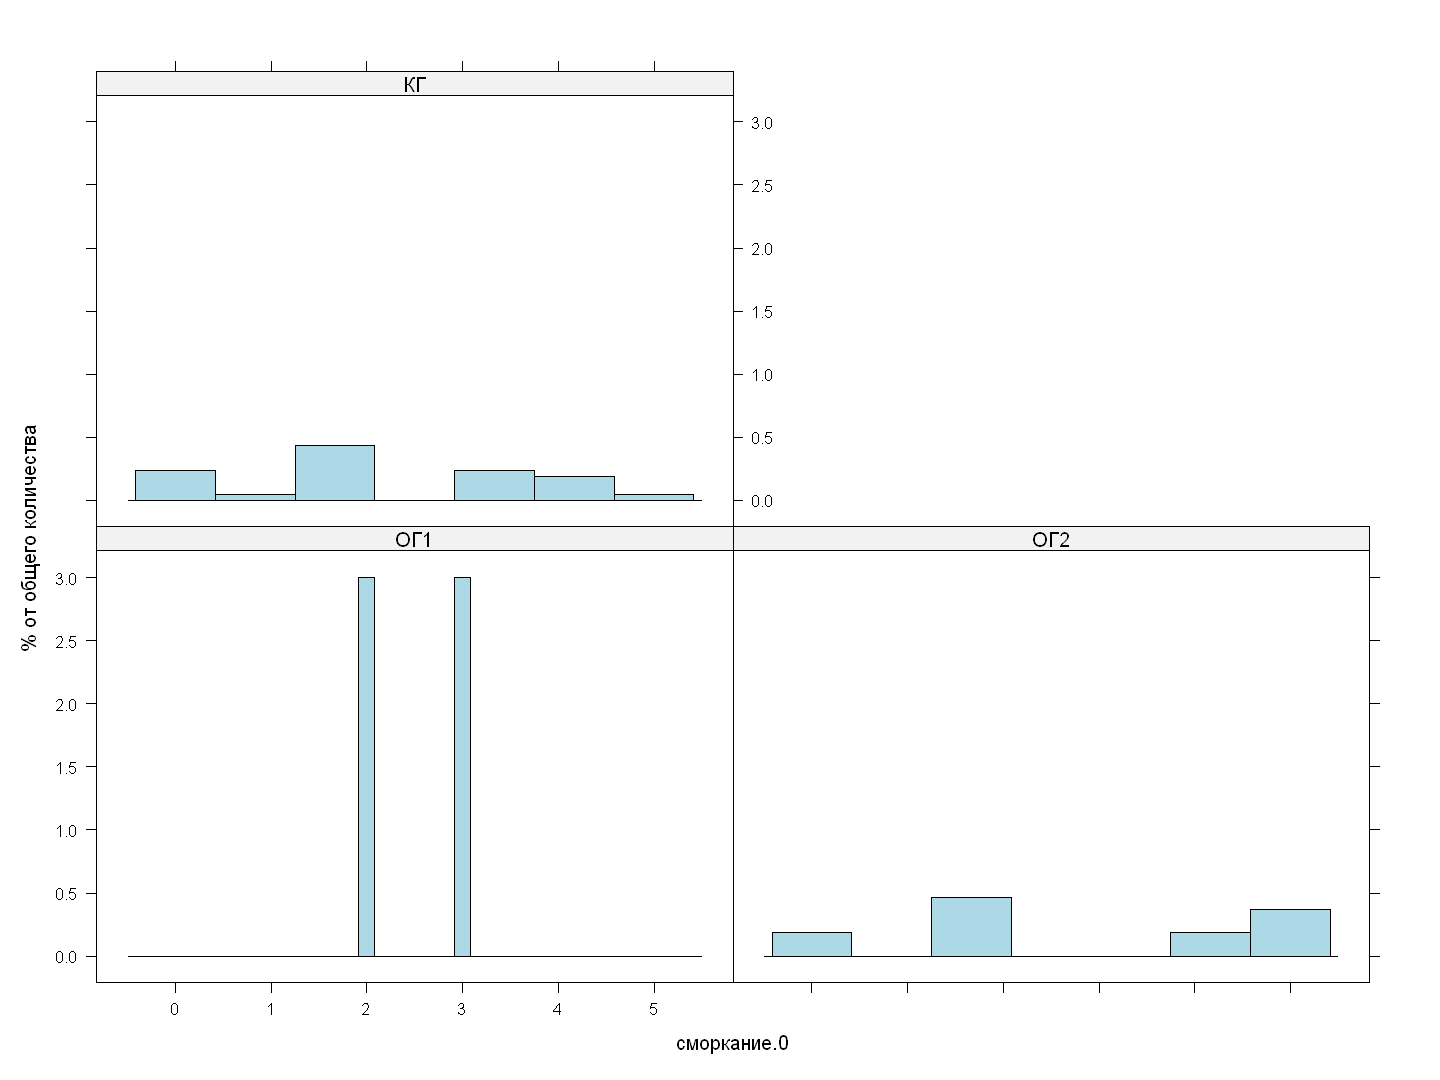

In [11]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [12]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

        mean       sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 2.500000 0.522233   1  2   2 2.5   3    3     12
ОГ2 2.923077 1.846688   3  0   2 2.0   5    5     13
КГ  2.200000 1.443376   1  0   2 2.0   3    5     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,2,2,2.5,3,3,2.500000,0.522233,12,0
ОГ2,0,2,2.0,5,5,2.923077,1.846688,13,0
КГ,0,2,2.0,3,5,2.200000,1.443376,25,0


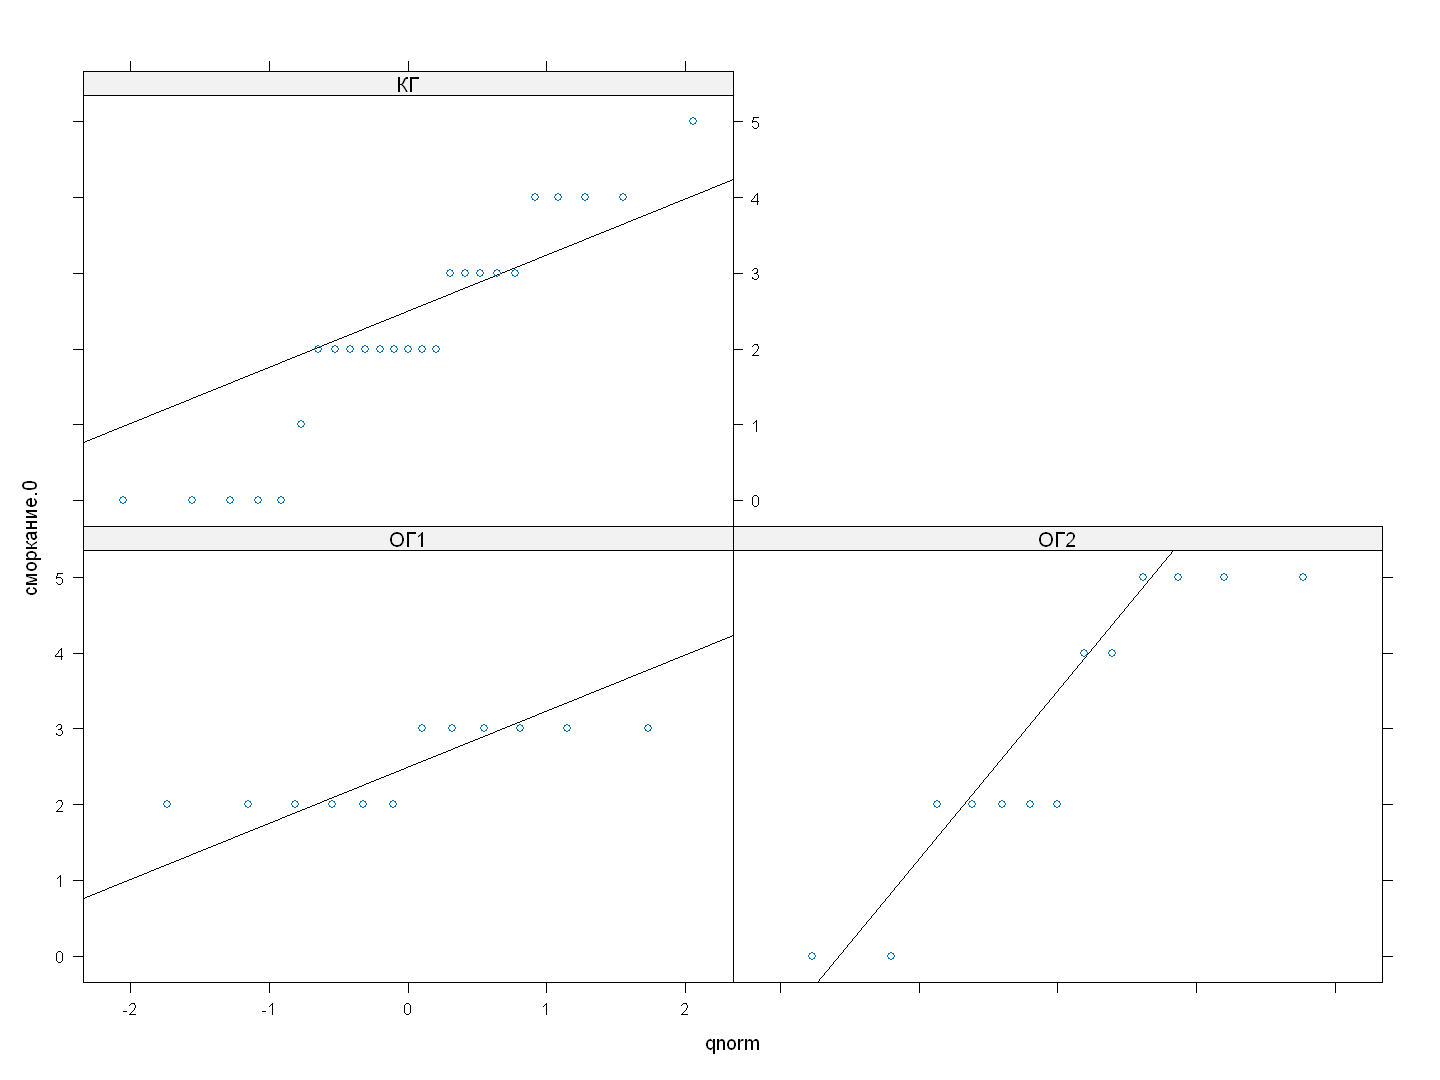

In [13]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

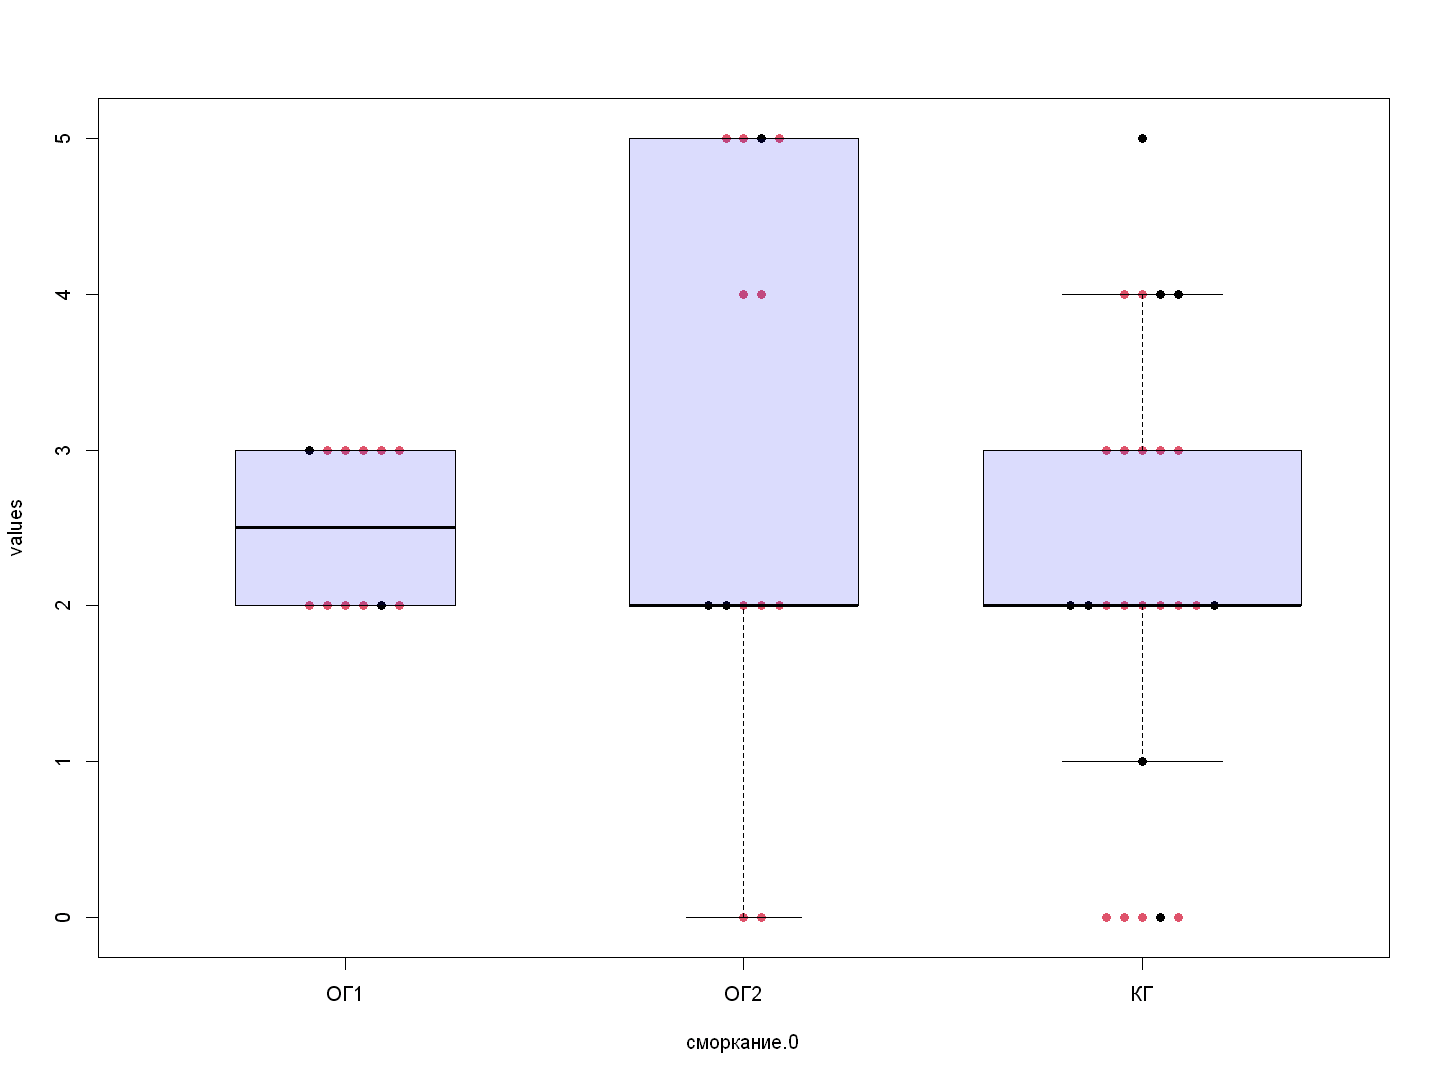

In [14]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [15]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.64978, p-value = 0.0002884

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.8523, p-value = 0.03053

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.91019, p-value = 0.03079



In [16]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 14.039, df = 2, p-value = 0.0008941


### Сравнение, нормальные распределения

In [17]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares    4.49692  93.92308
Deg. of Freedom         2        47

Residual standard error: 1.413635
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2   4.50   2.248   1.125  0.333
Residuals   47  93.92   1.998               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
              diff        lwr       upr     p adj
ОГ2-ОГ1  0.4230769 -0.9464864 1.7926403 0.7365499
КГ-ОГ1  -0.3000000 -1.5014748 0.9014748 0.8184775
КГ-ОГ2  -0.7230769 -1.8929117 0.4467579 0.3020805


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -0.79242, df = 14.054, p-value = 0.4413
alternative hypothesis: true difference in means 

### Сравнение, распределение не нормальное

In [18]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 1.4856, df = 2, p-value = 0.4758

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ1-ОГ2 2.788462     13.97036       FALSE
ОГ1-КГ  2.950000     12.25576       FALSE
ОГ2-КГ  5.738462     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 69, p-value = 0.6255
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = -0.51679, p-value = 0.6392
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 168, p-value = 0.5504
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

## сморкание.3

### Общее

In [19]:
parname <- "сморкание.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

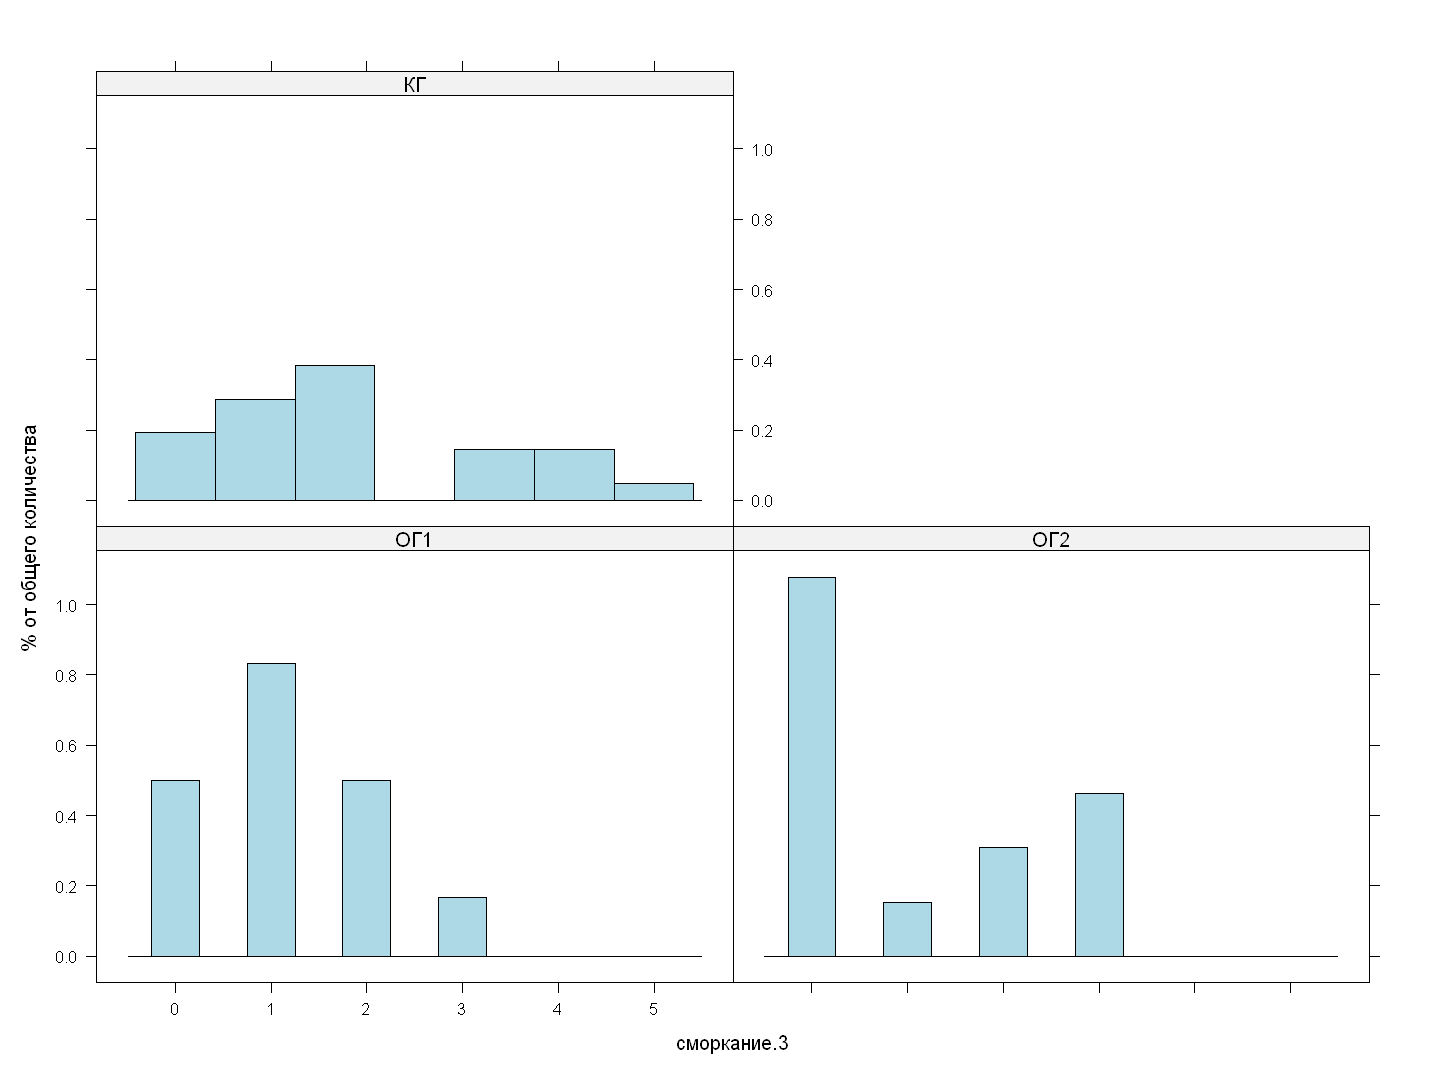

In [20]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [21]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

        mean        sd  IQR 0%  25% 50% 75% 100% data:n
ОГ1 1.166667 0.9374369 1.25  0 0.75   1   2    3     12
ОГ2 1.076923 1.3204506 2.00  0 0.00   0   2    3     13
КГ  1.920000 1.3820275 2.00  0 1.00   2   3    5     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0.75,1,2,3,1.166667,0.9374369,12,0
ОГ2,0,0.00,0,2,3,1.076923,1.3204506,13,0
КГ,0,1.00,2,3,5,1.920000,1.3820275,25,0


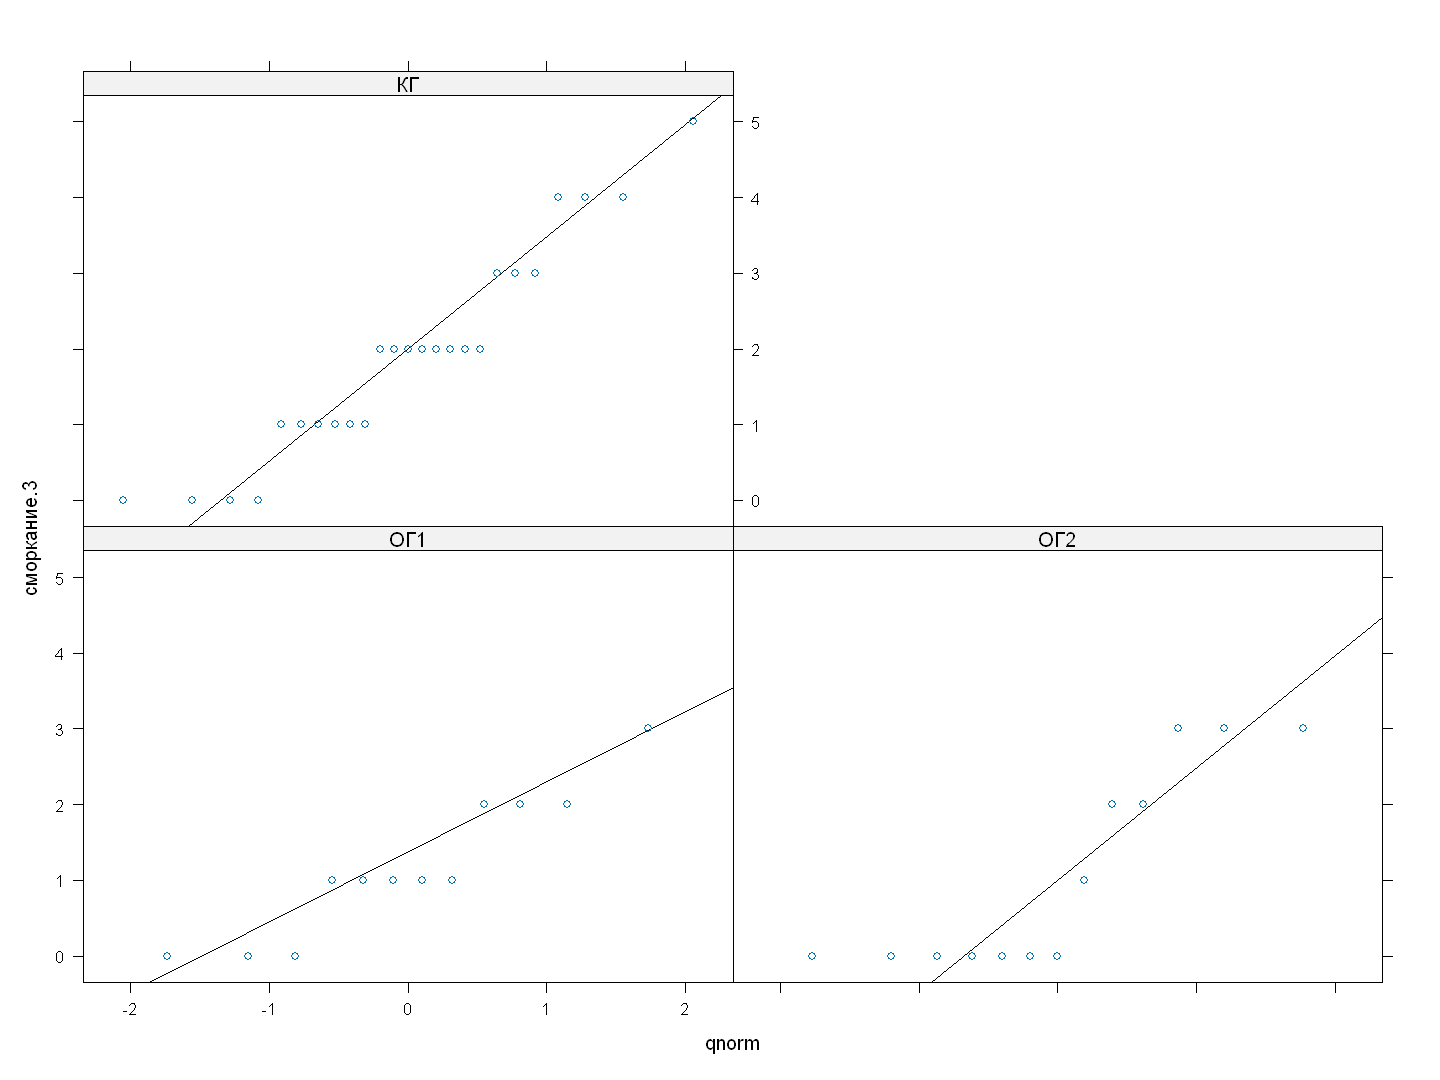

In [22]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

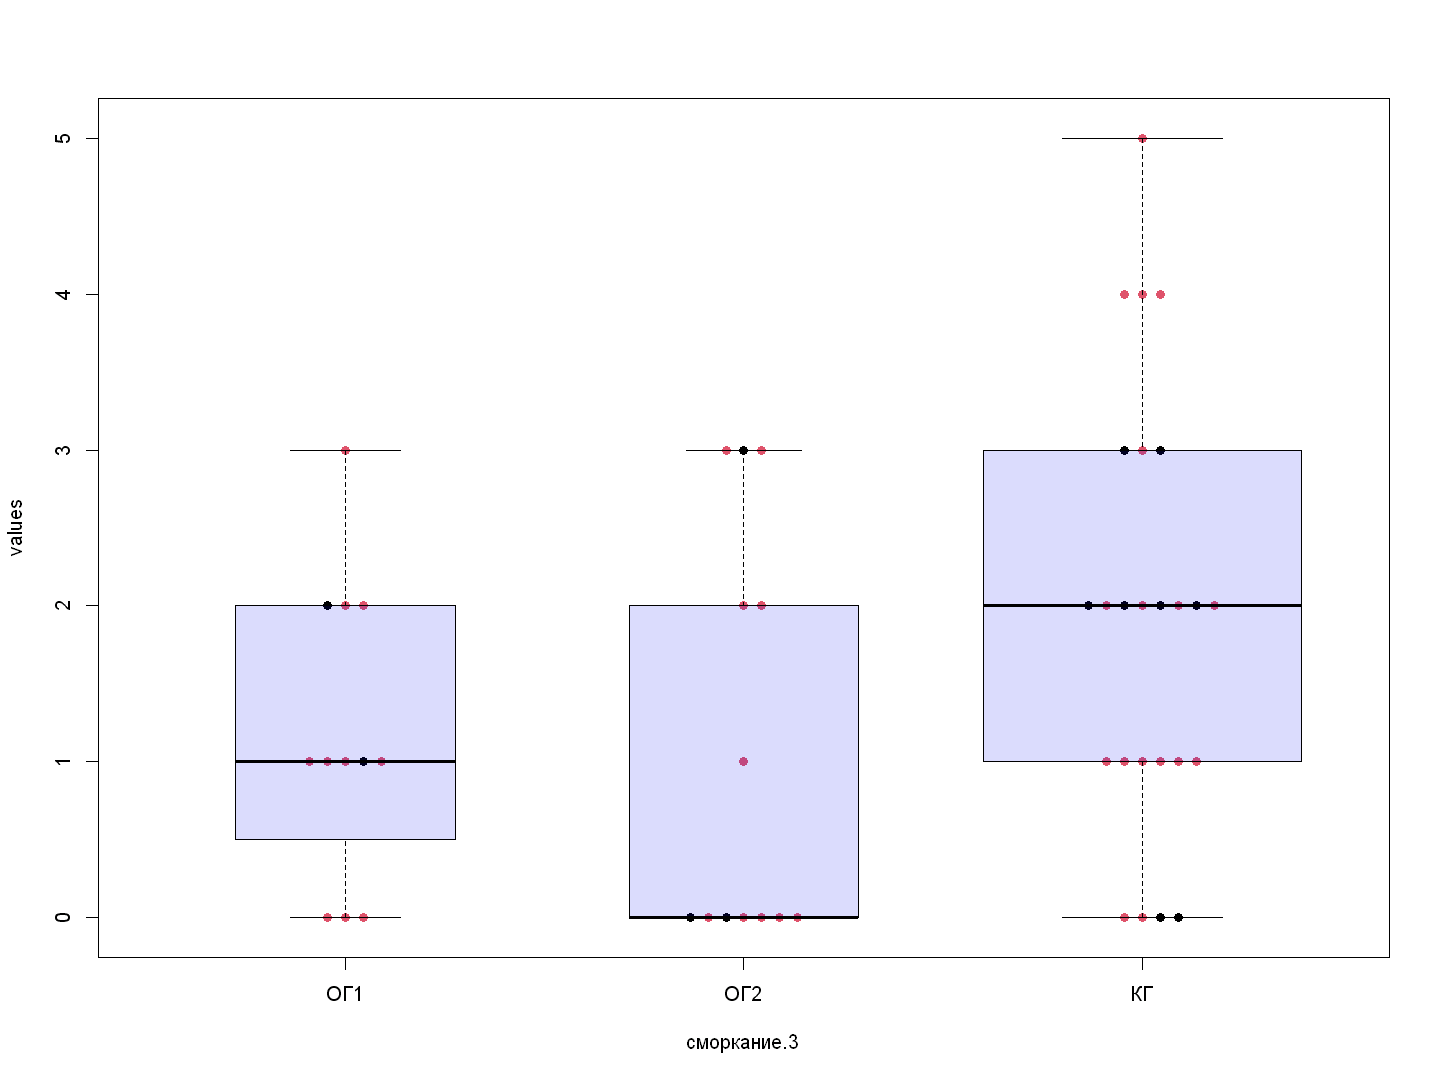

In [23]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [24]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.89137, p-value = 0.1227

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.74343, p-value = 0.001564

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.92439, p-value = 0.06454



In [25]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 2.0069, df = 2, p-value = 0.3666


### Сравнение, нормальные распределения

In [26]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares    8.05026  76.42974
Deg. of Freedom         2        47

Residual standard error: 1.275212
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)  
parameter    2   8.05   4.025   2.475  0.095 .
Residuals   47  76.43   1.626                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
               diff        lwr      upr     p adj
ОГ2-ОГ1 -0.08974359 -1.3251993 1.145712 0.9831128
КГ-ОГ1   0.75333333 -0.3304930 1.837160 0.2226376
КГ-ОГ2   0.84307692 -0.2122076 1.898361 0.1405897


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = 0.19708, df = 21

### Сравнение, распределение не нормальное

In [27]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 4.2728, df = 2, p-value = 0.1181

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ1-ОГ2 1.634615     13.97036       FALSE
ОГ1-КГ  7.350000     12.25576       FALSE
ОГ2-КГ  8.984615     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 86.5, p-value = 0.6486
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = 0.48425, p-value = 0.6394
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 102.5, p-value = 0.1157
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence T

## чихание.0

### Общее

In [28]:
parname <- "чихание.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

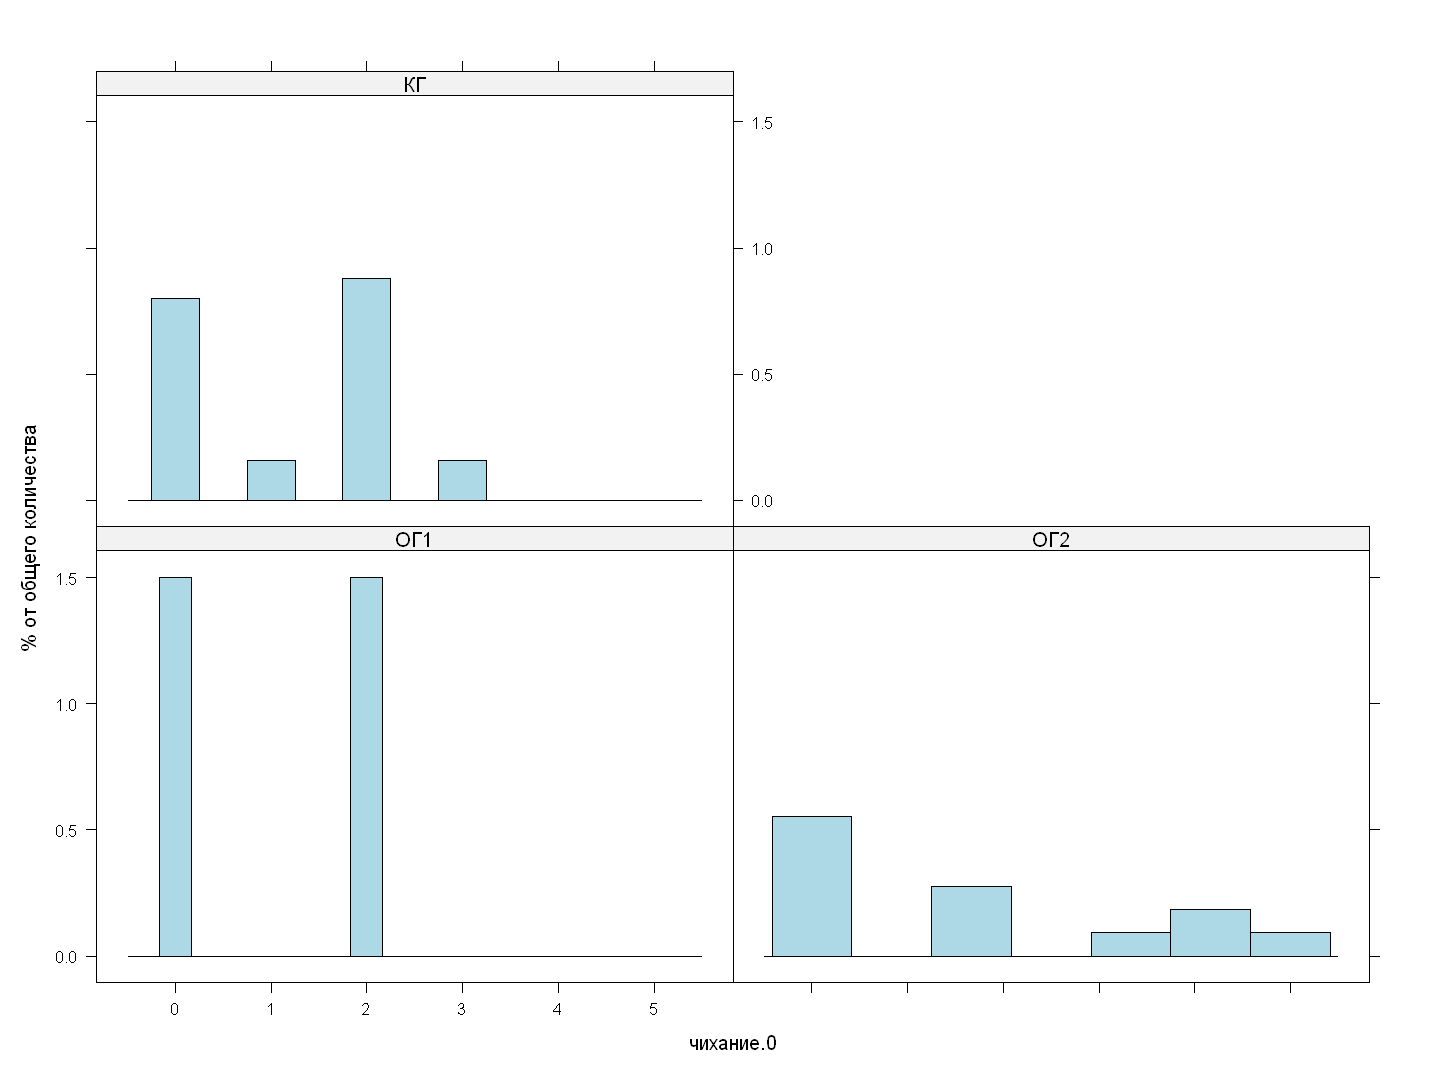

In [29]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [30]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

        mean       sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 1.000000 1.044466   2  0   0   1   2    2     12
ОГ2 1.692308 1.843213   3  0   0   2   3    5     13
КГ  1.200000 1.080123   2  0   0   2   2    3     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,1,2,2,1.000000,1.044466,12,0
ОГ2,0,0,2,3,5,1.692308,1.843213,13,0
КГ,0,0,2,2,3,1.200000,1.080123,25,0


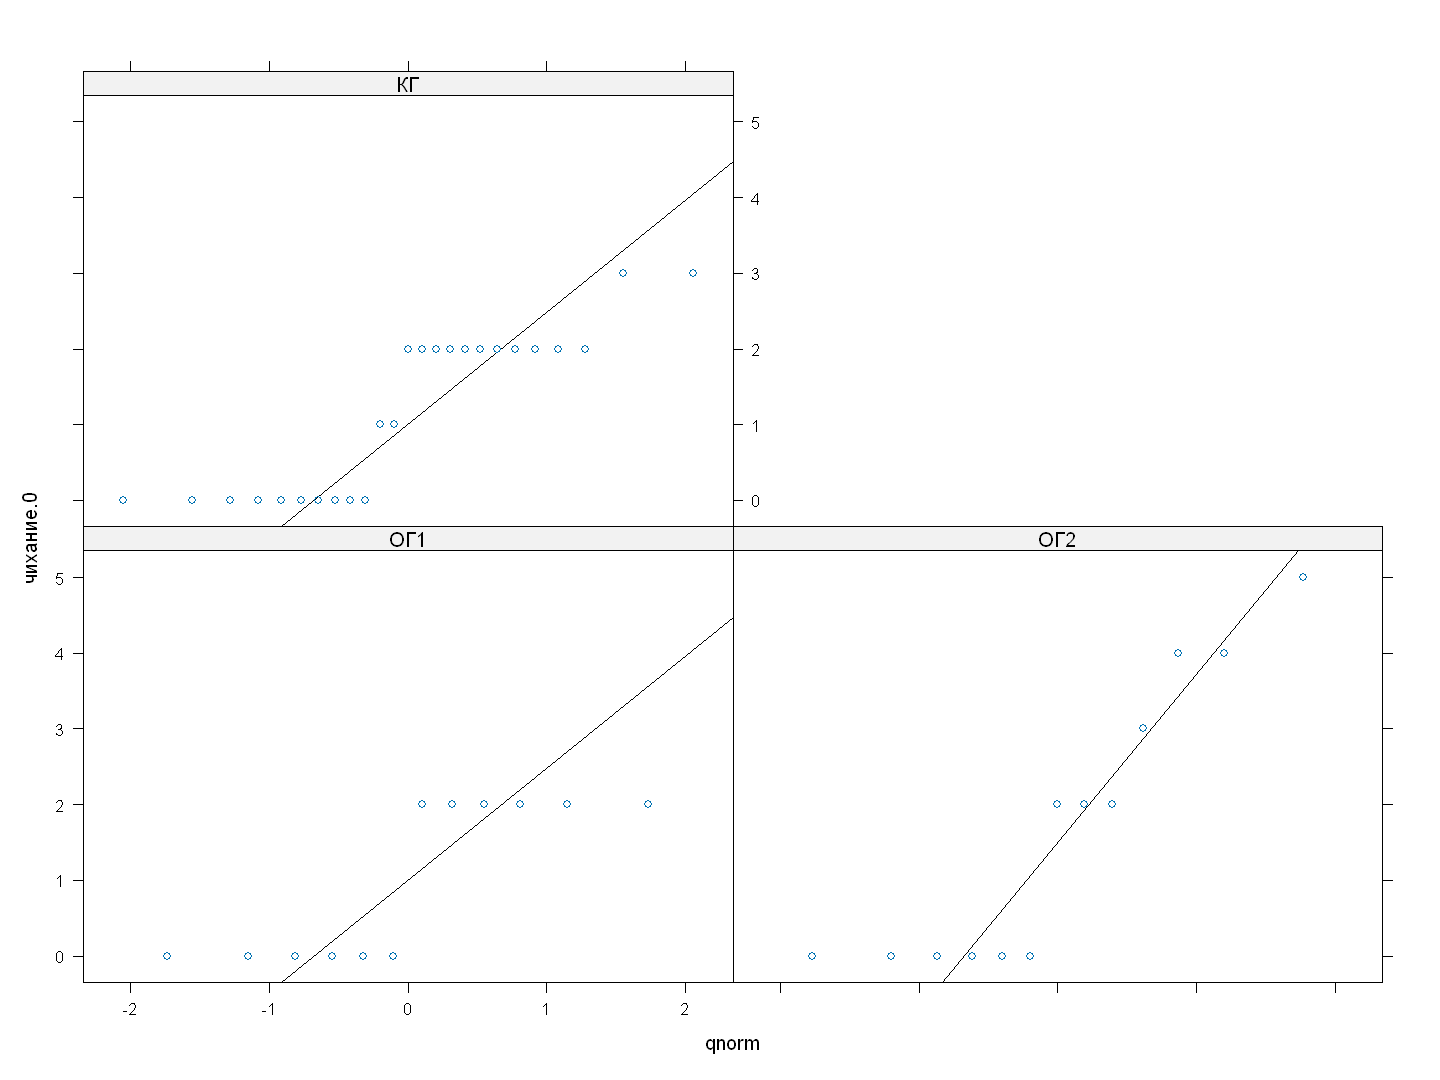

In [31]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

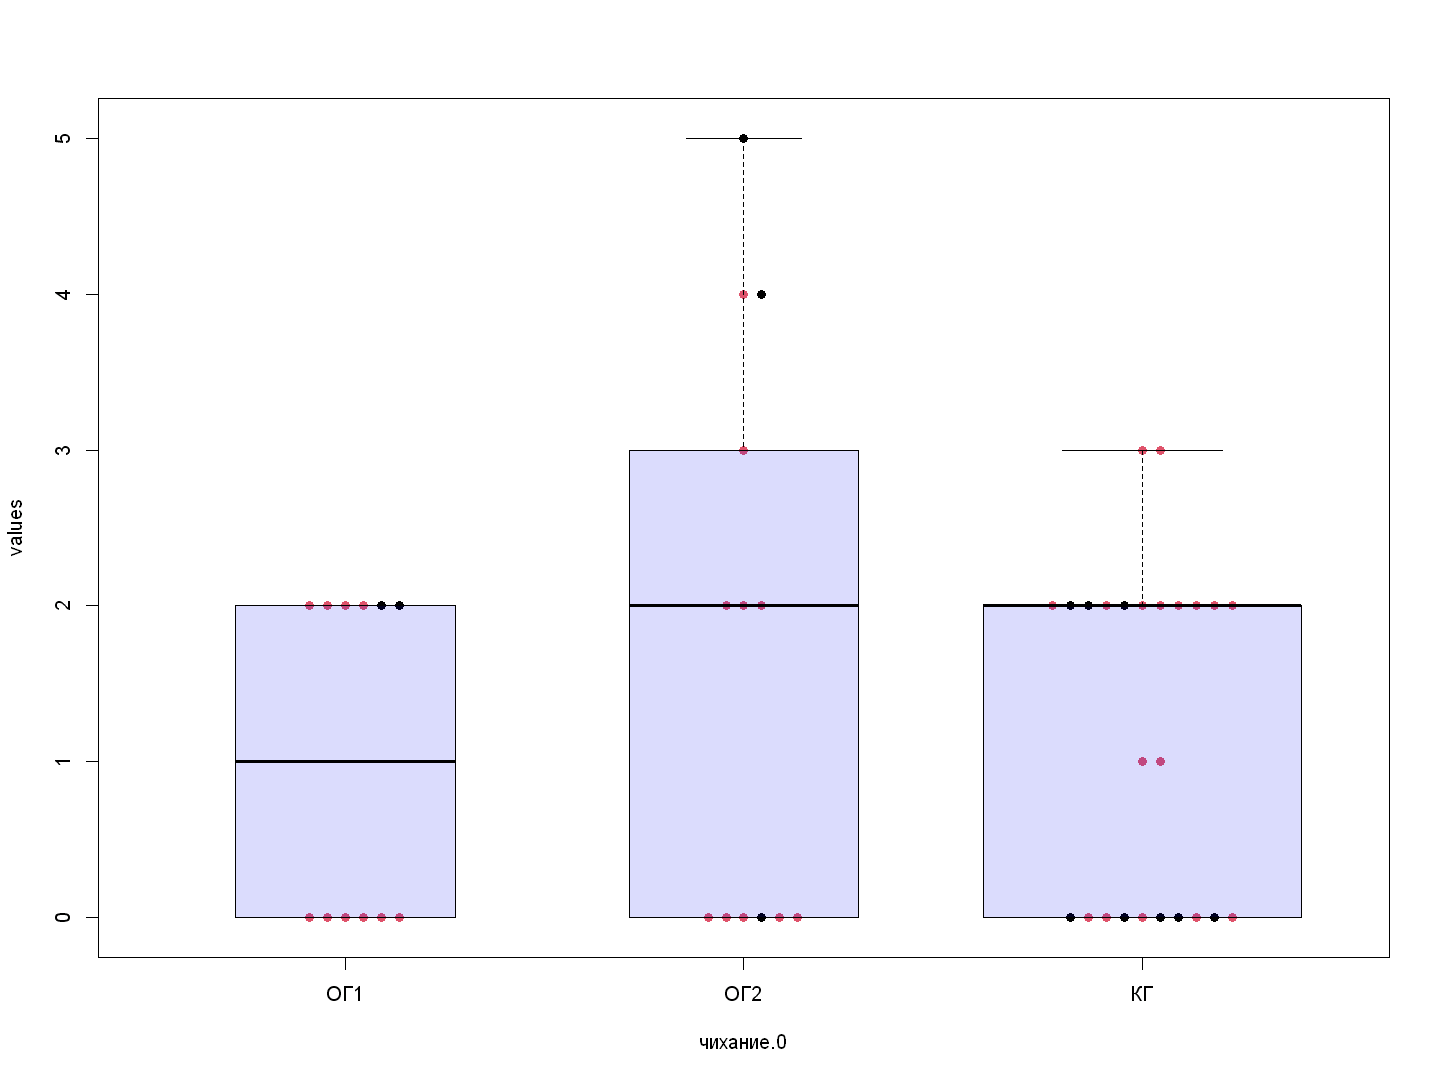

In [32]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [33]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.64978, p-value = 0.0002884

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.82912, p-value = 0.01544

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.78384, p-value = 0.0001237



In [34]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 5.923, df = 2, p-value = 0.05174


### Сравнение, нормальные распределения

In [35]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares    3.31077  80.76923
Deg. of Freedom         2        47

Residual standard error: 1.310914
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2   3.31   1.655   0.963  0.389
Residuals   47  80.77   1.718               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
              diff        lwr       upr     p adj
ОГ2-ОГ1  0.6923077 -0.5777368 1.9623522 0.3917580
КГ-ОГ1   0.2000000 -0.9141700 1.3141700 0.9014258
КГ-ОГ2  -0.4923077 -1.5771369 0.5925215 0.5198887


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -1.1665, df = 19.258, p-value = 0.2577
alternative hypothesis: true difference in means i

### Сравнение, распределение не нормальное

In [36]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 0.91021, df = 2, p-value = 0.6344

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ1-ОГ2 5.115385     13.97036       FALSE
ОГ1-КГ  2.340000     12.25576       FALSE
ОГ2-КГ  2.775385     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 63, p-value = 0.3905
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = -0.88838, p-value = 0.4043
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 135, p-value = 0.6039
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Tes

## чихание.3

### Общее

In [37]:
parname <- "чихание.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

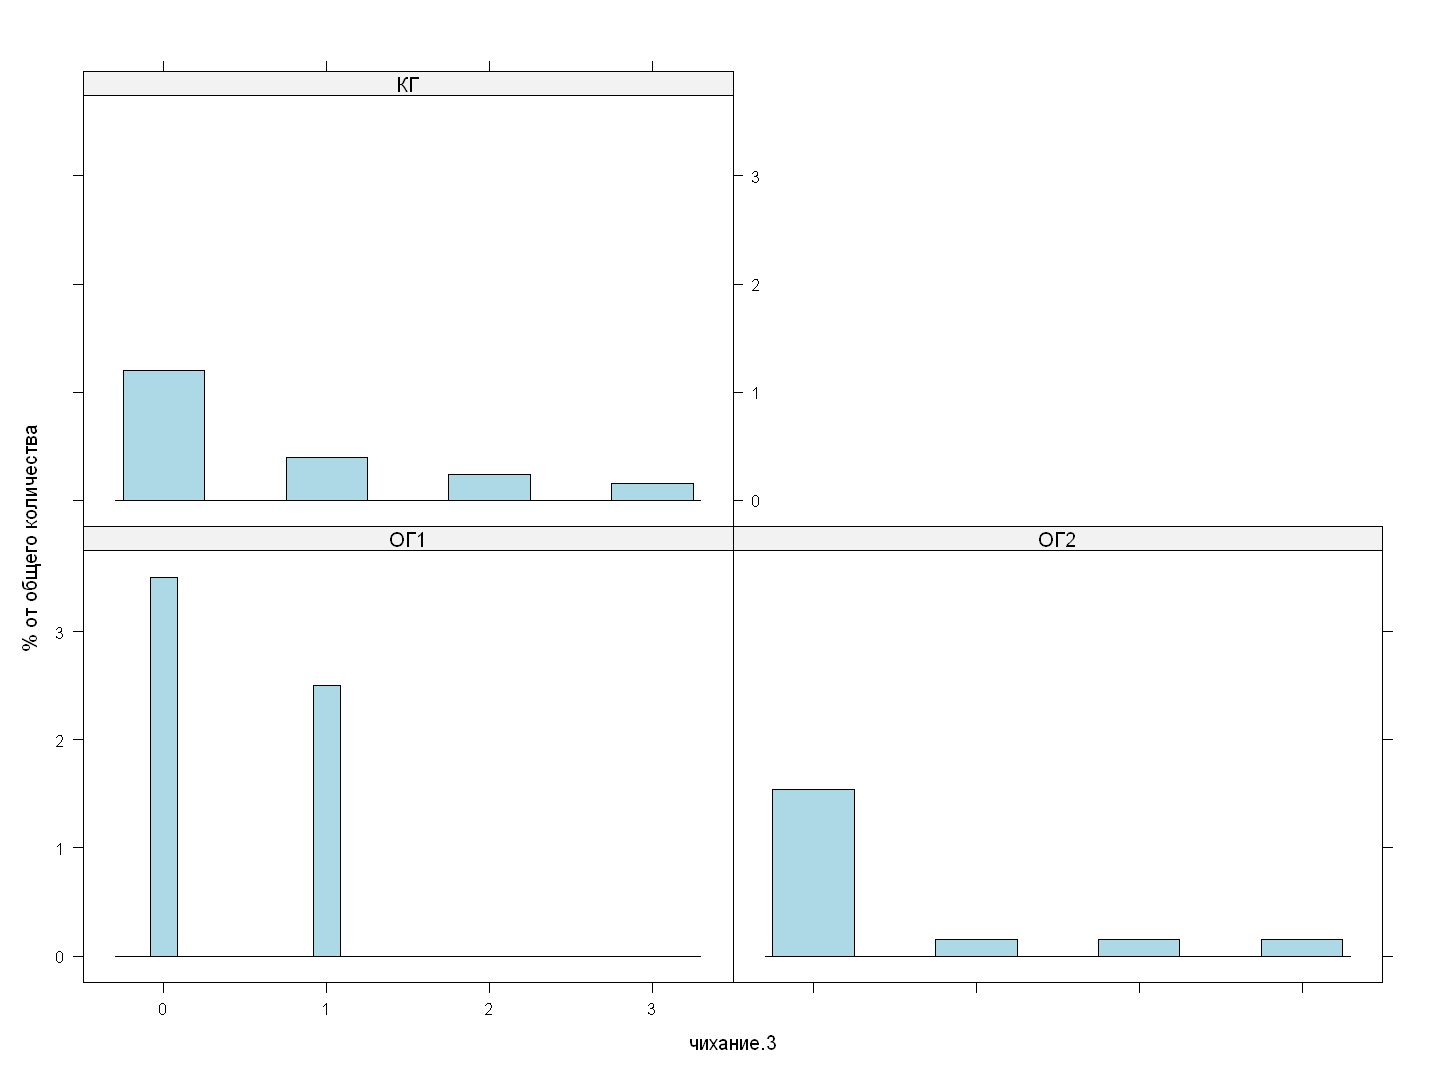

In [38]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [39]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 0.4166667 0.5149287   1  0   0   0   1    1     12
ОГ2 0.4615385 0.9674179   0  0   0   0   0    3     13
КГ  0.6800000 0.9882645   1  0   0   0   1    3     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,0,1,1,0.4166667,0.5149287,12,0
ОГ2,0,0,0,0,3,0.4615385,0.9674179,13,0
КГ,0,0,0,1,3,0.6800000,0.9882645,25,0


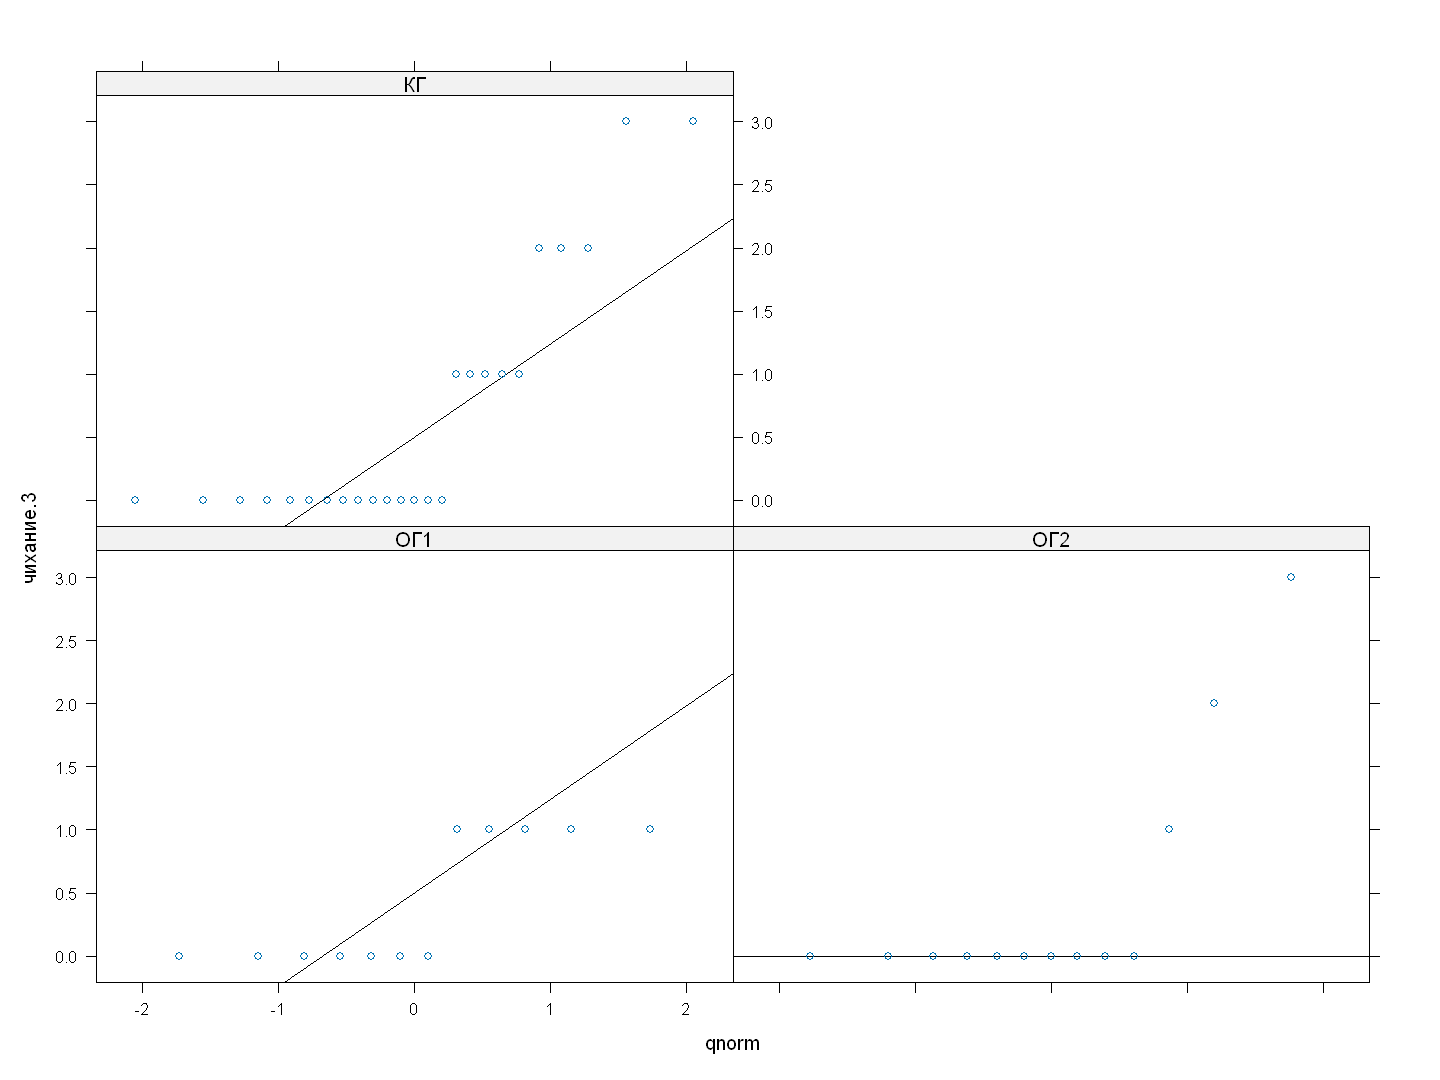

In [40]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

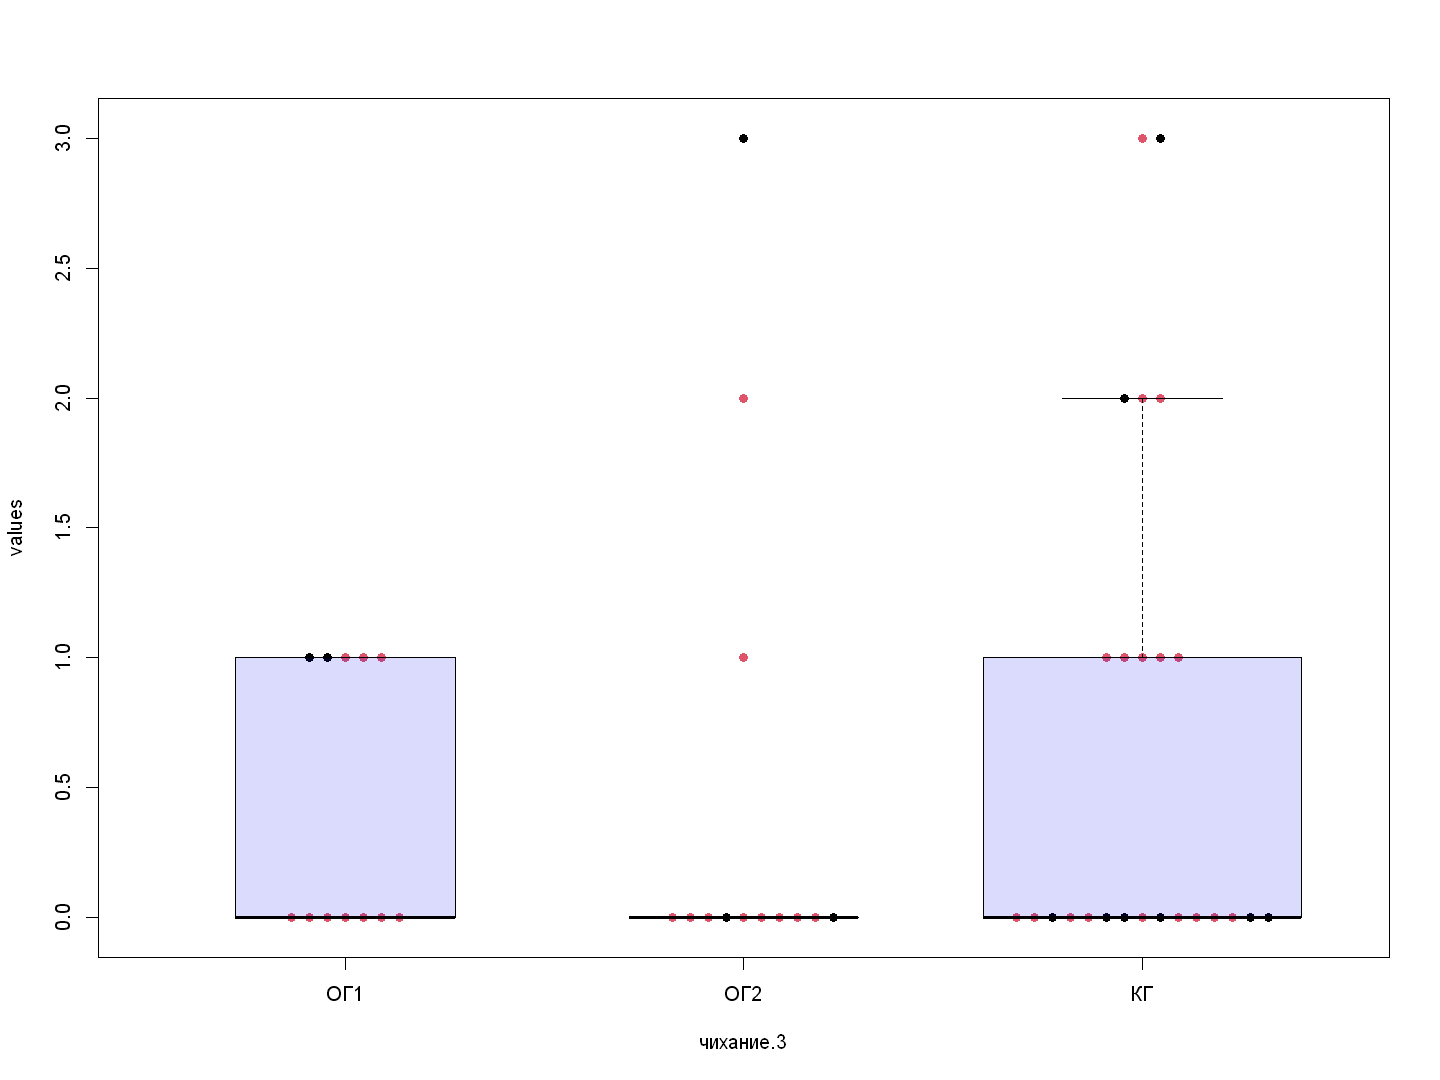

In [41]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [42]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.63959, p-value = 0.0002342

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.56256, p-value = 3.168e-05

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.71479, p-value = 1.16e-05



In [43]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 5.2886, df = 2, p-value = 0.07105


### Сравнение, нормальные распределения

In [44]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares    0.73256  37.58744
Deg. of Freedom         2        47

Residual standard error: 0.8942777
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2   0.73  0.3663   0.458  0.635
Residuals   47  37.59  0.7997               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
              diff        lwr       upr     p adj
ОГ2-ОГ1 0.04487179 -0.8215260 0.9112696 0.9913777
КГ-ОГ1  0.26333333 -0.4967301 1.0233968 0.6812171
КГ-ОГ2  0.21846154 -0.5215862 0.9585093 0.7562251


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -0.14629, df = 18.587, p-value = 0.8853
alternative hypothesis: true difference in means

### Сравнение, распределение не нормальное

In [45]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 0.88419, df = 2, p-value = 0.6427

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ1-ОГ2 2.573718     13.97036       FALSE
ОГ1-КГ  1.421667     12.25576       FALSE
ОГ2-КГ  3.995385     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 87.5, p-value = 0.5506
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = 0.63002, p-value = 0.5746
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 140, p-value = 0.7254
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Te

## насморк.0

### Общее

In [46]:
parname <- "насморк.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

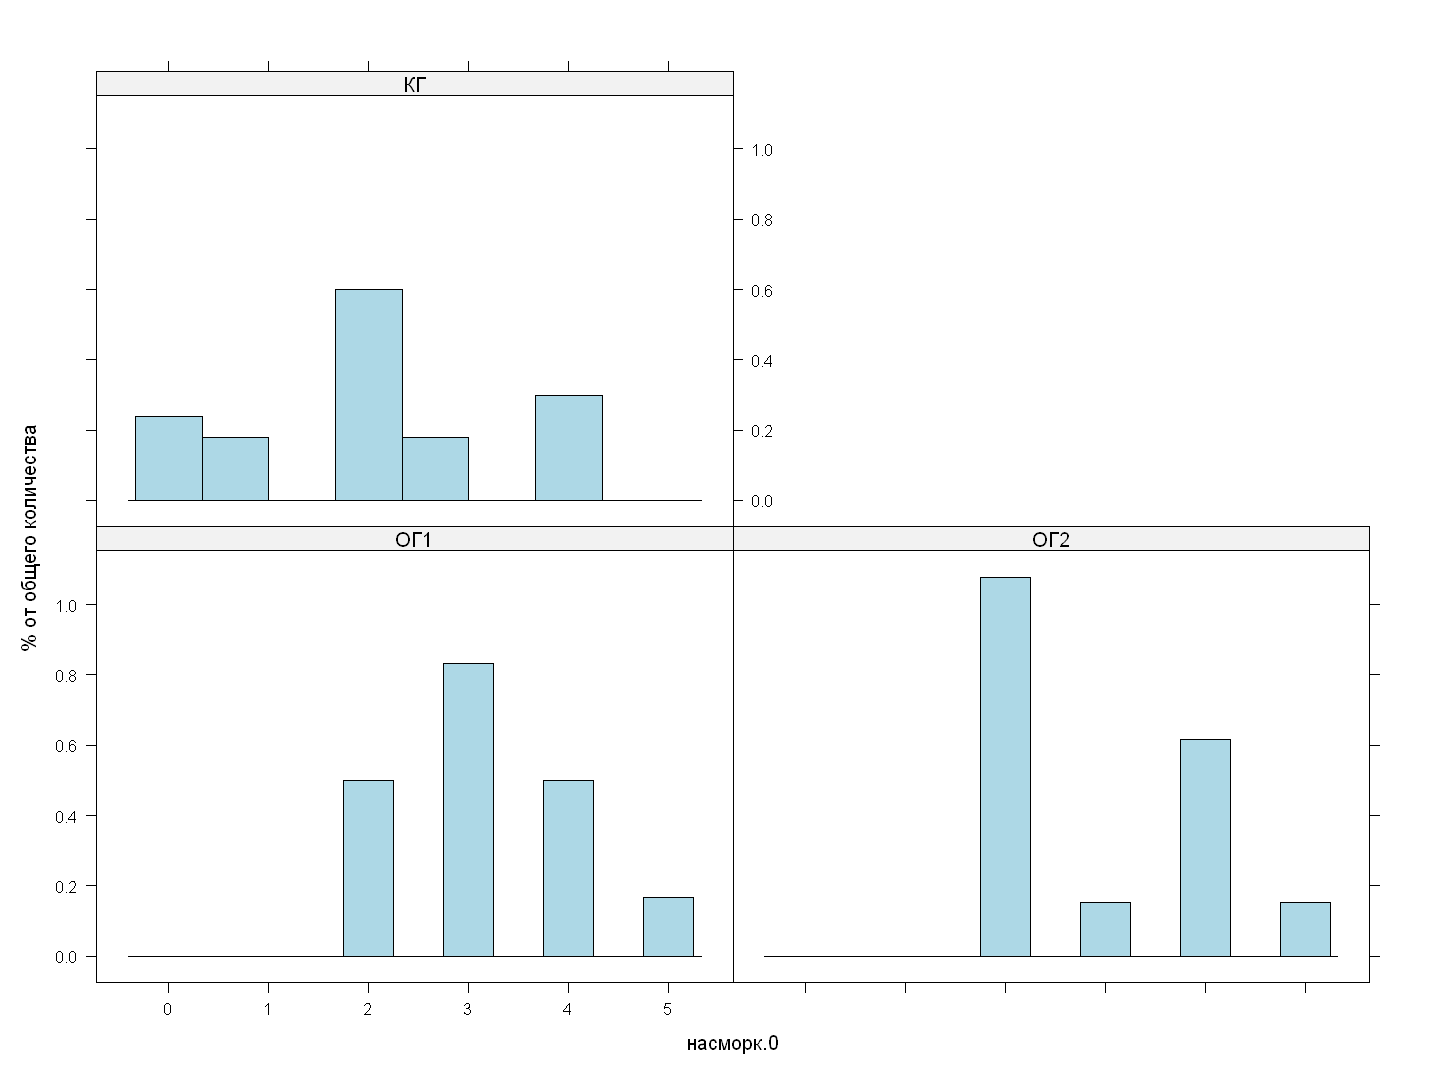

In [47]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [48]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

        mean        sd  IQR 0%  25% 50% 75% 100% data:n
ОГ1 3.166667 0.9374369 1.25  2 2.75   3   4    5     12
ОГ2 2.923077 1.1151636 2.00  2 2.00   2   4    5     13
КГ  2.080000 1.3203535 2.00  0 1.00   2   3    4     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,2,2.75,3,4,5,3.166667,0.9374369,12,0
ОГ2,2,2.00,2,4,5,2.923077,1.1151636,13,0
КГ,0,1.00,2,3,4,2.080000,1.3203535,25,0


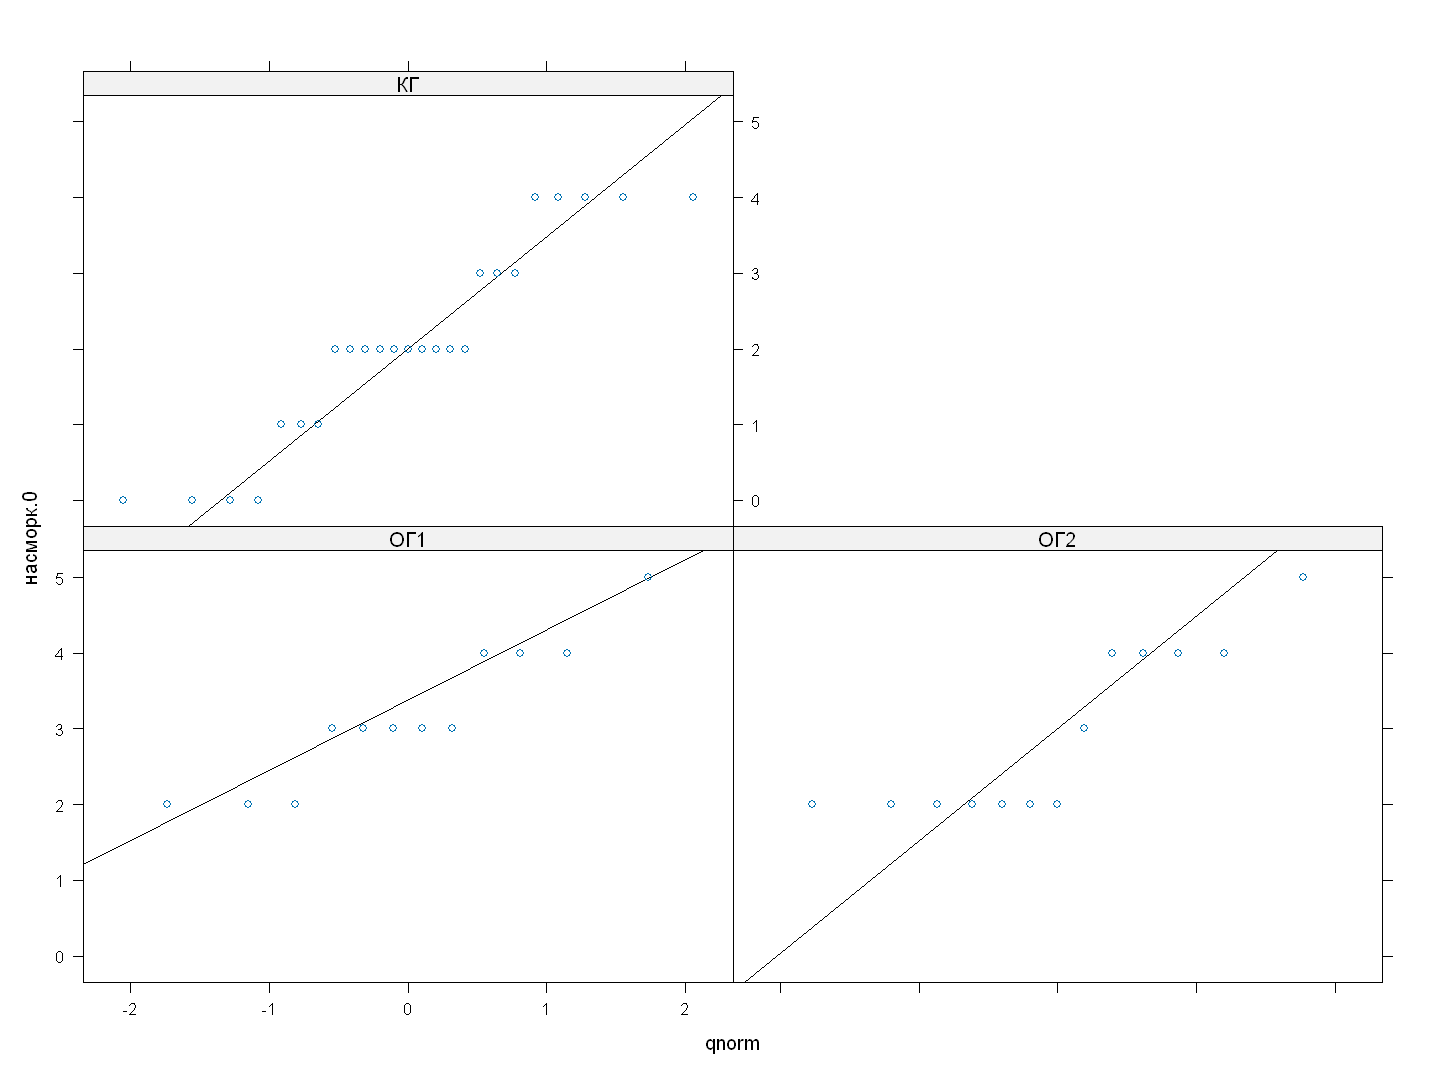

In [49]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

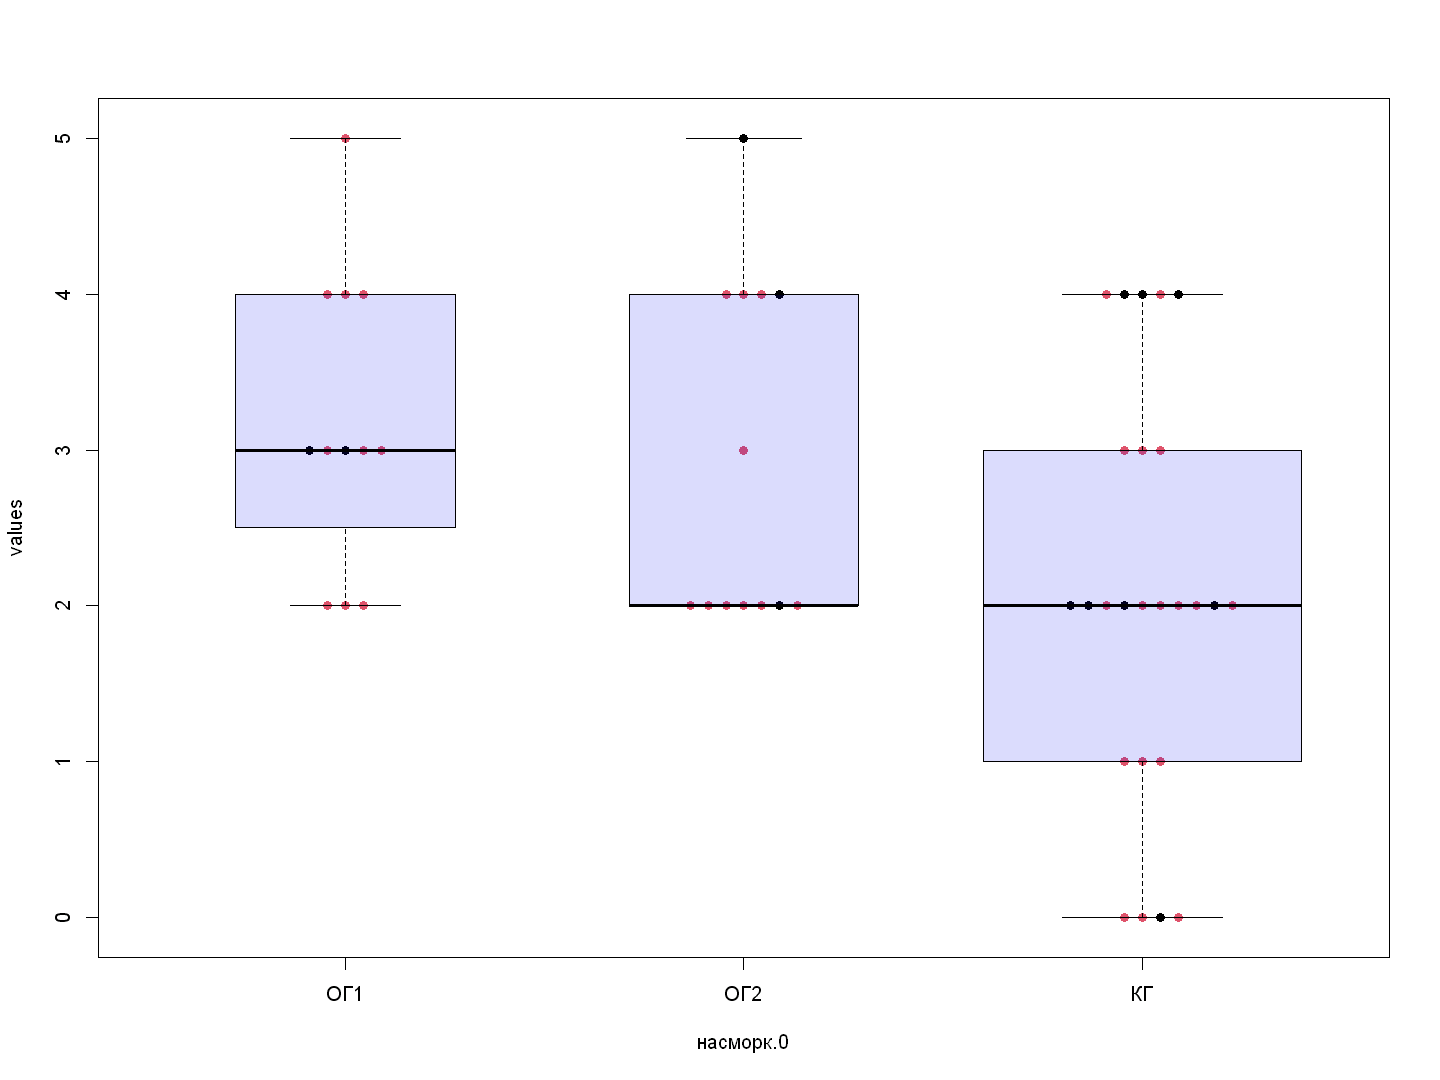

In [50]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [51]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.89137, p-value = 0.1227

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.76123, p-value = 0.002448

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.89129, p-value = 0.01192



In [52]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 1.6737, df = 2, p-value = 0.4331


### Сравнение, нормальные распределения

In [53]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares   11.89026  66.42974
Deg. of Freedom         2        47

Residual standard error: 1.188865
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)  
parameter    2  11.89   5.945   4.206 0.0209 *
Residuals   47  66.43   1.413                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
              diff       lwr        upr     p adj
ОГ2-ОГ1 -0.2435897 -1.395390  0.9082107 0.8659717
КГ-ОГ1  -1.0866667 -2.097105 -0.0762284 0.0324571
КГ-ОГ2  -0.8430769 -1.826906  0.1407522 0.1062936


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = 0.59272, df = 22

### Сравнение, распределение не нормальное

In [54]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 6.9618, df = 2, p-value = 0.03078

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
          obs.dif critical.dif stat.signif
ОГ1-ОГ2  3.689103     13.97036       FALSE
ОГ1-КГ  11.998333     12.25576       FALSE
ОГ2-КГ   8.309231     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 90.5, p-value = 0.4917
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = 0.71623, p-value = 0.4687
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 221, p-value = 0.01802
alternative hypothesis: true location shift is not equal to 0


	Exact General Independen

## насморк.3

### Общее

In [55]:
parname <- "насморк.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

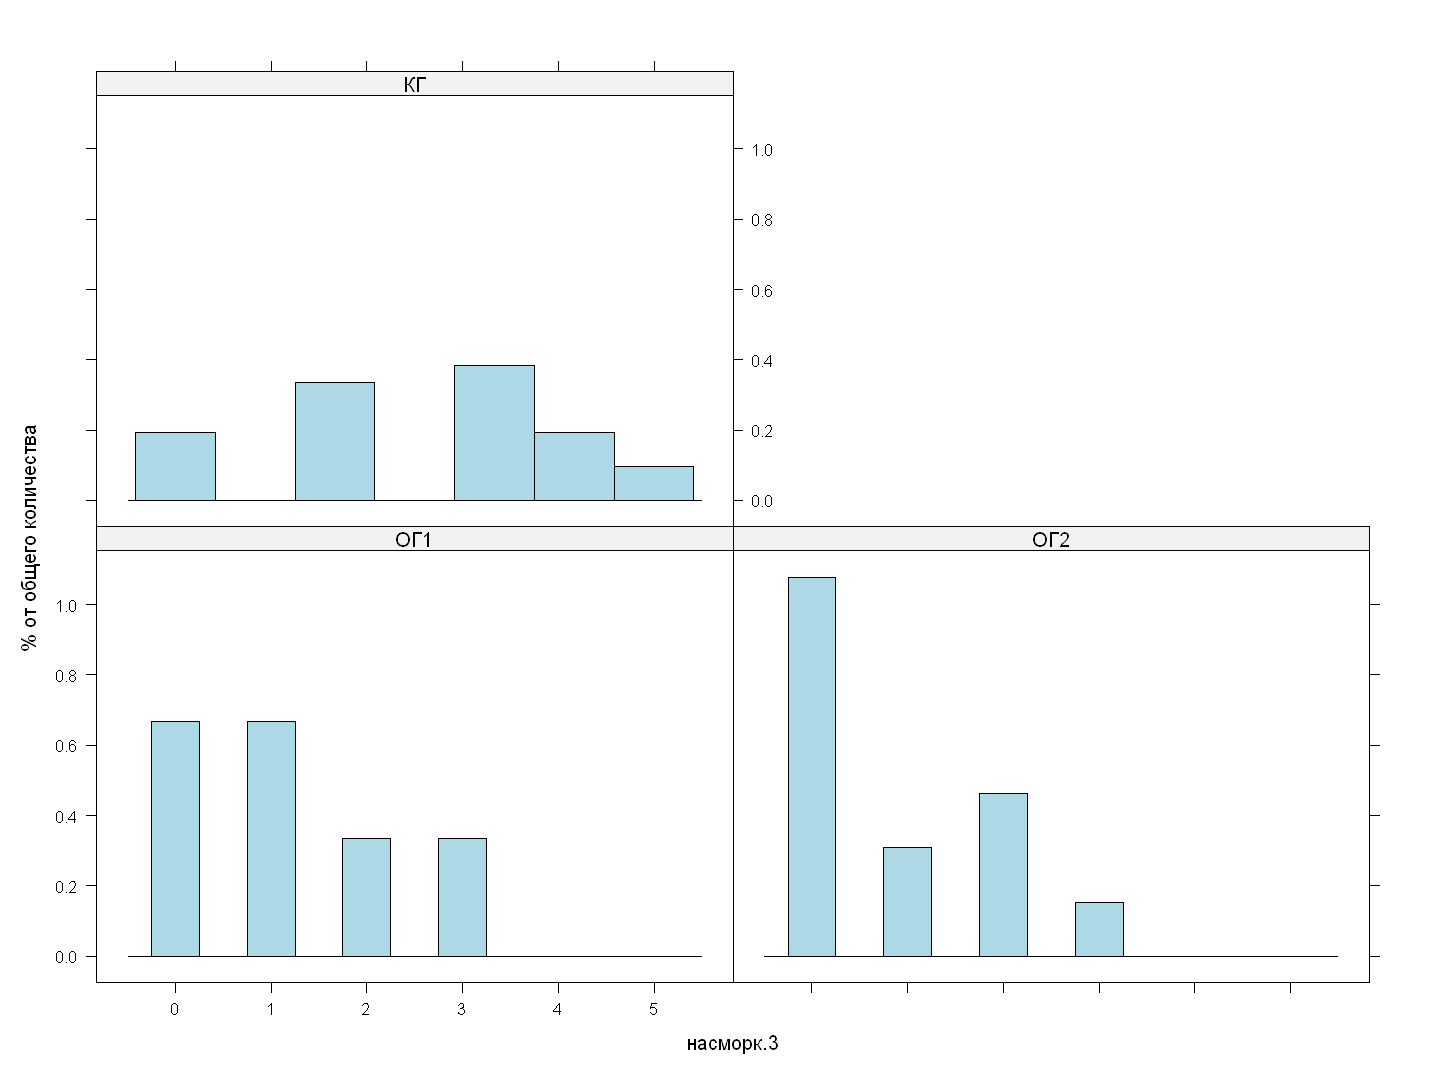

In [56]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [57]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean       sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 1.1666667 1.114641   2  0   0   1   2    3     12
ОГ2 0.8461538 1.068188   2  0   0   0   2    3     13
КГ  2.5600000 1.445683   1  0   2   3   3    5     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,1,2,3,1.1666667,1.114641,12,0
ОГ2,0,0,0,2,3,0.8461538,1.068188,13,0
КГ,0,2,3,3,5,2.5600000,1.445683,25,0


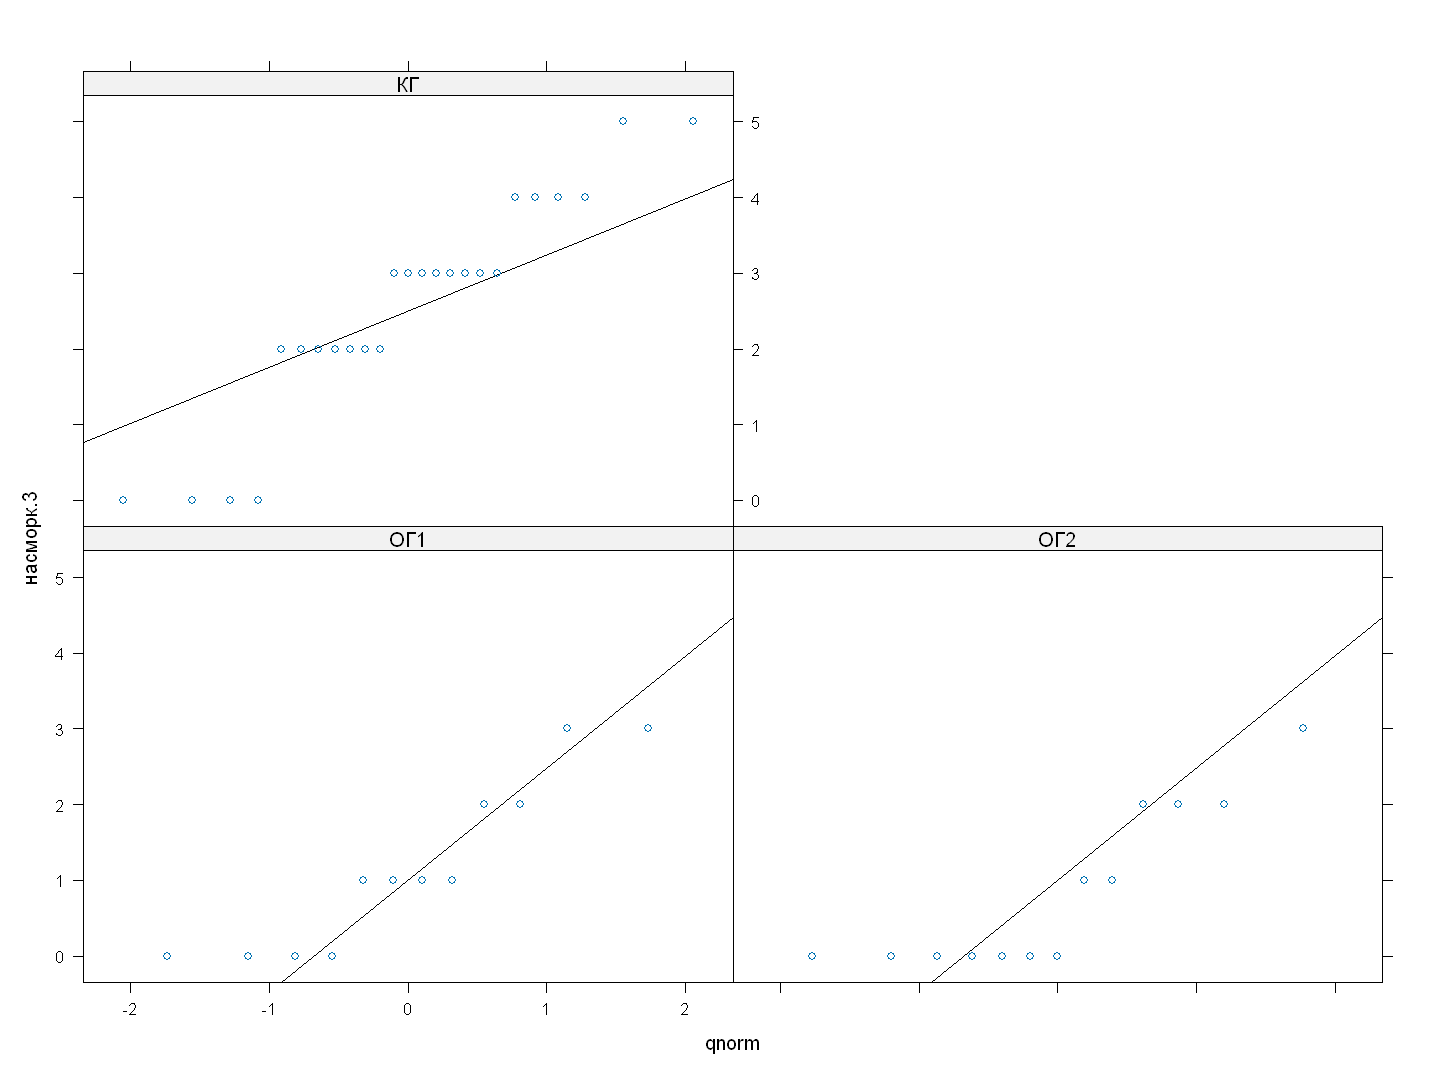

In [58]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

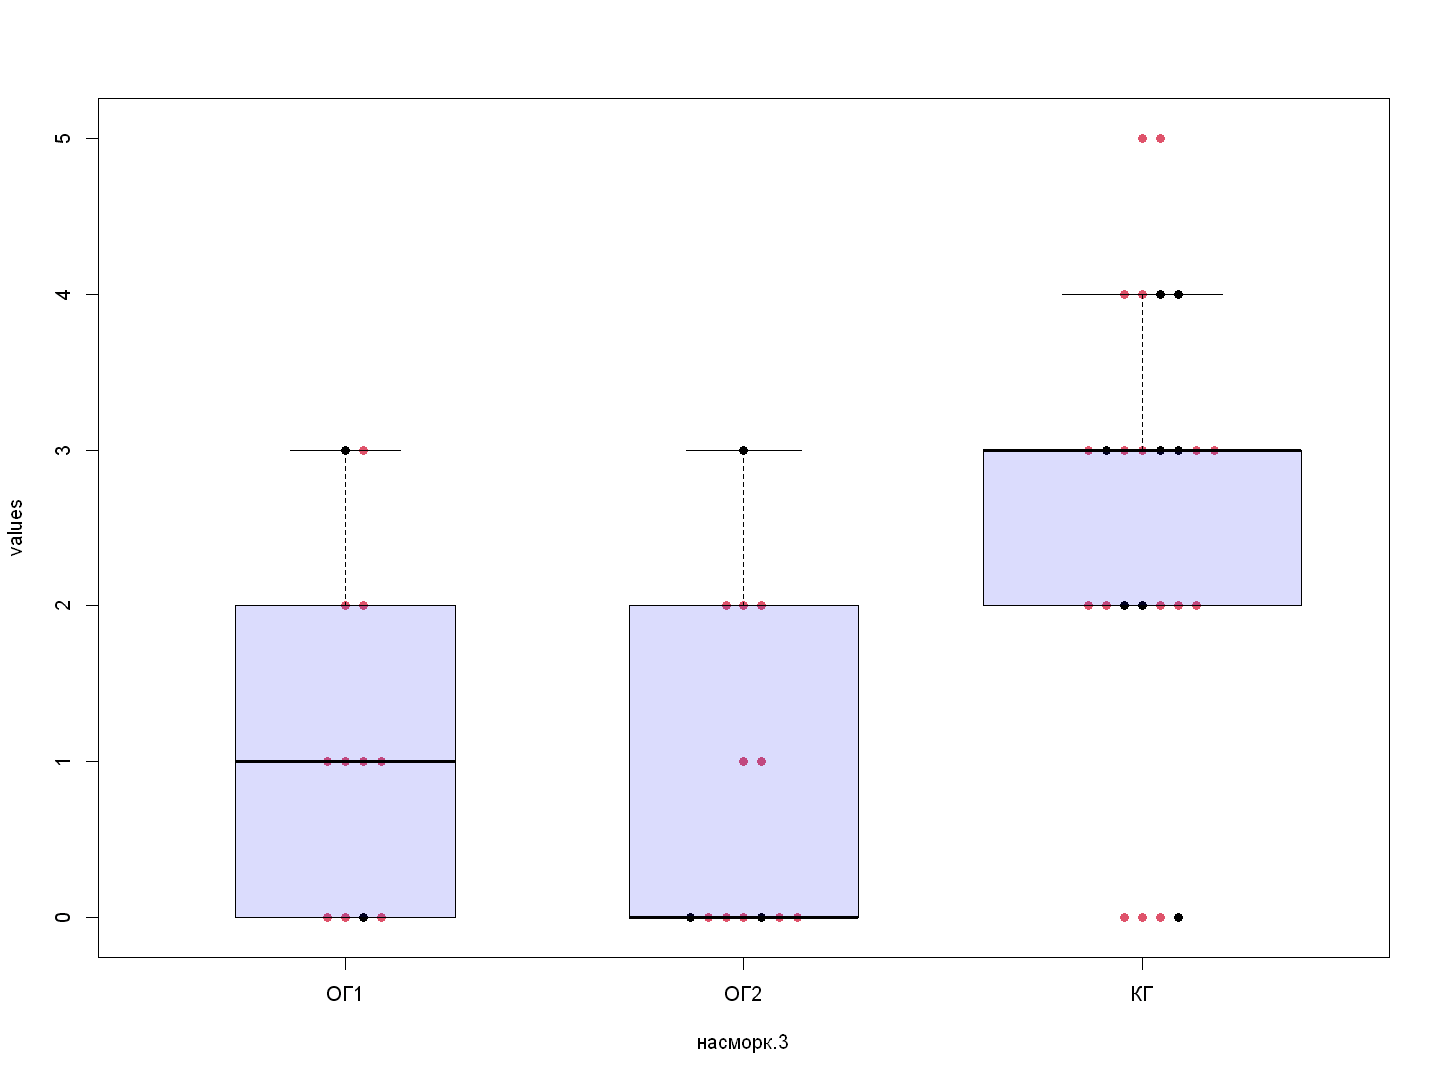

In [59]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [60]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.85926, p-value = 0.04785

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.77634, p-value = 0.003617

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.90357, p-value = 0.02196



In [61]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 1.7966, df = 2, p-value = 0.4073


### Сравнение, нормальные распределения

In [62]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares   31.06103  77.51897
Deg. of Freedom         2        47

Residual standard error: 1.284266
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value   Pr(>F)    
parameter    2  31.06  15.531   9.416 0.000364 ***
Residuals   47  77.52   1.649                     
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
              diff        lwr       upr     p adj
ОГ2-ОГ1 -0.3205128 -1.5647408 0.9237152 0.8080535
КГ-ОГ1   1.3933333  0.3018113 2.4848554 0.0092610
КГ-ОГ2   1.7138462  0.6510686 2.7766237 0.0008678


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = 0.73

### Сравнение, распределение не нормальное

In [63]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 13.827, df = 2, p-value = 0.0009943

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
          obs.dif critical.dif stat.signif
ОГ1-ОГ2  3.416667     13.97036       FALSE
ОГ1-КГ  12.943333     12.25576        TRUE
ОГ2-КГ  16.360000     11.93301        TRUE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 92, p-value = 0.437
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = 0.80597, p-value = 0.4391
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 69, p-value = 0.007488
alternative hypothesis: true location shift is not equal to 0


	Exact General Independenc

## заложенность носа.0

### Общее

In [64]:
parname <- "заложенность носа.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

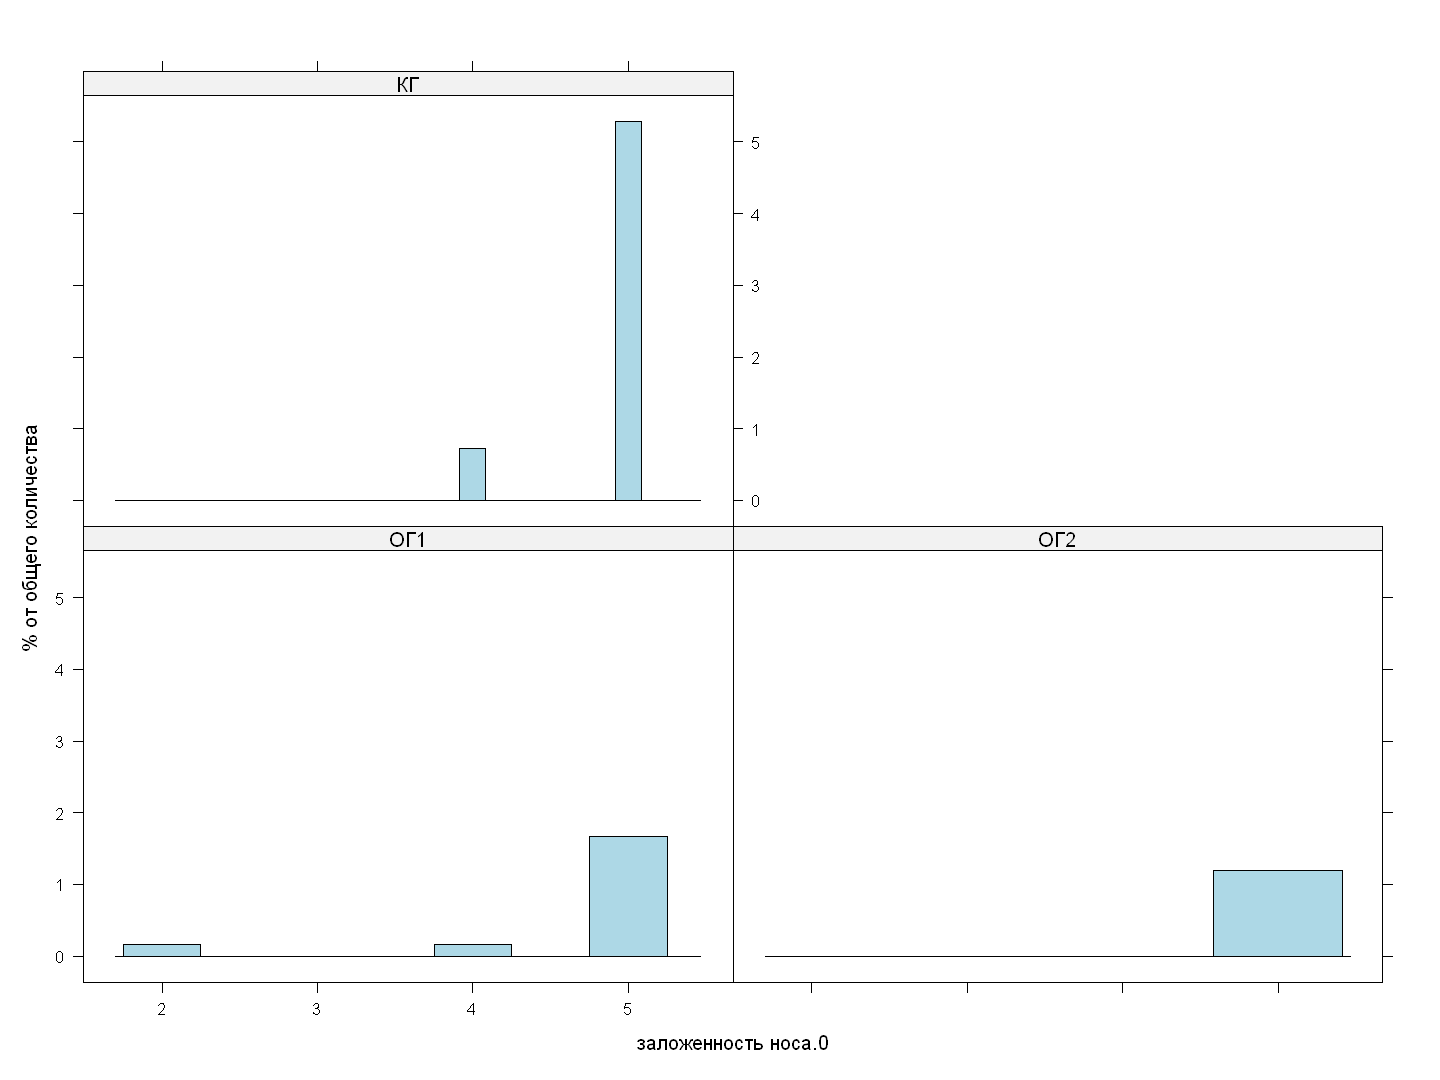

In [65]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [66]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

        mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 4.666667 0.8876254   0  2   5   5   5    5     12
ОГ2 5.000000 0.0000000   0  5   5   5   5    5     13
КГ  4.880000 0.3316625   0  4   5   5   5    5     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,2,5,5,5,5,4.666667,0.8876254,12,0
ОГ2,5,5,5,5,5,5.000000,0.0000000,13,0
КГ,4,5,5,5,5,4.880000,0.3316625,25,0


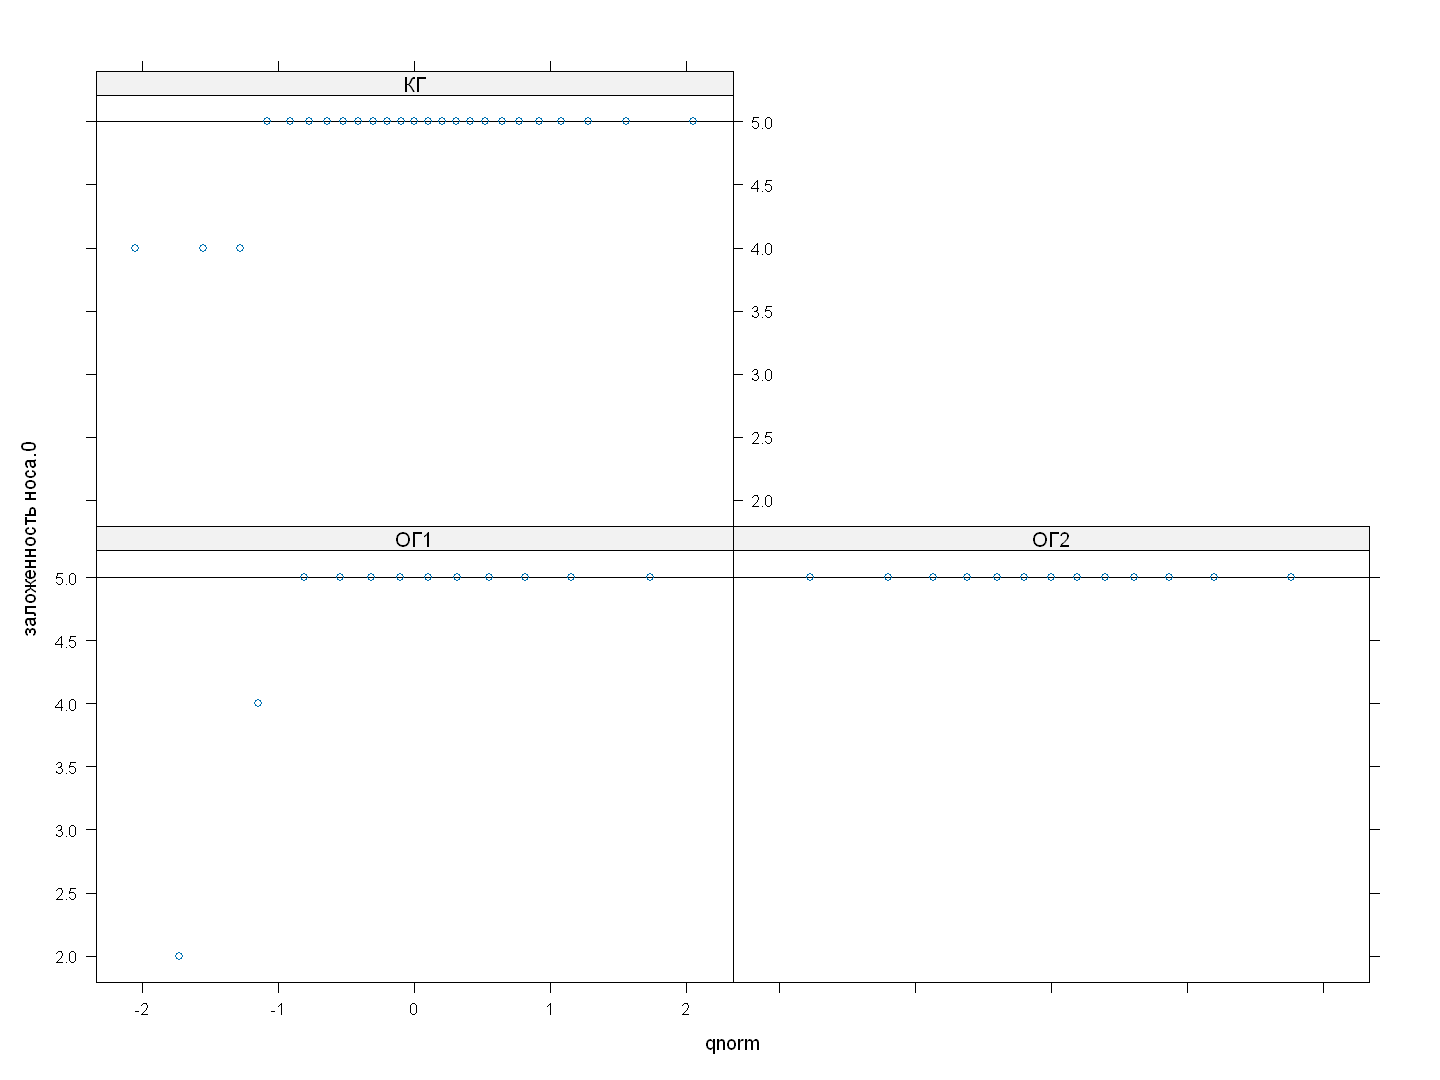

In [67]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

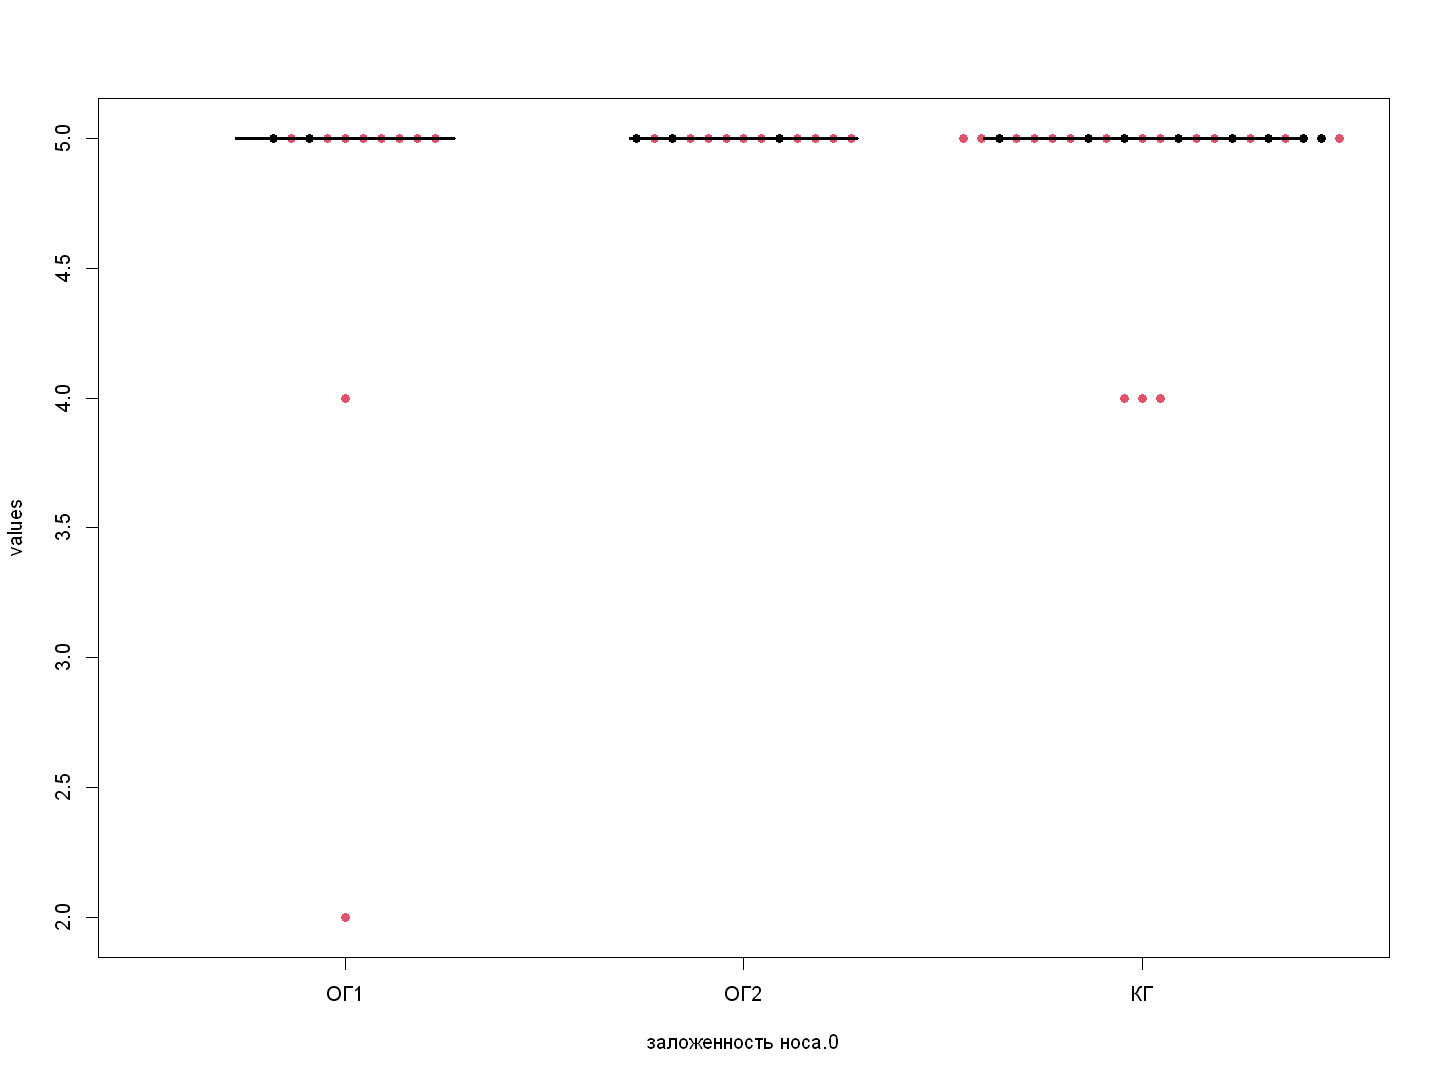

In [68]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [69]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.45002, p-value = 7.742e-06

Группа — ОГ2Error in h(simpleError(msg, call)) : 
  error in evaluating the argument 'x' in selecting a method for function 'print': all 'x' values are identical
Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.3842, p-value = 3.216e-09



In [70]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = Inf, df = 2, p-value < 2.2e-16


### Сравнение, нормальные распределения

In [71]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares   0.713333 11.306667
Deg. of Freedom         2        47

Residual standard error: 0.4904767
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2  0.713  0.3567   1.483  0.237
Residuals   47 11.307  0.2406               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
              diff        lwr       upr     p adj
ОГ2-ОГ1  0.3333333 -0.1418523 0.8085189 0.2167465
КГ-ОГ1   0.2133333 -0.2035320 0.6301987 0.4368269
КГ-ОГ2  -0.1200000 -0.5258875 0.2858875 0.7555864


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -1.3009, df = 11, p-value = 0.2199
alternative hypothesis: true difference in means is n

### Сравнение, распределение не нормальное

In [72]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 2.1671, df = 2, p-value = 0.3384

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ1-ОГ2 4.291667     13.97036       FALSE
ОГ1-КГ  1.351667     12.25576       FALSE
ОГ2-КГ  2.940000     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 65, p-value = 0.1486
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = -1.5023, p-value = 0.22
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 141.5, p-value = 0.6618
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test


## заложенность носа.3

### Общее

In [73]:
parname <- "заложенность носа.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

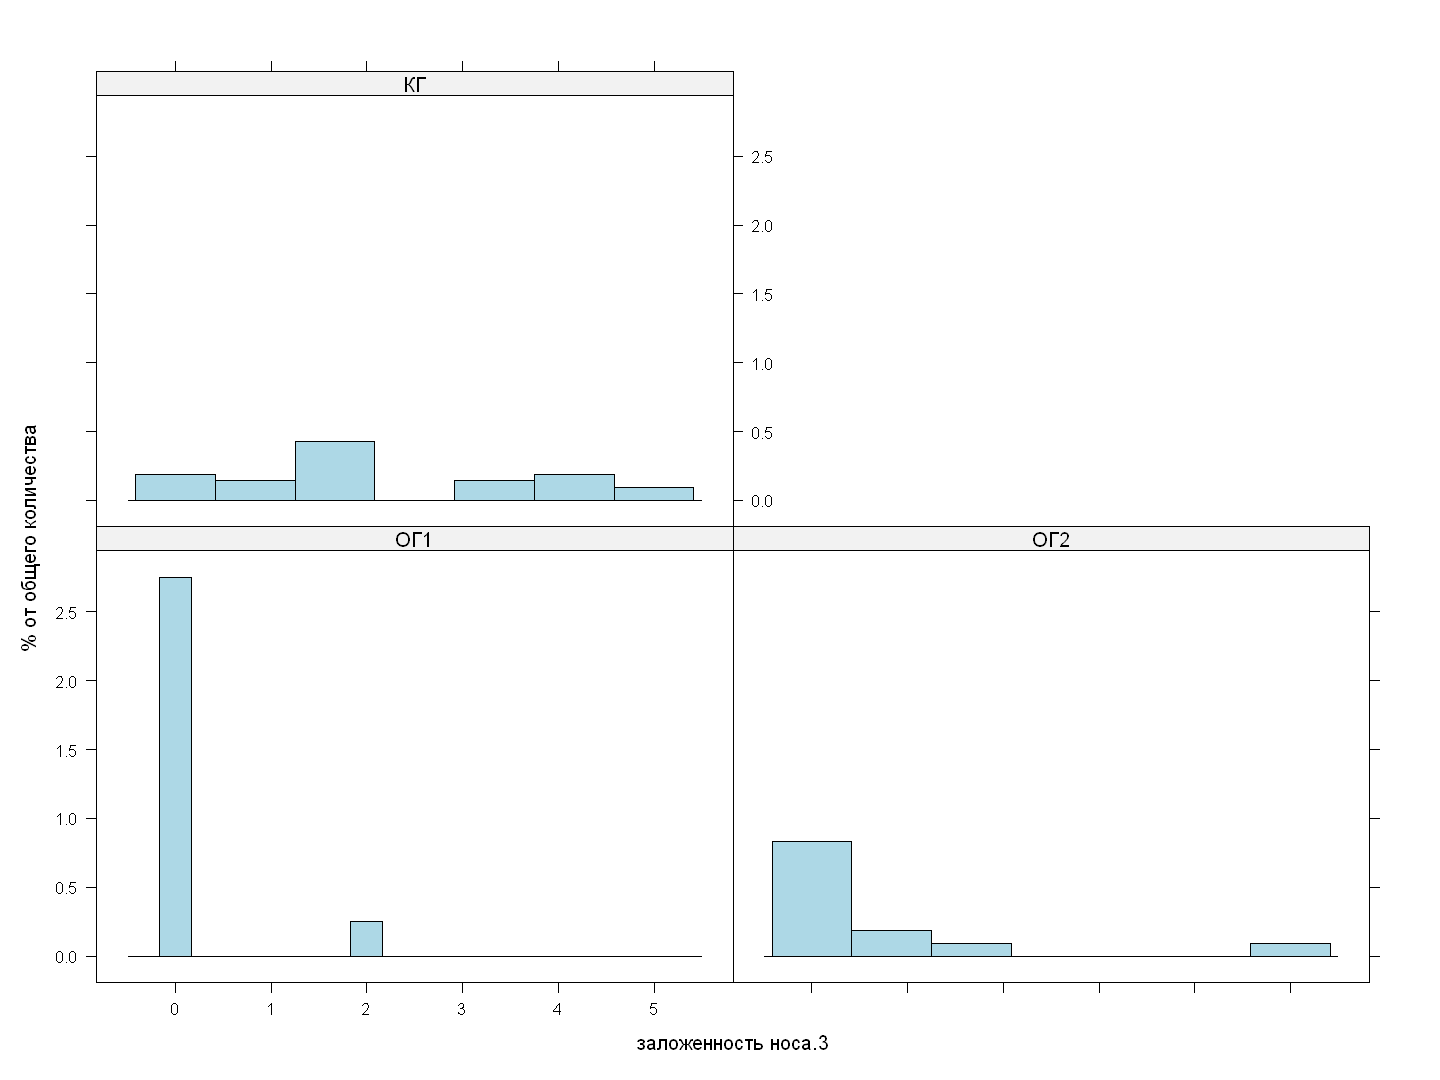

In [74]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [75]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 0.1666667 0.5773503   0  0   0   0   0    2     12
ОГ2 0.6923077 1.4366985   1  0   0   0   1    5     13
КГ  2.2400000 1.5077577   2  0   1   2   3    5     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,0,0,2,0.1666667,0.5773503,12,0
ОГ2,0,0,0,1,5,0.6923077,1.4366985,13,0
КГ,0,1,2,3,5,2.2400000,1.5077577,25,0


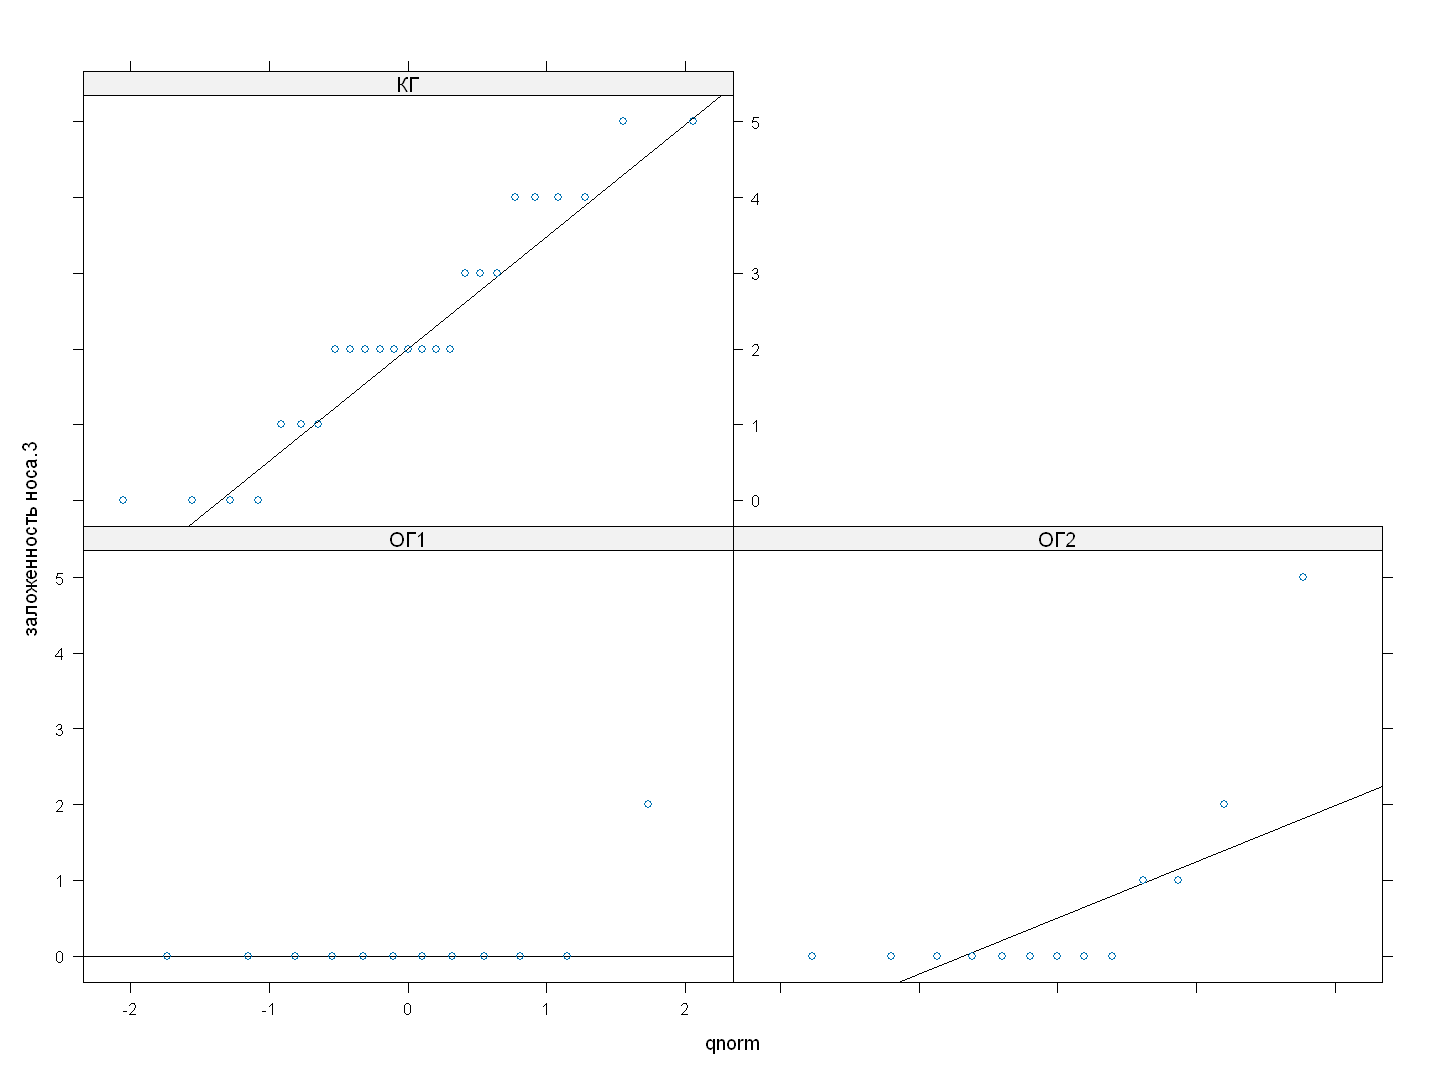

In [76]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

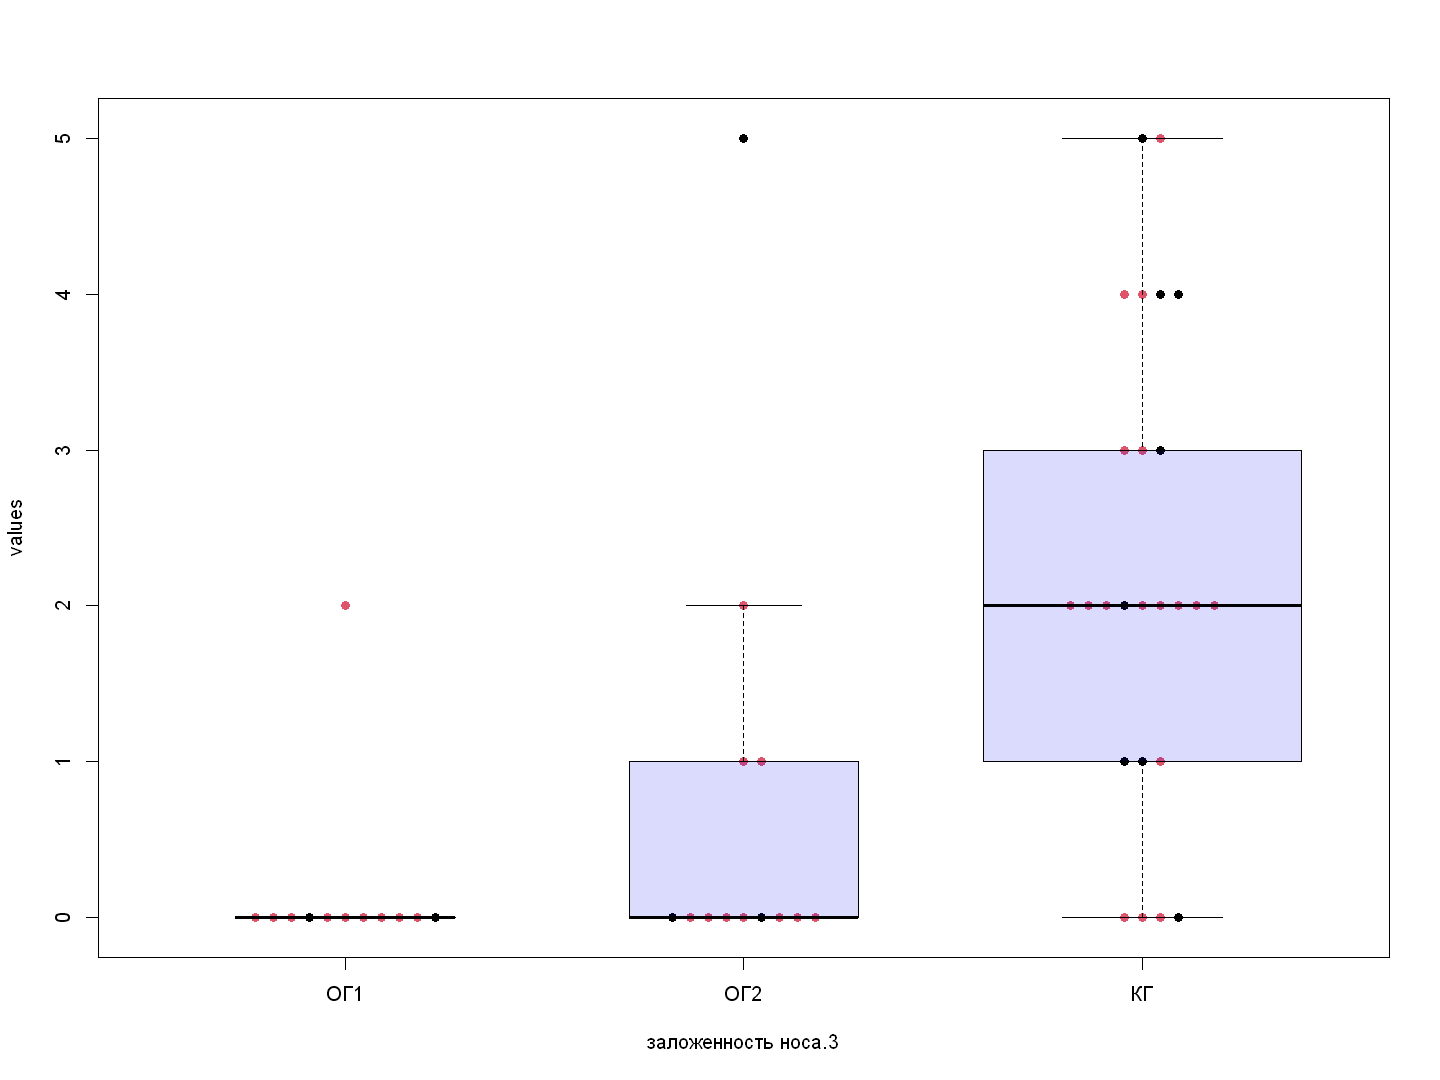

In [77]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [78]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.32693, p-value = 1.207e-06

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.56958, p-value = 3.62e-05

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.92289, p-value = 0.05964



In [79]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 10.078, df = 2, p-value = 0.006481


### Сравнение, нормальные распределения

In [80]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares    42.2241   82.9959
Deg. of Freedom         2        47

Residual standard error: 1.32886
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value   Pr(>F)    
parameter    2  42.22  21.112   11.96 6.35e-05 ***
Residuals   47  83.00   1.766                     
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
            diff        lwr      upr     p adj
ОГ2-ОГ1 0.525641 -0.7617909 1.813073 0.5879440
КГ-ОГ1  2.073333  0.9439099 3.202757 0.0001568
КГ-ОГ2  1.547692  0.4480114 2.647373 0.0038164


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -1.217, df = 16.0

### Сравнение, распределение не нормальное

In [81]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 20.549, df = 2, p-value = 3.45e-05

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
          obs.dif critical.dif stat.signif
ОГ1-ОГ2  4.894231     13.97036       FALSE
ОГ1-КГ  19.705000     12.25576        TRUE
ОГ2-КГ  14.810769     11.93301        TRUE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 61, p-value = 0.1987
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = -1.3241, p-value = 0.2894
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 33.5, p-value = 8.102e-05
alternative hypothesis: true location shift is not equal to 0


	Exact General Independ

## аносмия и потеря вкуса.0

### Общее

In [82]:
parname <- "аносмия и потеря вкуса.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

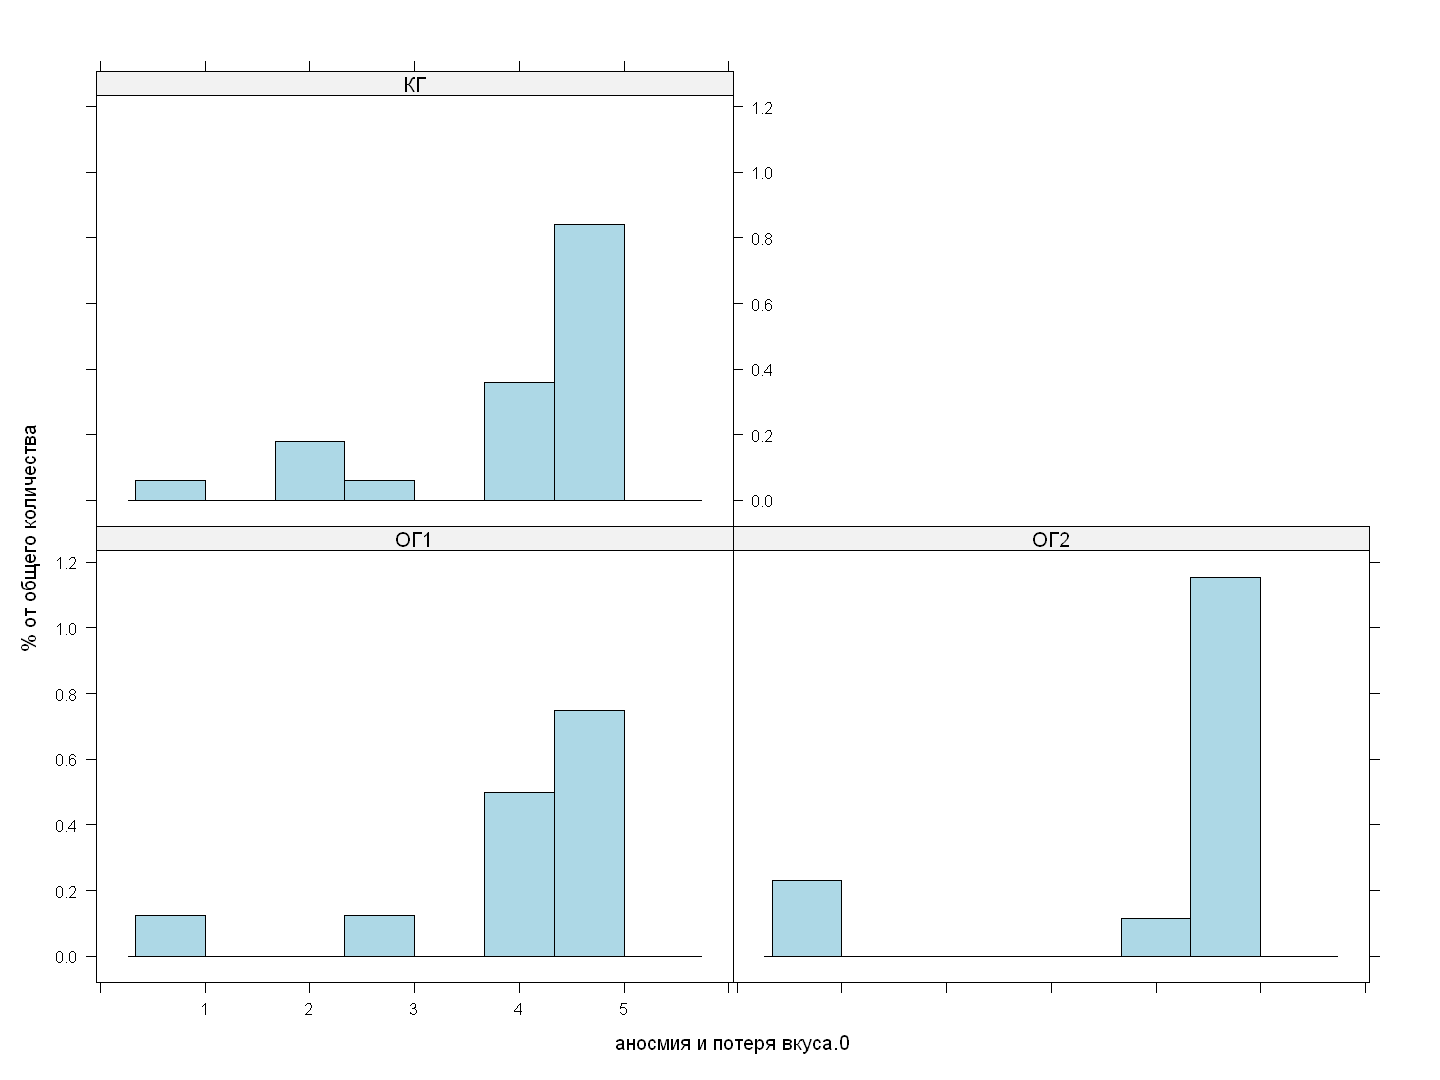

In [83]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [84]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

        mean       sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 4.166667 1.193416   1  1   4 4.5   5    5     12
ОГ2 4.307692 1.493576   0  1   5 5.0   5    5     13
КГ  4.160000 1.213809   1  1   4 5.0   5    5     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,1,4,4.5,5,5,4.166667,1.193416,12,0
ОГ2,1,5,5.0,5,5,4.307692,1.493576,13,0
КГ,1,4,5.0,5,5,4.160000,1.213809,25,0


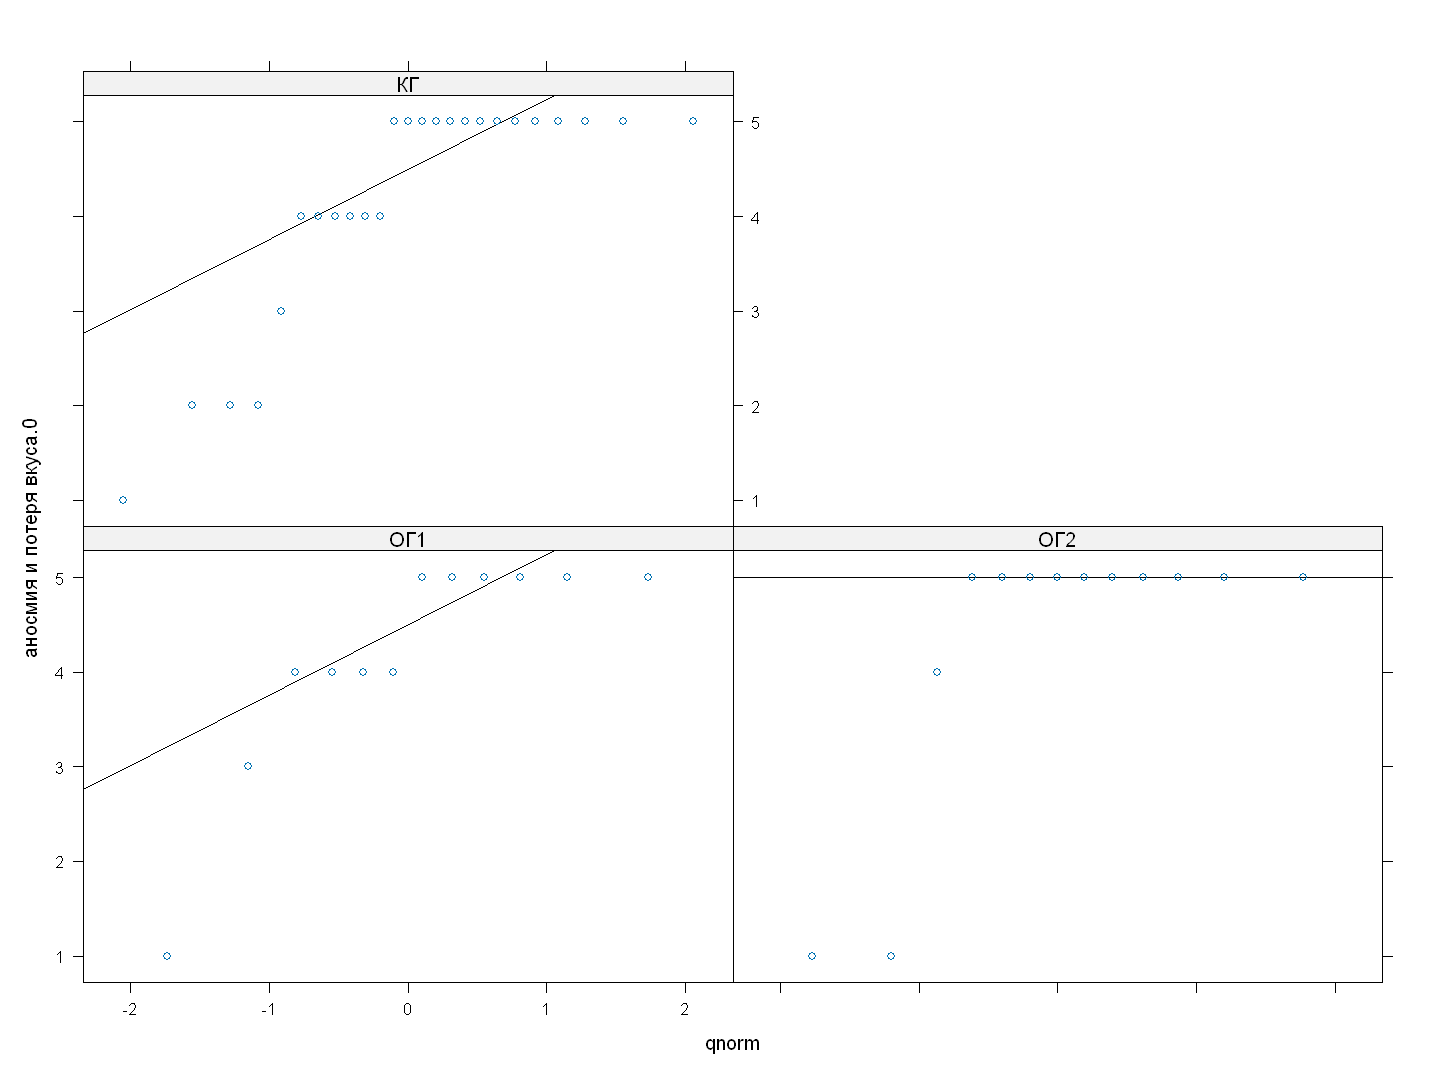

In [85]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

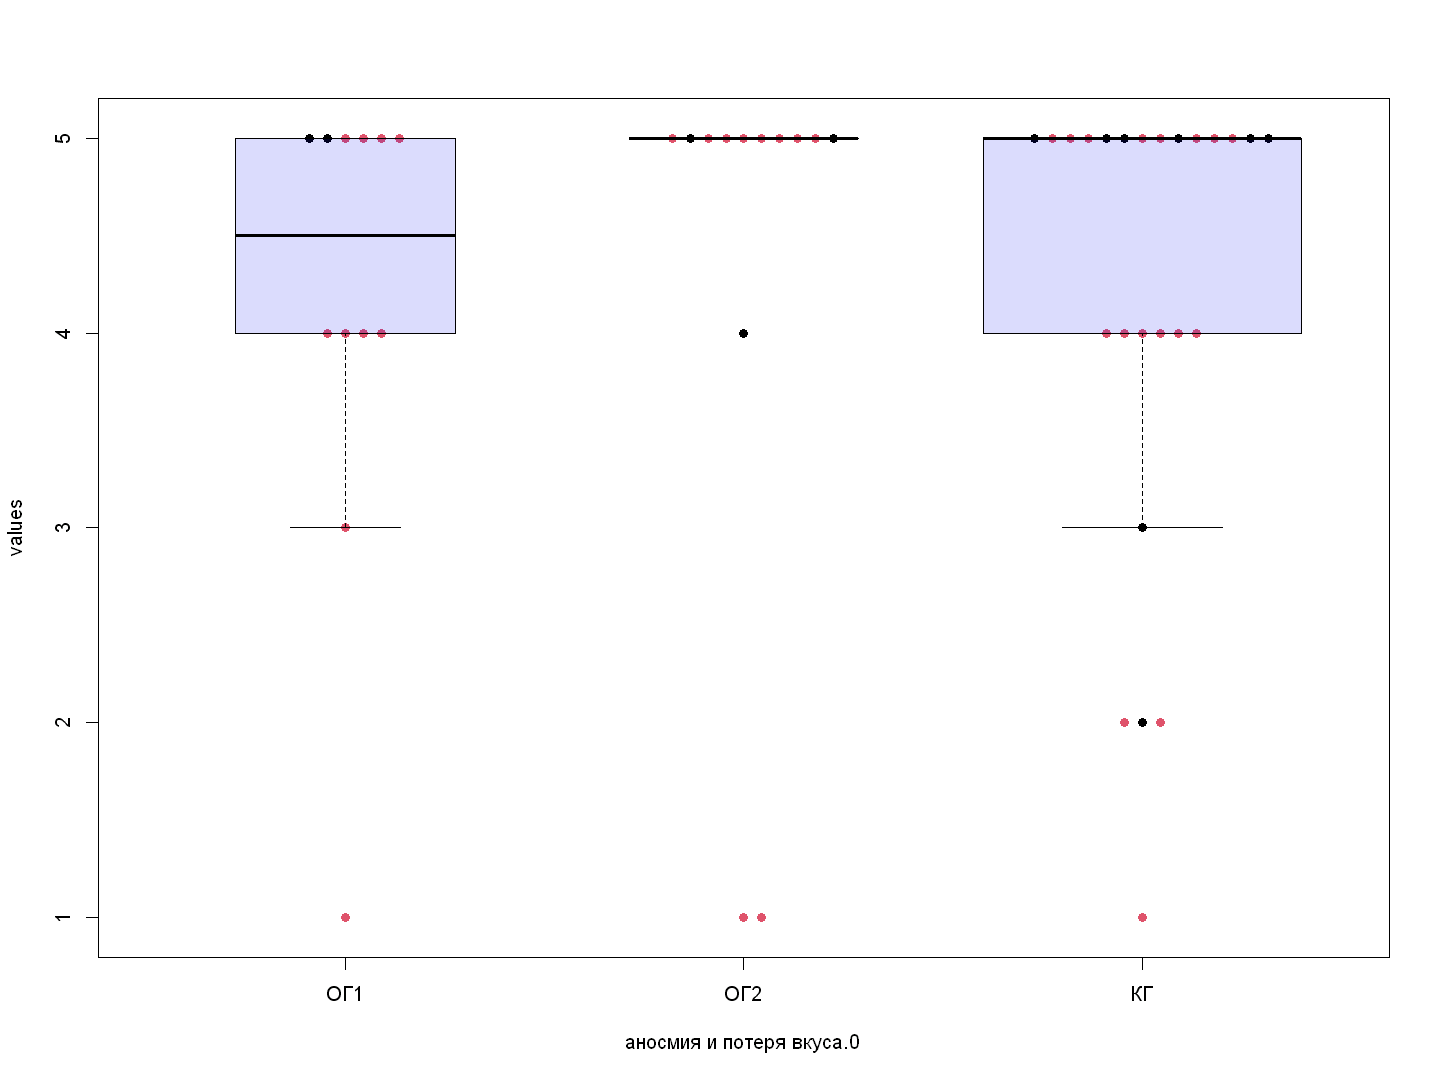

In [86]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [87]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.72537, p-value = 0.001496

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.51547, p-value = 1.333e-05

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.7198, p-value = 1.362e-05



In [88]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 0.83915, df = 2, p-value = 0.6573


### Сравнение, нормальные распределения

In [89]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares     0.2041   77.7959
Deg. of Freedom         2        47

Residual standard error: 1.286558
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2    0.2  0.1021   0.062   0.94
Residuals   47   77.8  1.6552               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
                diff       lwr       upr     p adj
ОГ2-ОГ1  0.141025641 -1.105423 1.3874741 0.9595477
КГ-ОГ1  -0.006666667 -1.100137 1.0868033 0.9998800
КГ-ОГ2  -0.147692308 -1.212367 0.9169819 0.9398433


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -0.26175, df = 22.565, p-value = 0.7959
alternative hypothesis: true difference in me

### Сравнение, распределение не нормальное

In [90]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 1.2444, df = 2, p-value = 0.5368

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
          obs.dif critical.dif stat.signif
ОГ1-ОГ2 5.1794872     13.97036       FALSE
ОГ1-КГ  0.9733333     12.25576       FALSE
ОГ2-КГ  4.2061538     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 61, p-value = 0.2933
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = -1.0828, p-value = 0.33
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 145, p-value = 0.8721
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Tes

## аносмия и потеря вкуса.3

### Общее

In [91]:
parname <- "аносмия и потеря вкуса.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

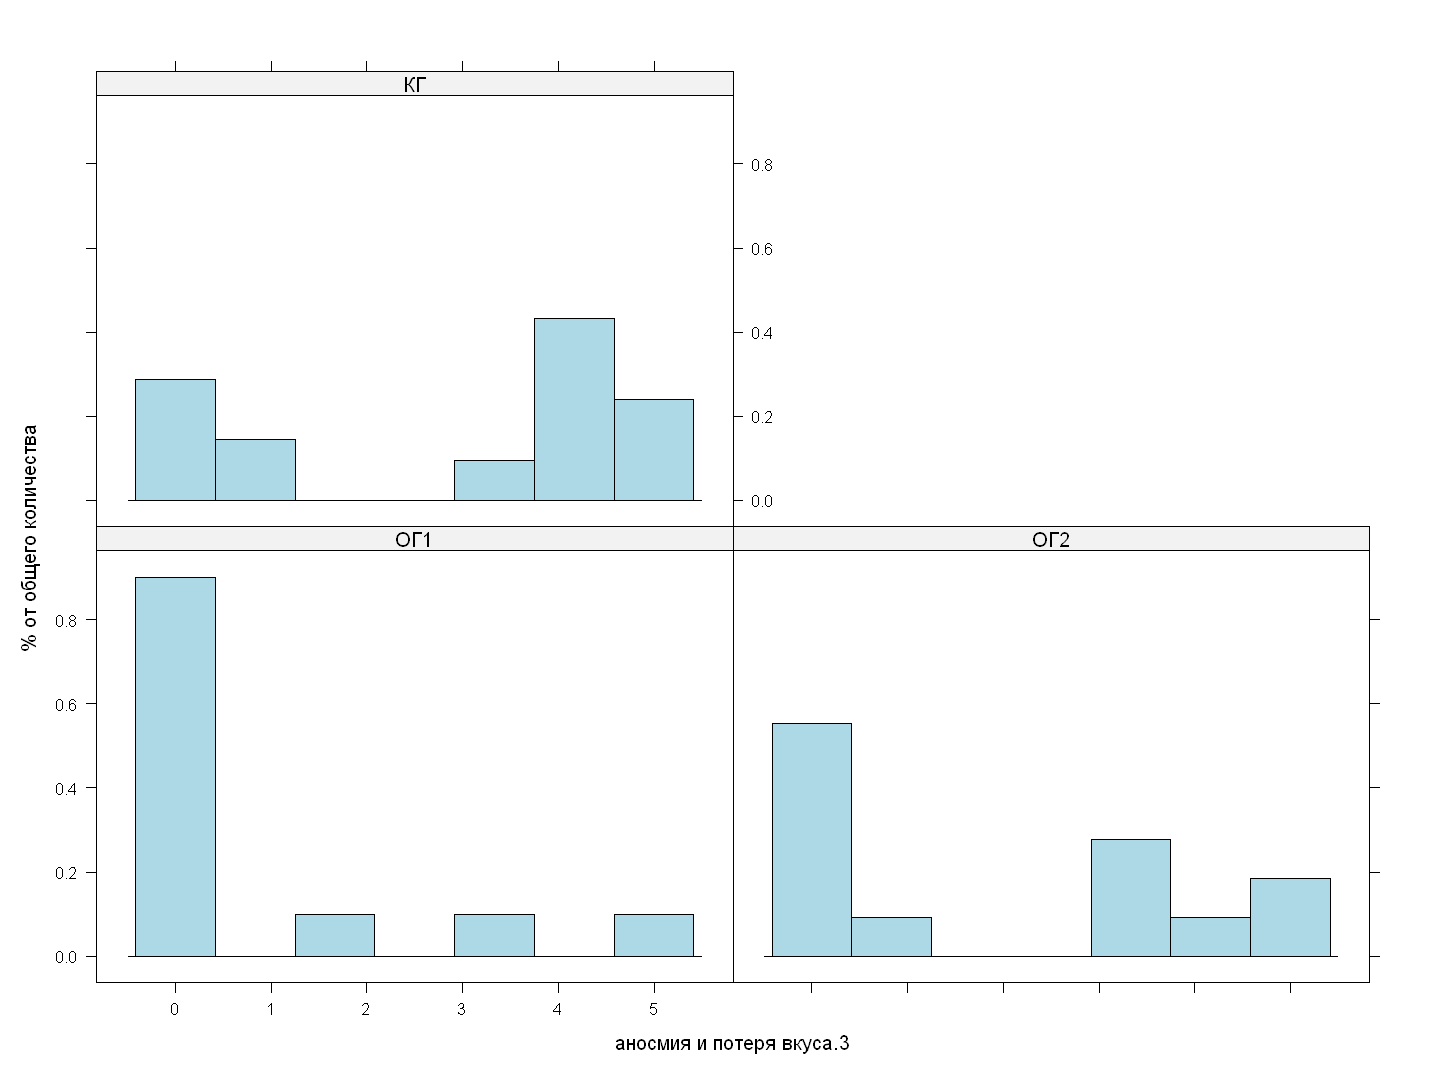

In [92]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [93]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean       sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 0.8333333 1.642245 0.5  0   0   0 0.5    5     12
ОГ2 1.8461538 2.034951 3.0  0   0   1 3.0    5     13
КГ  2.8000000 1.979057 3.0  0   1   4 4.0    5     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,0,0.5,5,0.8333333,1.642245,12,0
ОГ2,0,0,1,3.0,5,1.8461538,2.034951,13,0
КГ,0,1,4,4.0,5,2.8000000,1.979057,25,0


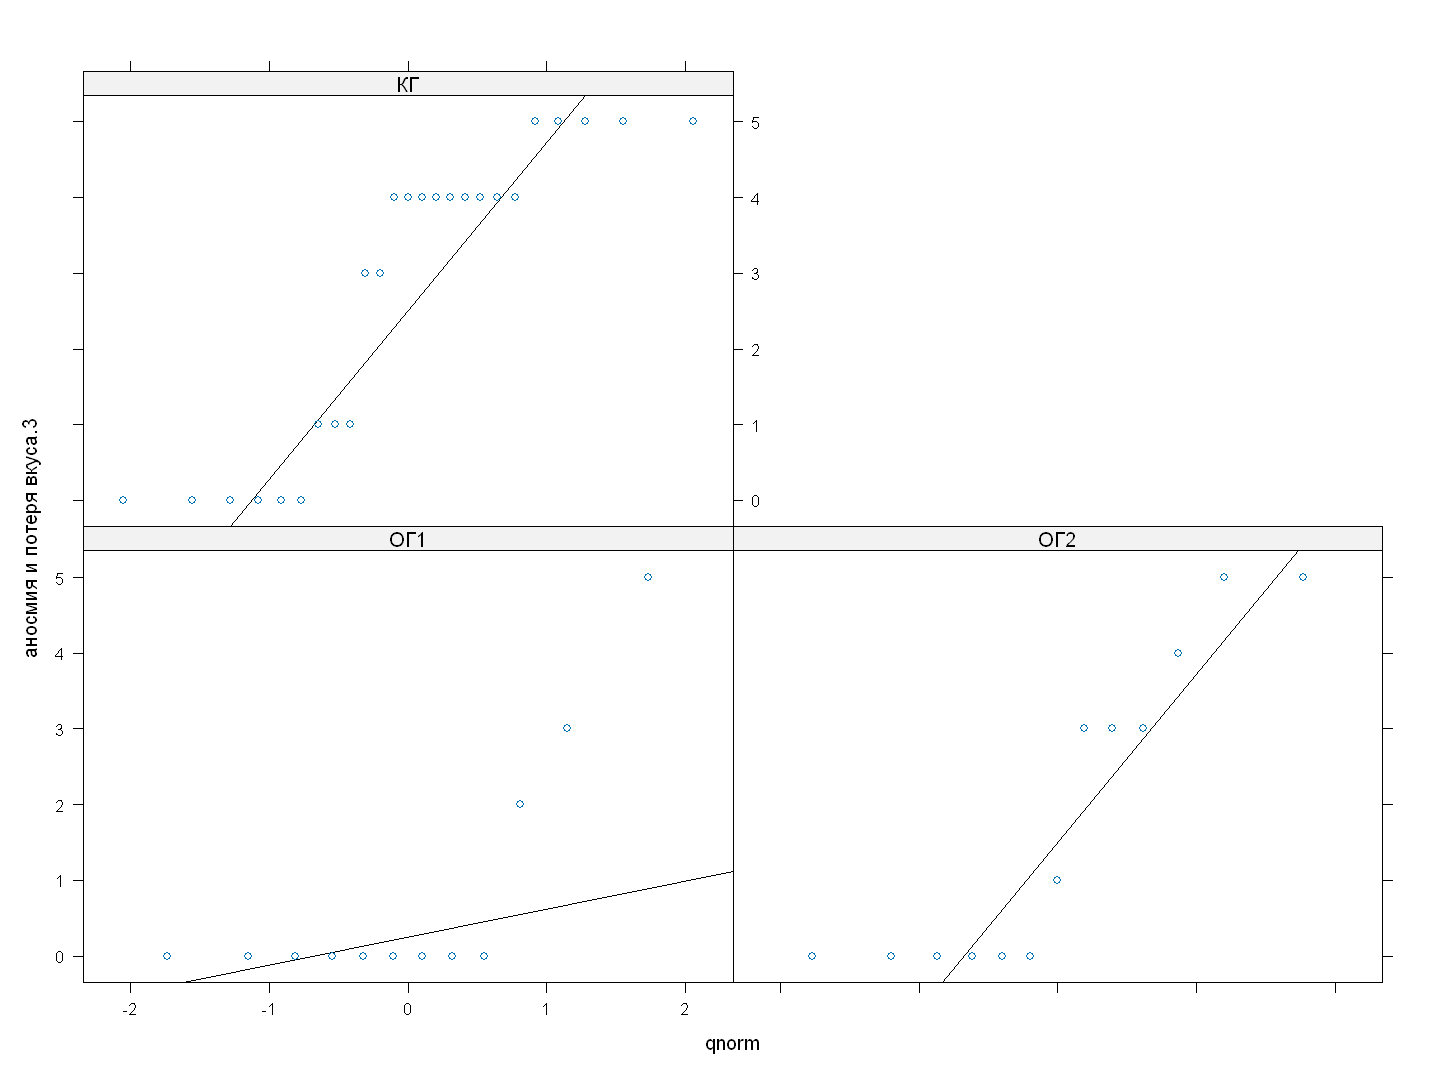

In [94]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

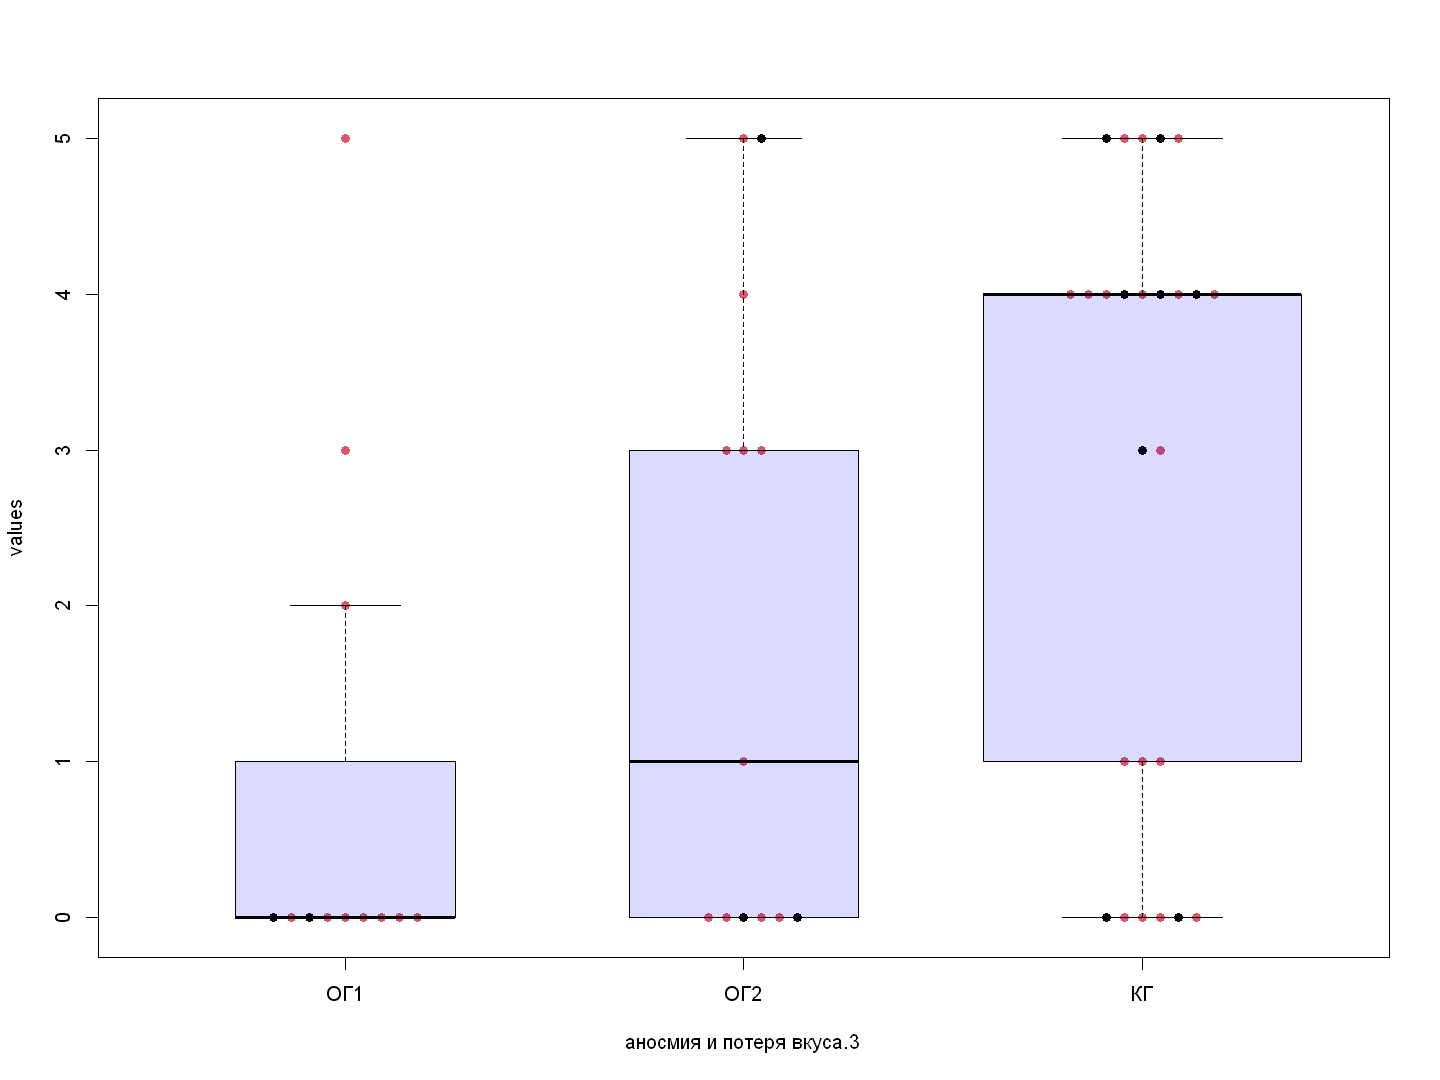

In [95]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [96]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.59574, p-value = 9.886e-05

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.80145, p-value = 0.007093

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.80325, p-value = 0.0002577



In [97]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 0.59536, df = 2, p-value = 0.7425


### Сравнение, нормальные распределения

In [98]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares   32.32103 173.35897
Deg. of Freedom         2        47

Residual standard error: 1.920544
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)  
parameter    2  32.32  16.161   4.381  0.018 *
Residuals   47 173.36   3.688                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
             diff        lwr      upr     p adj
ОГ2-ОГ1 1.0128205 -0.8478485 2.873490 0.3927769
КГ-ОГ1  1.9666667  0.3343603 3.598973 0.0147143
КГ-ОГ2  0.9538462 -0.6354746 2.543167 0.3228842


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -1.3741, df = 22.622, p-

### Сравнение, распределение не нормальное

In [99]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 8.3329, df = 2, p-value = 0.01551

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
          obs.dif critical.dif stat.signif
ОГ1-ОГ2  6.980769     13.97036       FALSE
ОГ1-КГ  13.870000     12.25576        TRUE
ОГ2-КГ   6.889231     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 54.5, p-value = 0.1564
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = -1.448, p-value = 0.1611
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 68.5, p-value = 0.005989
alternative hypothesis: true location shift is not equal to 0


	Exact General Independe

## кашель.0

### Общее

In [100]:
parname <- "кашель.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

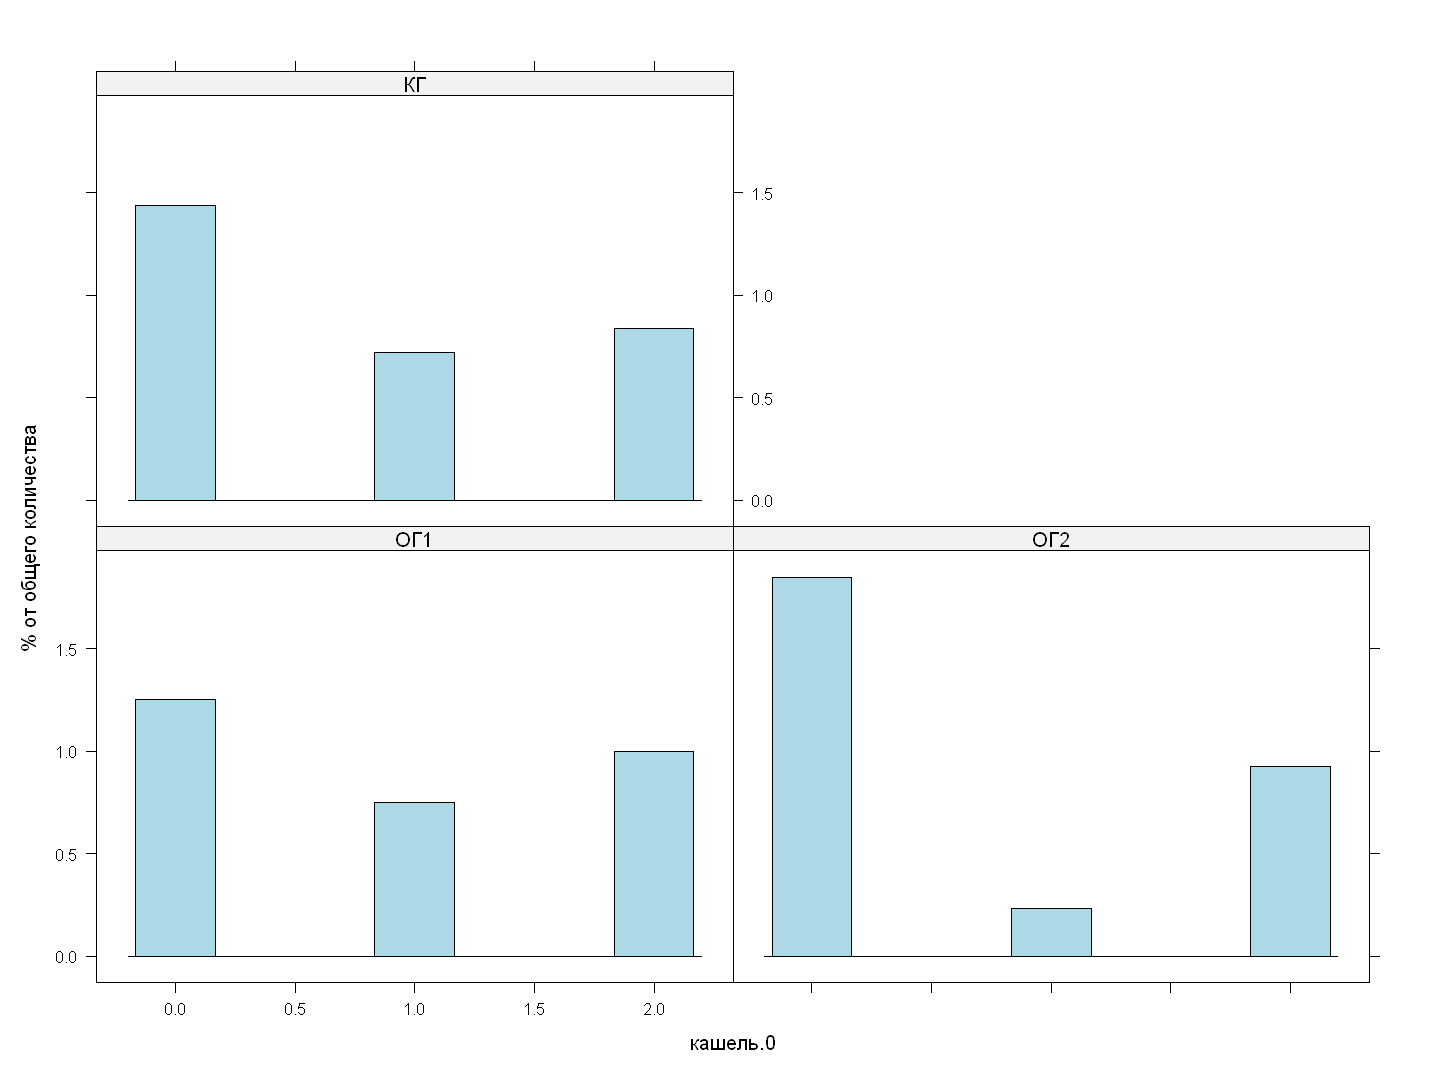

In [101]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [102]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 0.9166667 0.9003366   2  0   0   1   2    2     12
ОГ2 0.6923077 0.9473309   2  0   0   0   2    2     13
КГ  0.8000000 0.8660254   2  0   0   1   2    2     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,1,2,2,0.9166667,0.9003366,12,0
ОГ2,0,0,0,2,2,0.6923077,0.9473309,13,0
КГ,0,0,1,2,2,0.8000000,0.8660254,25,0


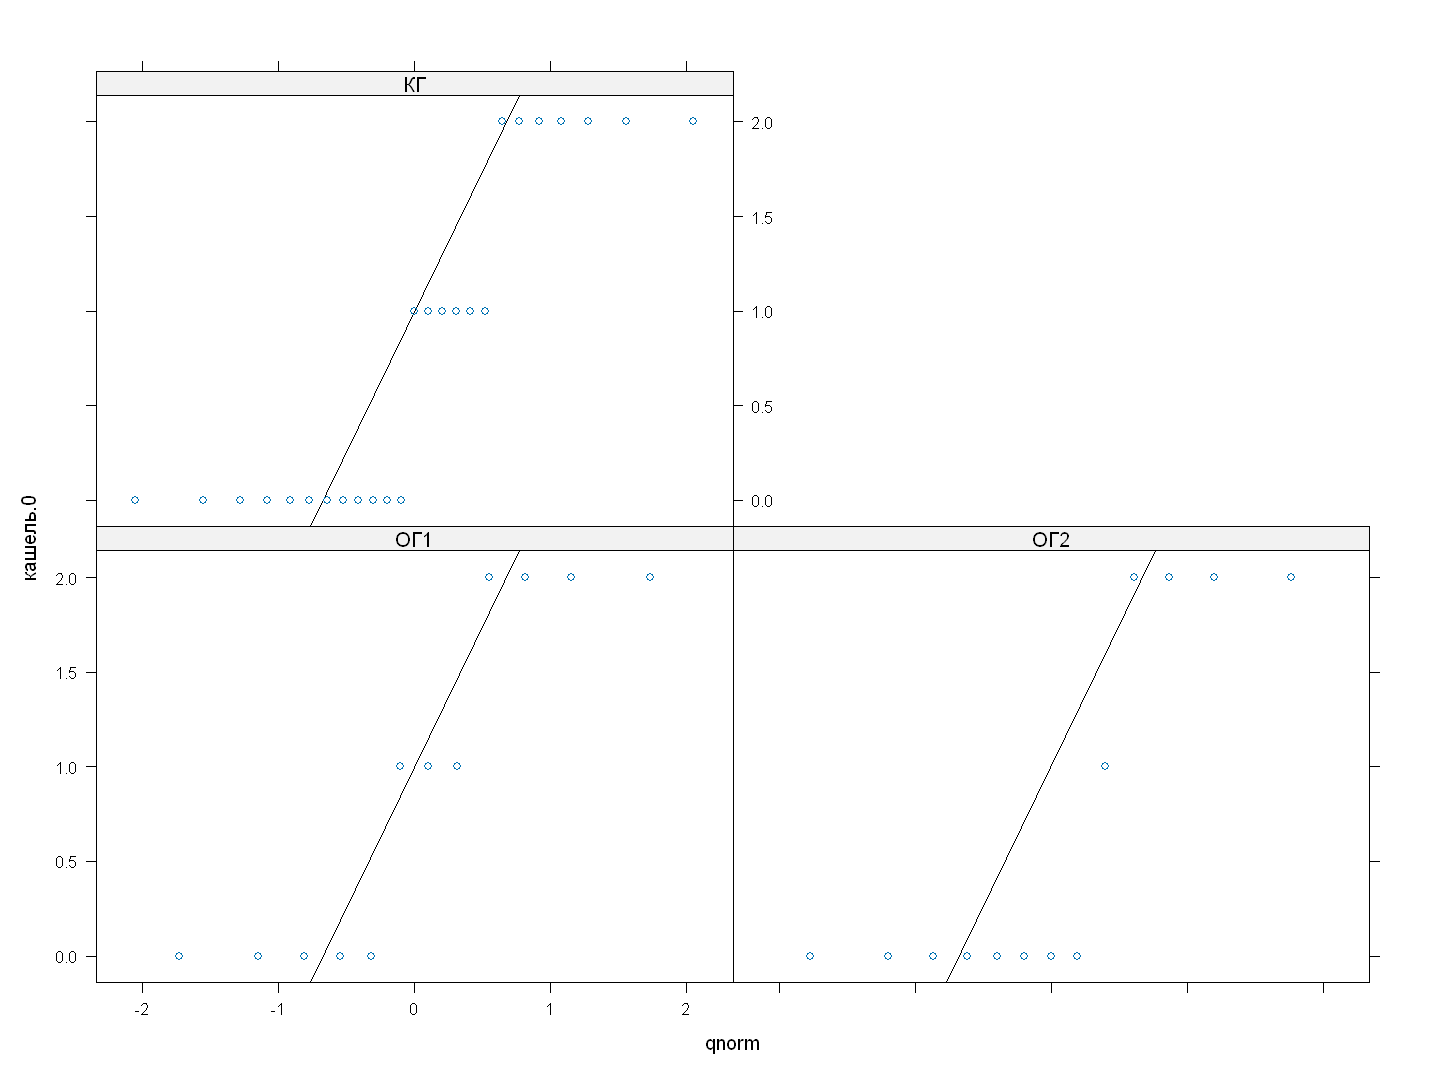

In [103]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

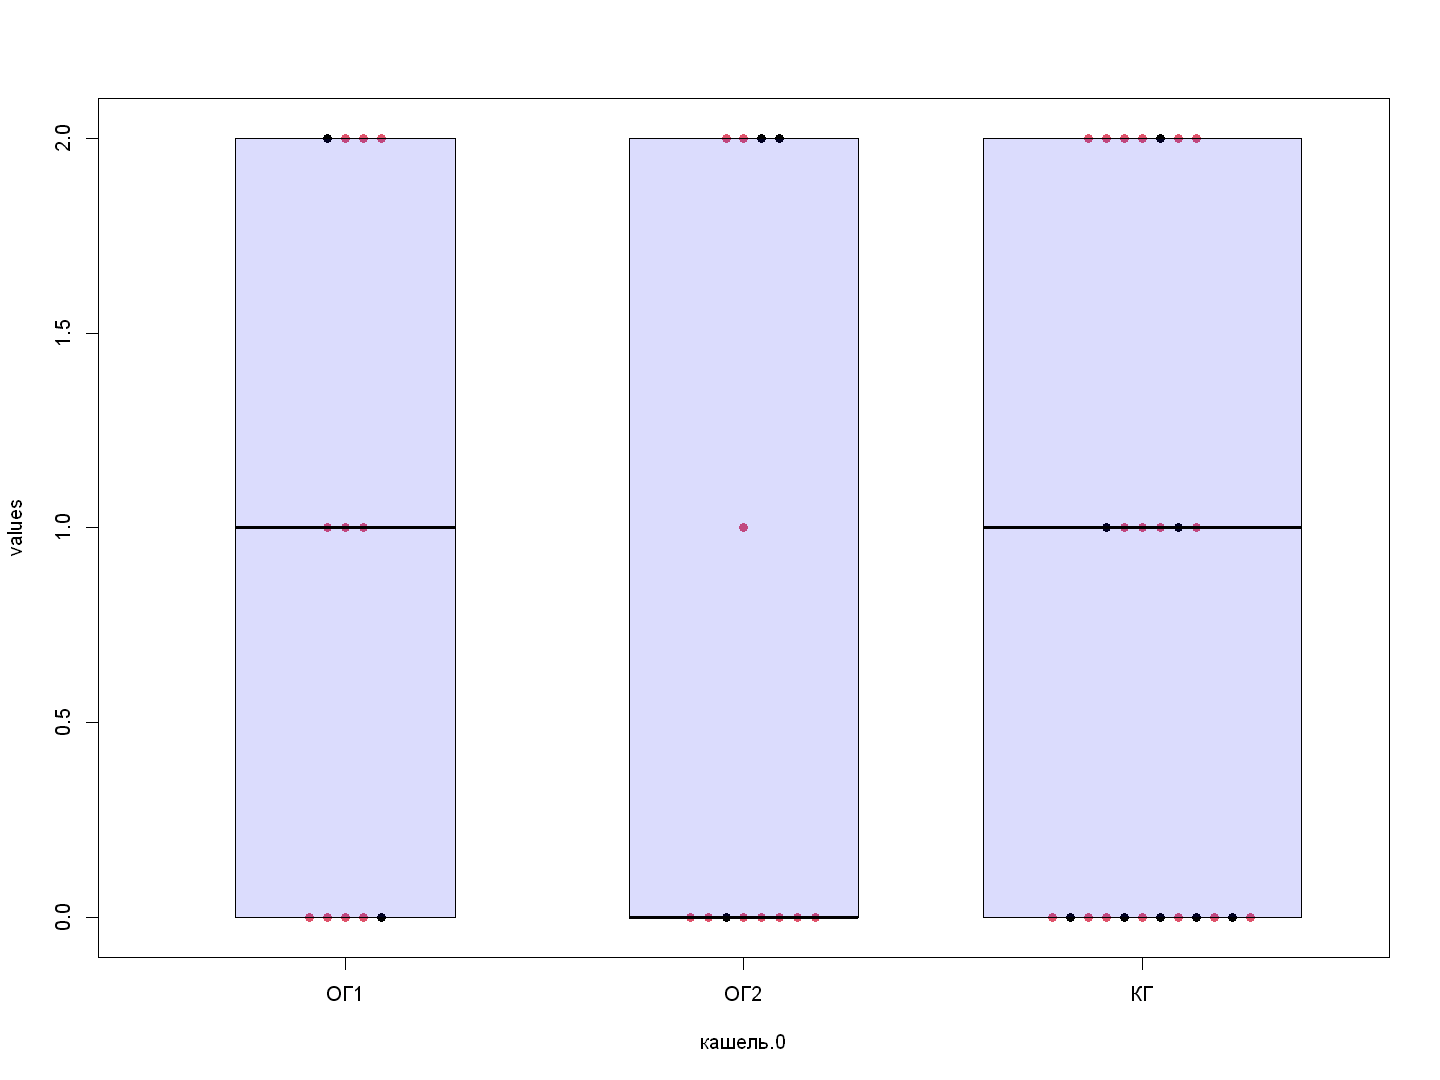

In [104]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [105]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.78119, p-value = 0.00577

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.66222, p-value = 0.0002384

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.7539, p-value = 4.245e-05



In [106]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 0.12799, df = 2, p-value = 0.938


### Сравнение, нормальные распределения

In [107]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares     0.3141   37.6859
Deg. of Freedom         2        47

Residual standard error: 0.8954483
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2   0.31  0.1571   0.196  0.823
Residuals   47  37.69  0.8018               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
              diff        lwr       upr     p adj
ОГ2-ОГ1 -0.2243590 -1.0918908 0.6431728 0.8066984
КГ-ОГ1  -0.1166667 -0.8777250 0.6443916 0.9270594
КГ-ОГ2   0.1076923 -0.6333241 0.8487087 0.9341810


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = 0.60708, df = 22.976, p-value = 0.5498
alternative hypothesis: true difference in means 

### Сравнение, распределение не нормальное

In [108]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 0.50688, df = 2, p-value = 0.7761

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ1-ОГ2 3.798077     13.97036       FALSE
ОГ1-КГ  1.775000     12.25576       FALSE
ОГ2-КГ  2.023077     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 89.5, p-value = 0.5098
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = 0.68915, p-value = 0.5796
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 161, p-value = 0.7138
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Te

## кашель.3

### Общее

In [109]:
parname <- "кашель.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [110]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [111]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd  IQR 0% 25% 50%  75% 100% data:n
ОГ1 0.4166667 0.7929615 0.25  0   0   0 0.25    2     12
ОГ2 0.0000000 0.0000000 0.00  0   0   0 0.00    0     13
КГ  0.7600000 0.8306624 1.00  0   0   1 1.00    2     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,0,0.25,2,0.4166667,0.7929615,12,0
ОГ2,0,0,0,0.00,0,0.0000000,0.0000000,13,0
КГ,0,0,1,1.00,2,0.7600000,0.8306624,25,0


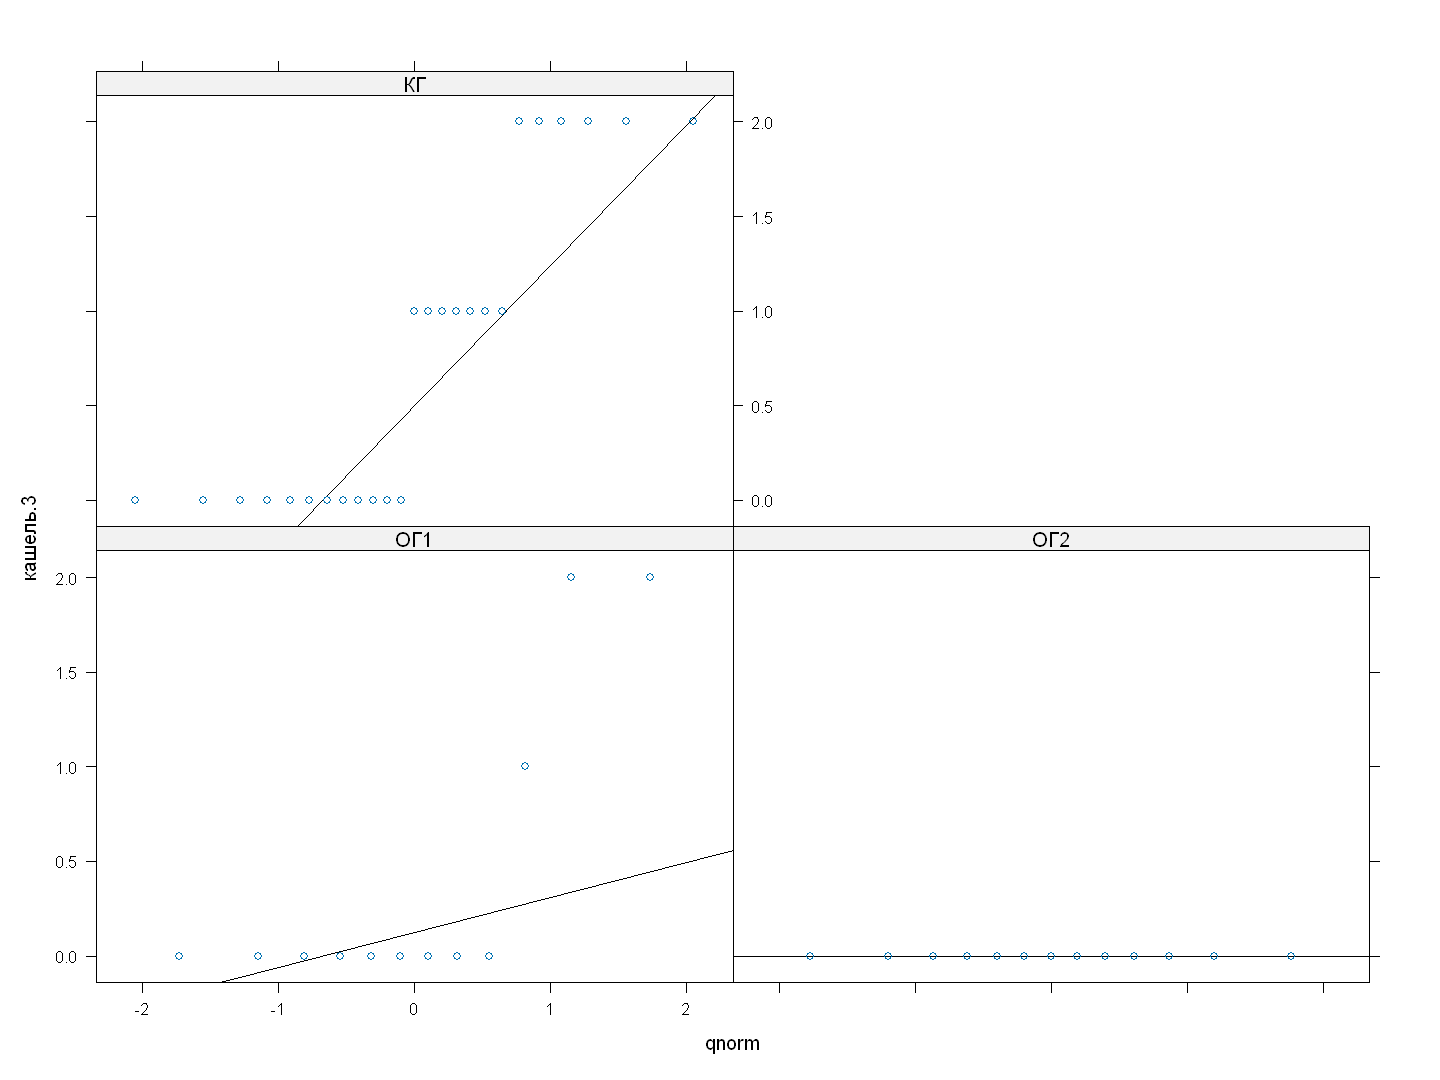

In [112]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

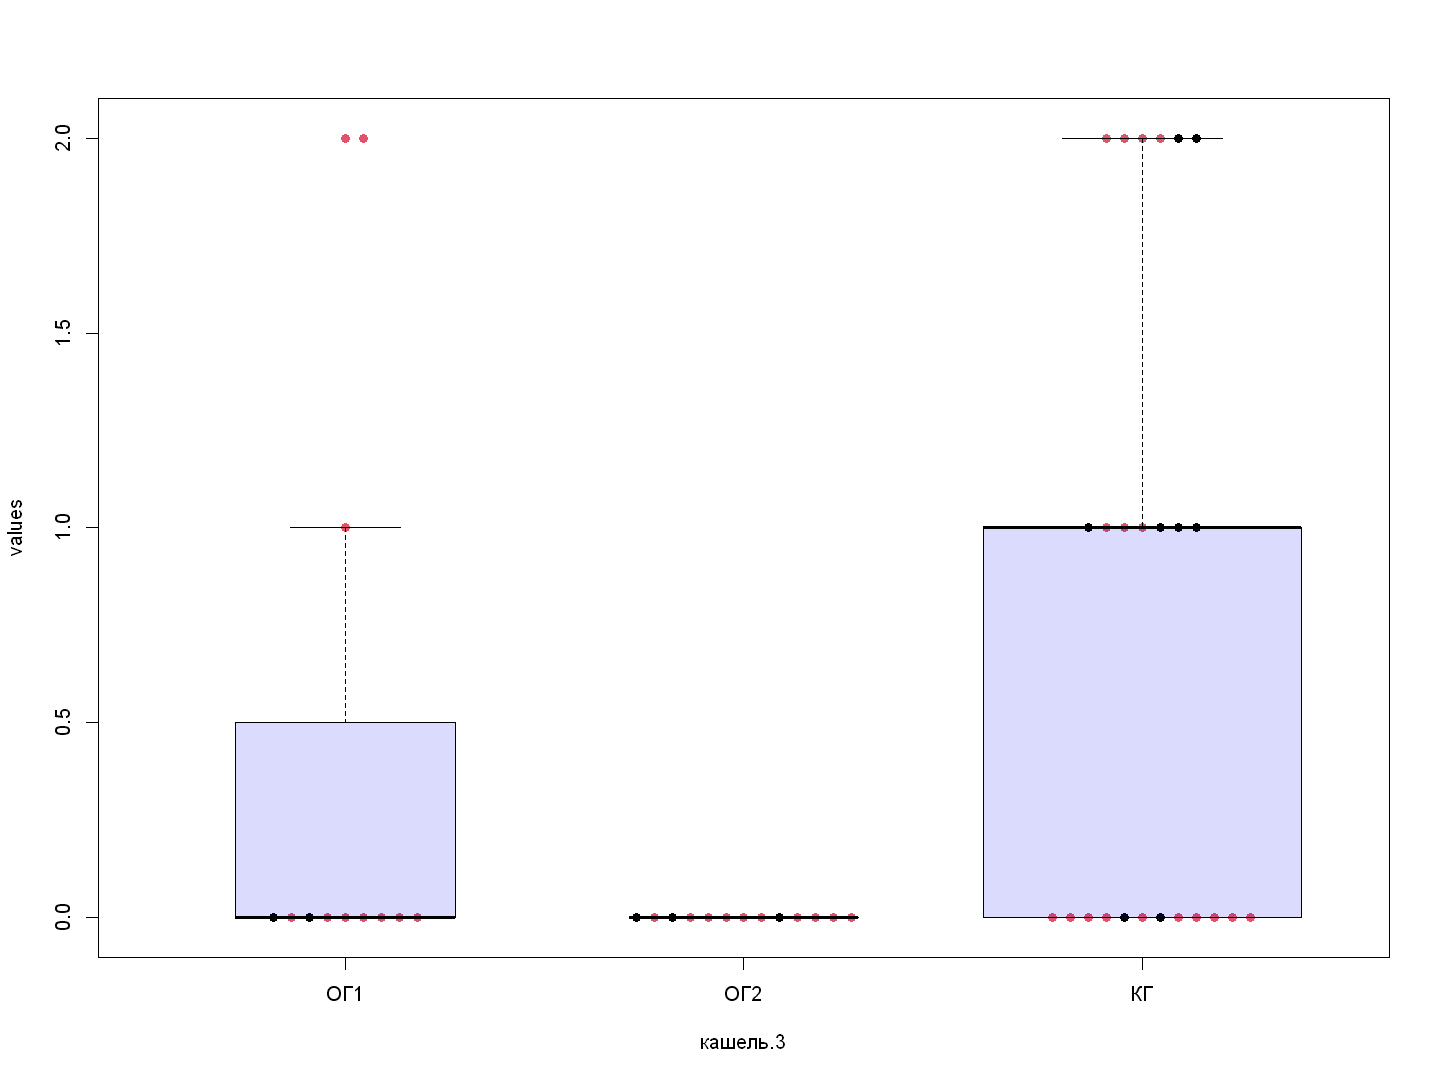

In [113]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [114]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.57518, p-value = 6.711e-05

Группа — ОГ2Error in h(simpleError(msg, call)) : 
  error in evaluating the argument 'x' in selecting a method for function 'print': all 'x' values are identical
Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.76327, p-value = 5.887e-05



In [115]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = Inf, df = 2, p-value < 2.2e-16


### Сравнение, нормальные распределения

In [116]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares   5.003333 23.476667
Deg. of Freedom         2        47

Residual standard error: 0.7067556
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)  
parameter    2  5.003  2.5017   5.008 0.0107 *
Residuals   47 23.477  0.4995                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
              diff        lwr       upr     p adj
ОГ2-ОГ1 -0.4166667 -1.1013885 0.2680552 0.3130863
КГ-ОГ1   0.3433333 -0.2573516 0.9440182 0.3577344
КГ-ОГ2   0.7600000  0.1751337 1.3448663 0.0079578


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = 1.8202, df = 11

### Сравнение, распределение не нормальное

In [117]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 10.012, df = 2, p-value = 0.006698

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
          obs.dif critical.dif stat.signif
ОГ1-ОГ2  6.583333     13.97036       FALSE
ОГ1-КГ   6.256667     12.25576       FALSE
ОГ2-КГ  12.840000     11.93301        TRUE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 97.5, p-value = 0.06705
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = 1.8795, p-value = 0.09565
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 113.5, p-value = 0.1909
alternative hypothesis: true location shift is not equal to 0


	Exact General Indepen

## затекание слизи по задней стенке глотки.0

### Общее

In [118]:
parname <- "затекание слизи по задней стенке глотки.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

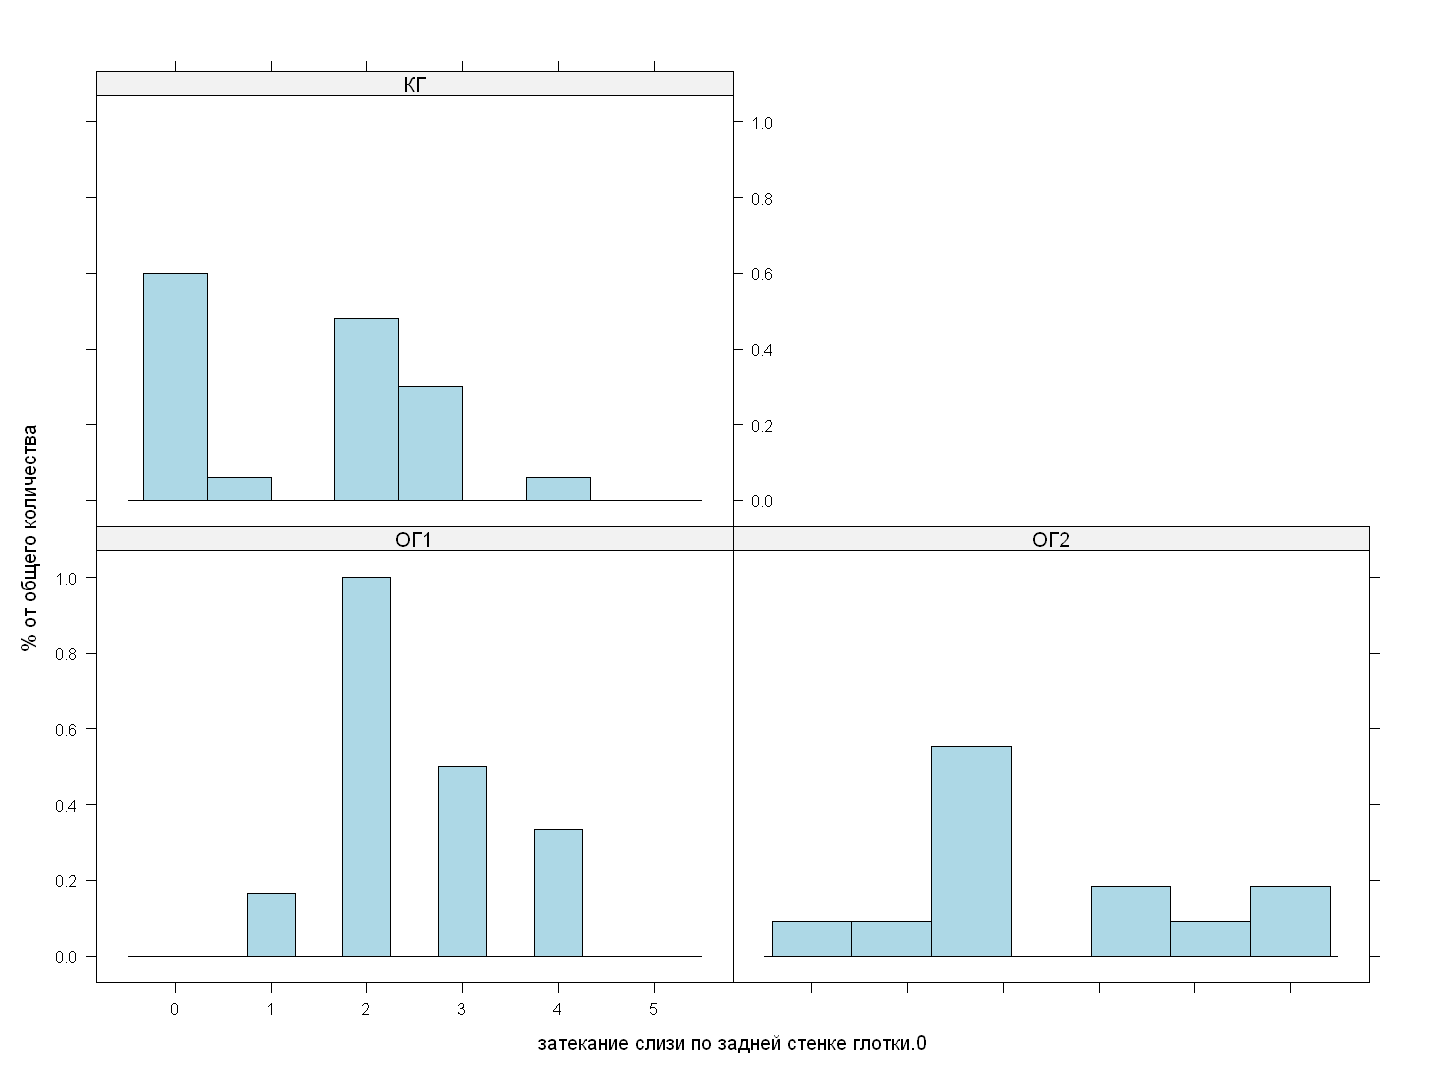

In [119]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [120]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

        mean       sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 2.500000 0.904534   1  1   2   2   3    4     12
ОГ2 2.538462 1.450022   1  0   2   2   3    5     13
КГ  1.440000 1.325393   2  0   0   2   2    4     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,1,2,2,3,4,2.500000,0.904534,12,0
ОГ2,0,2,2,3,5,2.538462,1.450022,13,0
КГ,0,0,2,2,4,1.440000,1.325393,25,0


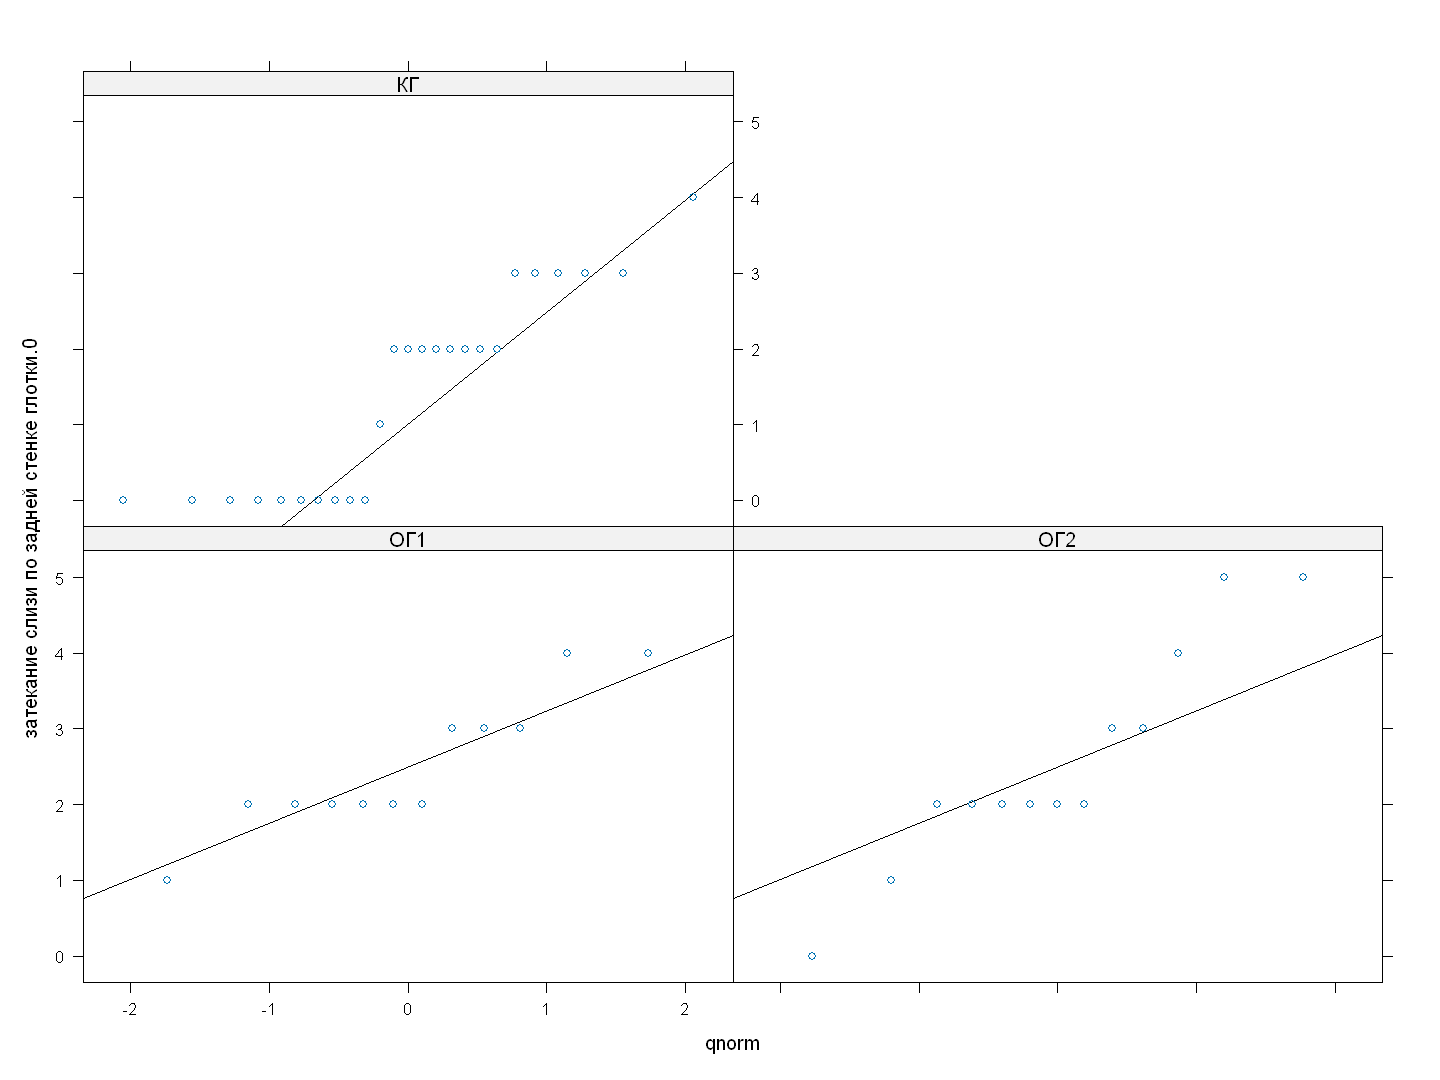

In [121]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

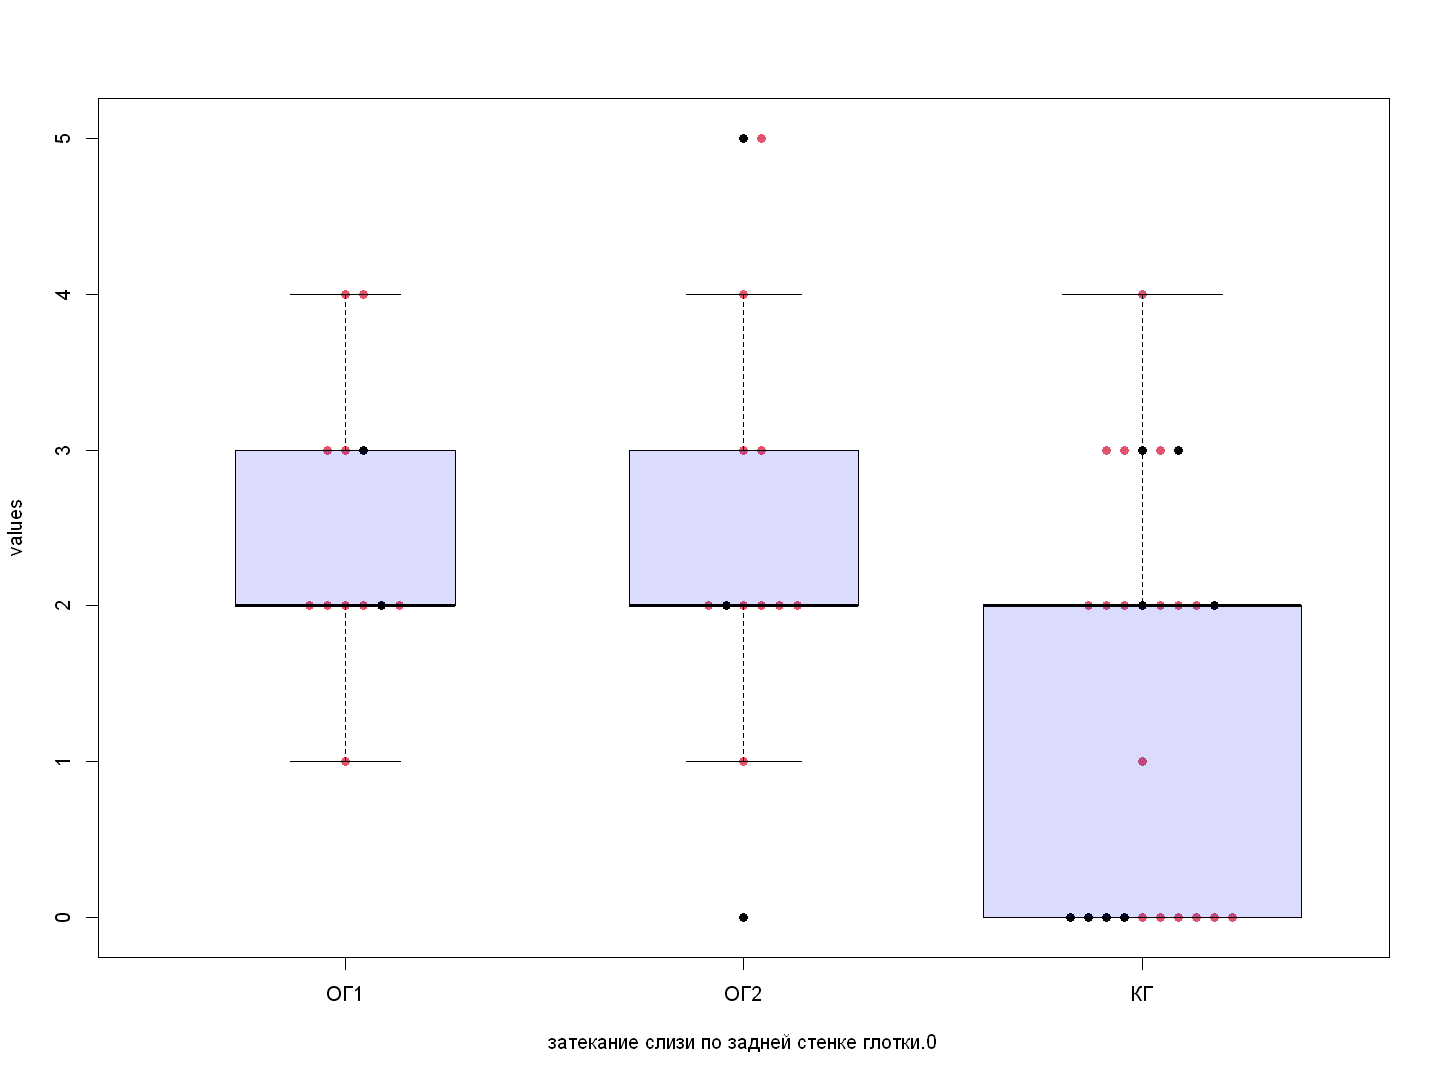

In [122]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [123]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.86693, p-value = 0.05975

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.90268, p-value = 0.1455

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.82925, p-value = 0.000729



In [124]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 2.5145, df = 2, p-value = 0.2844


### Сравнение, нормальные распределения

In [125]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares   14.58923  76.39077
Deg. of Freedom         2        47

Residual standard error: 1.274886
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)  
parameter    2  14.59   7.295   4.488 0.0165 *
Residuals   47  76.39   1.625                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
               diff       lwr         upr     p adj
ОГ2-ОГ1  0.03846154 -1.196679  1.27360217 0.9968740
КГ-ОГ1  -1.06000000 -2.143550  0.02354996 0.0563877
КГ-ОГ2  -1.09846154 -2.153477 -0.04344608 0.0396046


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -0.08021

### Сравнение, распределение не нормальное

In [126]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 6.3912, df = 2, p-value = 0.04094

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
           obs.dif critical.dif stat.signif
ОГ1-ОГ2  0.9198718     13.97036       FALSE
ОГ1-КГ  10.4383333     12.25576       FALSE
ОГ2-КГ   9.5184615     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 79.5, p-value = 0.9538
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = 0.086974, p-value = 0.9422
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 214, p-value = 0.03135
alternative hypothesis: true location shift is not equal to 0


	Exact General Indep

## затекание слизи по задней стенке глотки.3

### Общее

In [127]:
parname <- "затекание слизи по задней стенке глотки.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

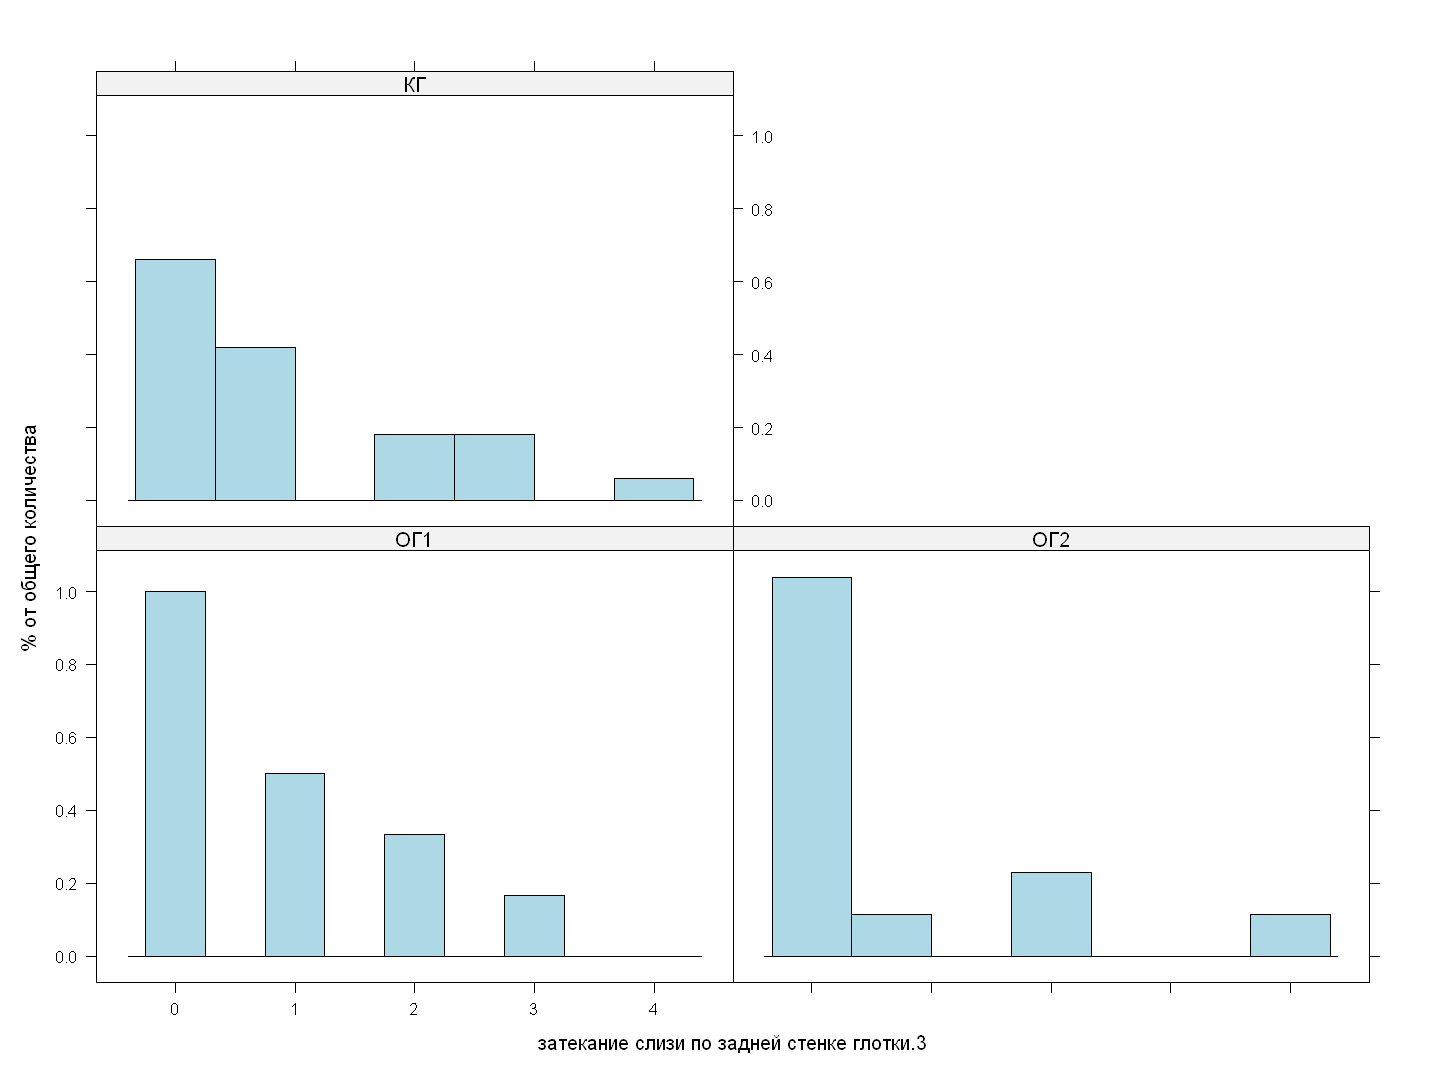

In [128]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [129]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean       sd  IQR 0% 25% 50%  75% 100% data:n
ОГ1 0.8333333 1.029857 1.25  0   0 0.5 1.25    3     12
ОГ2 0.6923077 1.250641 1.00  0   0 0.0 1.00    4     13
КГ  1.0400000 1.206924 2.00  0   0 1.0 2.00    4     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,0.5,1.25,3,0.8333333,1.029857,12,0
ОГ2,0,0,0.0,1.00,4,0.6923077,1.250641,13,0
КГ,0,0,1.0,2.00,4,1.0400000,1.206924,25,0


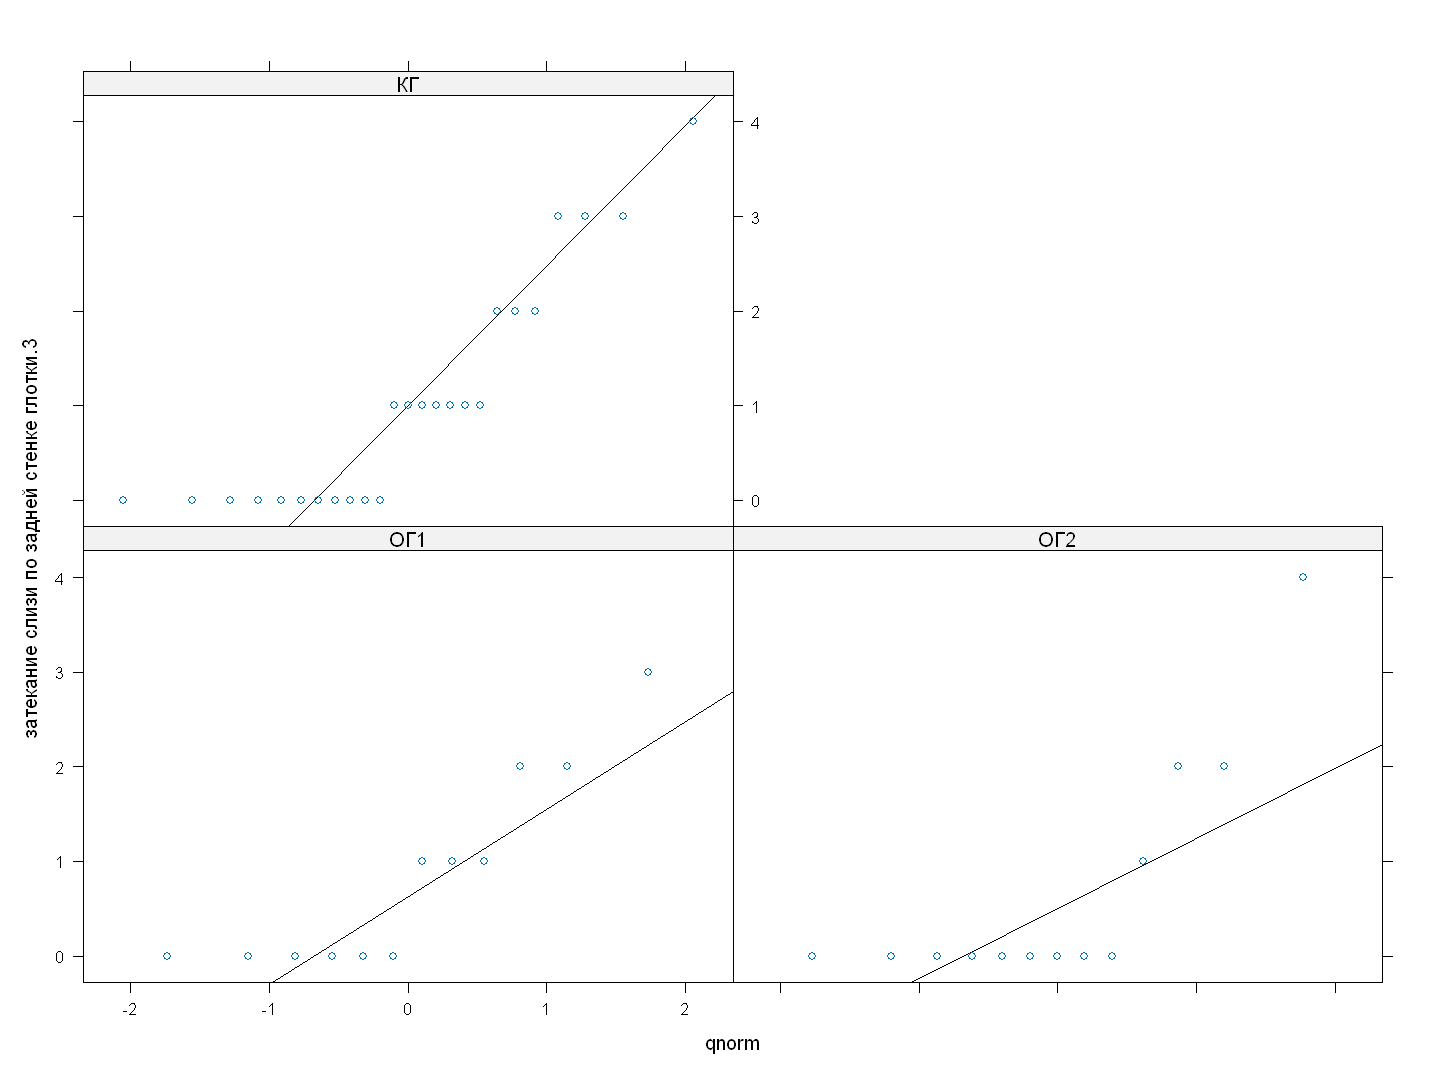

In [130]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

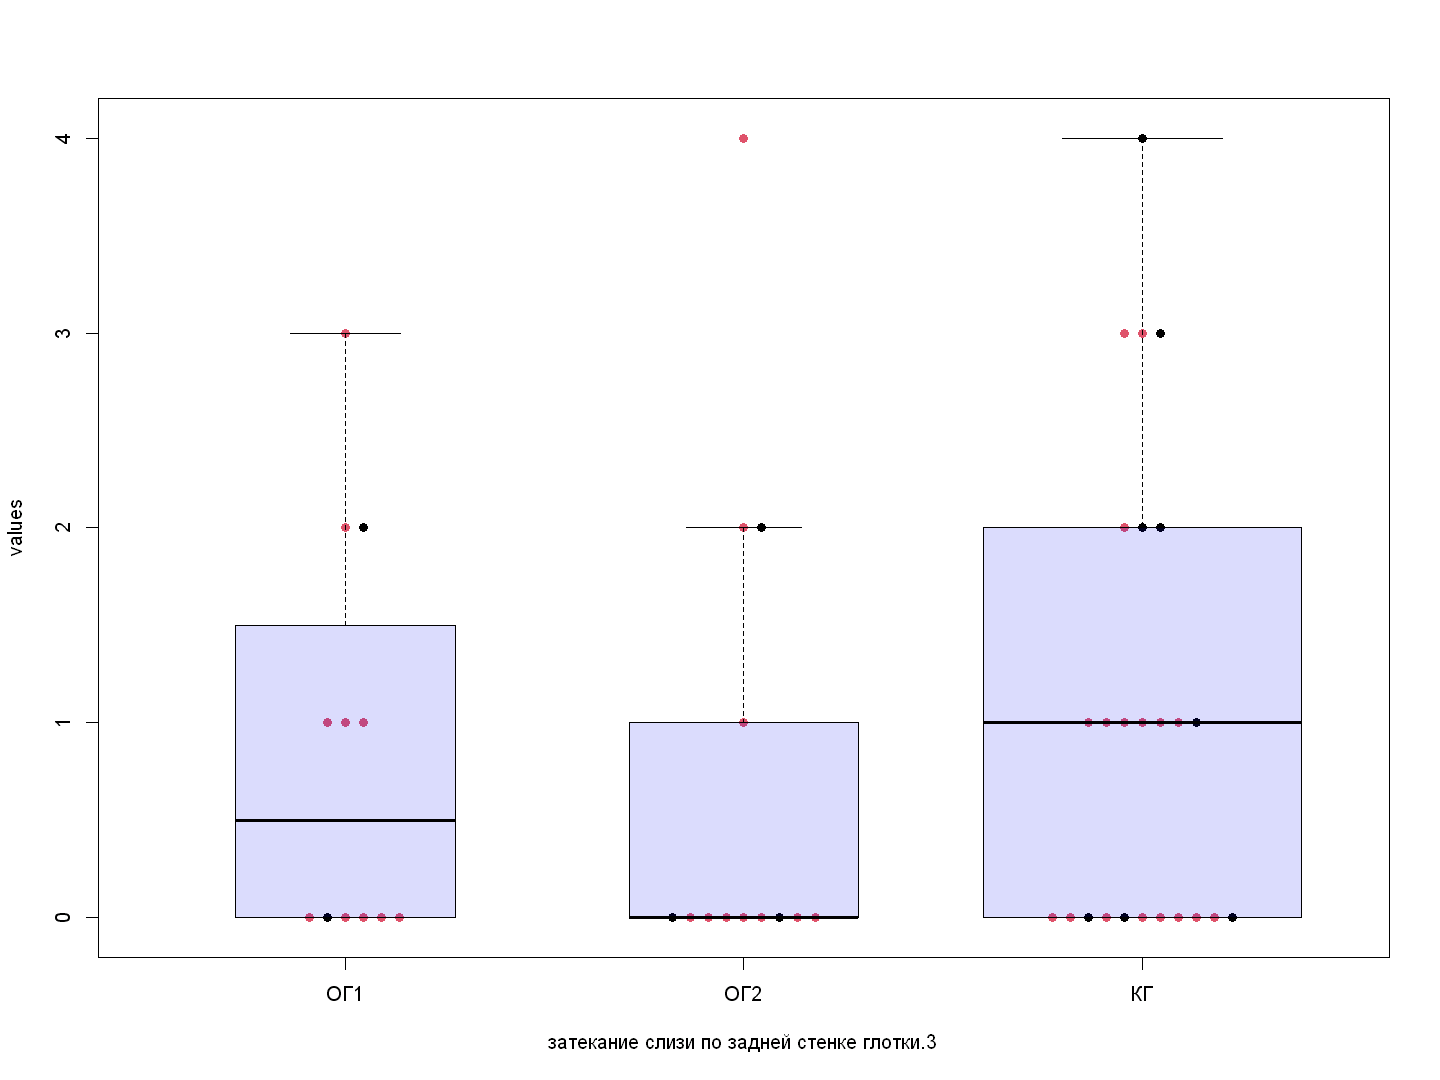

In [131]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [132]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.80164, p-value = 0.00978

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.63824, p-value = 0.0001429

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.81191, p-value = 0.0003616



In [133]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 0.46691, df = 2, p-value = 0.7918


### Сравнение, нормальные распределения

In [134]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares     1.1041   65.3959
Deg. of Freedom         2        47

Residual standard error: 1.179577
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2    1.1  0.5521   0.397  0.675
Residuals   47   65.4  1.3914               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
              diff        lwr      upr     p adj
ОГ2-ОГ1 -0.1410256 -1.2838282 1.001777 0.9520732
КГ-ОГ1   0.2066667 -0.7958780 1.209211 0.8721907
КГ-ОГ2   0.3476923 -0.6284511 1.323836 0.6666358


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = 0.3087, df = 22.727, p-value = 0.7604
alternative hypothesis: true difference in means is not

### Сравнение, распределение не нормальное

In [135]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 1.4172, df = 2, p-value = 0.4923

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ1-ОГ2 3.535256     13.97036       FALSE
ОГ1-КГ  1.921667     12.25576       FALSE
ОГ2-КГ  5.456923     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 89.5, p-value = 0.4973
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = 0.70966, p-value = 0.5086
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 138, p-value = 0.6909
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Tes

## густые выделения из носа.0

### Общее

In [136]:
parname <- "густые выделения из носа.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

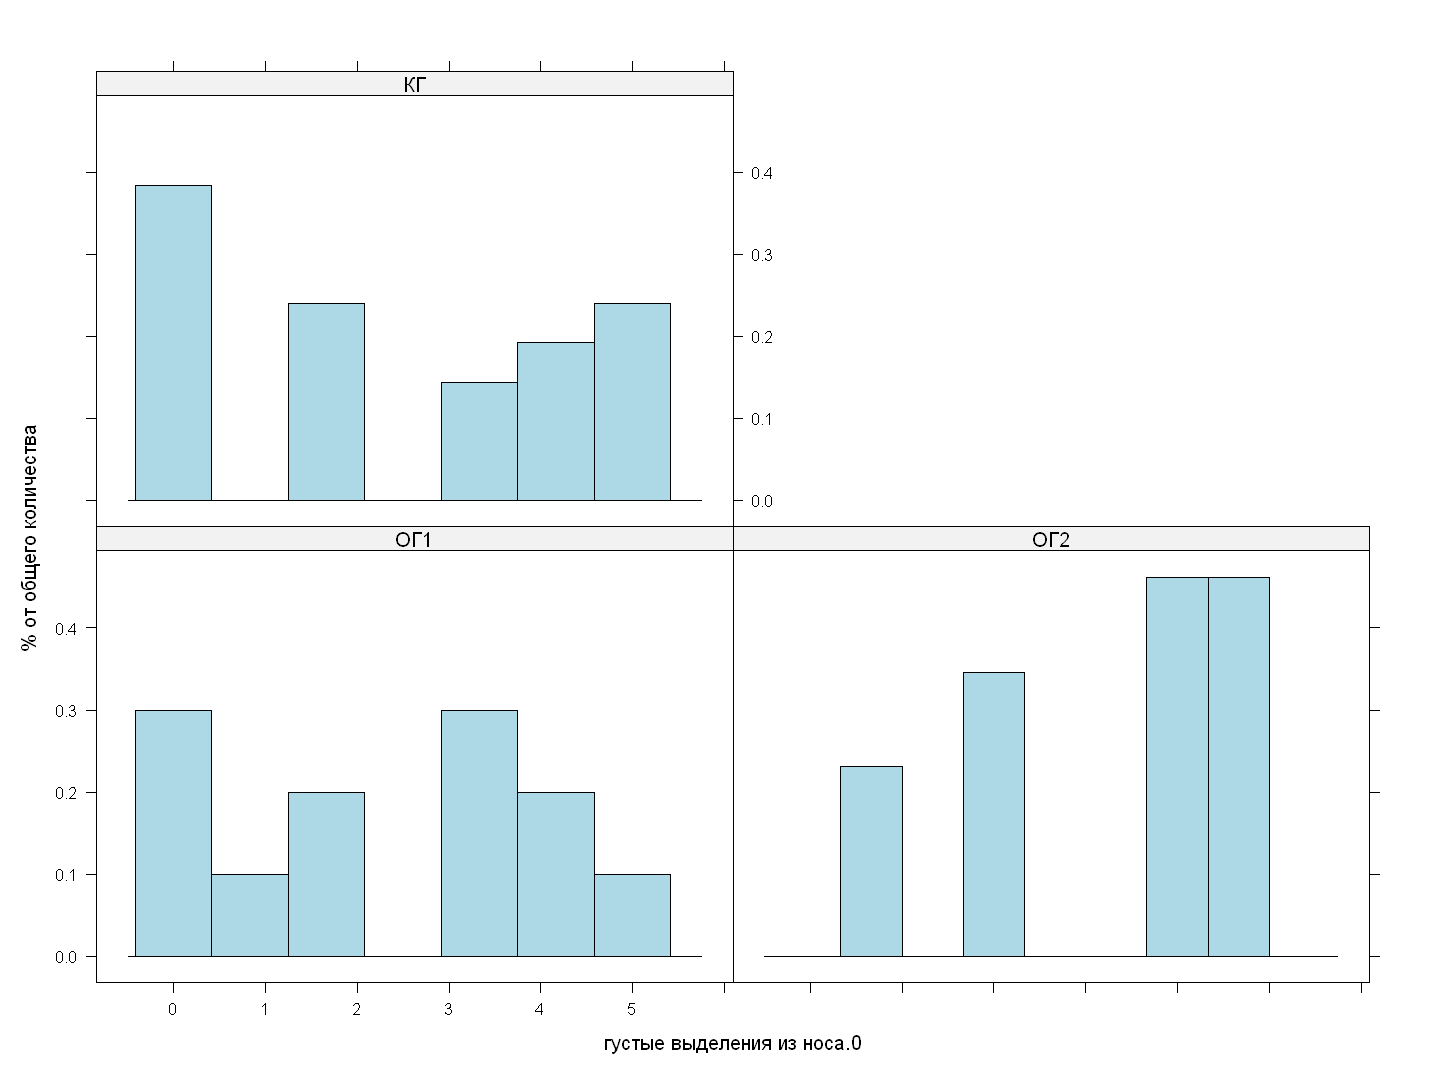

In [137]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [138]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

        mean       sd IQR 0%  25% 50%  75% 100% data:n
ОГ1 2.250000 1.712255 2.5  0 0.75 2.5 3.25    5     12
ОГ2 3.384615 1.556624 3.0  1 2.00 4.0 5.00    5     13
КГ  2.400000 1.957890 4.0  0 0.00 2.0 4.00    5     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0.75,2.5,3.25,5,2.250000,1.712255,12,0
ОГ2,1,2.00,4.0,5.00,5,3.384615,1.556624,13,0
КГ,0,0.00,2.0,4.00,5,2.400000,1.957890,25,0


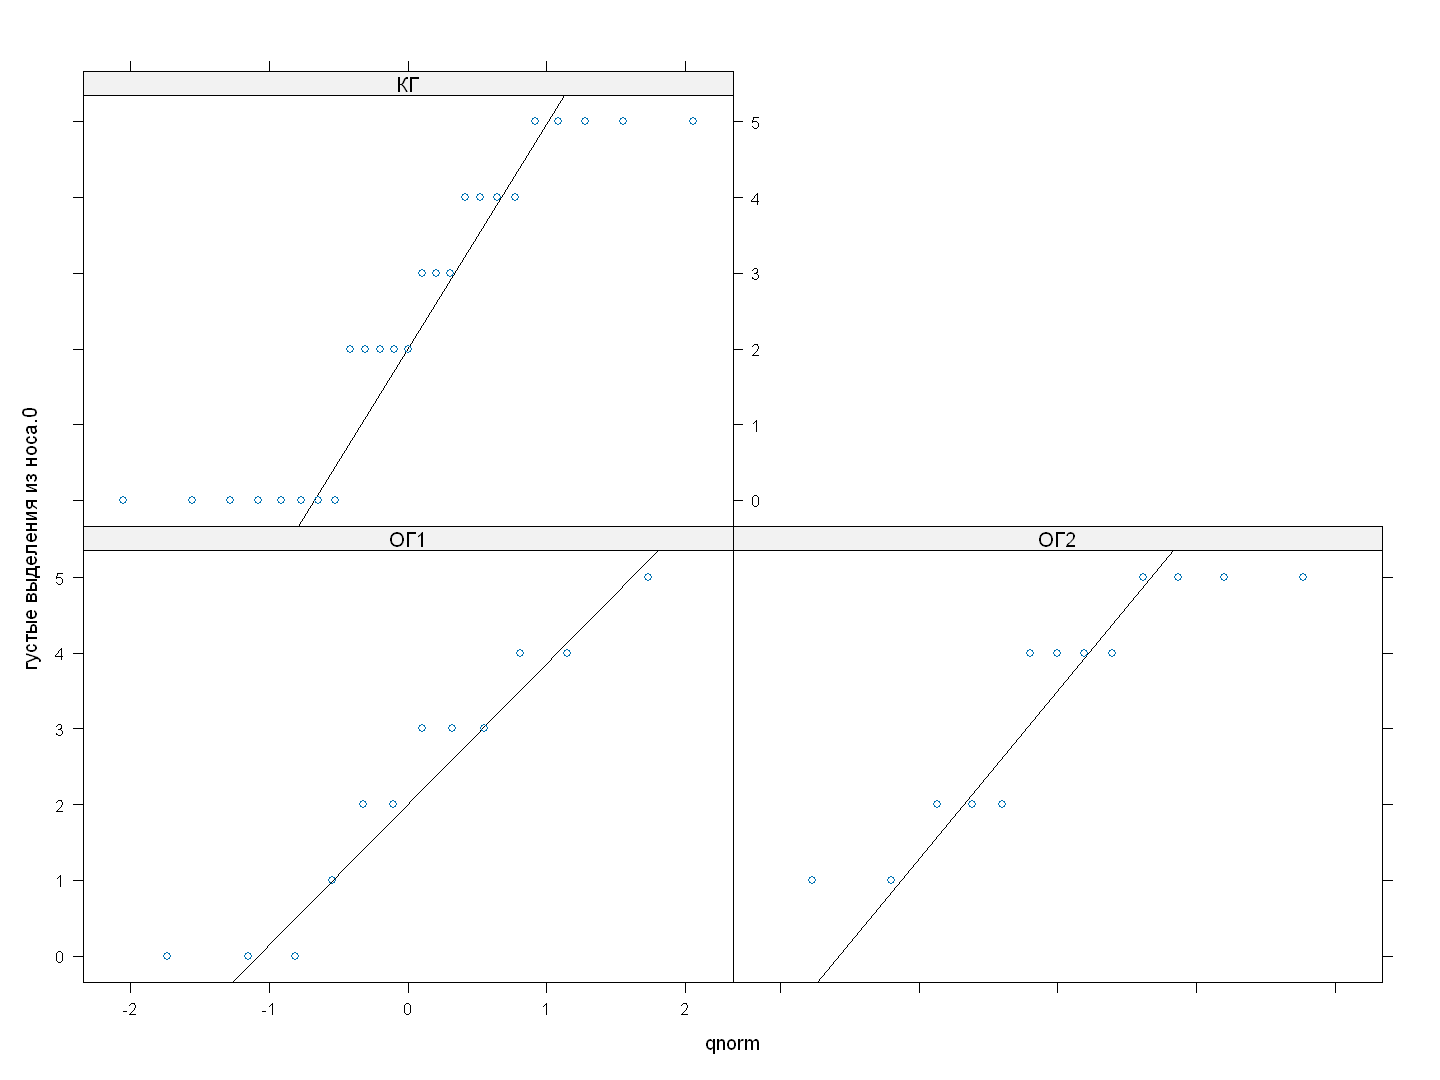

In [139]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

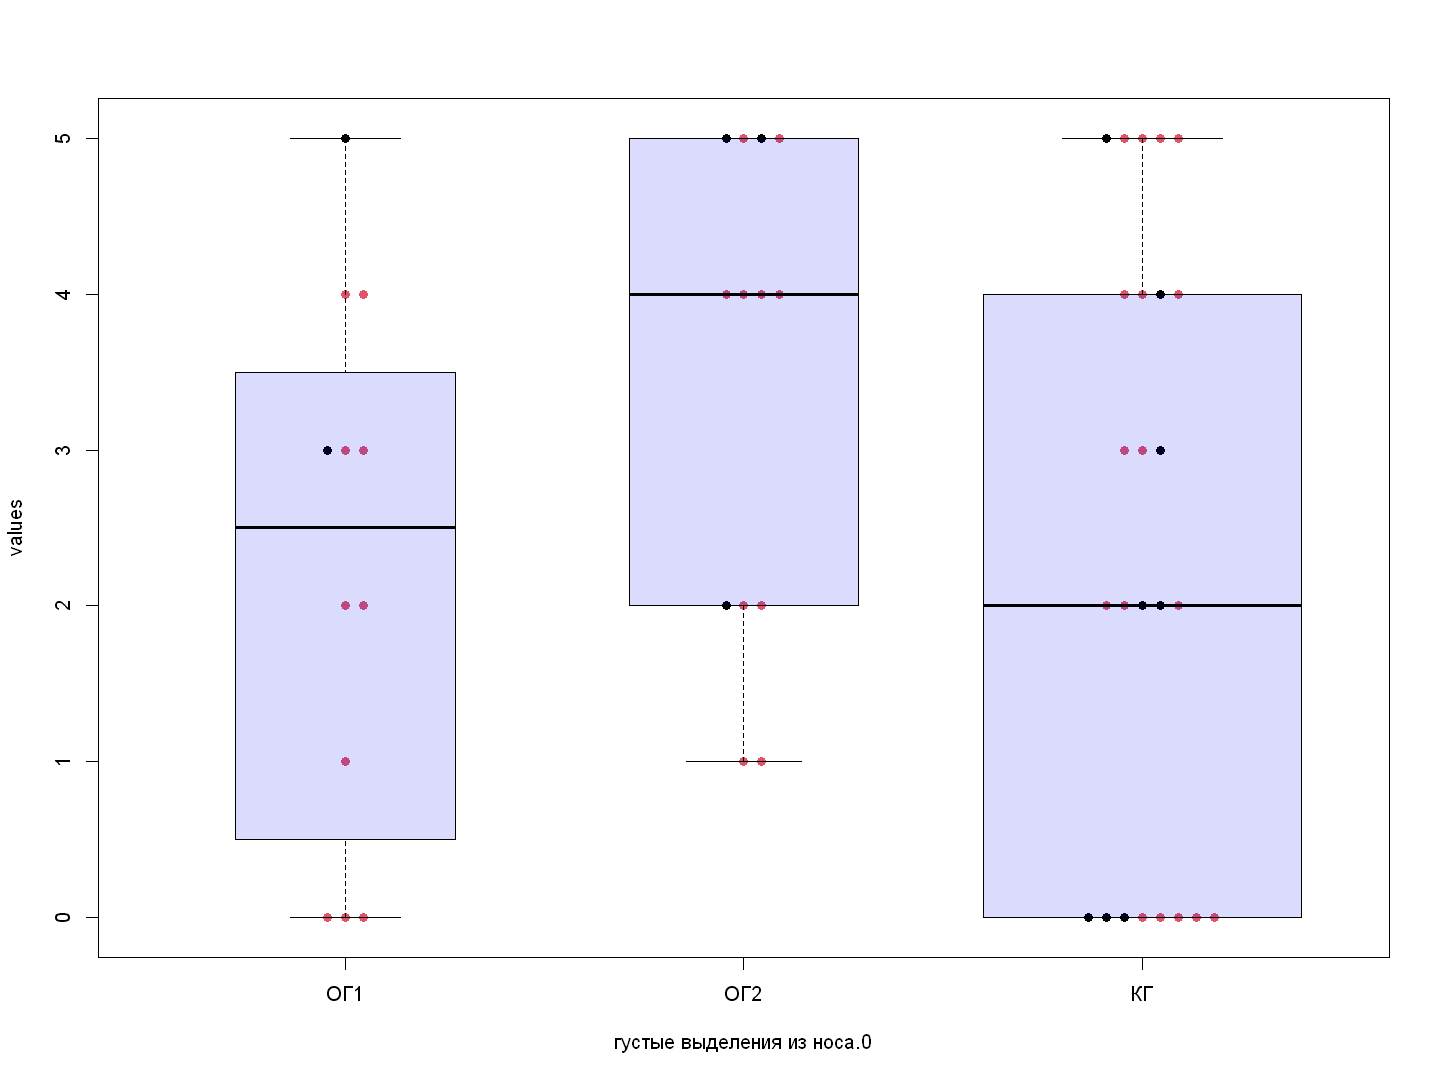

In [140]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [141]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.91971, p-value = 0.2835

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.83564, p-value = 0.01866

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.85333, p-value = 0.002038



In [142]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 0.84462, df = 2, p-value = 0.6555


### Сравнение, нормальные распределения

In [143]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares   10.45308 153.32692
Deg. of Freedom         2        47

Residual standard error: 1.806177
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2  10.45   5.227   1.602  0.212
Residuals   47 153.33   3.262               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
              diff        lwr       upr     p adj
ОГ2-ОГ1  1.1346154 -0.6152522 2.8844829 0.2688887
КГ-ОГ1   0.1500000 -1.3851037 1.6851037 0.9696624
КГ-ОГ2  -0.9846154 -2.4792932 0.5100624 0.2581218


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -1.7288, df = 22.293, p-value = 0.09766
alternative hypothesis: true difference in means 

### Сравнение, распределение не нормальное

In [144]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 3.0964, df = 2, p-value = 0.2126

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ1-ОГ2 9.006410     13.97036       FALSE
ОГ1-КГ  1.483333     12.25576       FALSE
ОГ2-КГ  7.523077     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 48, p-value = 0.1027
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = -1.6598, p-value = 0.0981
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 143, p-value = 0.8291
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test


## густые выделения из носа.3

### Общее

In [145]:
parname <- "густые выделения из носа.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

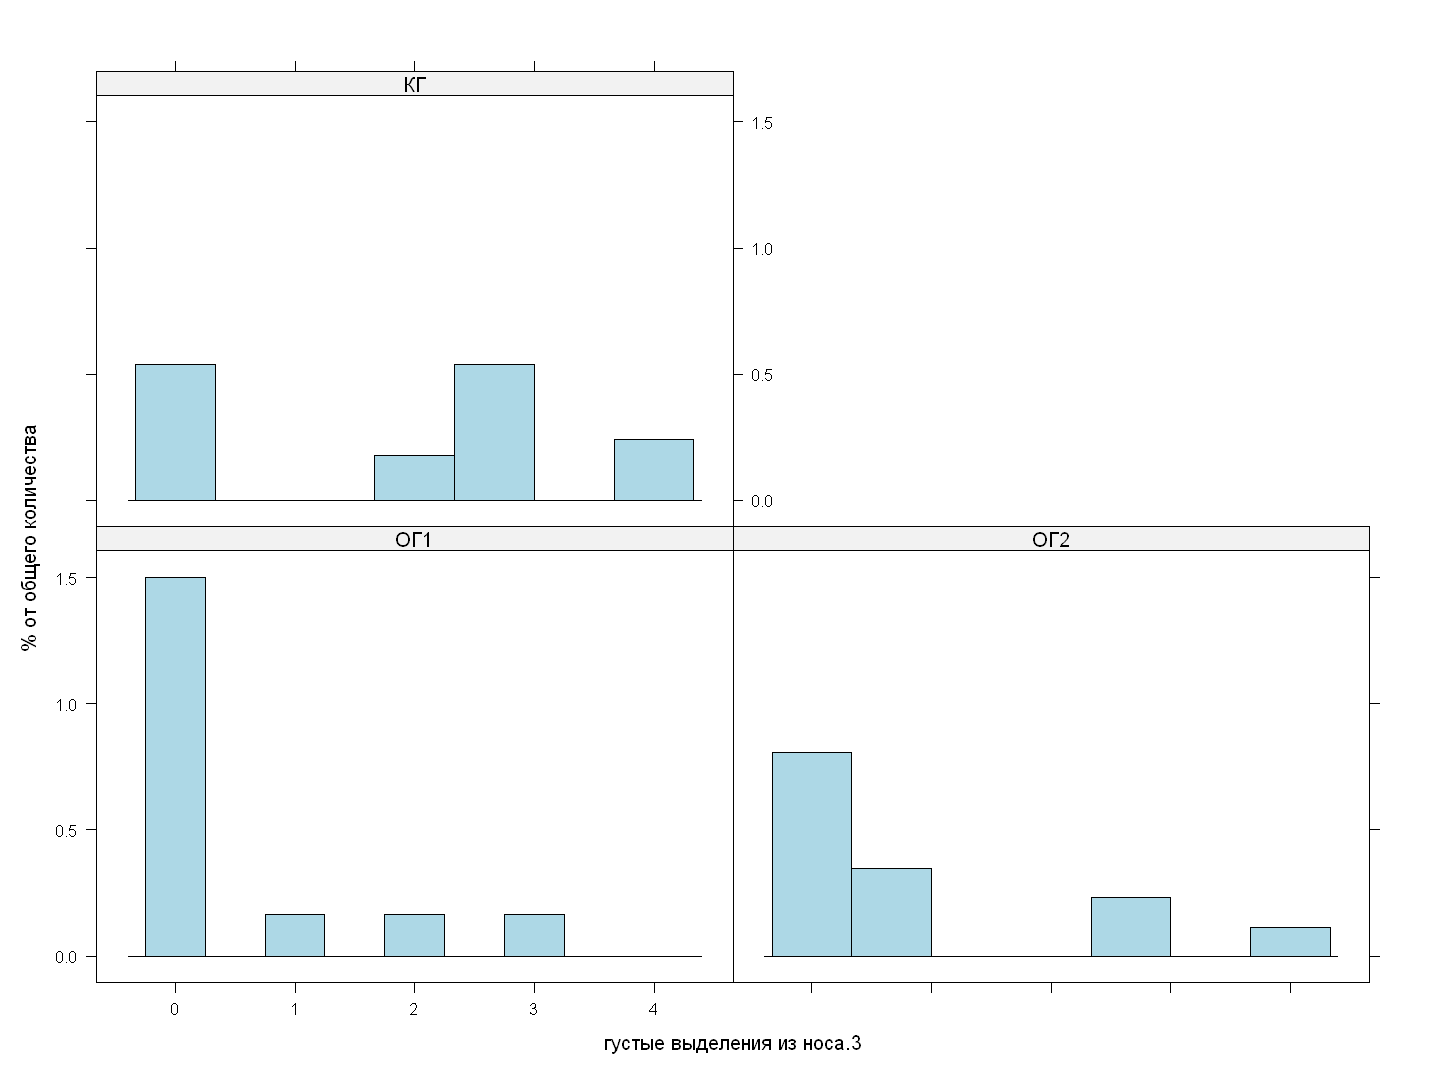

In [146]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [147]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

    mean       sd  IQR 0% 25% 50%  75% 100% data:n
ОГ1 0.50 1.000000 0.25  0   0   0 0.25    3     12
ОГ2 1.00 1.414214 1.00  0   0   0 1.00    4     13
КГ  1.96 1.593738 3.00  0   0   3 3.00    4     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,0,0.25,3,0.50,1.000000,12,0
ОГ2,0,0,0,1.00,4,1.00,1.414214,13,0
КГ,0,0,3,3.00,4,1.96,1.593738,25,0


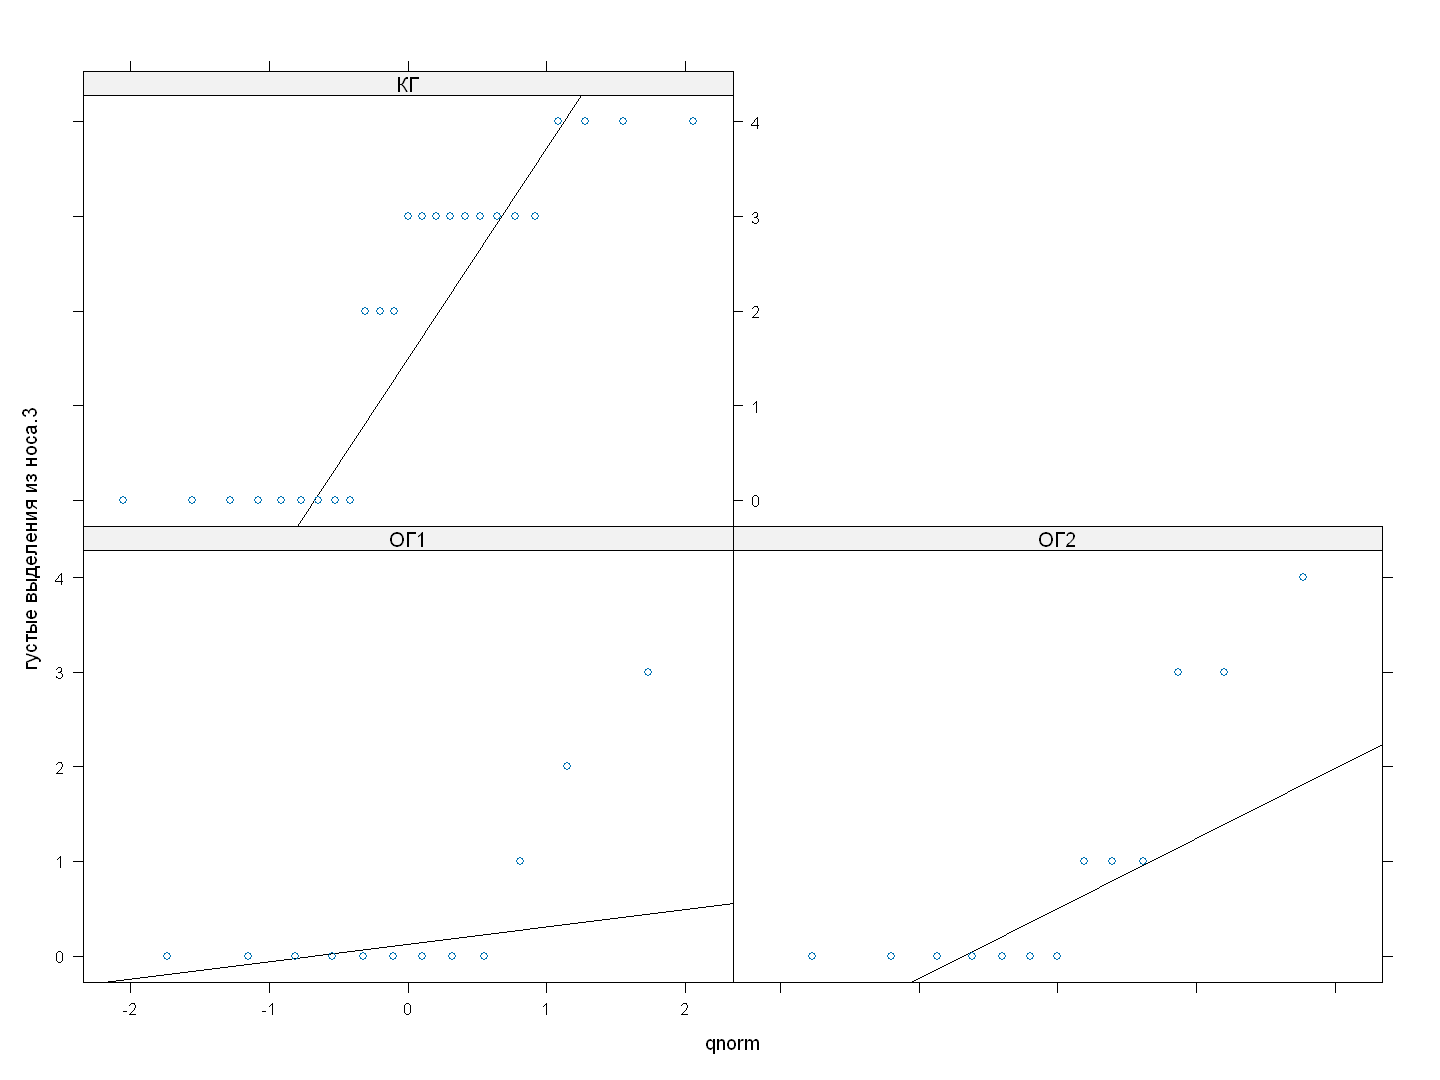

In [148]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

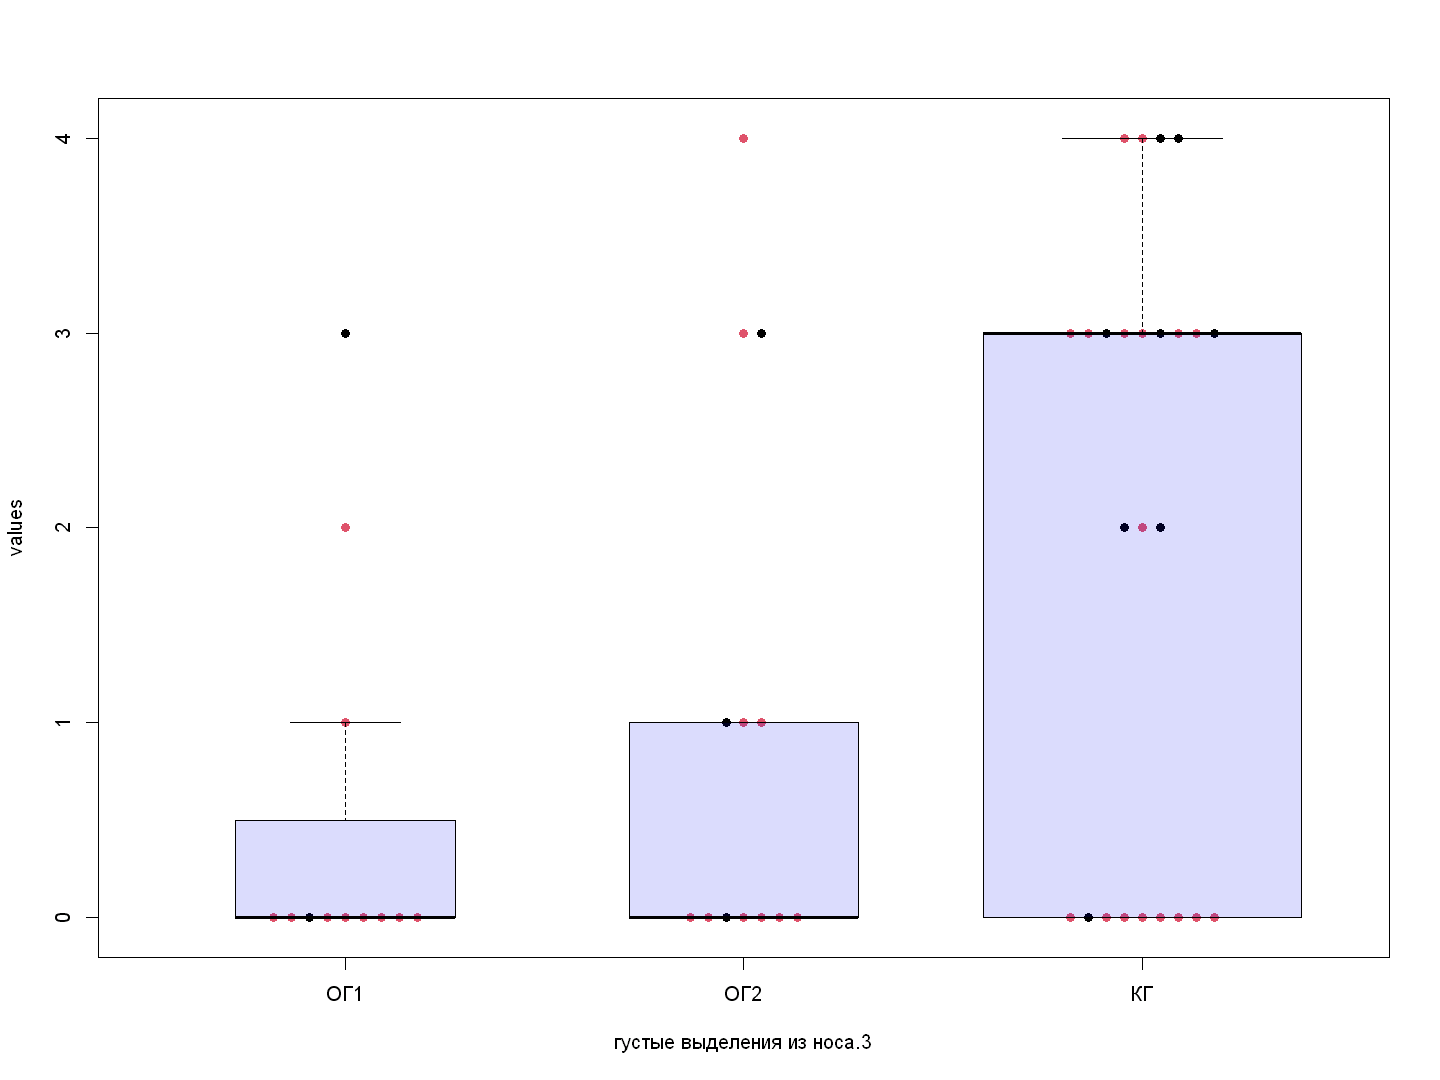

In [149]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [150]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.58743, p-value = 8.444e-05

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.73456, p-value = 0.001258

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.79648, p-value = 0.0001987



In [151]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 2.7683, df = 2, p-value = 0.2505


### Сравнение, нормальные распределения

In [152]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares      19.56     95.96
Deg. of Freedom         2        47

Residual standard error: 1.428881
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)  
parameter    2  19.56   9.780    4.79 0.0128 *
Residuals   47  95.96   2.042                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
        diff        lwr      upr     p adj
ОГ2-ОГ1 0.50 -0.8843346 1.884335 0.6591235
КГ-ОГ1  1.46  0.2455668 2.674433 0.0149618
КГ-ОГ2  0.96 -0.2224519 2.142452 0.1322575


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -1.0267, df = 21.605, p-value = 0.3159
alter

### Сравнение, распределение не нормальное

In [153]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 7.3747, df = 2, p-value = 0.02504

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
          obs.dif critical.dif stat.signif
ОГ1-ОГ2  5.157051     13.97036       FALSE
ОГ1-КГ  12.401667     12.25576        TRUE
ОГ2-КГ   7.244615     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 61, p-value = 0.2945
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = -1.08, p-value = 0.3188
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 76.5, p-value = 0.0108
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence T

## заложенность в ушах.0

### Общее

In [154]:
parname <- "заложенность в ушах.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

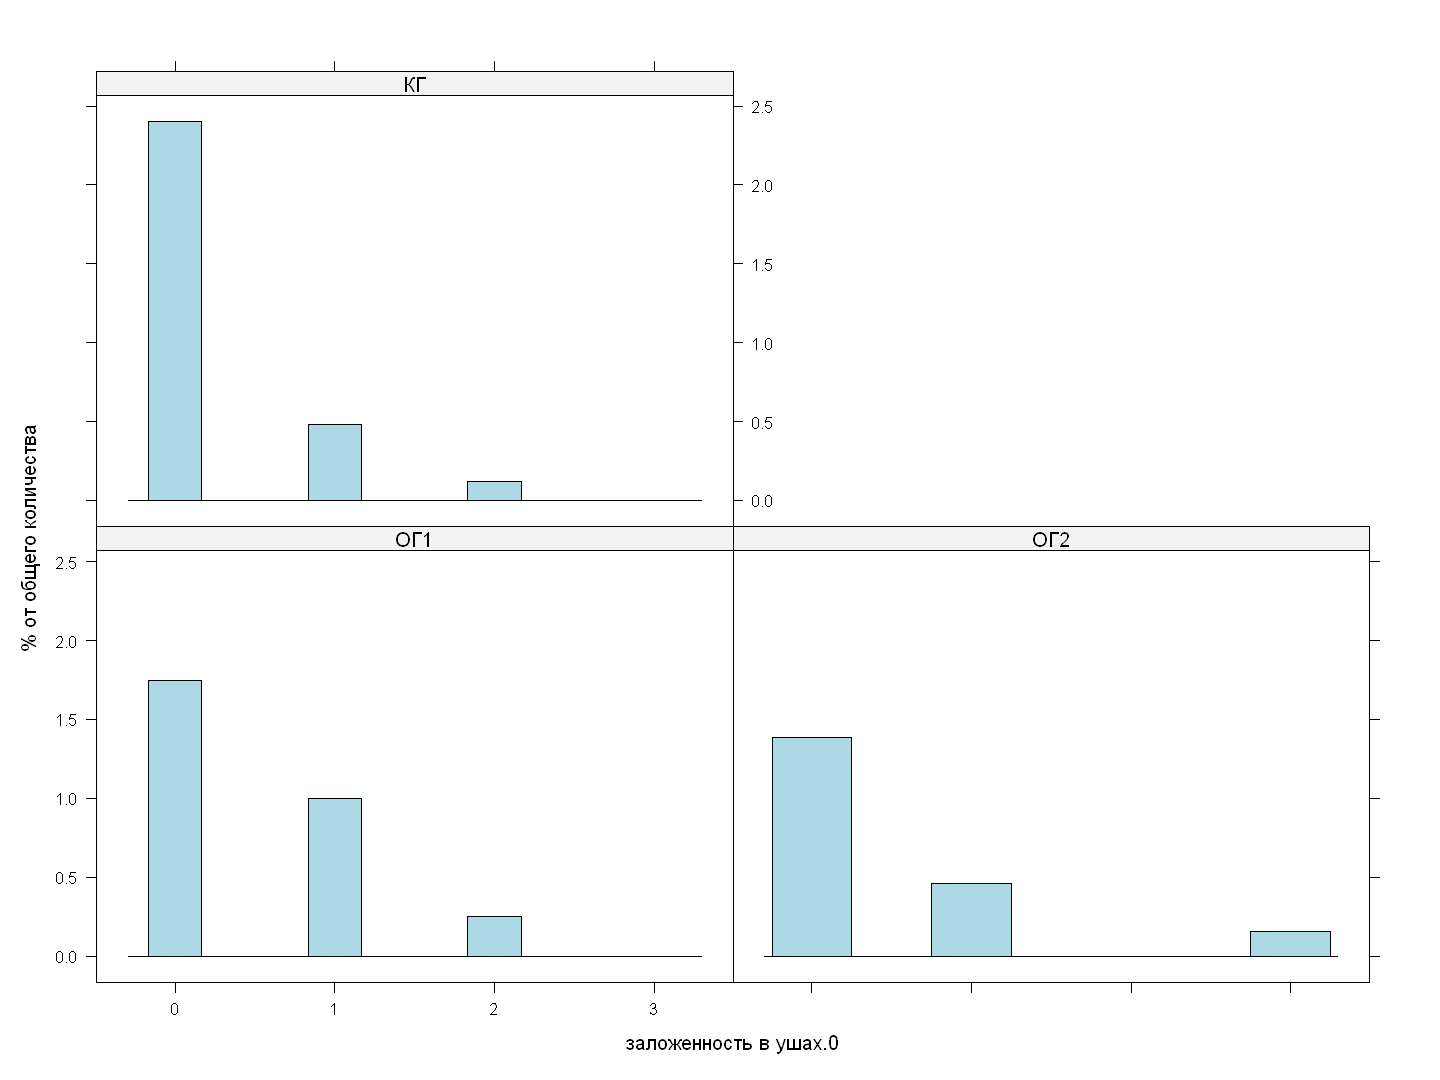

In [155]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [156]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 0.5000000 0.6741999   1  0   0   0   1    2     12
ОГ2 0.4615385 0.8770580   1  0   0   0   1    3     13
КГ  0.2400000 0.5228129   0  0   0   0   0    2     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,0,1,2,0.5000000,0.6741999,12,0
ОГ2,0,0,0,1,3,0.4615385,0.8770580,13,0
КГ,0,0,0,0,2,0.2400000,0.5228129,25,0


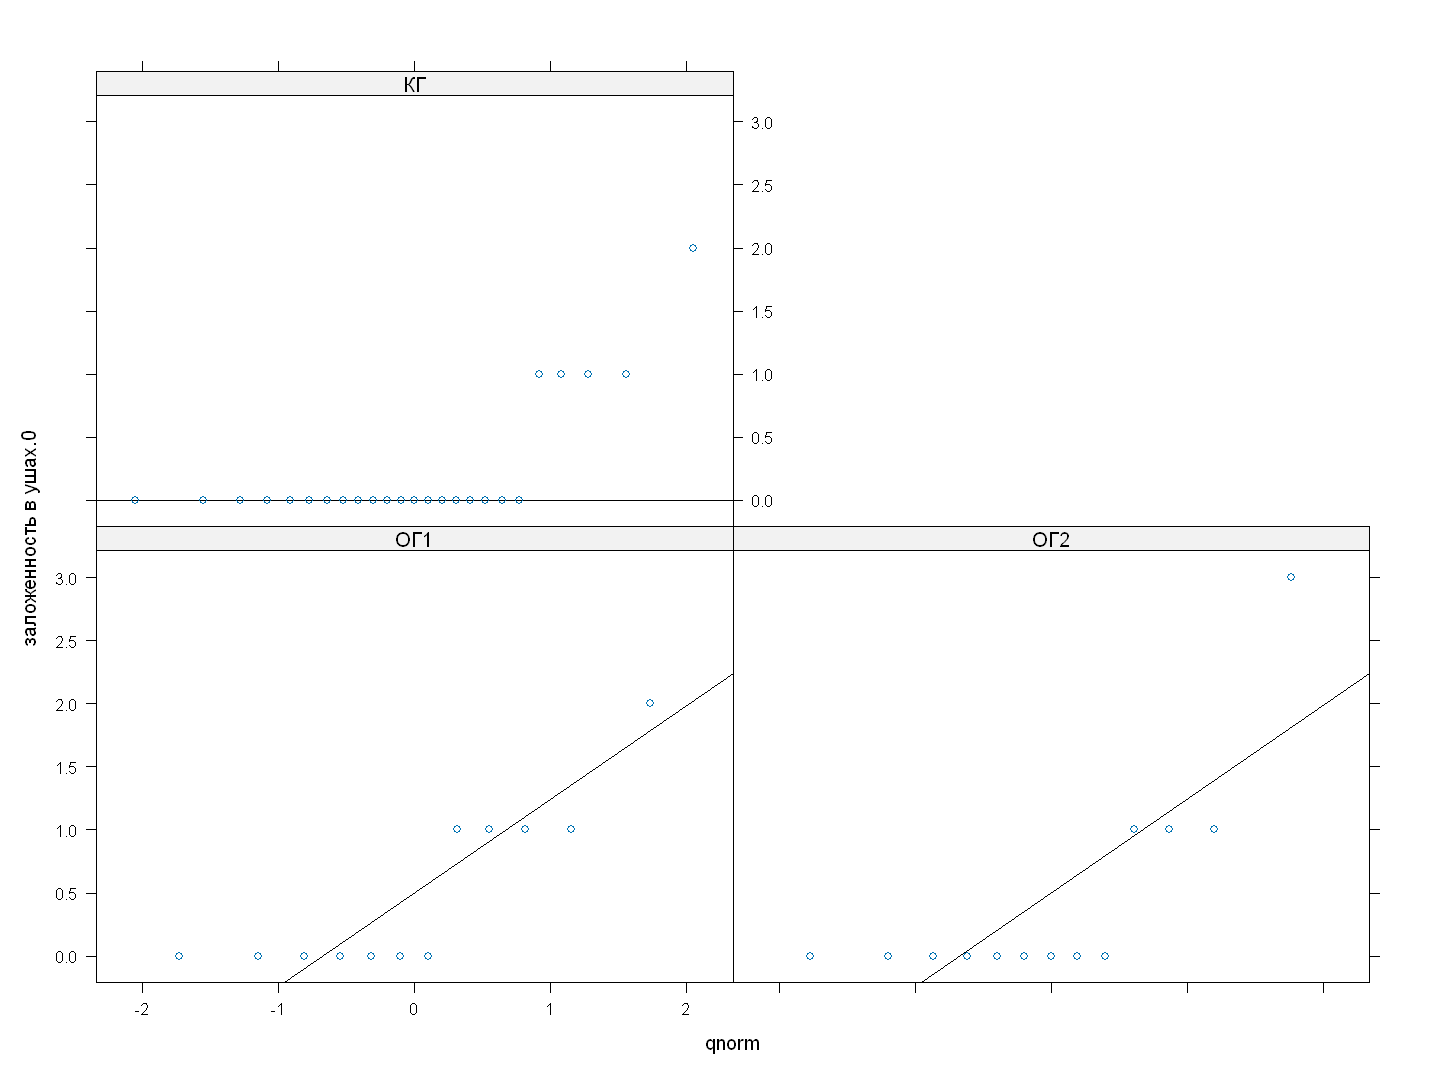

In [157]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

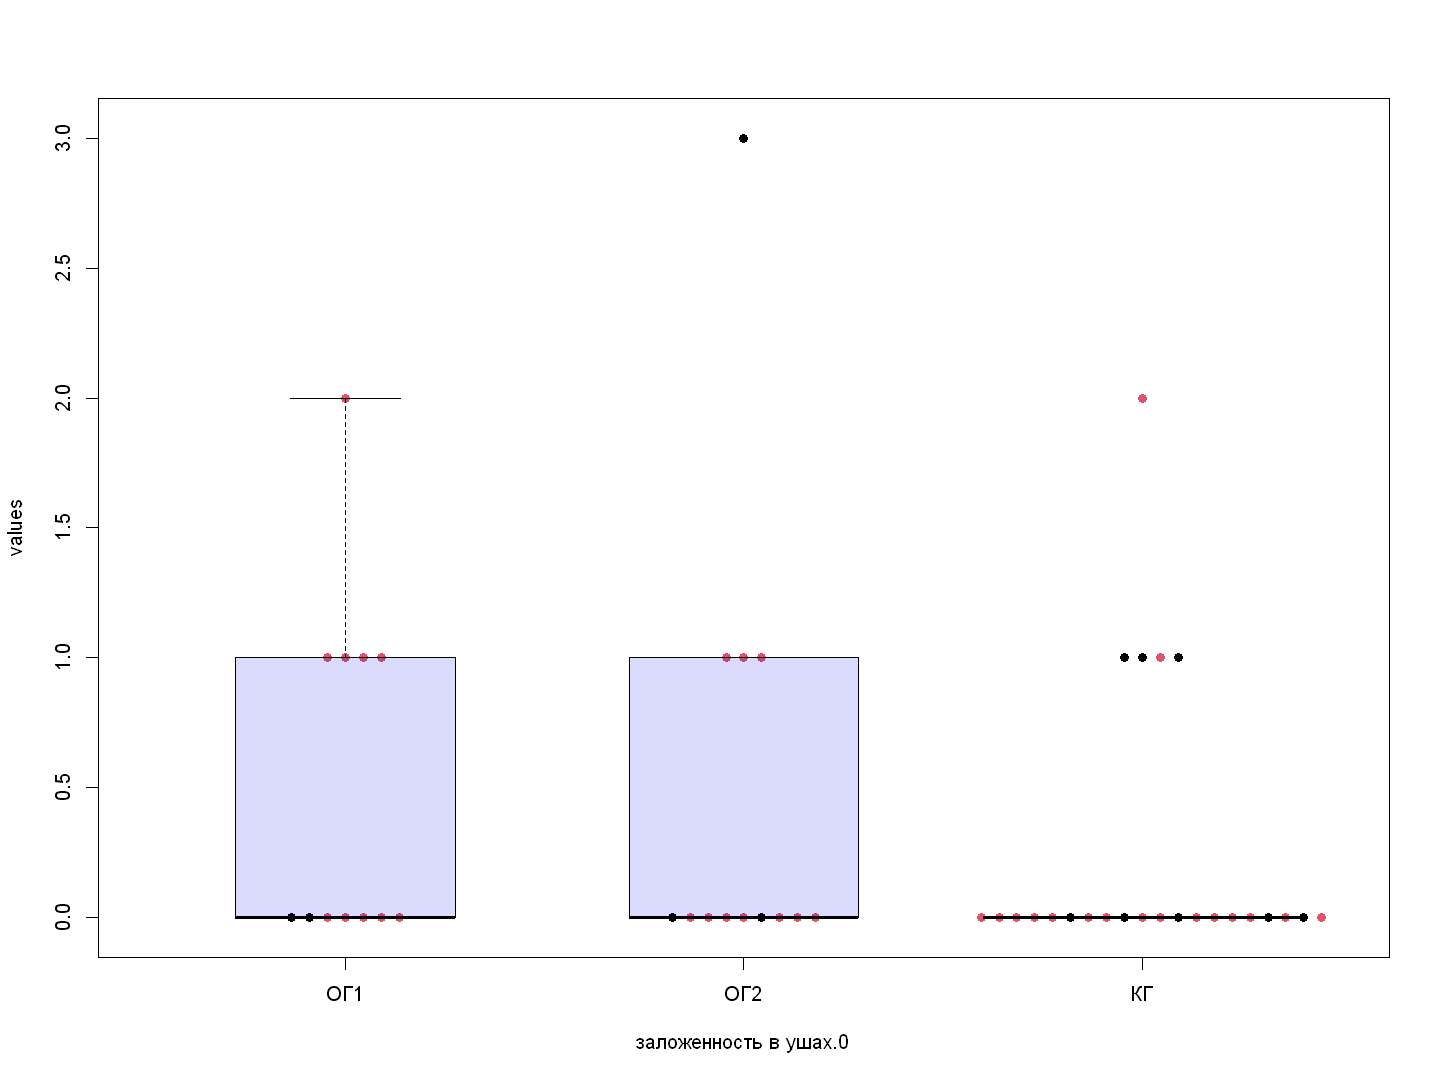

In [158]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [159]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.73211, p-value = 0.001749

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.59919, p-value = 6.443e-05

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.51979, p-value = 5.895e-08



In [160]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 4.4709, df = 2, p-value = 0.1069


### Сравнение, нормальные распределения

In [161]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares   0.729231 20.790769
Deg. of Freedom         2        47

Residual standard error: 0.6650991
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2  0.729  0.3646   0.824  0.445
Residuals   47 20.791  0.4424               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
               diff        lwr       upr     p adj
ОГ2-ОГ1 -0.03846154 -0.6828255 0.6059024 0.9885645
КГ-ОГ1  -0.26000000 -0.8252802 0.3052802 0.5108608
КГ-ОГ2  -0.22153846 -0.7719324 0.3288555 0.5966707


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = 0.12346, df = 22.308, p-value = 0.9028
alternative hypothesis: true difference in me

### Сравнение, распределение не нормальное

In [162]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 1.8836, df = 2, p-value = 0.3899

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ1-ОГ2 2.487179     13.97036       FALSE
ОГ1-КГ  5.373333     12.25576       FALSE
ОГ2-КГ  2.886154     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 85.5, p-value = 0.6529
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = 0.4818, p-value = 0.7286
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 182.5, p-value = 0.1807
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Te

## заложенность в ушах.3

### Общее

In [163]:
parname <- "заложенность в ушах.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

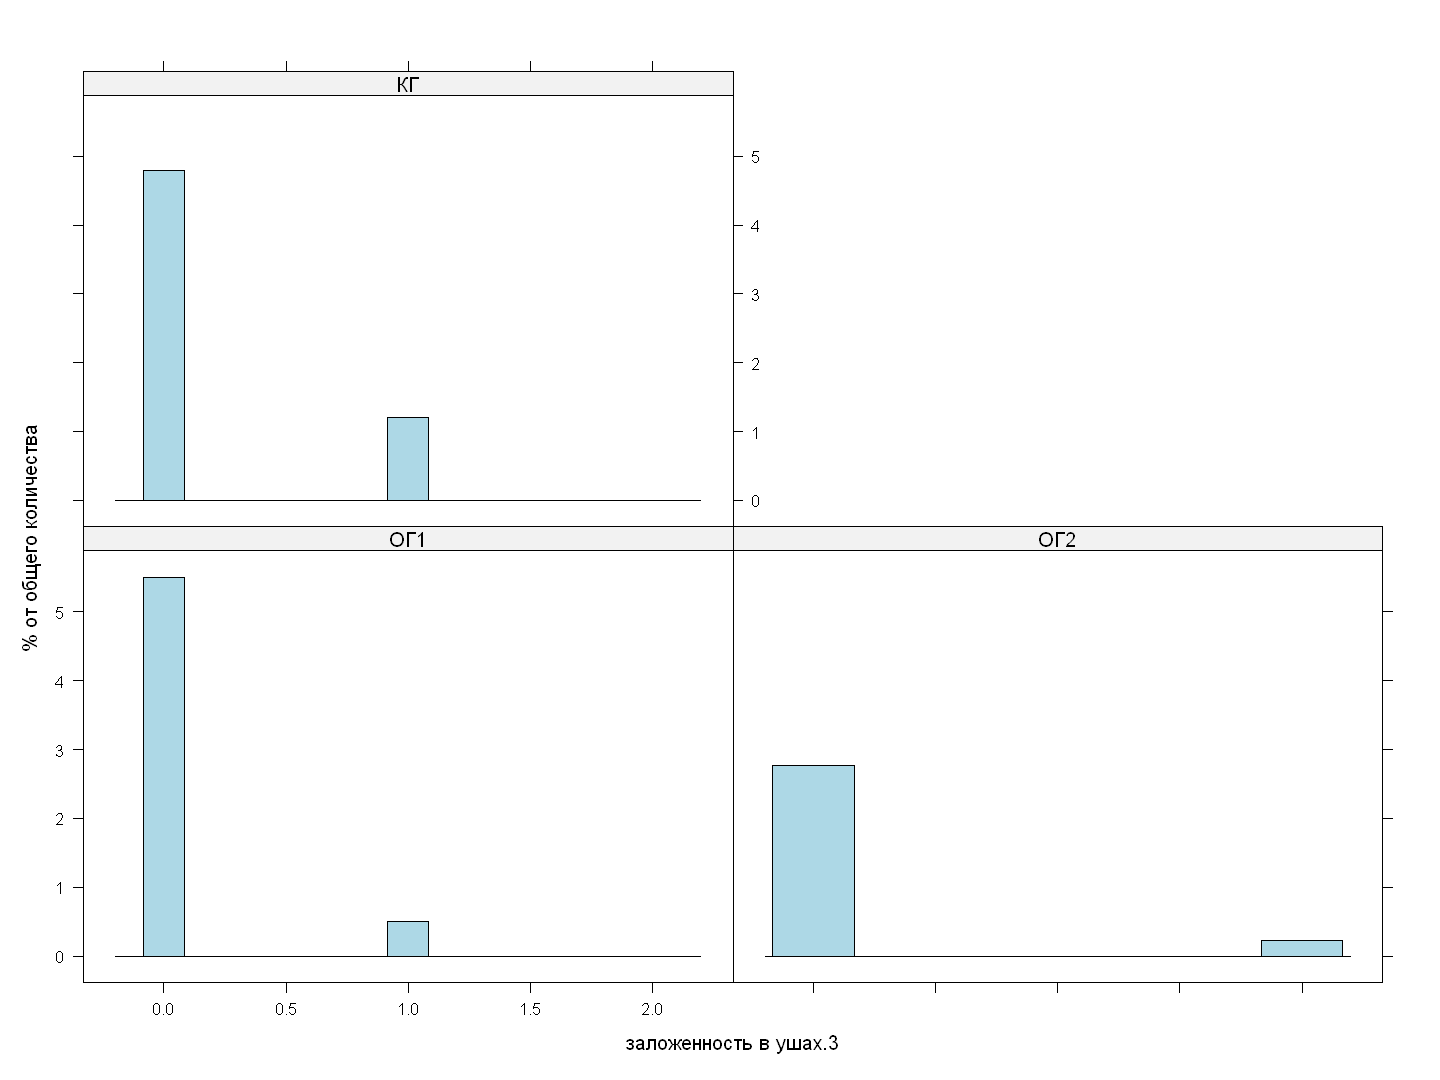

In [164]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [165]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

          mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 0.08333333 0.2886751   0  0   0   0   0    1     12
ОГ2 0.15384615 0.5547002   0  0   0   0   0    2     13
КГ  0.20000000 0.4082483   0  0   0   0   0    1     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,0,0,1,0.08333333,0.2886751,12,0
ОГ2,0,0,0,0,2,0.15384615,0.5547002,13,0
КГ,0,0,0,0,1,0.20000000,0.4082483,25,0


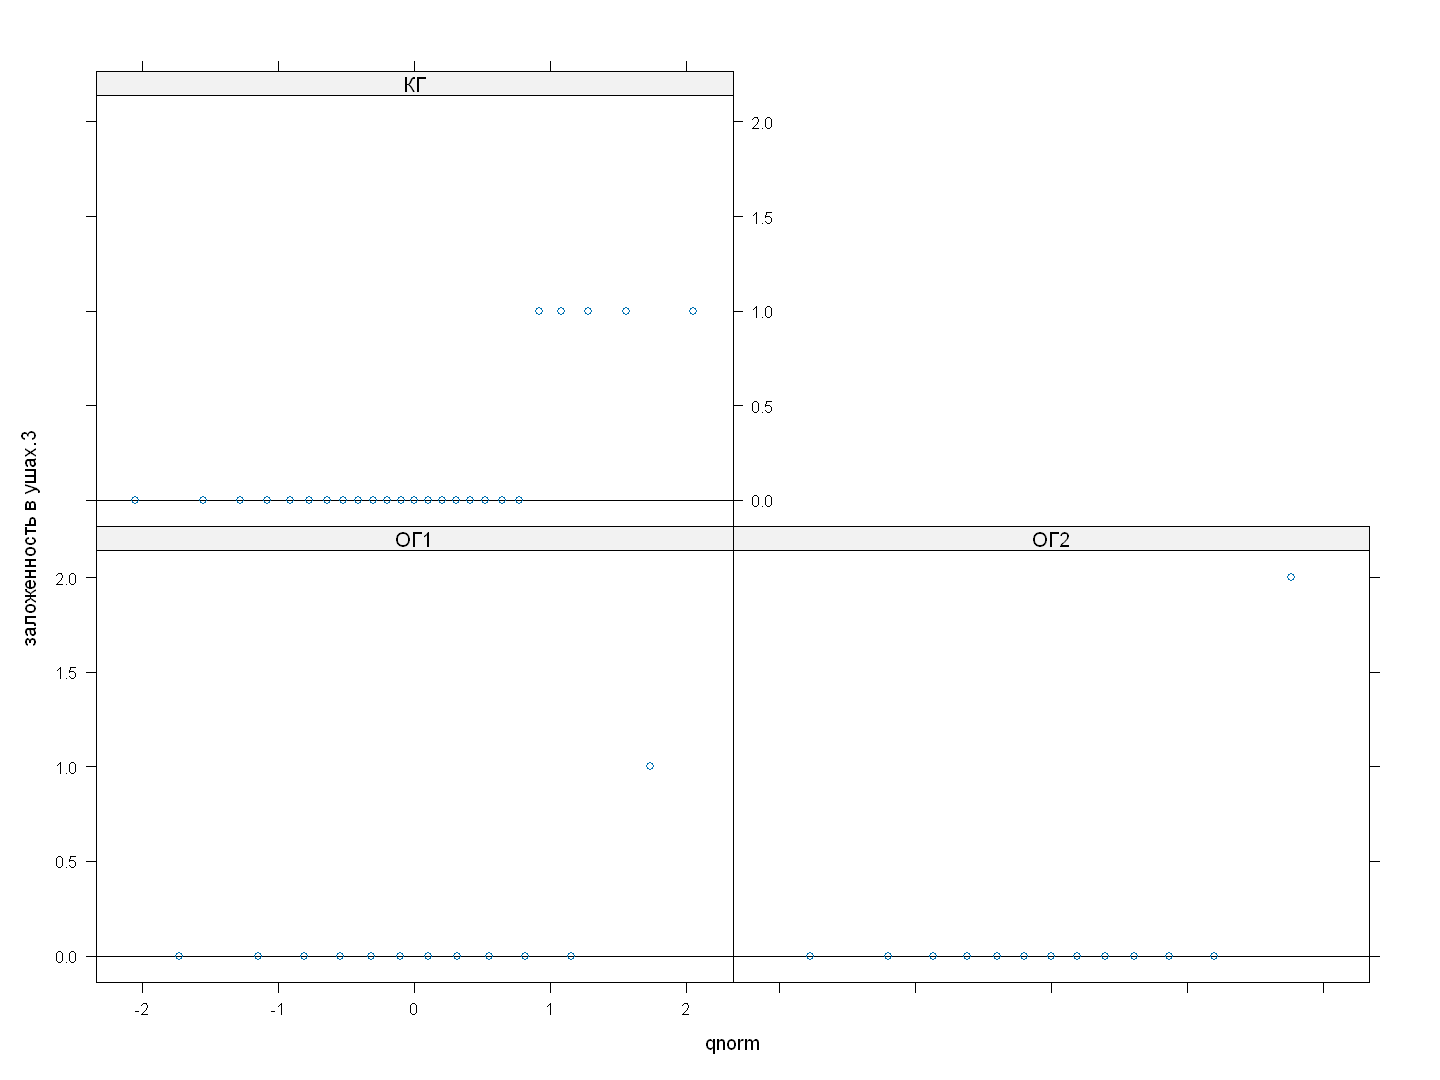

In [166]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

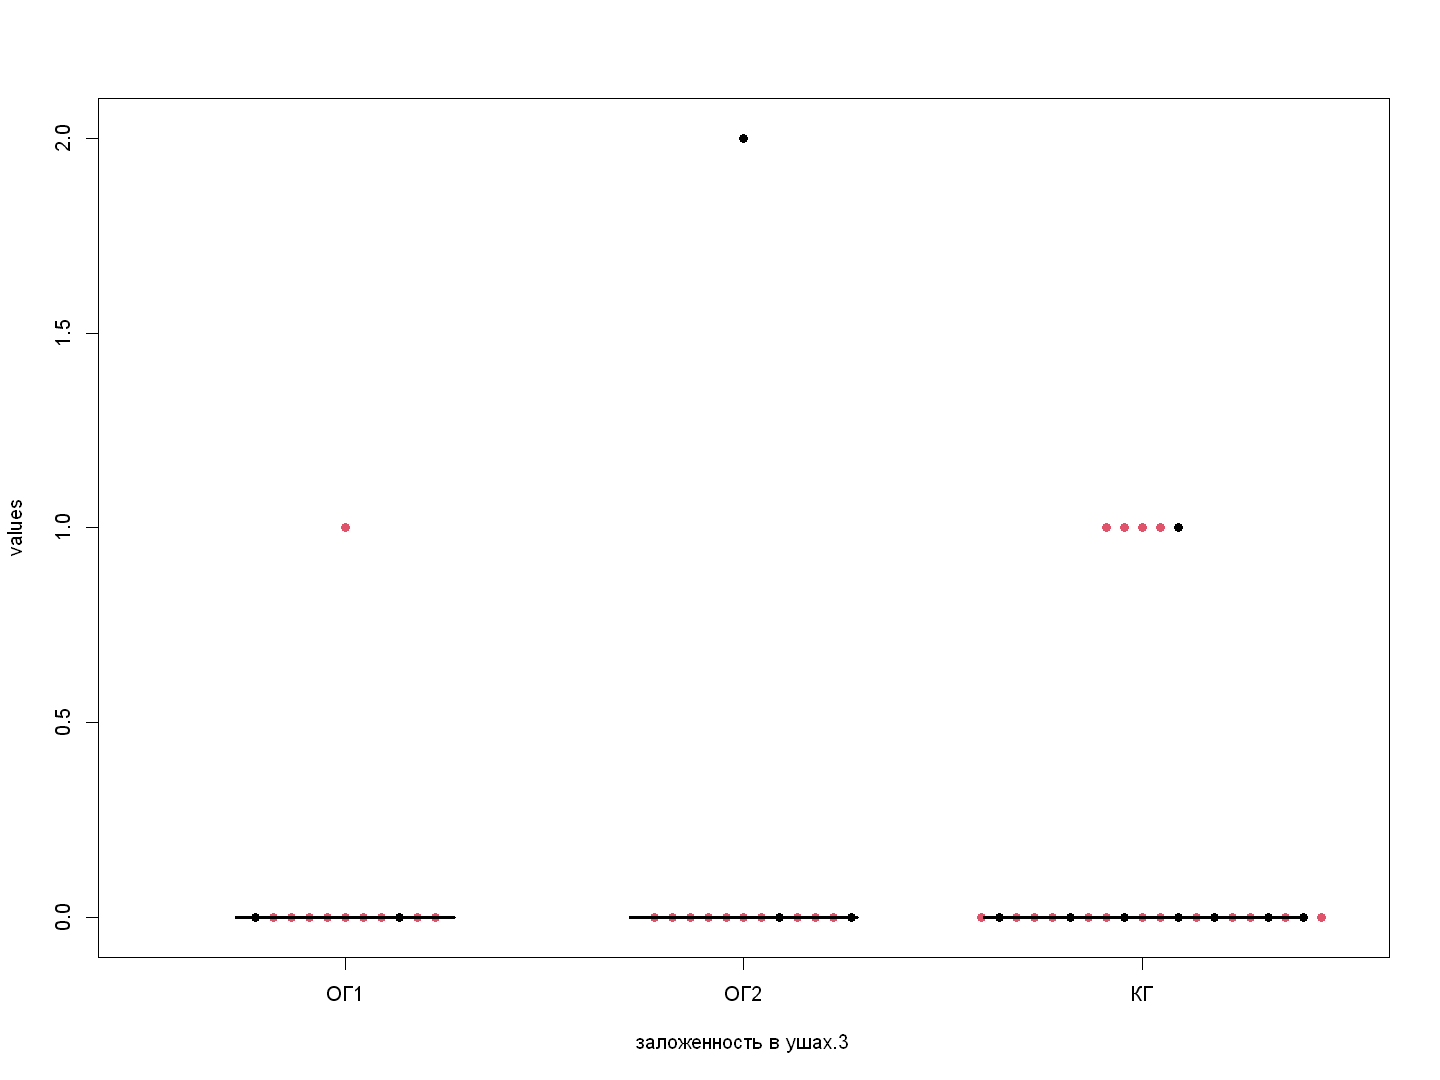

In [167]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [168]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.32693, p-value = 1.207e-06

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.31101, p-value = 5.045e-07

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.49334, p-value = 3.217e-08



In [169]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 4.5571, df = 2, p-value = 0.1024


### Сравнение, нормальные распределения

In [170]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares   0.111026  8.608974
Deg. of Freedom         2        47

Residual standard error: 0.4279833
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2  0.111 0.05551   0.303   0.74
Residuals   47  8.609 0.18317               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
              diff        lwr       upr     p adj
ОГ2-ОГ1 0.07051282 -0.3441276 0.4851533 0.9110426
КГ-ОГ1  0.11666667 -0.2470843 0.4804177 0.7193362
КГ-ОГ2  0.04615385 -0.3080180 0.4003257 0.9467113


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -0.40301, df = 18.351, p-value = 0.6916
alternative hypothesis: true difference in means

### Сравнение, распределение не нормальное

In [171]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 1.2737, df = 2, p-value = 0.5289

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
          obs.dif critical.dif stat.signif
ОГ1-ОГ2 0.1121795     13.97036       FALSE
ОГ1-КГ  2.8583333     12.25576       FALSE
ОГ2-КГ  2.7461538     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 78, p-value = 1
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = 0, p-value = 1
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 132.5, p-value = 0.3878
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss

## головокружение.0

### Общее

In [172]:
parname <- "головокружение.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

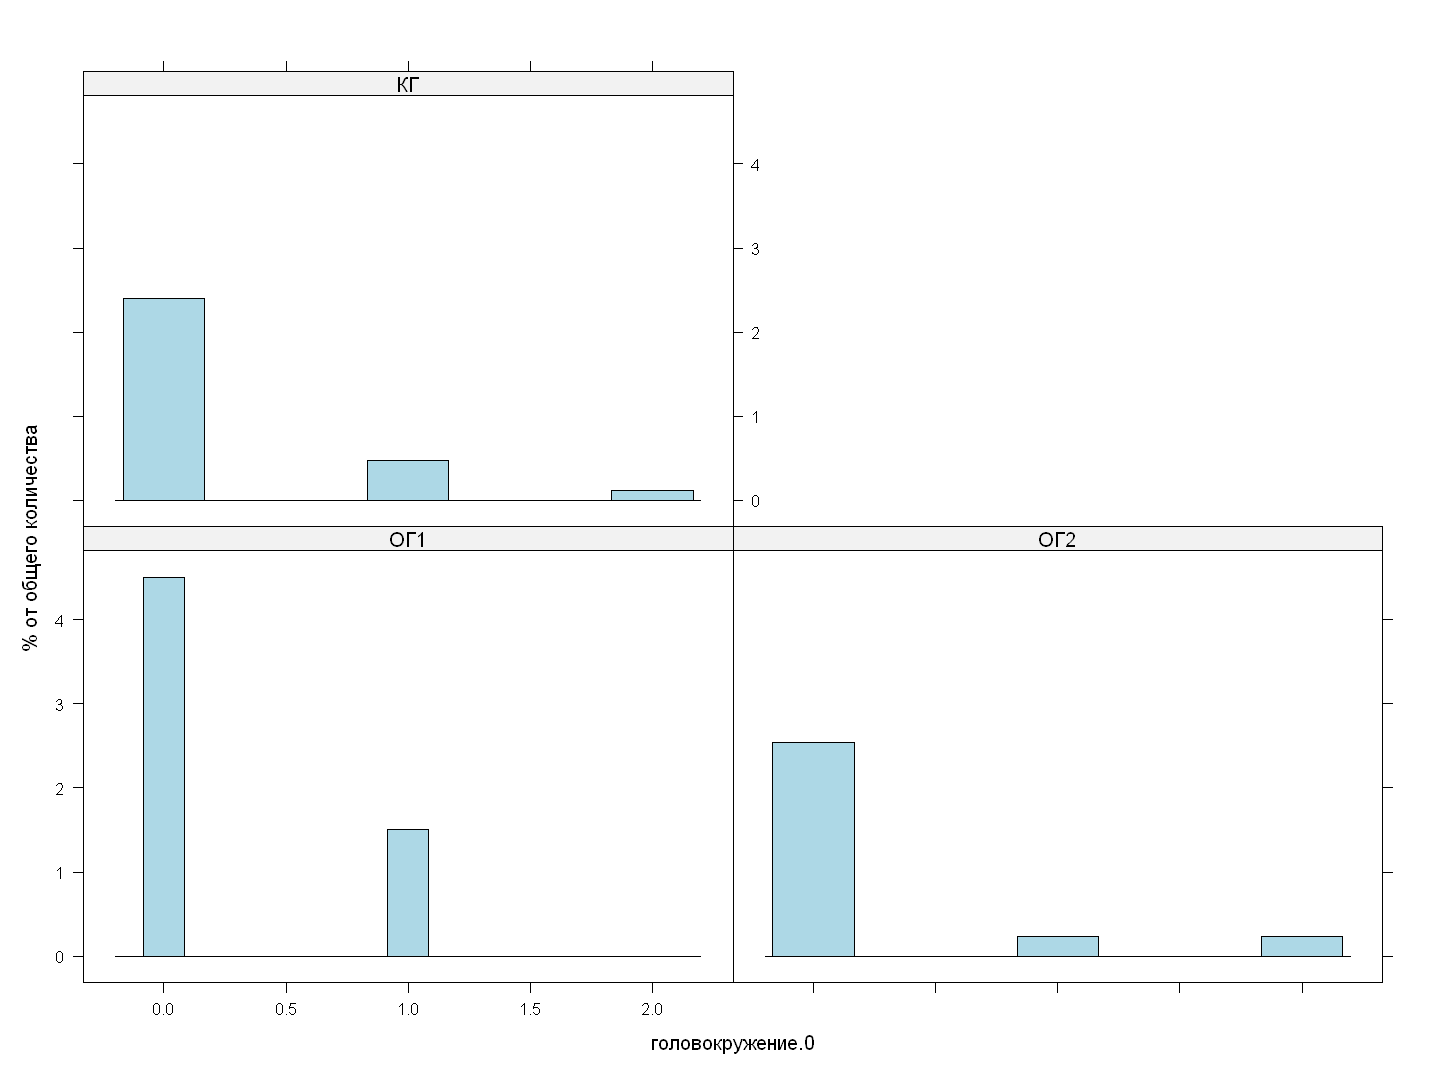

In [173]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [174]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd  IQR 0% 25% 50%  75% 100% data:n
ОГ1 0.2500000 0.4522670 0.25  0   0   0 0.25    1     12
ОГ2 0.2307692 0.5991447 0.00  0   0   0 0.00    2     13
КГ  0.2400000 0.5228129 0.00  0   0   0 0.00    2     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,0,0.25,1,0.2500000,0.4522670,12,0
ОГ2,0,0,0,0.00,2,0.2307692,0.5991447,13,0
КГ,0,0,0,0.00,2,0.2400000,0.5228129,25,0


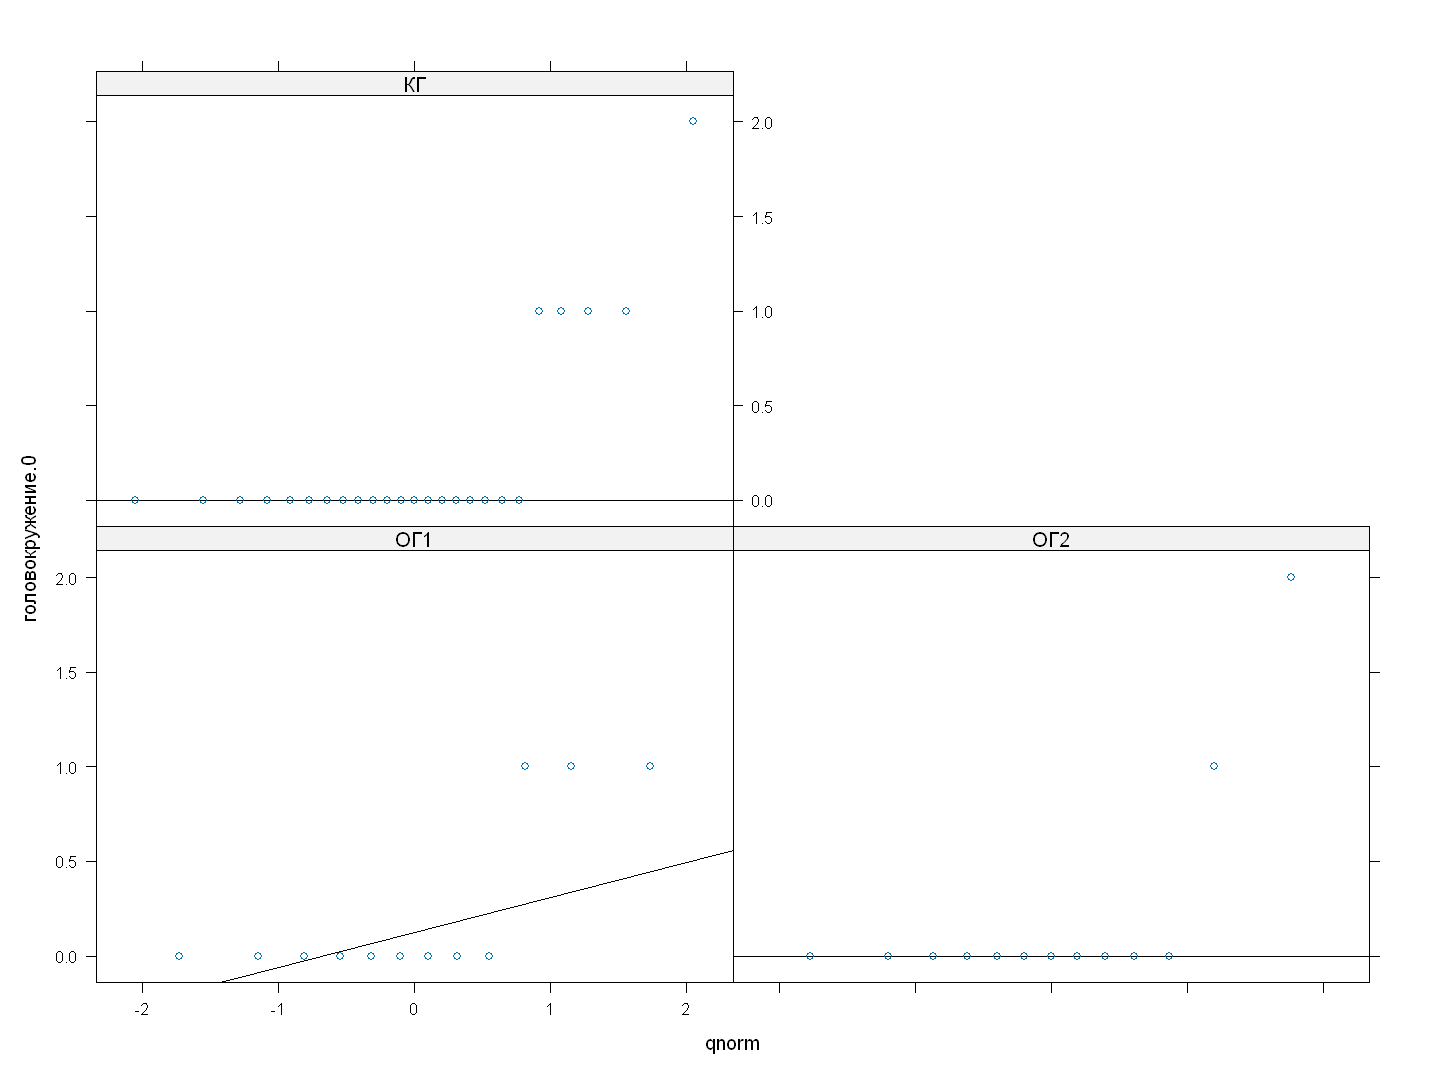

In [175]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

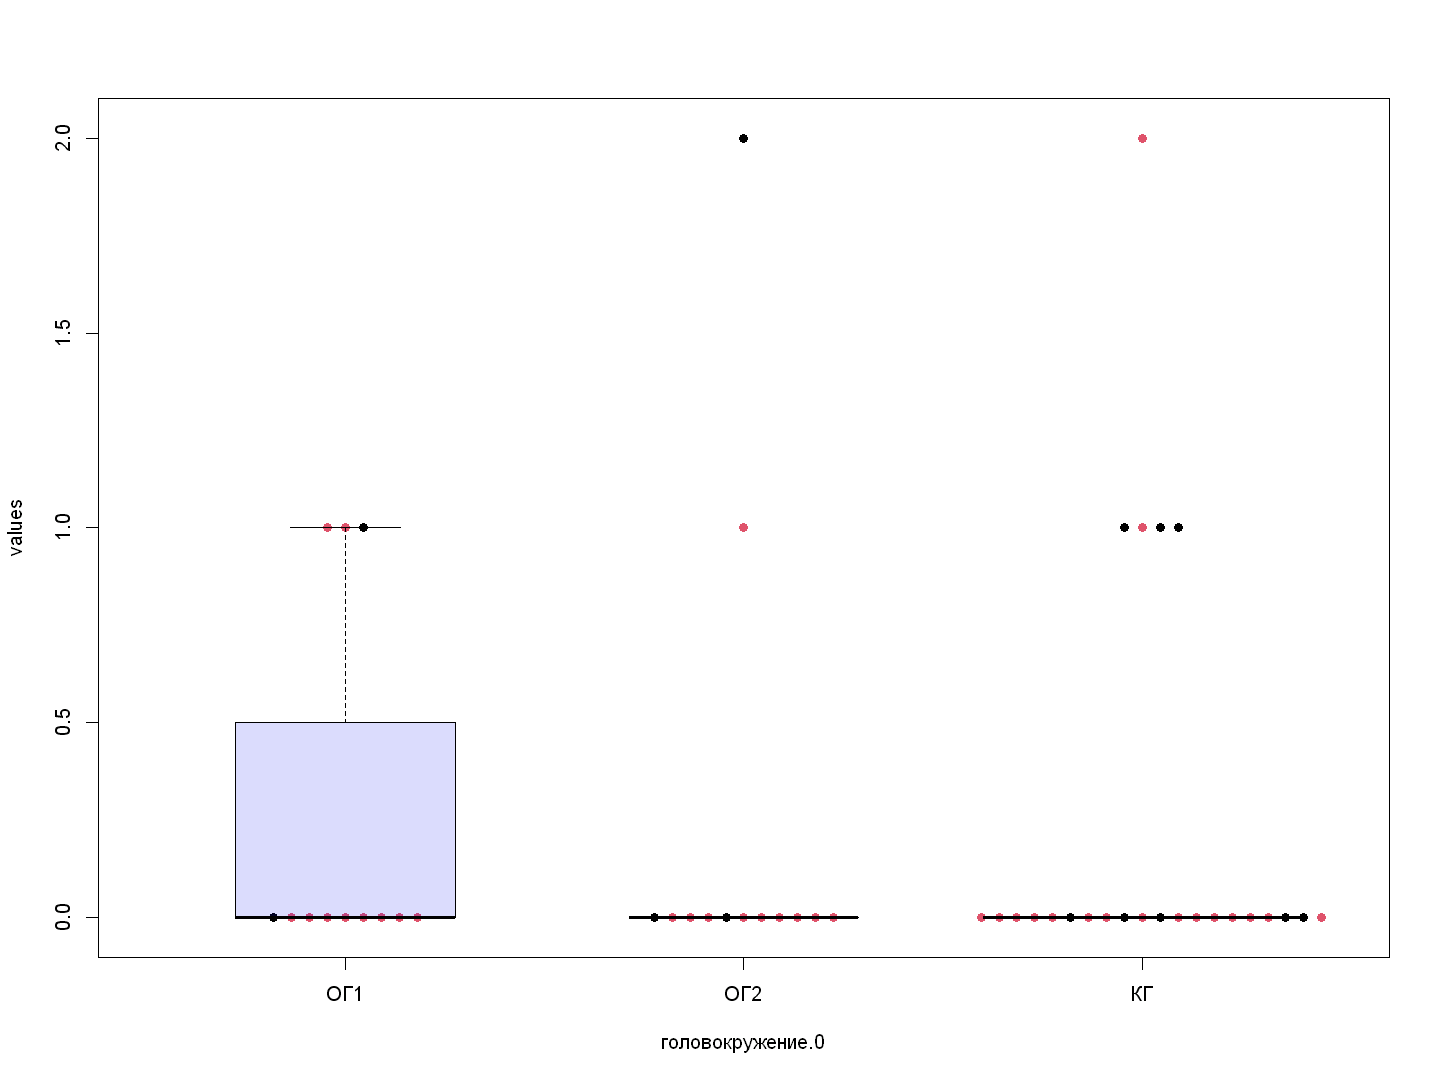

In [176]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [177]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.5521, p-value = 4.398e-05

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.45777, p-value = 4.921e-06

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.51979, p-value = 5.895e-08



In [178]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 0.8712, df = 2, p-value = 0.6469


### Сравнение, нормальные распределения

In [179]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares   0.002308 13.117692
Deg. of Freedom         2        47

Residual standard error: 0.528299
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2  0.002 0.00115   0.004  0.996
Residuals   47 13.118 0.27910               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
                diff        lwr       upr     p adj
ОГ2-ОГ1 -0.019230769 -0.5310595 0.4925980 0.9954523
КГ-ОГ1  -0.010000000 -0.4590112 0.4390112 0.9983997
КГ-ОГ2   0.009230769 -0.4279561 0.4464176 0.9985615


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = 0.091, df = 22.171, p-value = 0.9283
alternative hypothesis: true difference in m

### Сравнение, распределение не нормальное

In [180]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 0.22436, df = 2, p-value = 0.8939

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
          obs.dif critical.dif stat.signif
ОГ1-ОГ2 1.9230769     13.97036       FALSE
ОГ1-КГ  1.0000000     12.25576       FALSE
ОГ2-КГ  0.9230769     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 84, p-value = 0.6674
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = 0.46881, p-value = 0.8579
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 156, p-value = 0.8031
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence 

## головокружение.3

### Общее

In [181]:
parname <- "головокружение.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [182]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [183]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 0.0000000 0.0000000   0  0   0   0   0    0     12
ОГ2 0.1538462 0.5547002   0  0   0   0   0    2     13
КГ  0.2800000 0.5416026   0  0   0   0   0    2     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,0,0,0,0.0000000,0.0000000,12,0
ОГ2,0,0,0,0,2,0.1538462,0.5547002,13,0
КГ,0,0,0,0,2,0.2800000,0.5416026,25,0


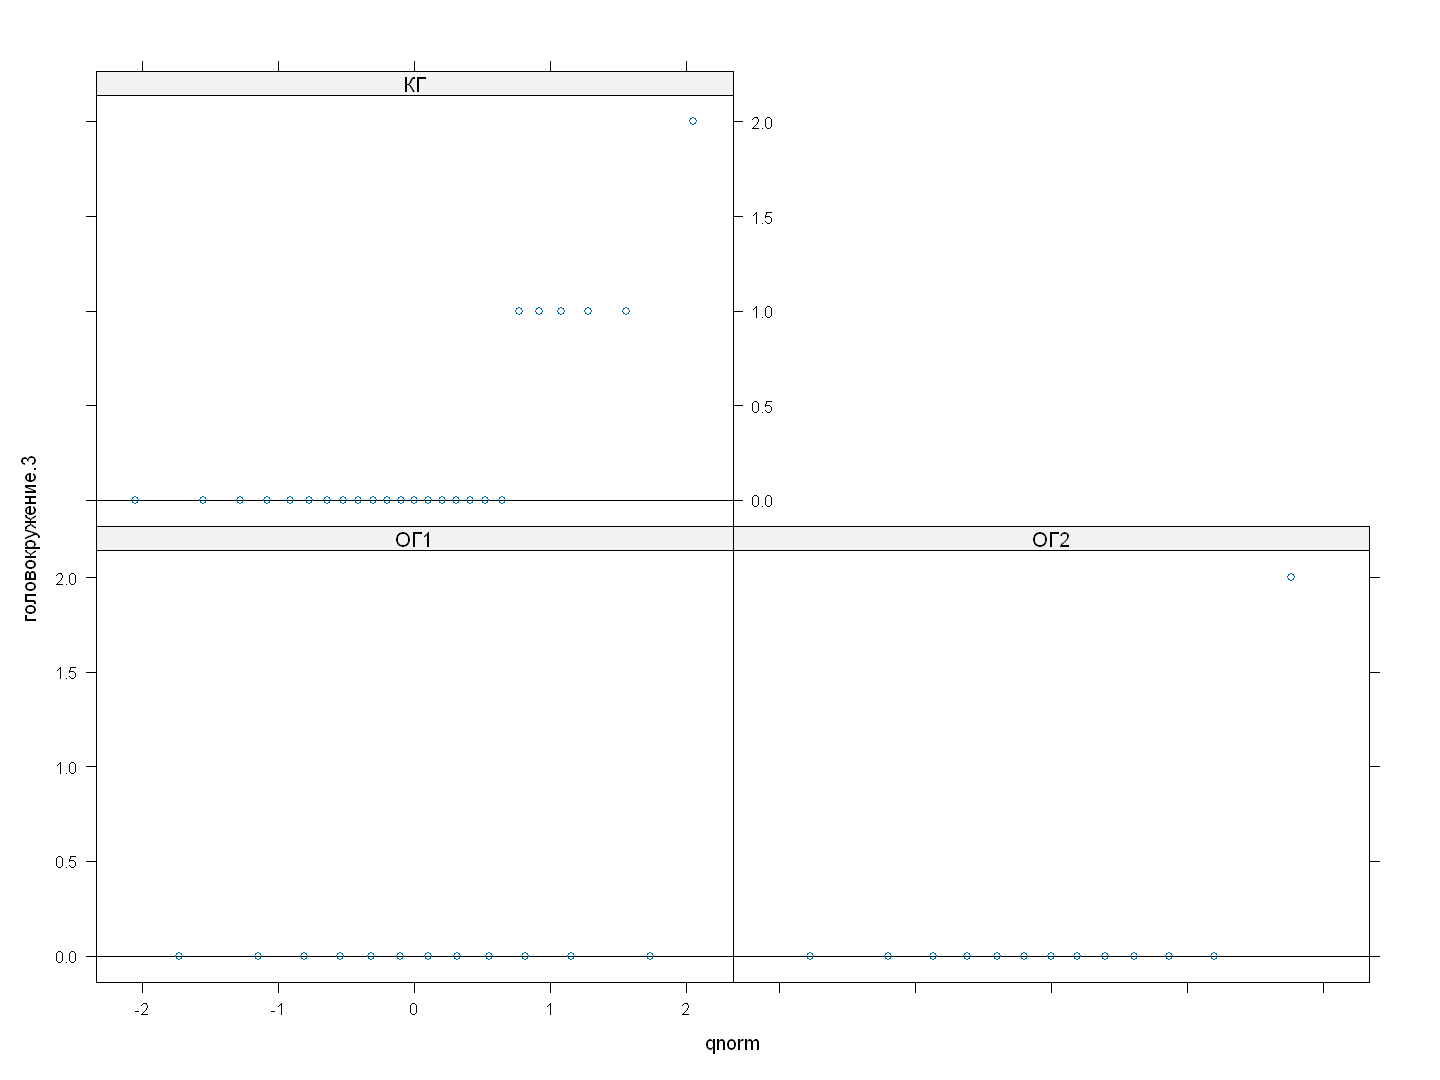

In [184]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

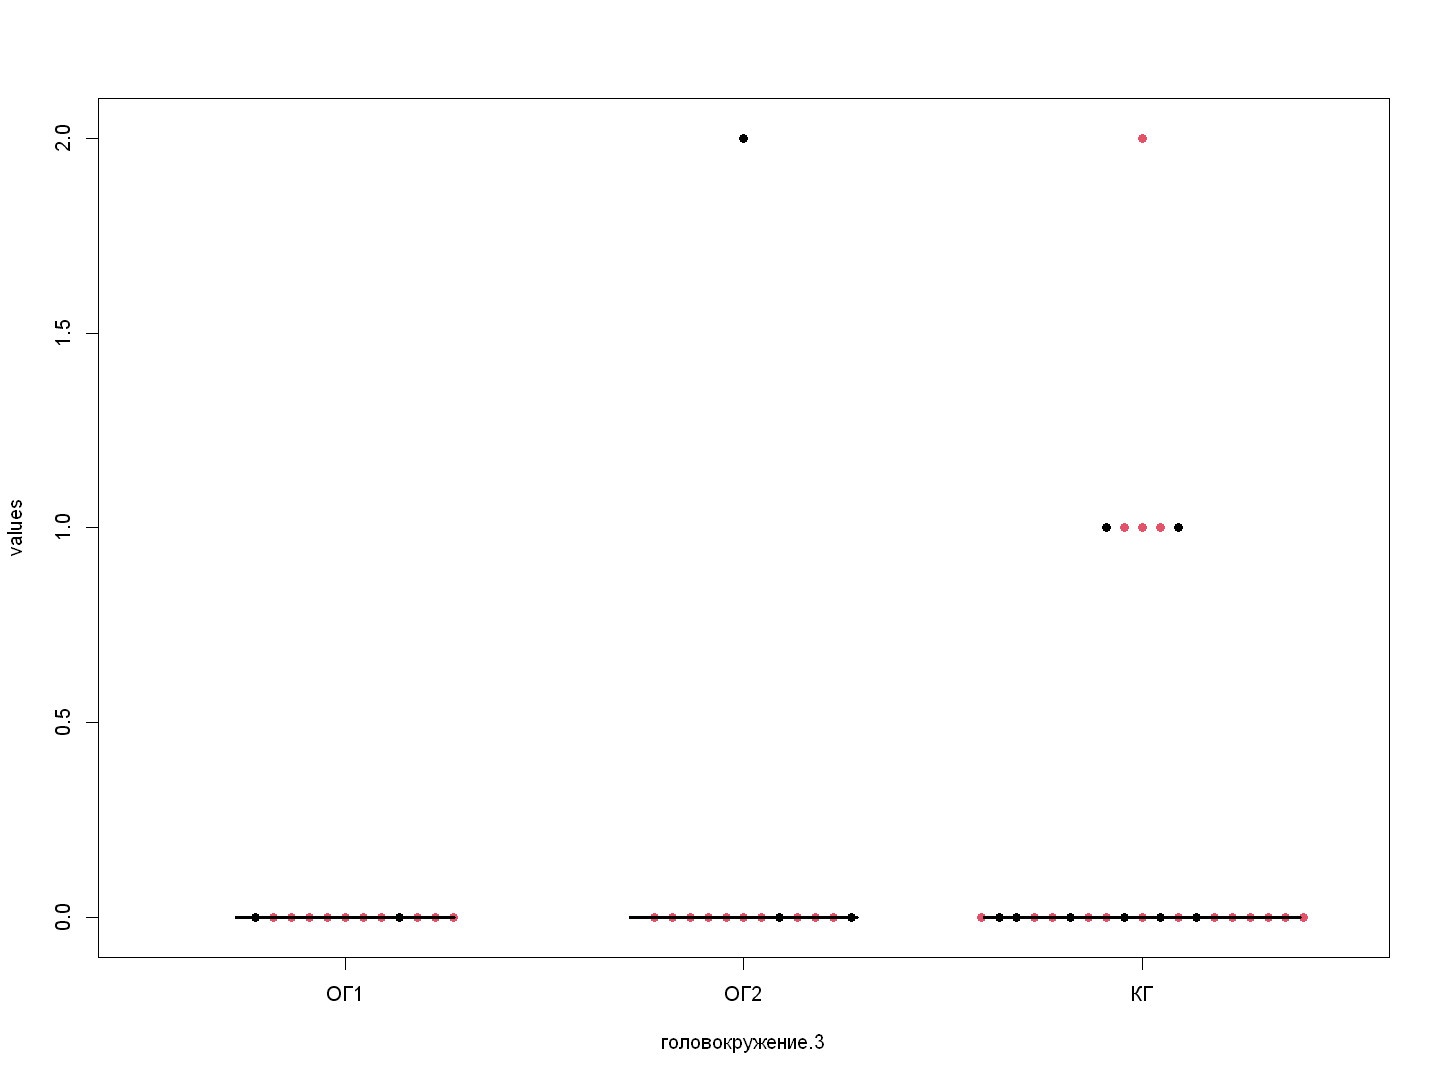

In [185]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [186]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1Error in h(simpleError(msg, call)) : 
  error in evaluating the argument 'x' in selecting a method for function 'print': all 'x' values are identical
Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.31101, p-value = 5.045e-07

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.56859, p-value = 1.911e-07



In [187]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = Inf, df = 2, p-value < 2.2e-16


### Сравнение, нормальные распределения

In [188]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares   0.647692 10.732308
Deg. of Freedom         2        47

Residual standard error: 0.4778566
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2  0.648  0.3238   1.418  0.252
Residuals   47 10.732  0.2283               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
             diff        lwr       upr     p adj
ОГ2-ОГ1 0.1538462 -0.3091128 0.6168051 0.7022779
КГ-ОГ1  0.2800000 -0.1261393 0.6861393 0.2279209
КГ-ОГ2  0.1261538 -0.2692901 0.5215978 0.7218459


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -1, df = 12, p-value = 0.337
alternative hypothesis: true difference in means is not equal t

### Сравнение, распределение не нормальное

In [189]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 4.0953, df = 2, p-value = 0.129

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ1-ОГ2 2.115385     13.97036       FALSE
ОГ1-КГ  5.900000     12.25576       FALSE
ОГ2-КГ  3.784615     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 72, p-value = 0.3785
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = -0.96077, p-value = 1
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 114, p-value = 0.07194
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

dat

## боль в ушах.0

### Общее

In [190]:
parname <- "боль в ушах.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [191]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [192]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 0.1666667 0.3892495   0  0   0   0   0    1     12
ОГ2 0.0000000 0.0000000   0  0   0   0   0    0     13
КГ  0.1200000 0.4396969   0  0   0   0   0    2     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,0,0,1,0.1666667,0.3892495,12,0
ОГ2,0,0,0,0,0,0.0000000,0.0000000,13,0
КГ,0,0,0,0,2,0.1200000,0.4396969,25,0


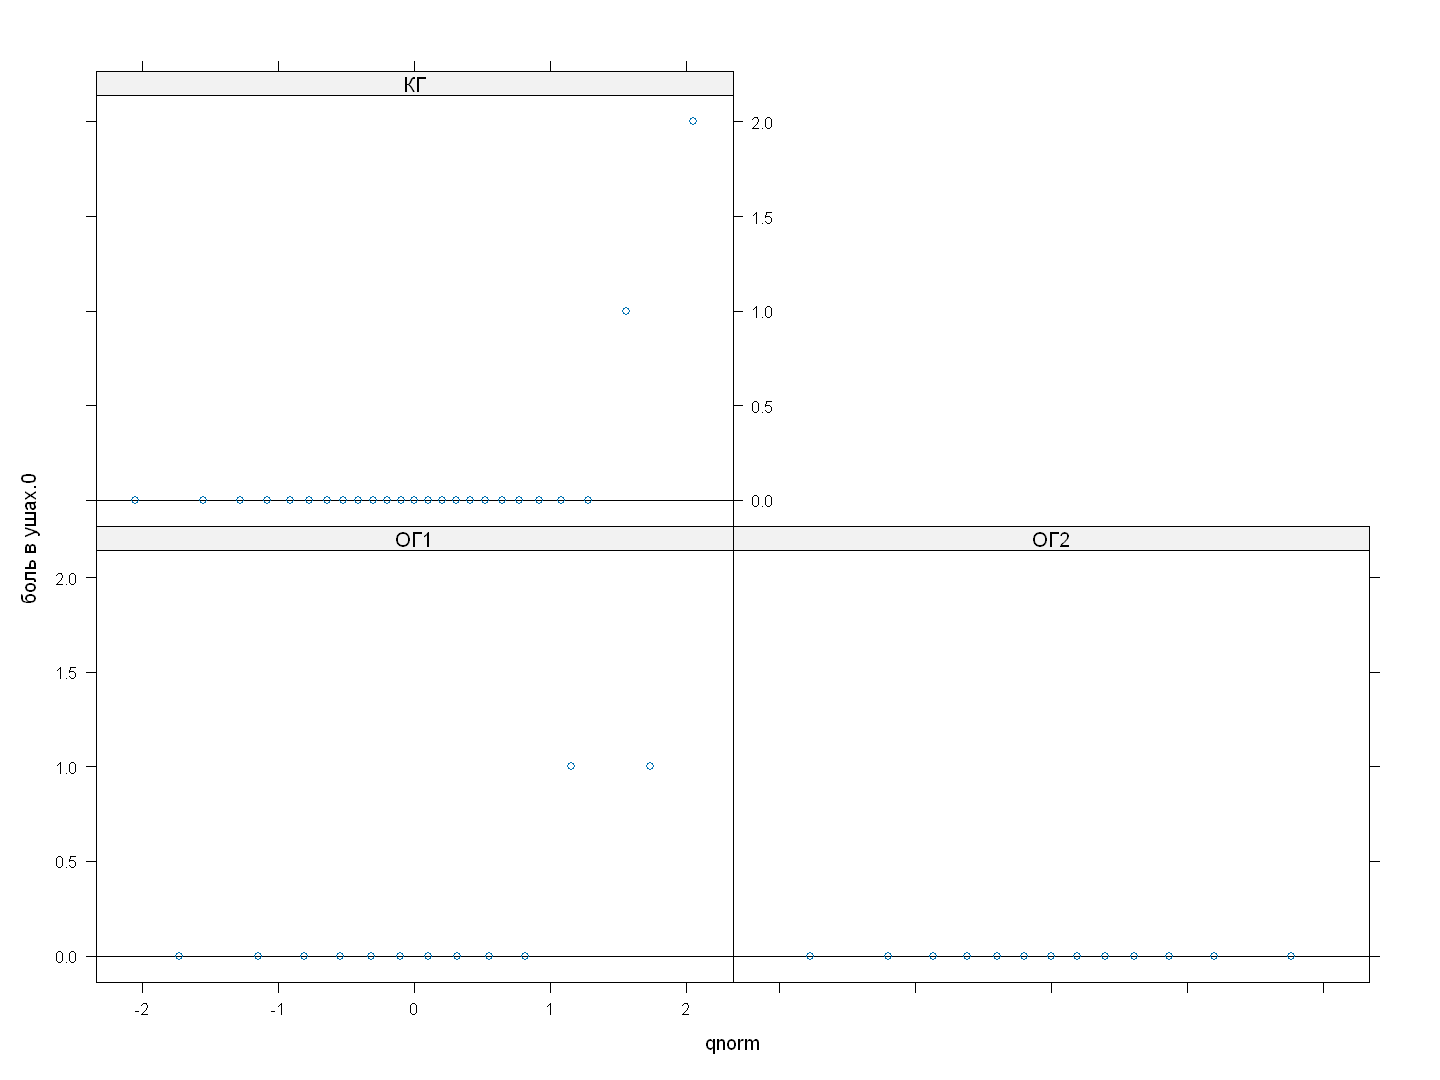

In [193]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

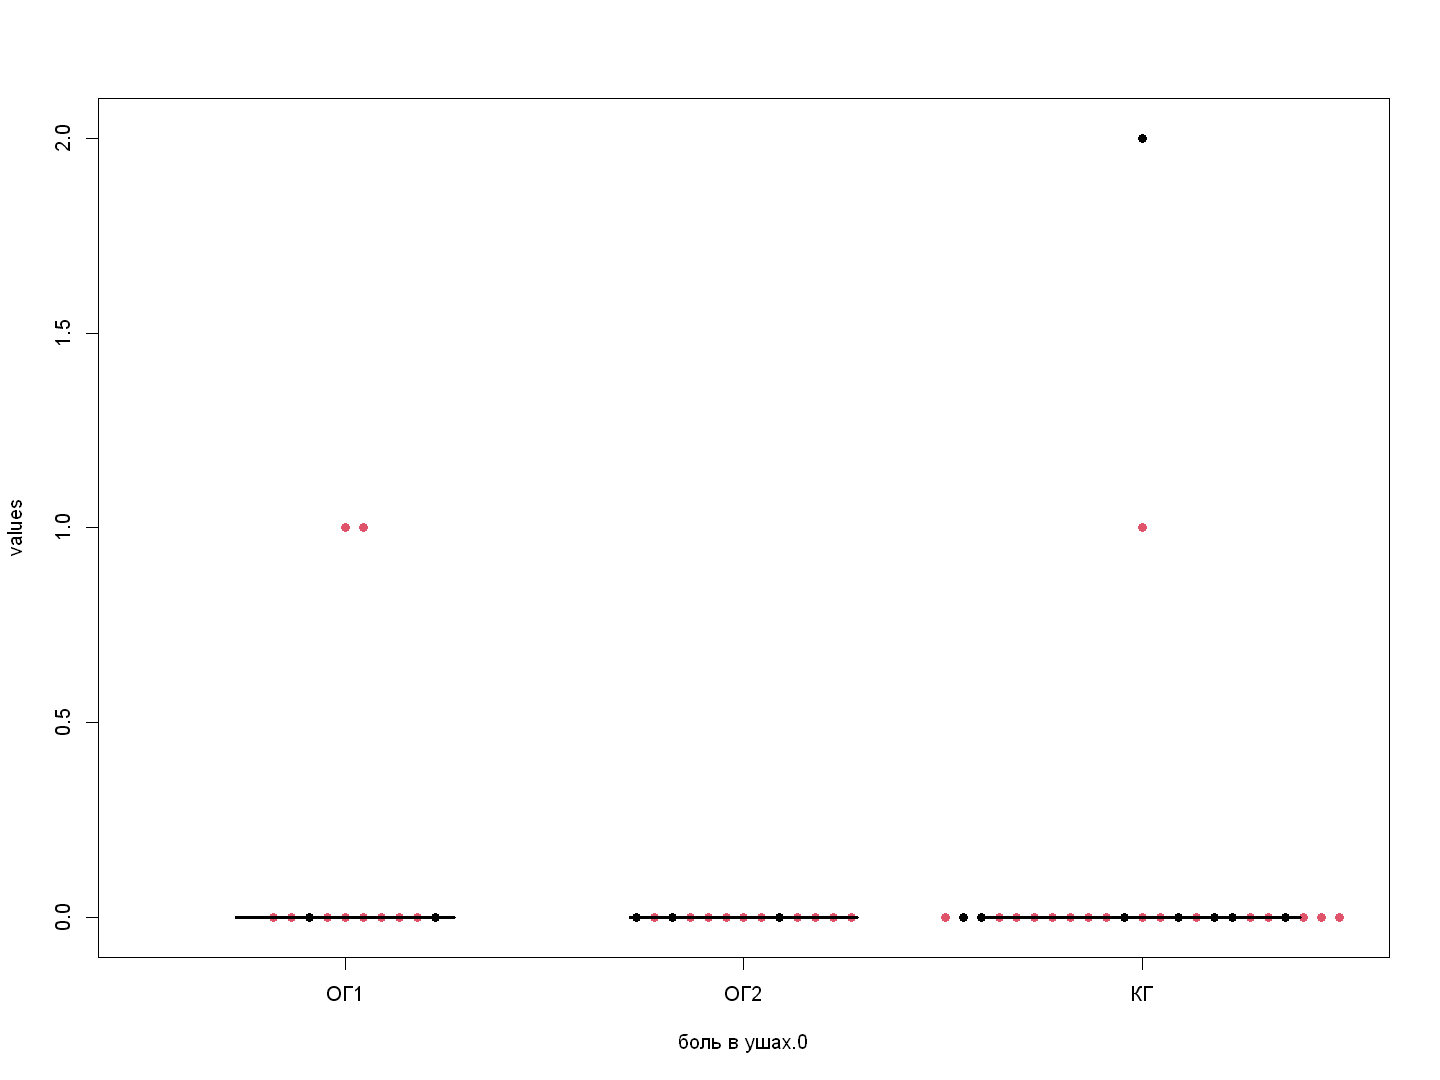

In [194]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [195]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.46465, p-value = 9.811e-06

Группа — ОГ2Error in h(simpleError(msg, call)) : 
  error in evaluating the argument 'x' in selecting a method for function 'print': all 'x' values are identical
Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.30748, p-value = 7.464e-10



In [196]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = Inf, df = 2, p-value < 2.2e-16


### Сравнение, нормальные распределения

In [197]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares   0.193333  6.306667
Deg. of Freedom         2        47

Residual standard error: 0.3663119
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2  0.193 0.09667    0.72  0.492
Residuals   47  6.307 0.13418               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
               diff        lwr       upr     p adj
ОГ2-ОГ1 -0.16666667 -0.5215584 0.1882251 0.4967213
КГ-ОГ1  -0.04666667 -0.3580020 0.2646687 0.9301419
КГ-ОГ2   0.12000000 -0.1831366 0.4231366 0.6067224


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = 1.4832, df = 11, p-value = 0.1661
alternative hypothesis: true difference in means i

### Сравнение, распределение не нормальное

In [198]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 2.2154, df = 2, p-value = 0.3303

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ1-ОГ2 4.083333     13.97036       FALSE
ОГ1-КГ  2.043333     12.25576       FALSE
ОГ2-КГ  2.040000     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 91, p-value = 0.1482
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = 1.5036, p-value = 0.22
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 162, p-value = 0.4885
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

da

## боль в ушах.3

### Общее

In [199]:
parname <- "боль в ушах.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [200]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [201]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 0.0000000 0.0000000   0  0   0   0   0    0     12
ОГ2 0.1538462 0.5547002   0  0   0   0   0    2     13
КГ  0.0400000 0.2000000   0  0   0   0   0    1     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,0,0,0,0.0000000,0.0000000,12,0
ОГ2,0,0,0,0,2,0.1538462,0.5547002,13,0
КГ,0,0,0,0,1,0.0400000,0.2000000,25,0


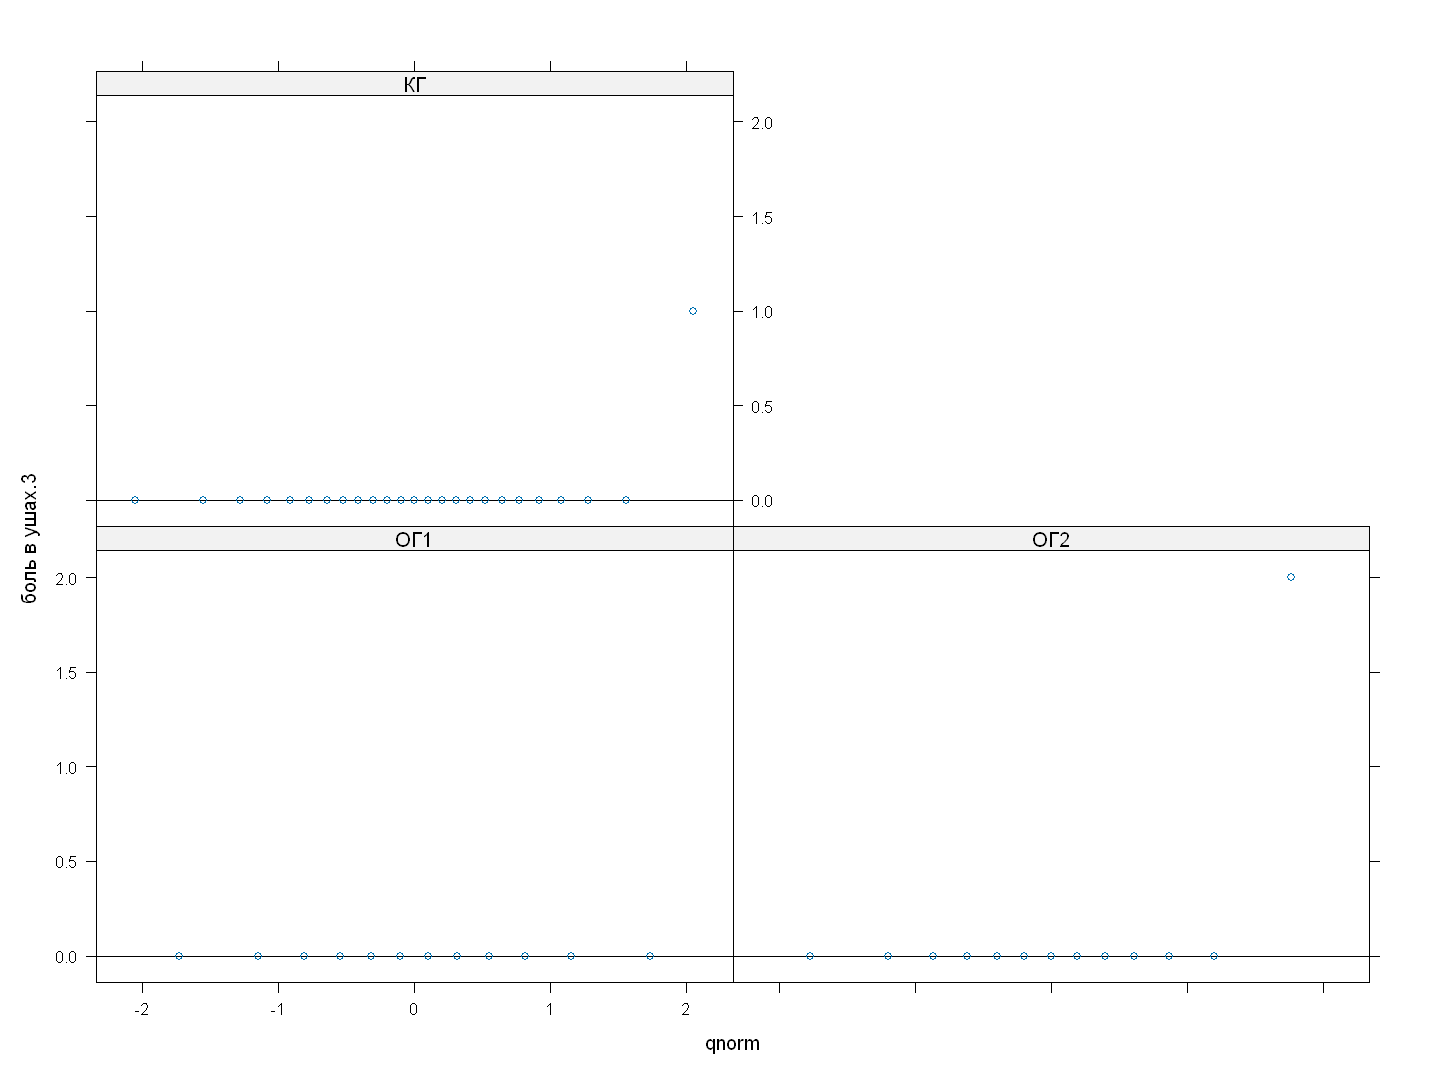

In [202]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

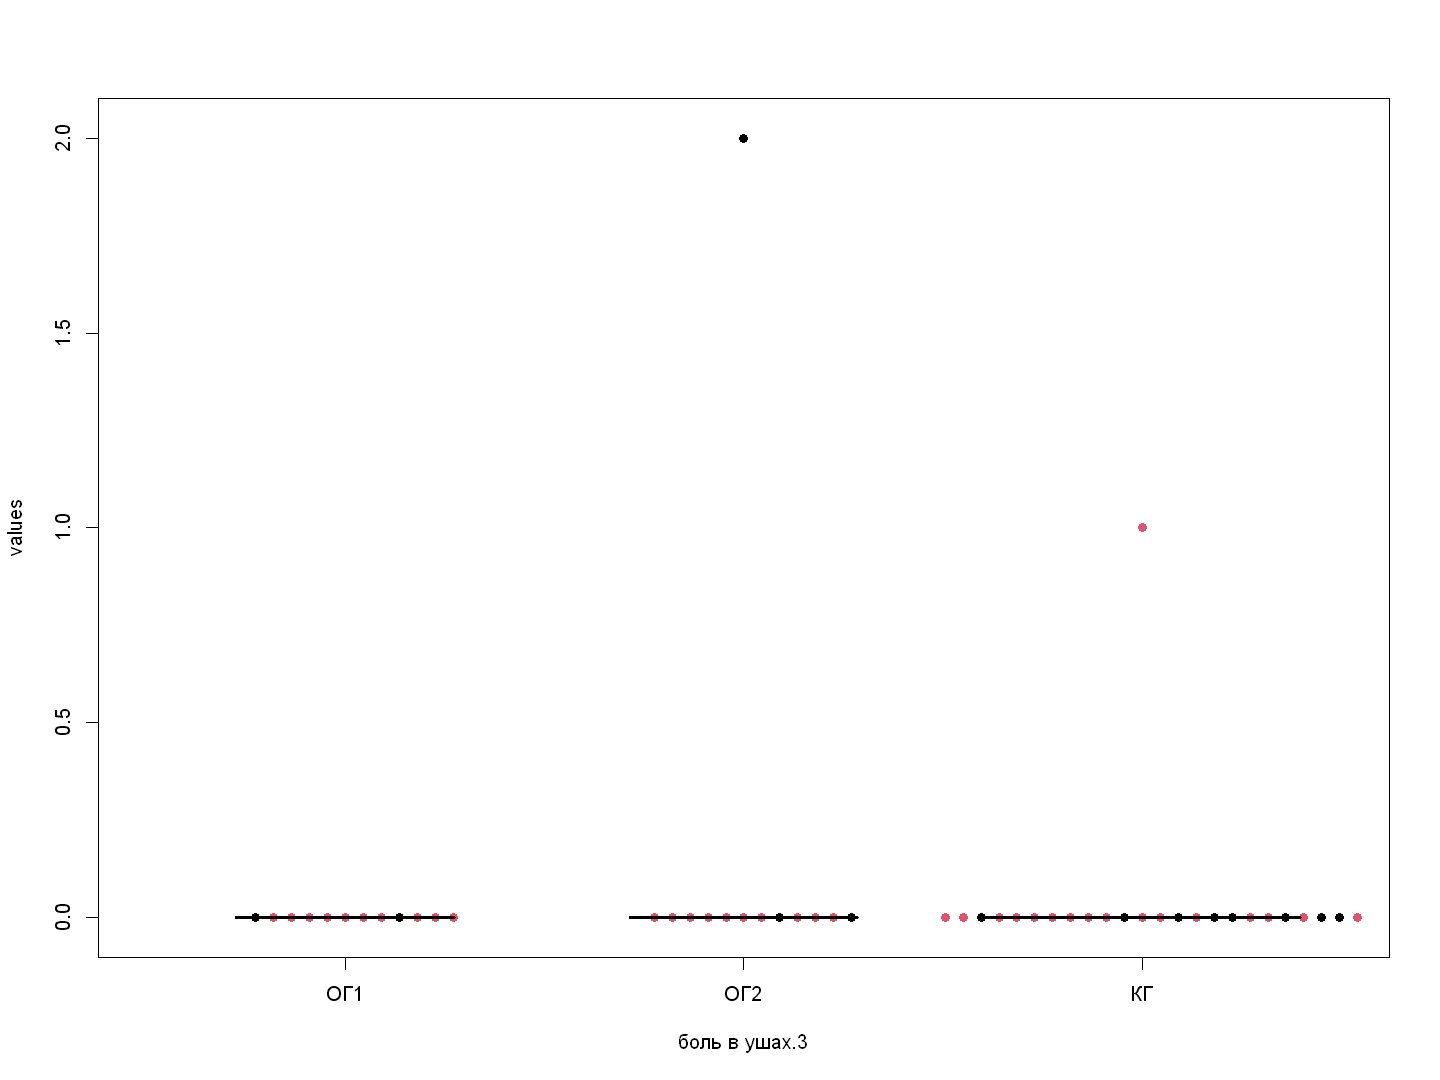

In [203]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [204]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1Error in h(simpleError(msg, call)) : 
  error in evaluating the argument 'x' in selecting a method for function 'print': all 'x' values are identical
Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.31101, p-value = 5.045e-07

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.20332, p-value = 1.214e-10



In [205]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = Inf, df = 2, p-value < 2.2e-16


### Сравнение, нормальные распределения

In [206]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares   0.167692  4.652308
Deg. of Freedom         2        47

Residual standard error: 0.3146192
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2  0.168 0.08385   0.847  0.435
Residuals   47  4.652 0.09899               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
              diff        lwr       upr     p adj
ОГ2-ОГ1  0.1538462 -0.1509645 0.4586568 0.4466090
КГ-ОГ1   0.0400000 -0.2274008 0.3074008 0.9304142
КГ-ОГ2  -0.1138462 -0.3742052 0.1465128 0.5444290


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -1, df = 12, p-value = 0.337
alternative hypothesis: true difference in means is not equ

### Сравнение, распределение не нормальное

In [207]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 0.98078, df = 2, p-value = 0.6124

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
          obs.dif critical.dif stat.signif
ОГ1-ОГ2 1.9615385     13.97036       FALSE
ОГ1-КГ  0.9800000     12.25576       FALSE
ОГ2-КГ  0.9815385     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 72, p-value = 0.3785
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = -0.96077, p-value = 1
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 144, p-value = 0.5254
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

## боль в лице.0

### Общее

In [208]:
parname <- "боль в лице.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

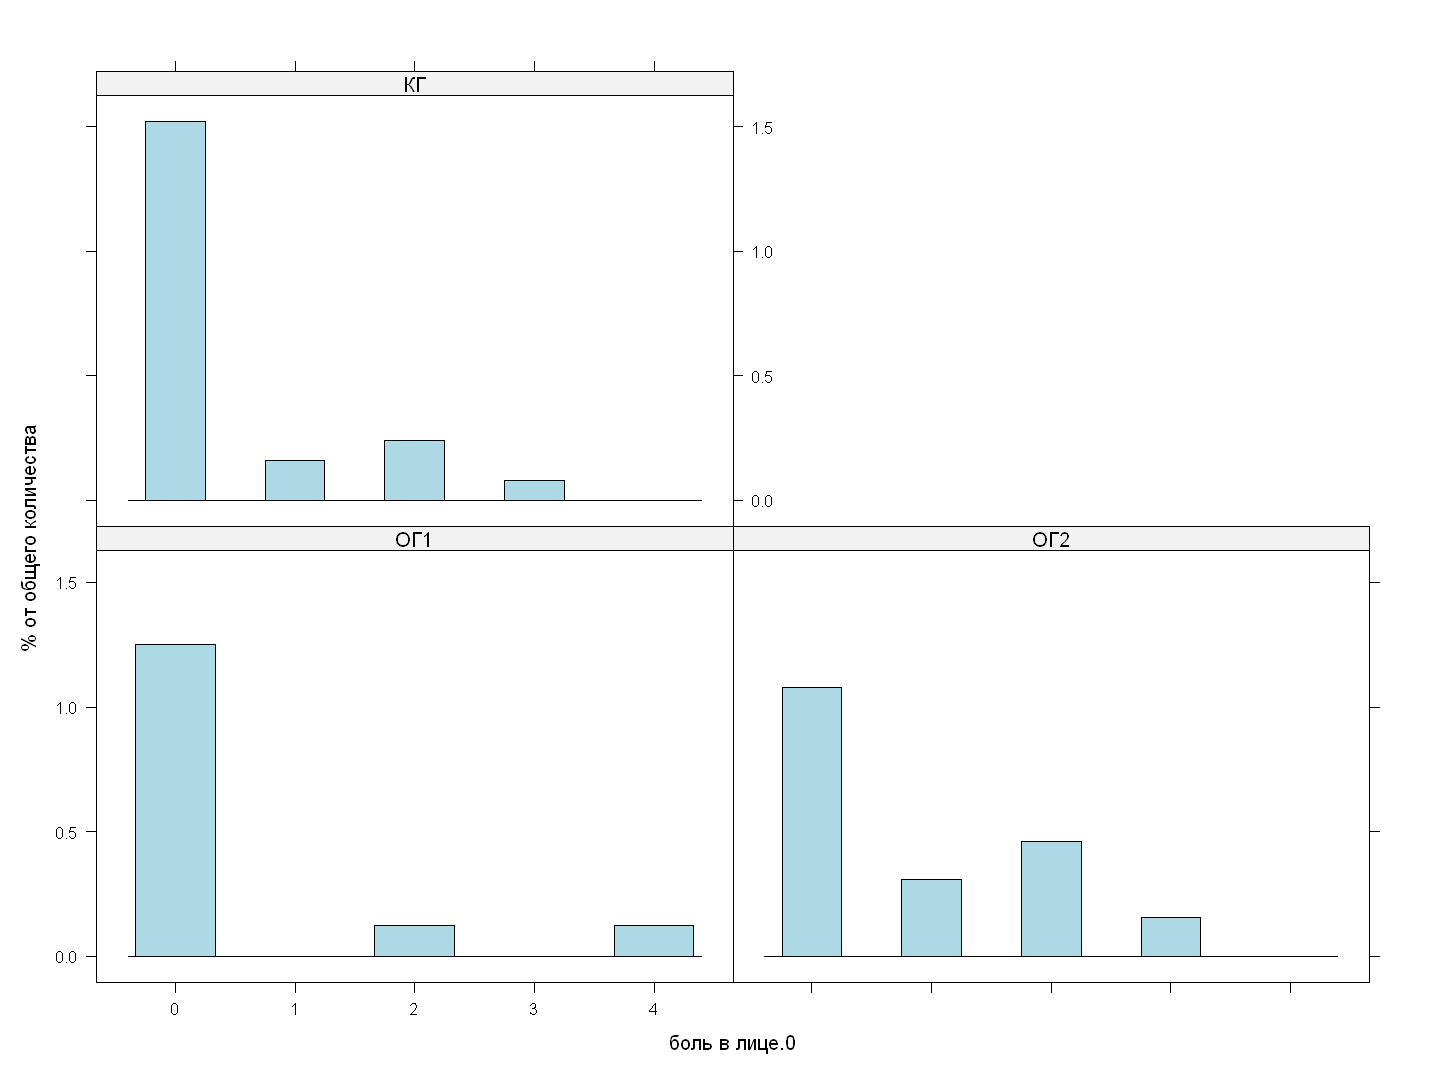

In [209]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [210]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 0.5000000 1.2431631   0  0   0   0   0    4     12
ОГ2 0.8461538 1.0681880   2  0   0   0   2    3     13
КГ  0.4400000 0.8698659   0  0   0   0   0    3     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,0,0,4,0.5000000,1.2431631,12,0
ОГ2,0,0,0,2,3,0.8461538,1.0681880,13,0
КГ,0,0,0,0,3,0.4400000,0.8698659,25,0


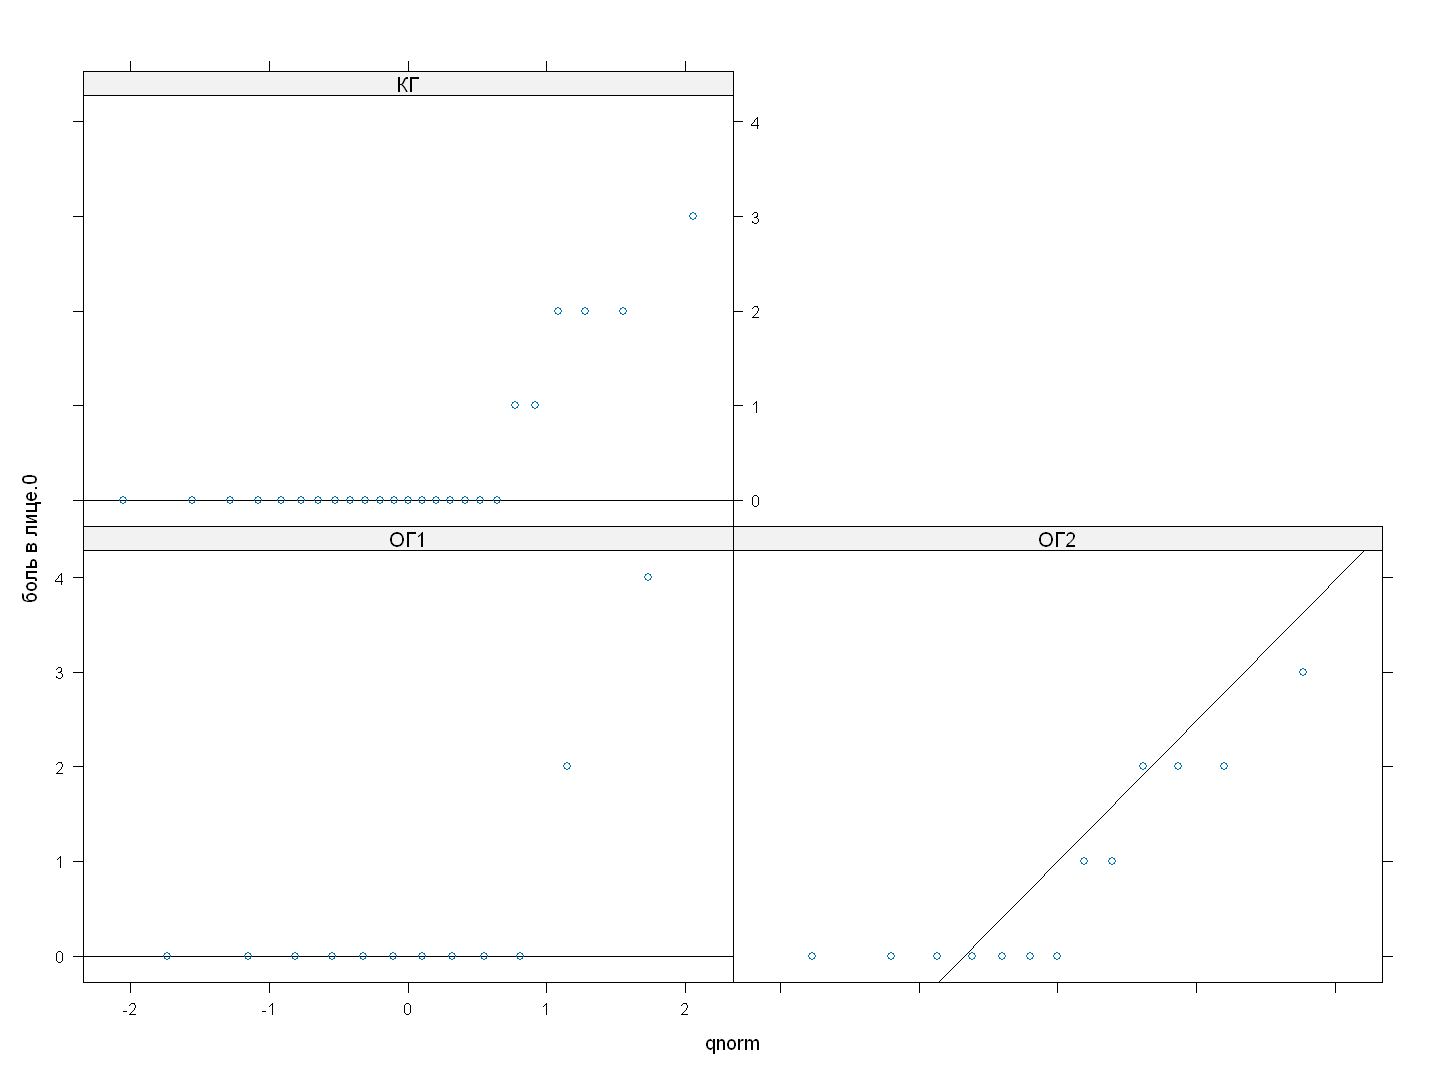

In [211]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

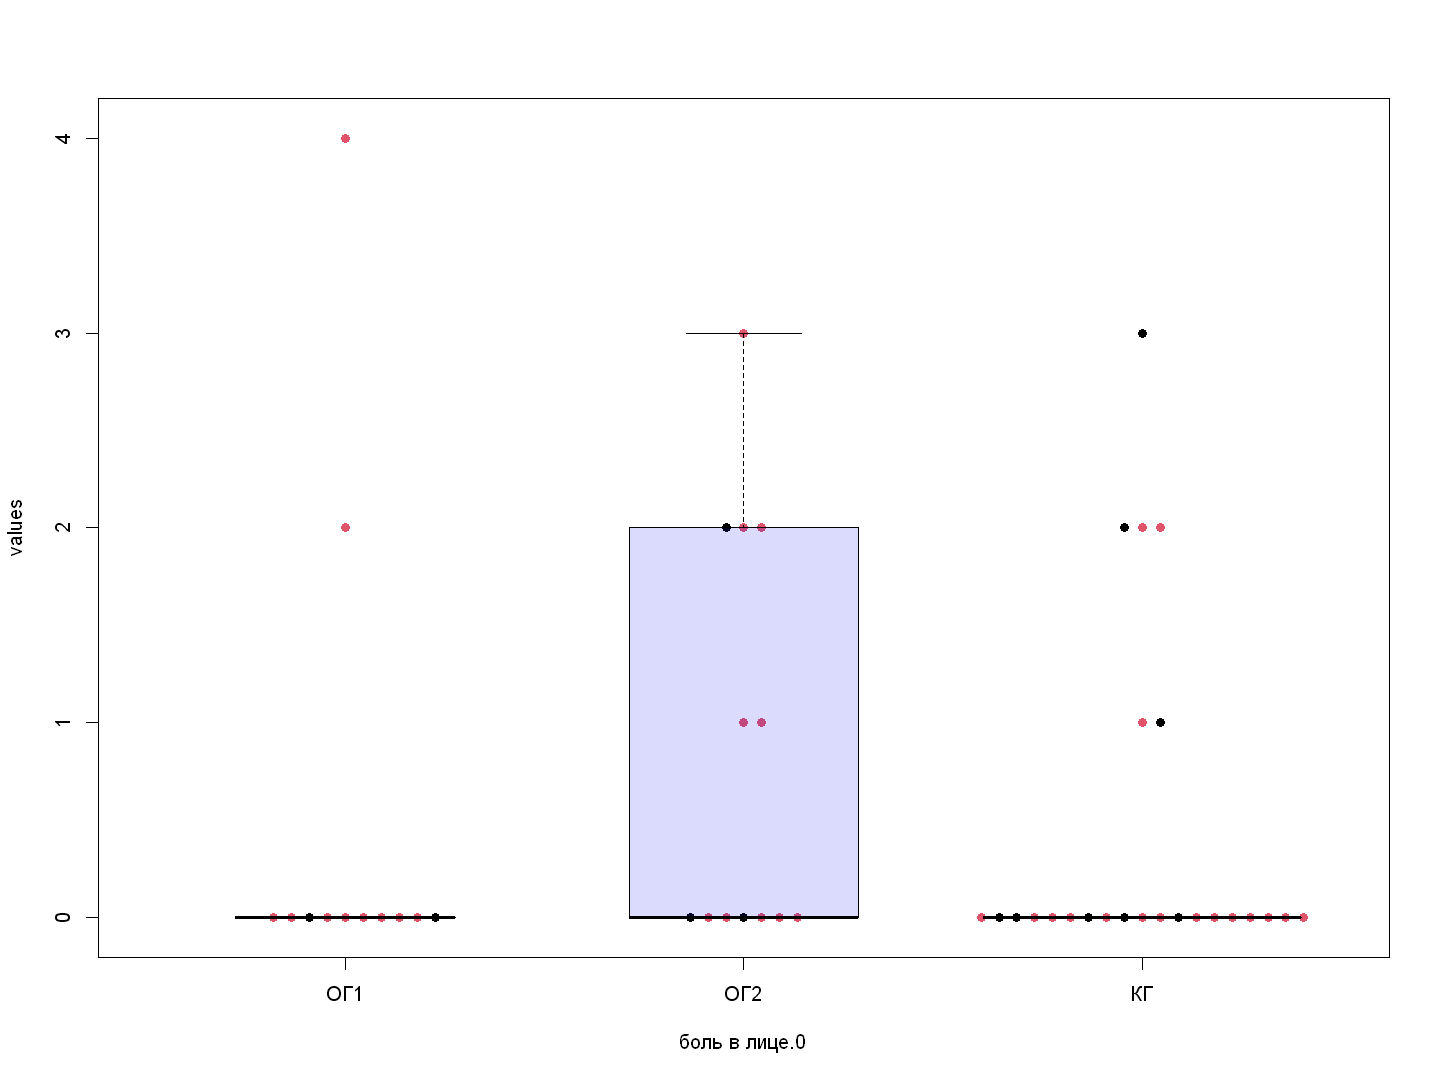

In [212]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [213]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.47944, p-value = 1.251e-05

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.77634, p-value = 0.003617

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.57199, p-value = 2.08e-07



In [214]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 2.0699, df = 2, p-value = 0.3552


### Сравнение, нормальные распределения

In [215]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares    1.46769  48.85231
Deg. of Freedom         2        47

Residual standard error: 1.019515
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2   1.47  0.7338   0.706  0.499
Residuals   47  48.85  1.0394               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
              diff        lwr       upr     p adj
ОГ2-ОГ1  0.3461538 -0.6415768 1.3338845 0.6752429
КГ-ОГ1  -0.0600000 -0.9265049 0.8065049 0.9846425
КГ-ОГ2  -0.4061538 -1.2498400 0.4375323 0.4796895


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -0.74384, df = 21.815, p-value = 0.4649
alternative hypothesis: true difference in means 

### Сравнение, распределение не нормальное

In [216]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 2.4914, df = 2, p-value = 0.2877

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ1-ОГ2 6.519231     13.97036       FALSE
ОГ1-КГ  1.110000     12.25576       FALSE
ОГ2-КГ  5.409231     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 58.5, p-value = 0.2108
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = -1.2844, p-value = 0.2128
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 142.5, p-value = 0.7522
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence T

## боль в лице.3

### Общее

In [217]:
parname <- "боль в лице.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [218]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [219]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 0.0000000 0.0000000   0  0   0   0   0    0     12
ОГ2 0.1538462 0.5547002   0  0   0   0   0    2     13
КГ  0.1200000 0.3316625   0  0   0   0   0    1     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,0,0,0,0.0000000,0.0000000,12,0
ОГ2,0,0,0,0,2,0.1538462,0.5547002,13,0
КГ,0,0,0,0,1,0.1200000,0.3316625,25,0


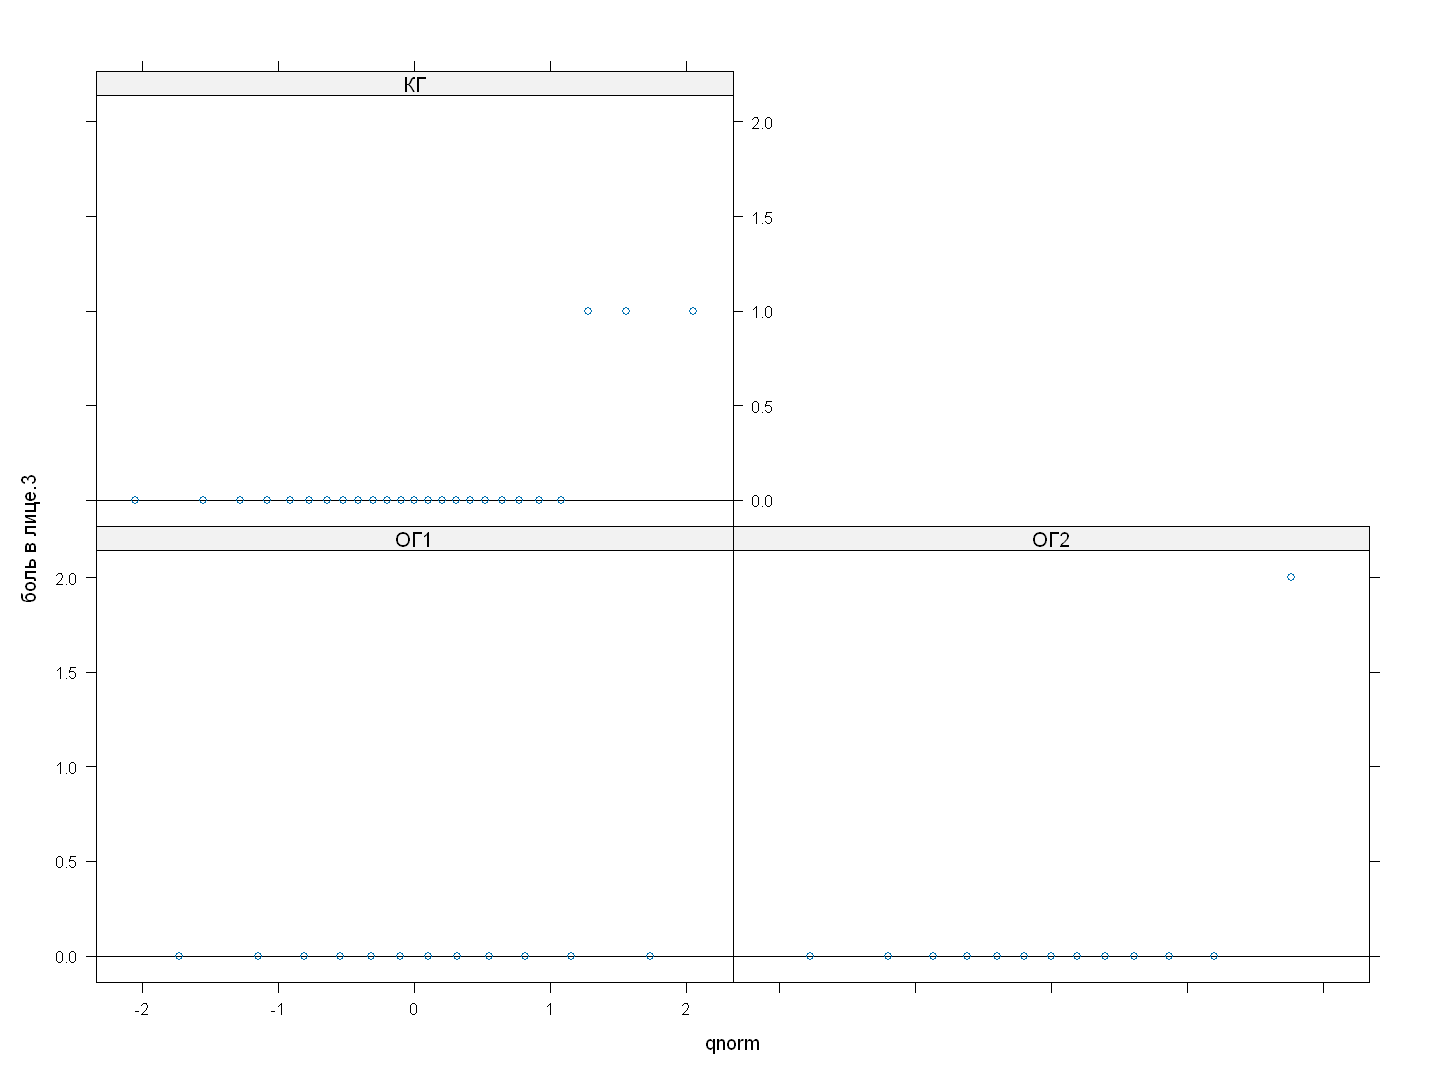

In [220]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

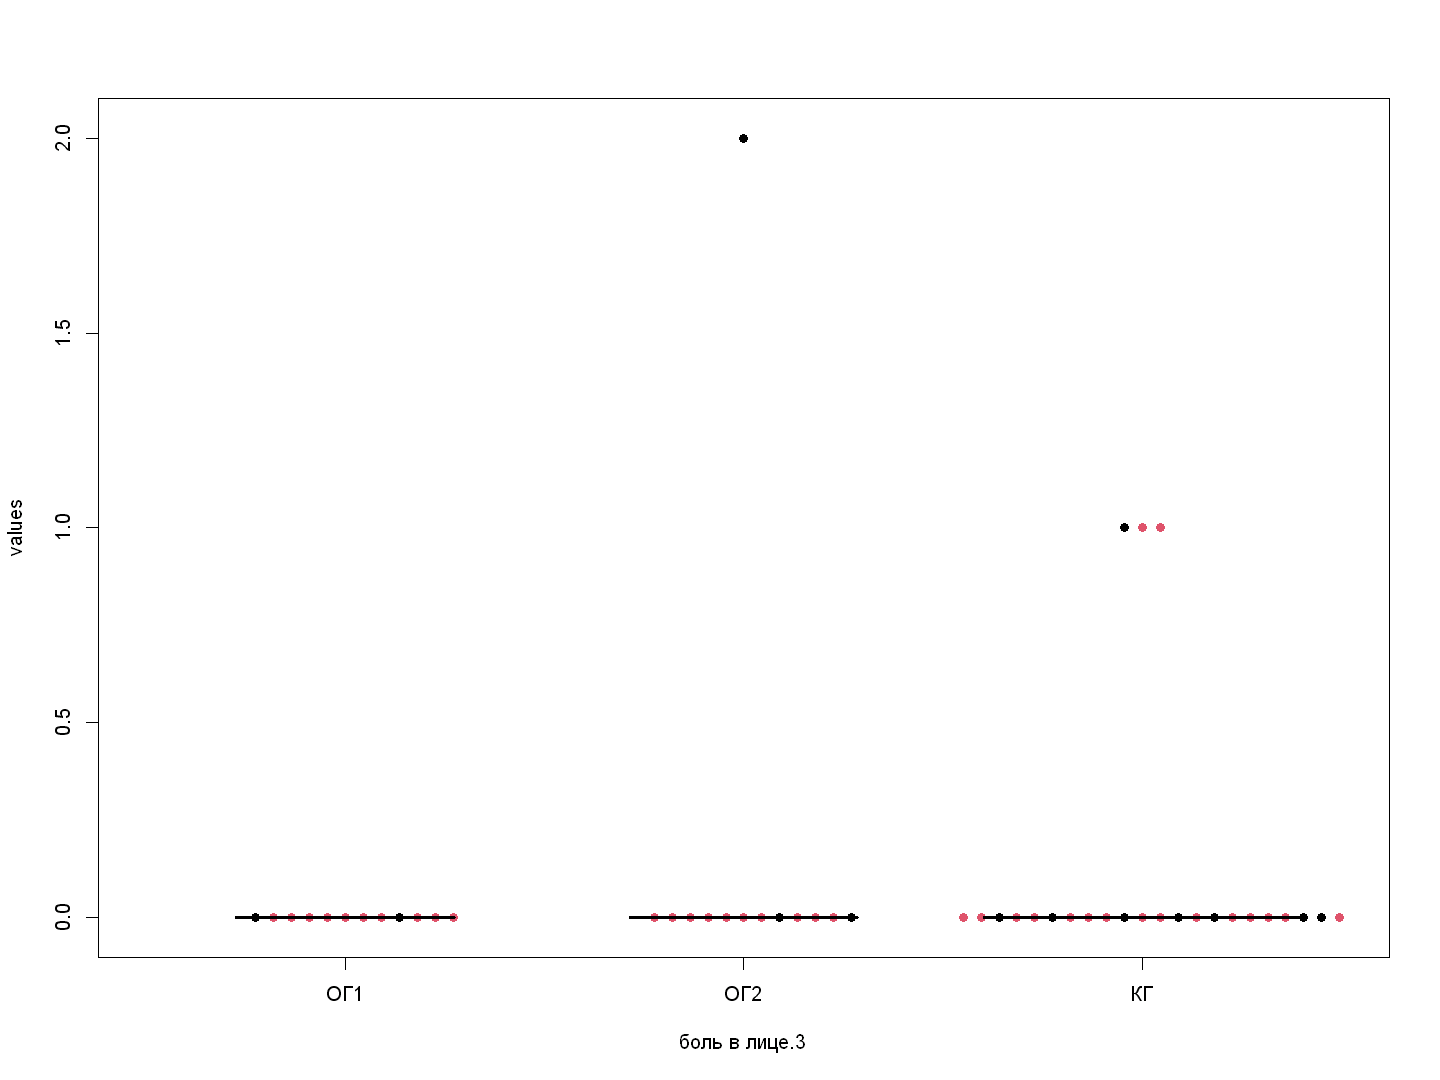

In [221]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [222]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1Error in h(simpleError(msg, call)) : 
  error in evaluating the argument 'x' in selecting a method for function 'print': all 'x' values are identical
Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.31101, p-value = 5.045e-07

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.3842, p-value = 3.216e-09



In [223]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = Inf, df = 2, p-value < 2.2e-16


### Сравнение, нормальные распределения

In [224]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares   0.167692  6.332308
Deg. of Freedom         2        47

Residual standard error: 0.3670558
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2  0.168 0.08385   0.622  0.541
Residuals   47  6.332 0.13473               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
               diff        lwr       upr     p adj
ОГ2-ОГ1  0.15384615 -0.2017663 0.5094586 0.5513619
КГ-ОГ1   0.12000000 -0.1919676 0.4319676 0.6236772
КГ-ОГ2  -0.03384615 -0.3375983 0.2699060 0.9607394


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -1, df = 12, p-value = 0.337
alternative hypothesis: true difference in means is not

### Сравнение, распределение не нормальное

In [225]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 1.4917, df = 2, p-value = 0.4743

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
          obs.dif critical.dif stat.signif
ОГ1-ОГ2 2.0384615     13.97036       FALSE
ОГ1-КГ  2.9400000     12.25576       FALSE
ОГ2-КГ  0.9015385     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 72, p-value = 0.3785
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = -0.96077, p-value = 1
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 132, p-value = 0.2299
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test


## трудно заснуть.0

### Общее

In [226]:
parname <- "трудно заснуть.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

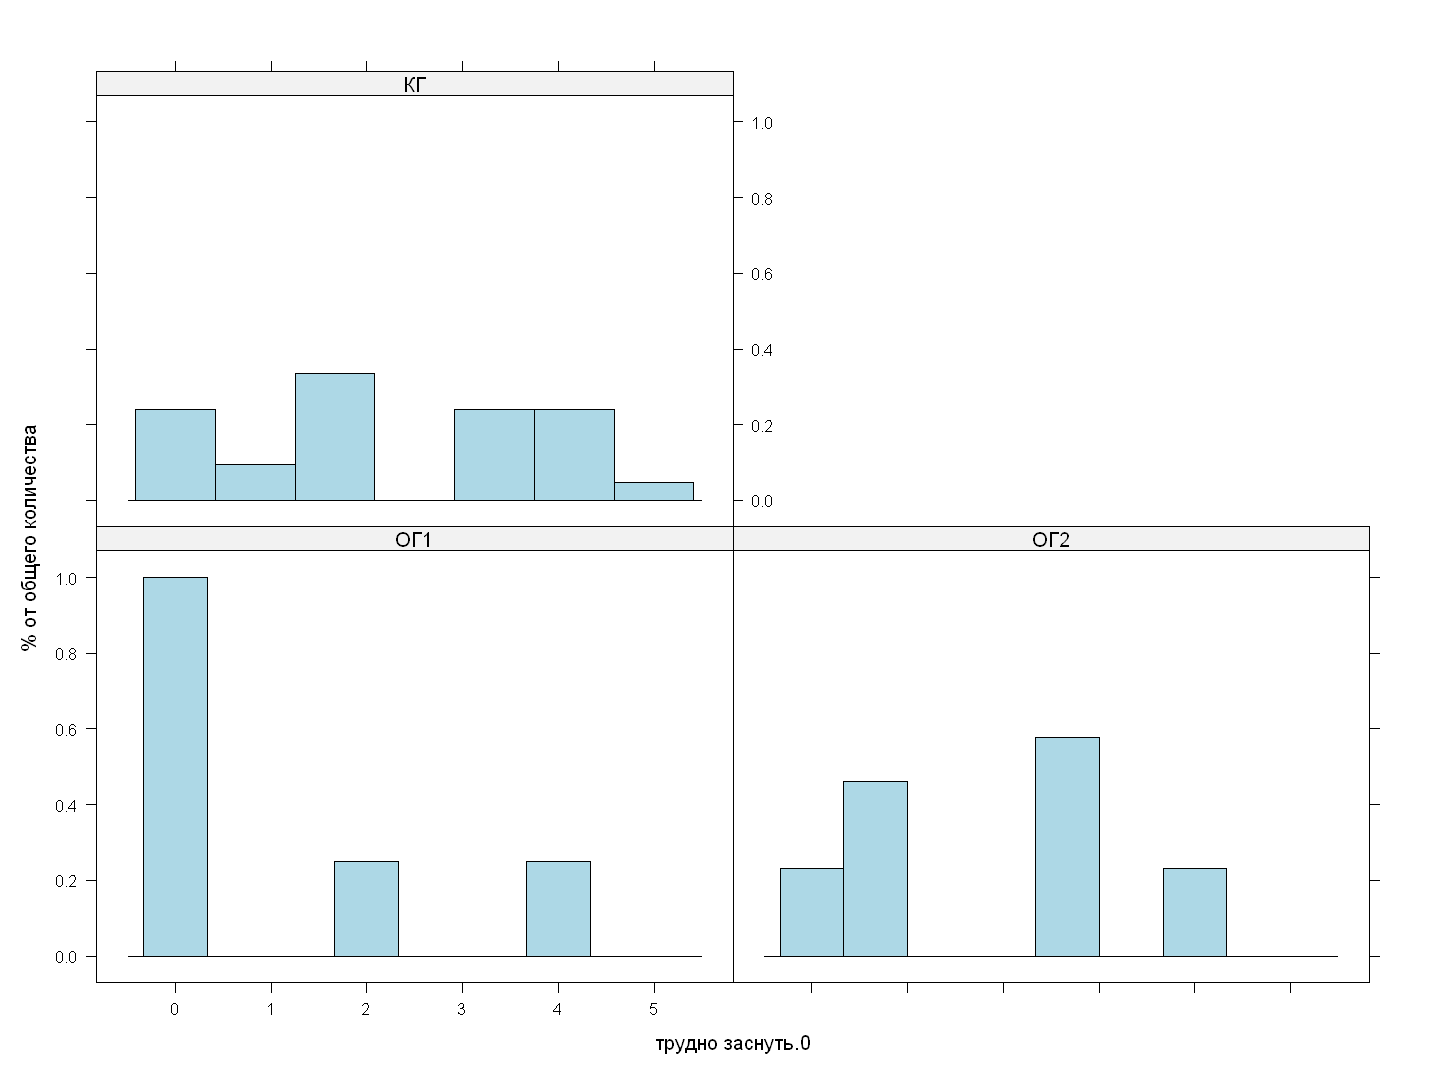

In [227]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [228]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

        mean       sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 1.000000 1.595448   2  0   0   0   2    4     12
ОГ2 2.076923 1.441153   2  0   1   3   3    4     13
КГ  2.240000 1.507758   2  0   1   2   3    5     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,0,2,4,1.000000,1.595448,12,0
ОГ2,0,1,3,3,4,2.076923,1.441153,13,0
КГ,0,1,2,3,5,2.240000,1.507758,25,0


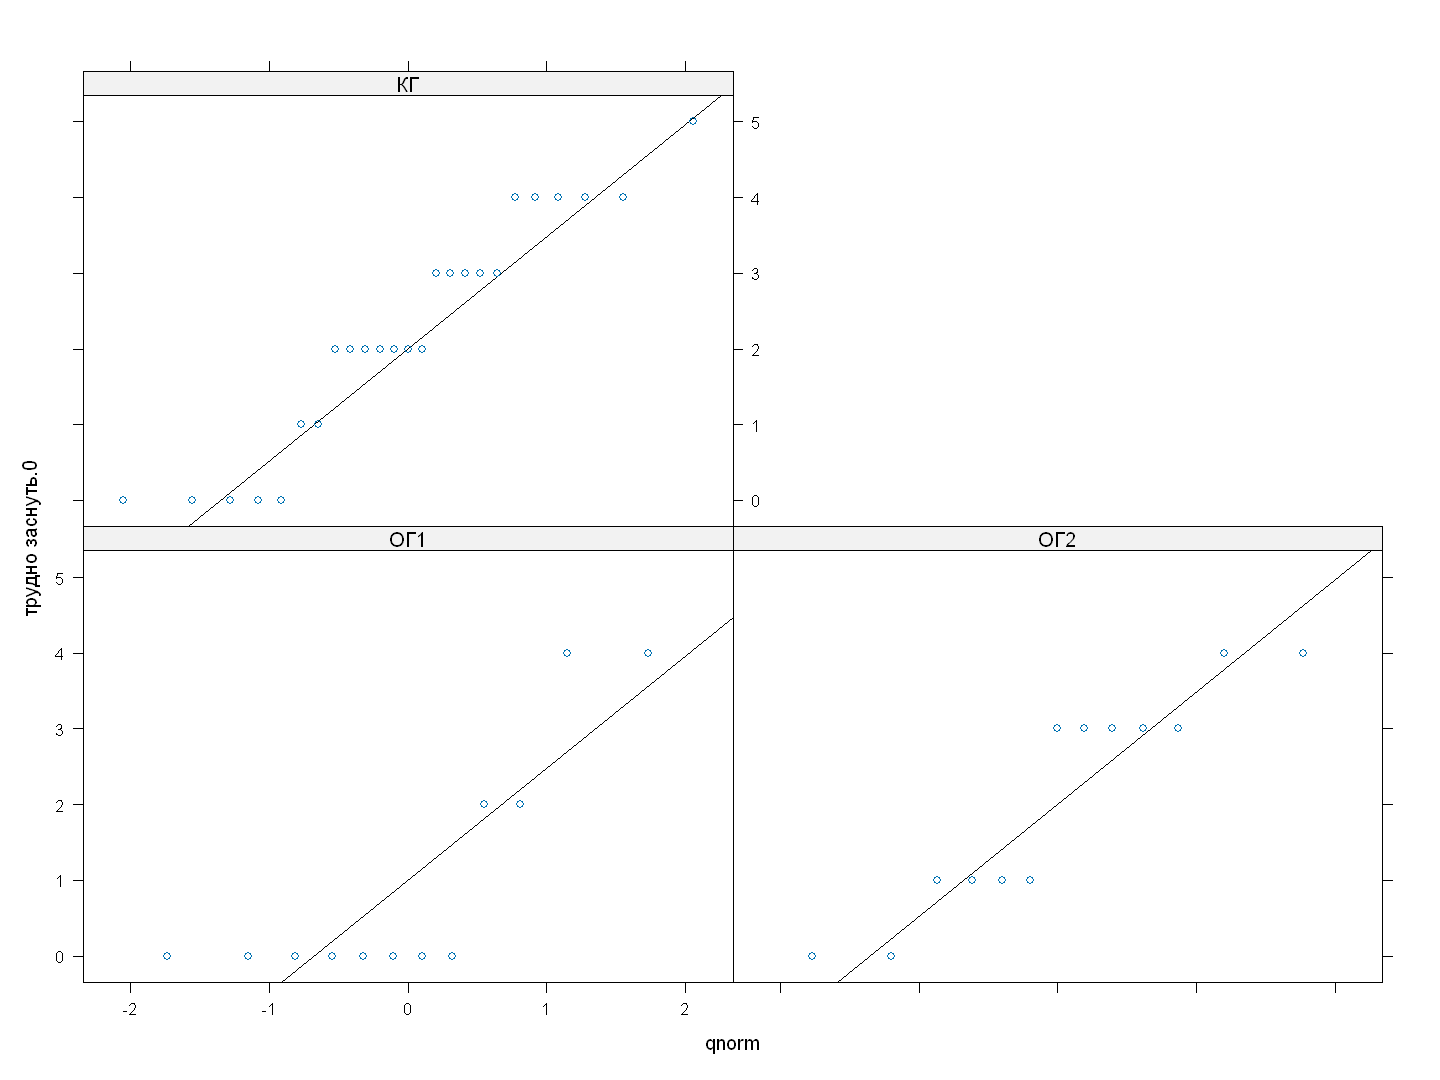

In [229]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

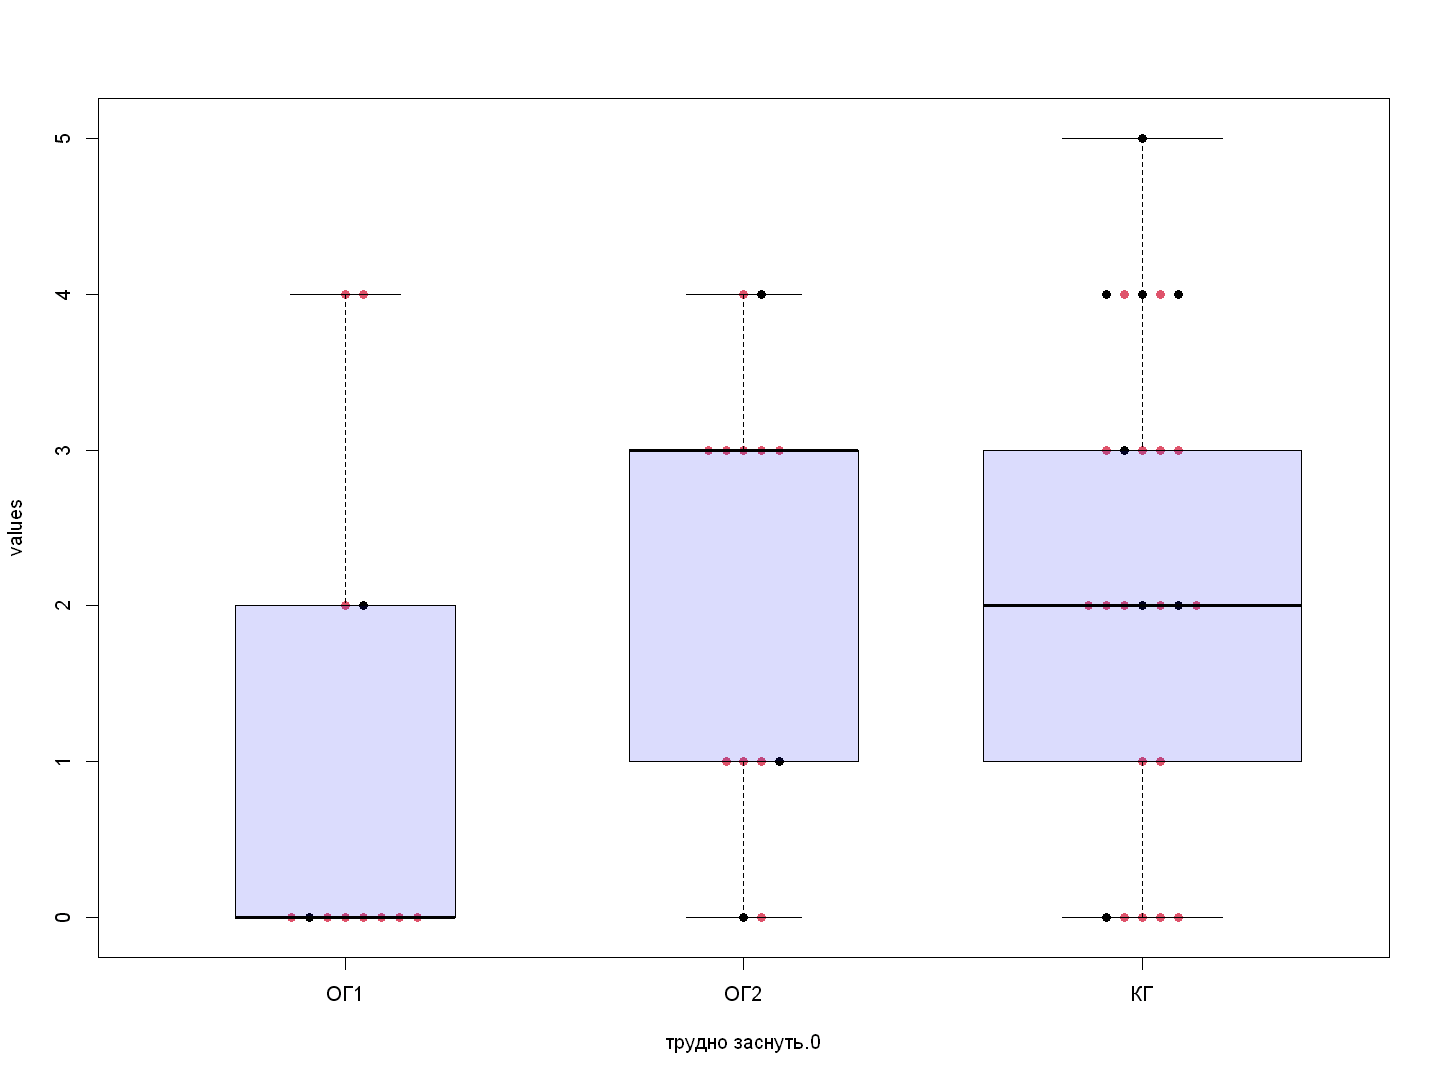

In [230]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [231]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.66246, p-value = 0.0003752

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.85849, p-value = 0.0368

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.91593, p-value = 0.04142



In [232]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 0.11599, df = 2, p-value = 0.9437


### Сравнение, нормальные распределения

In [233]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares   13.01692 107.48308
Deg. of Freedom         2        47

Residual standard error: 1.512241
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)  
parameter    2  13.02   6.508   2.846 0.0681 .
Residuals   47 107.48   2.287                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
             diff         lwr      upr     p adj
ОГ2-ОГ1 1.0769231 -0.38817269 2.542019 0.1877103
КГ-ОГ1  1.2400000 -0.04528235 2.525282 0.0606989
КГ-ОГ2  0.1630769 -1.08835845 1.414512 0.9467137


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -1.766, df = 22.243,

### Сравнение, распределение не нормальное

In [234]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 5.4592, df = 2, p-value = 0.06525

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ1-ОГ2 10.33333     13.97036       FALSE
ОГ1-КГ  11.29333     12.25576       FALSE
ОГ2-КГ   0.96000     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 44, p-value = 0.05757
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = -1.9273, p-value = 0.0565
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 84, p-value = 0.02784
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Tes

## трудно заснуть.3

### Общее

In [235]:
parname <- "трудно заснуть.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

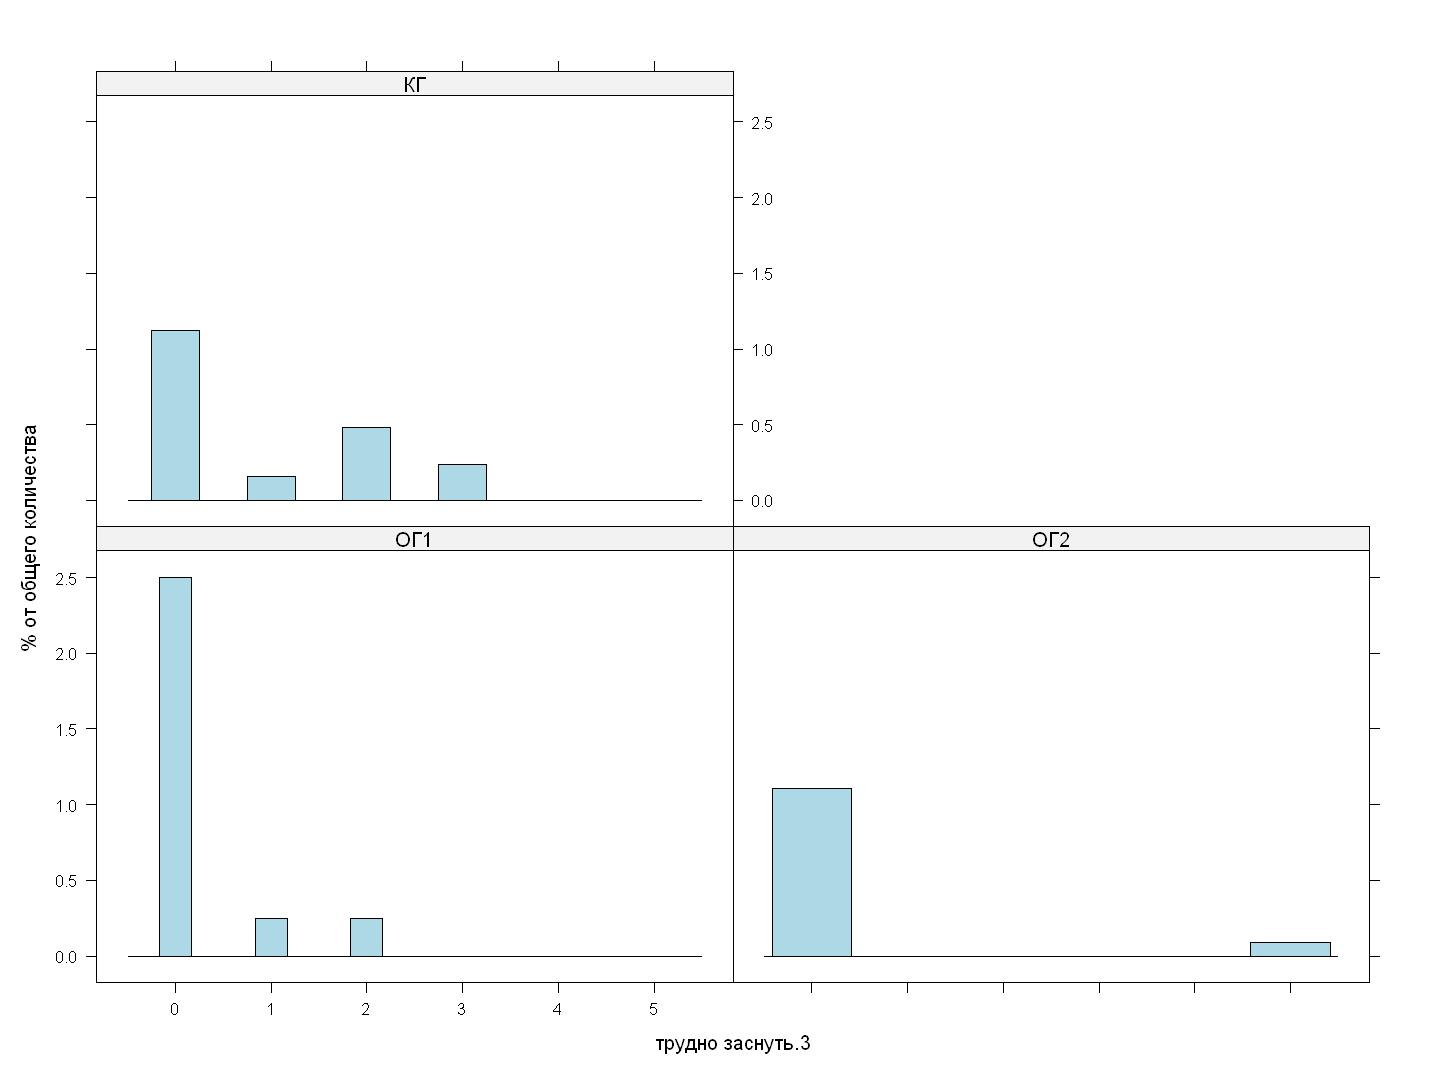

In [236]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [237]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 0.2500000 0.6215816   0  0   0   0   0    2     12
ОГ2 0.3846154 1.3867505   0  0   0   0   0    5     13
КГ  0.9200000 1.1518102   2  0   0   0   2    3     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,0,0,2,0.2500000,0.6215816,12,0
ОГ2,0,0,0,0,5,0.3846154,1.3867505,13,0
КГ,0,0,0,2,3,0.9200000,1.1518102,25,0


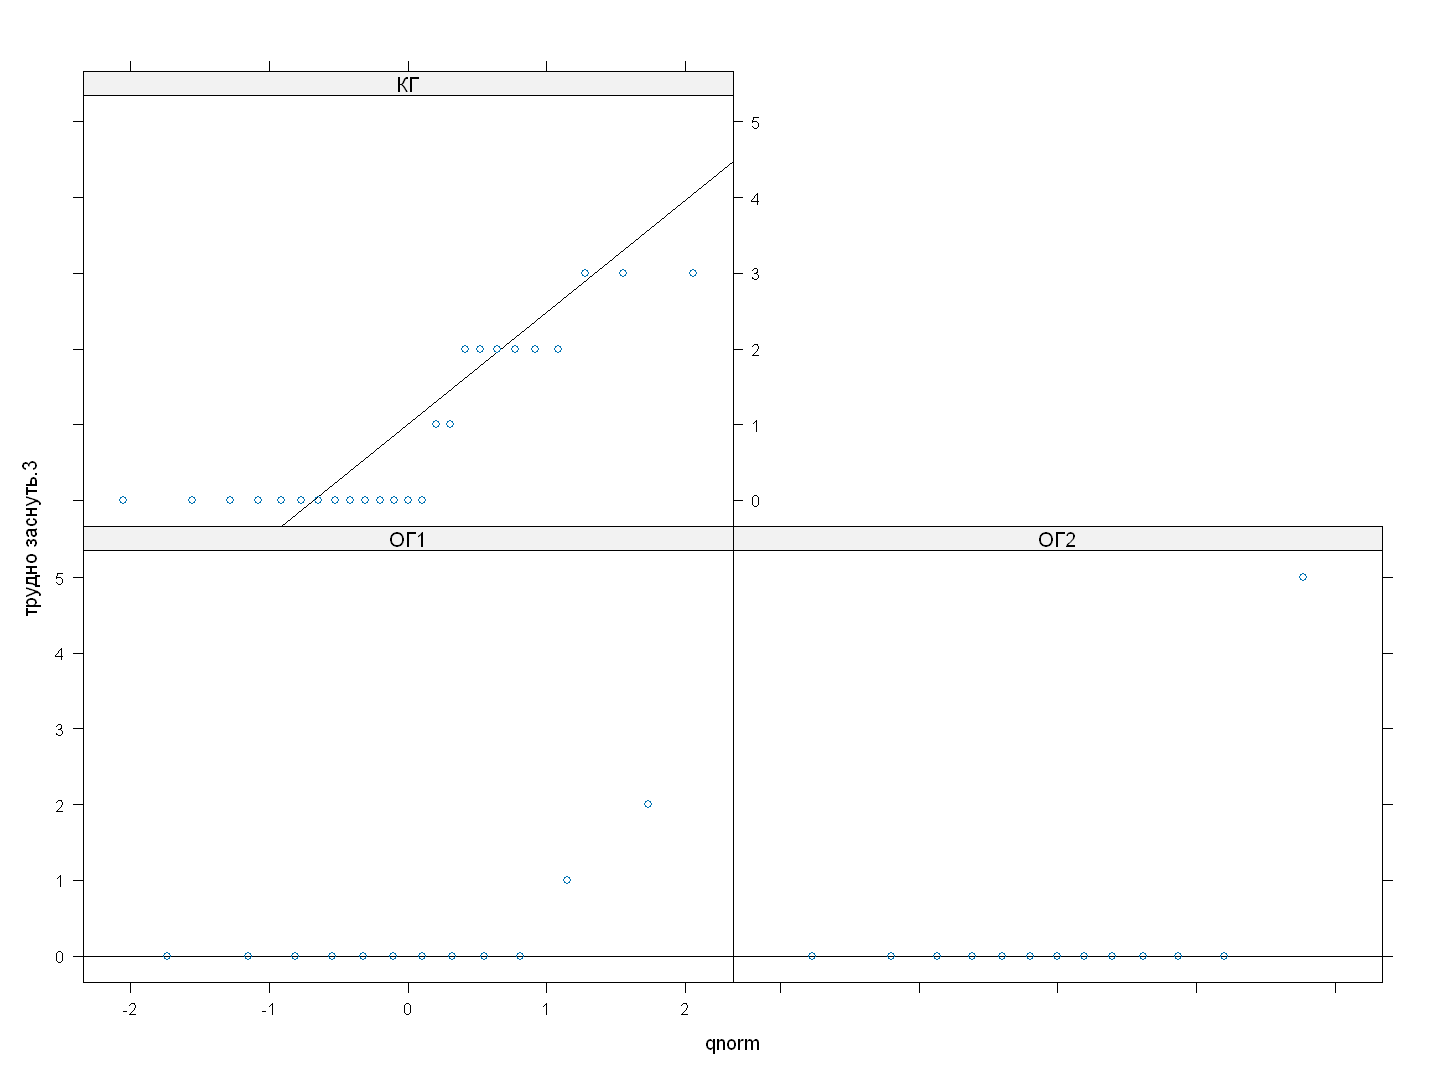

In [238]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

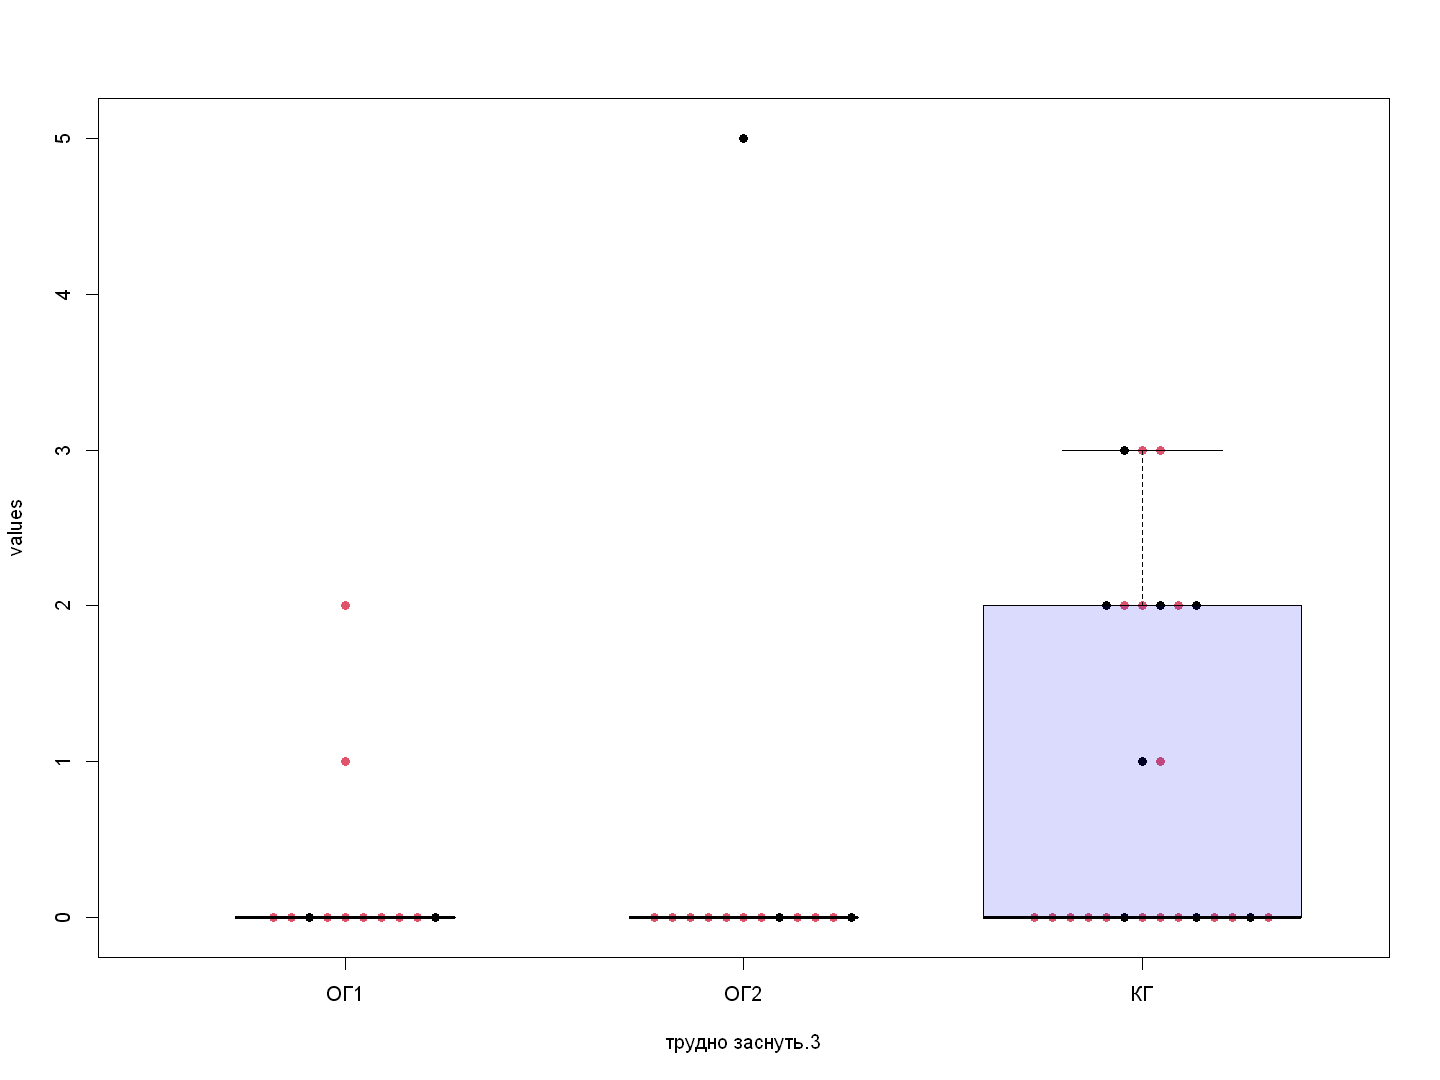

In [239]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [240]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.47944, p-value = 1.251e-05

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.31101, p-value = 5.045e-07

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.74124, p-value = 2.757e-05



In [241]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 6.4407, df = 2, p-value = 0.03994


### Сравнение, нормальные распределения

In [242]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares    4.61308  59.16692
Deg. of Freedom         2        47

Residual standard error: 1.121994
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2   4.61   2.307   1.832  0.171
Residuals   47  59.17   1.259               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
             diff        lwr      upr     p adj
ОГ2-ОГ1 0.1346154 -0.9523994 1.221630 0.9517425
КГ-ОГ1  0.6700000 -0.2836038 1.623604 0.2157312
КГ-ОГ2  0.5353846 -0.3931068 1.463876 0.3514333


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -0.31718, df = 16.918, p-value = 0.755
alternative hypothesis: true difference in means is not eq

### Сравнение, распределение не нормальное

In [243]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 6.0475, df = 2, p-value = 0.04862

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ1-ОГ2 1.243590     13.97036       FALSE
ОГ1-КГ  7.313333     12.25576       FALSE
ОГ2-КГ  8.556923     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 84, p-value = 0.5962
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = 0.57797, p-value = 0.7287
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 104, p-value = 0.08186
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Tes

## ночные пробуждения.0

### Общее

In [244]:
parname <- "ночные пробуждения.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

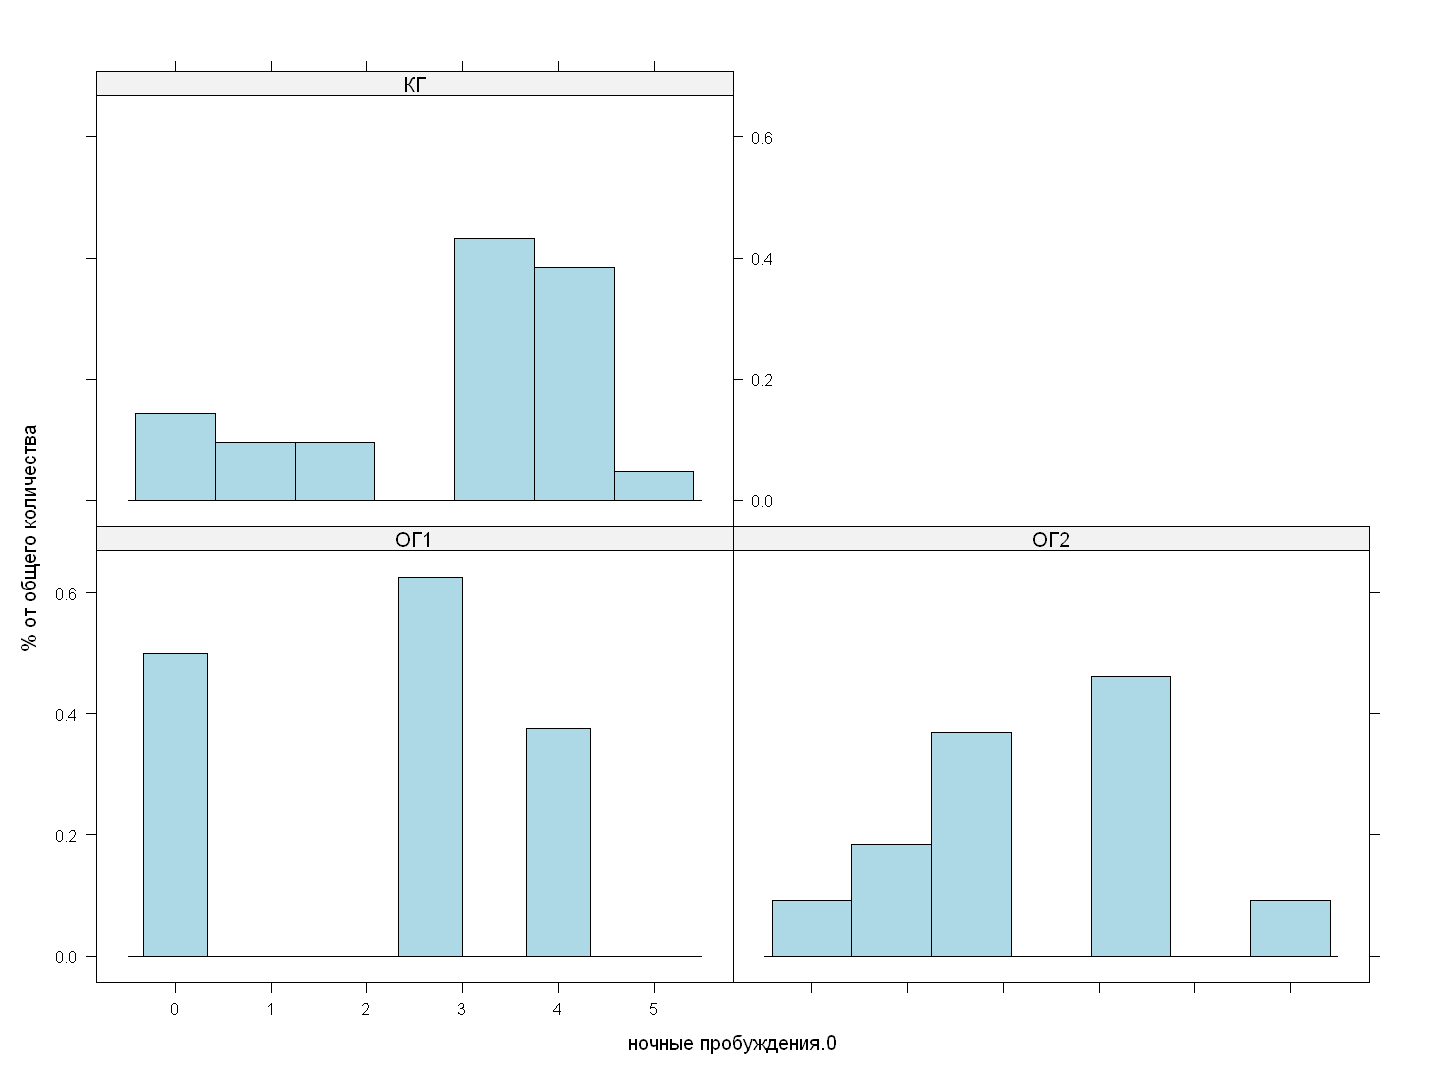

In [245]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [246]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

        mean       sd  IQR 0% 25% 50%  75% 100% data:n
ОГ1 2.250000 1.712255 3.25  0   0   3 3.25    4     12
ОГ2 2.307692 1.250641 1.00  0   2   2 3.00    5     13
КГ  2.800000 1.414214 2.00  0   2   3 4.00    5     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,3,3.25,4,2.250000,1.712255,12,0
ОГ2,0,2,2,3.00,5,2.307692,1.250641,13,0
КГ,0,2,3,4.00,5,2.800000,1.414214,25,0


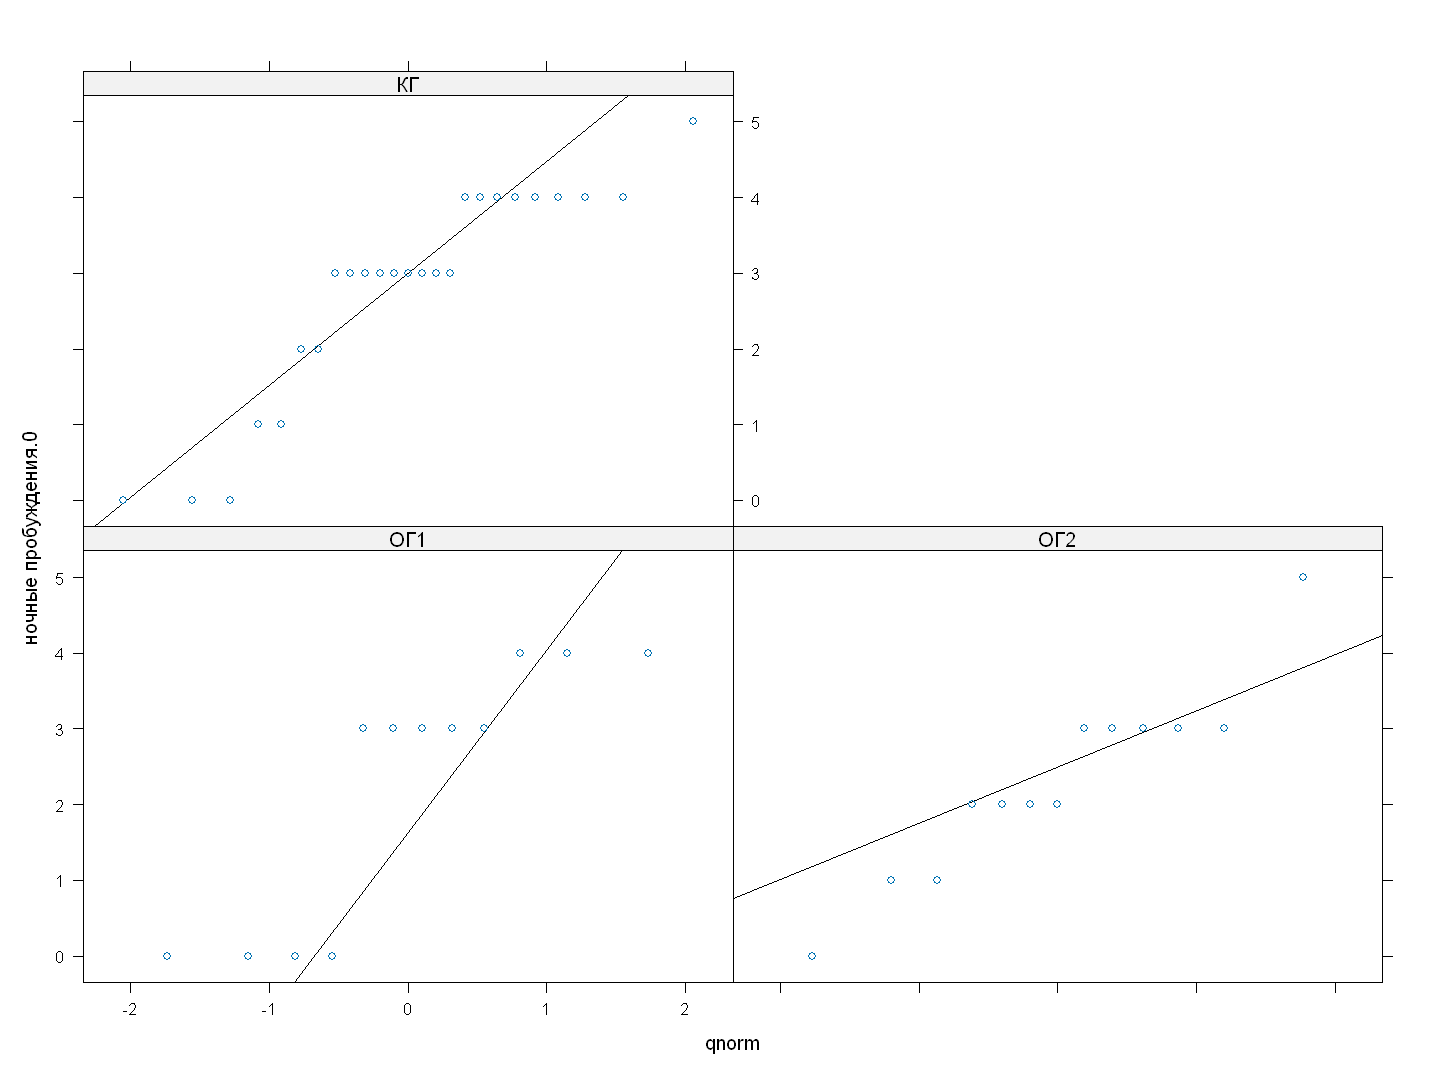

In [247]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

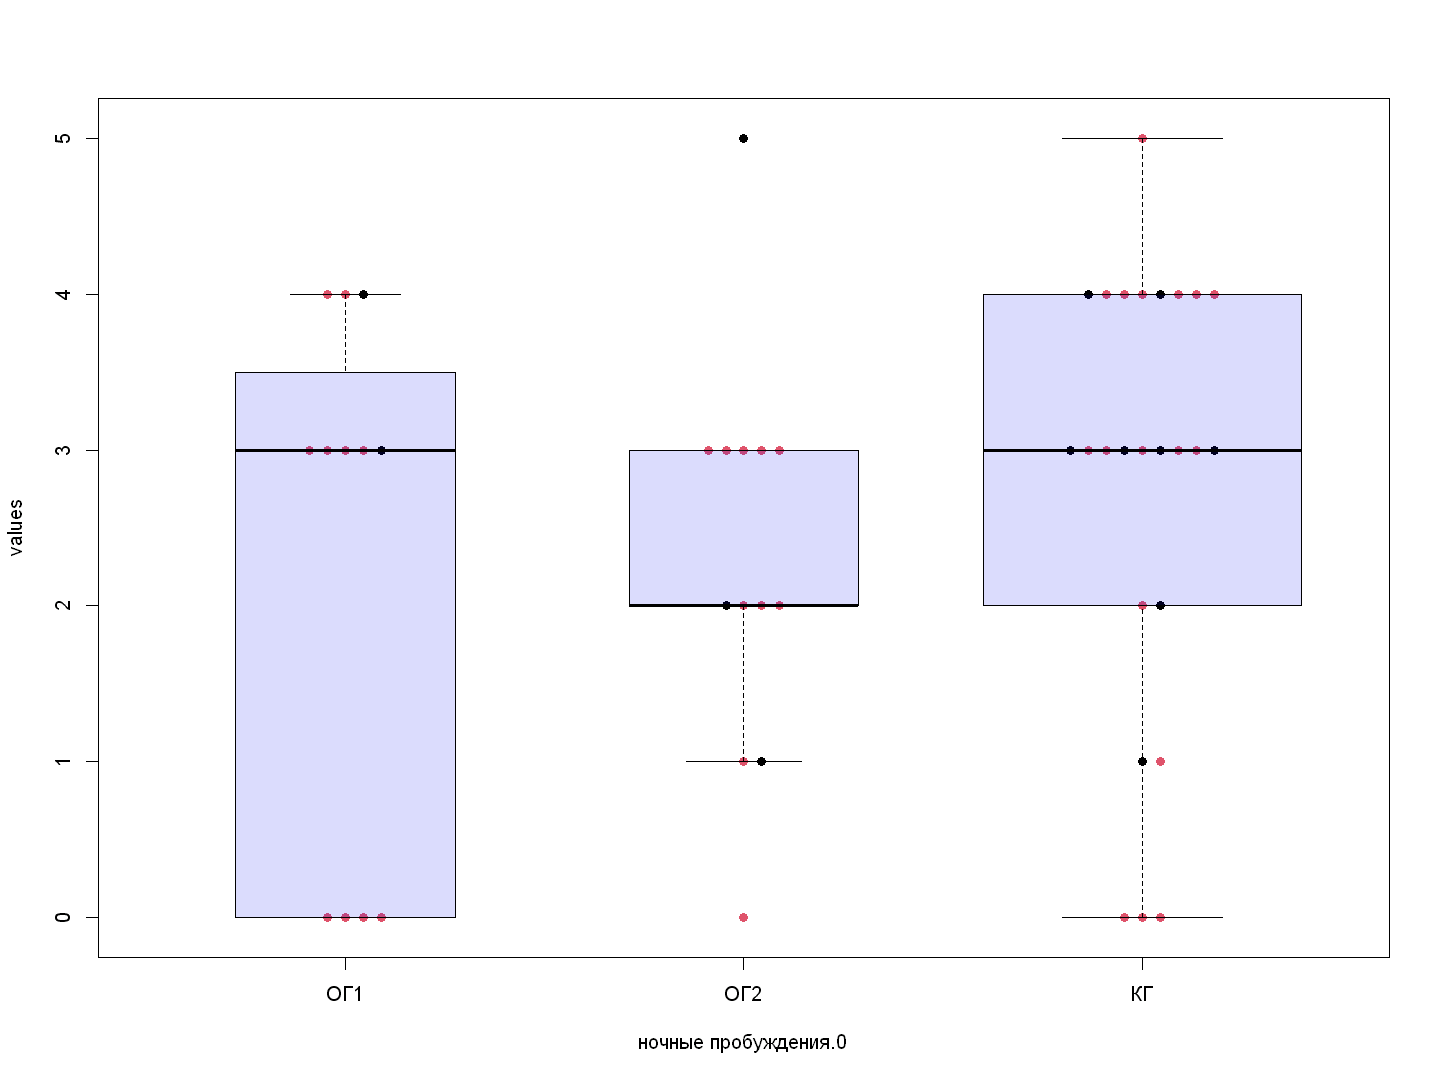

In [248]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [249]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.75511, p-value = 0.003023

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.92248, p-value = 0.2709

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.85757, p-value = 0.00246



In [250]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 1.1504, df = 2, p-value = 0.5626


### Сравнение, нормальные распределения

In [251]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares    3.40077  99.01923
Deg. of Freedom         2        47

Residual standard error: 1.451479
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)
parameter    2   3.40   1.700   0.807  0.452
Residuals   47  99.02   2.107               

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
              diff        lwr     upr     p adj
ОГ2-ОГ1 0.05769231 -1.3485357 1.46392 0.9945804
КГ-ОГ1  0.55000000 -0.6836395 1.78364 0.5316843
КГ-ОГ2  0.49230769 -0.7088448 1.69346 0.5855651


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -0.095541, df = 20.045, p-value = 0.9248
alternative hypothesis: true difference in means is not 

### Сравнение, распределение не нормальное

In [252]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 2.4058, df = 2, p-value = 0.3003

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ1-ОГ2 2.608974     13.97036       FALSE
ОГ1-КГ  4.523333     12.25576       FALSE
ОГ2-КГ  7.132308     11.93301       FALSE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 85.5, p-value = 0.6919
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = 0.4246, p-value = 0.6898
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 123.5, p-value = 0.3774
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Te

## ночные пробуждения.3

### Общее

In [253]:
parname <- "ночные пробуждения.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

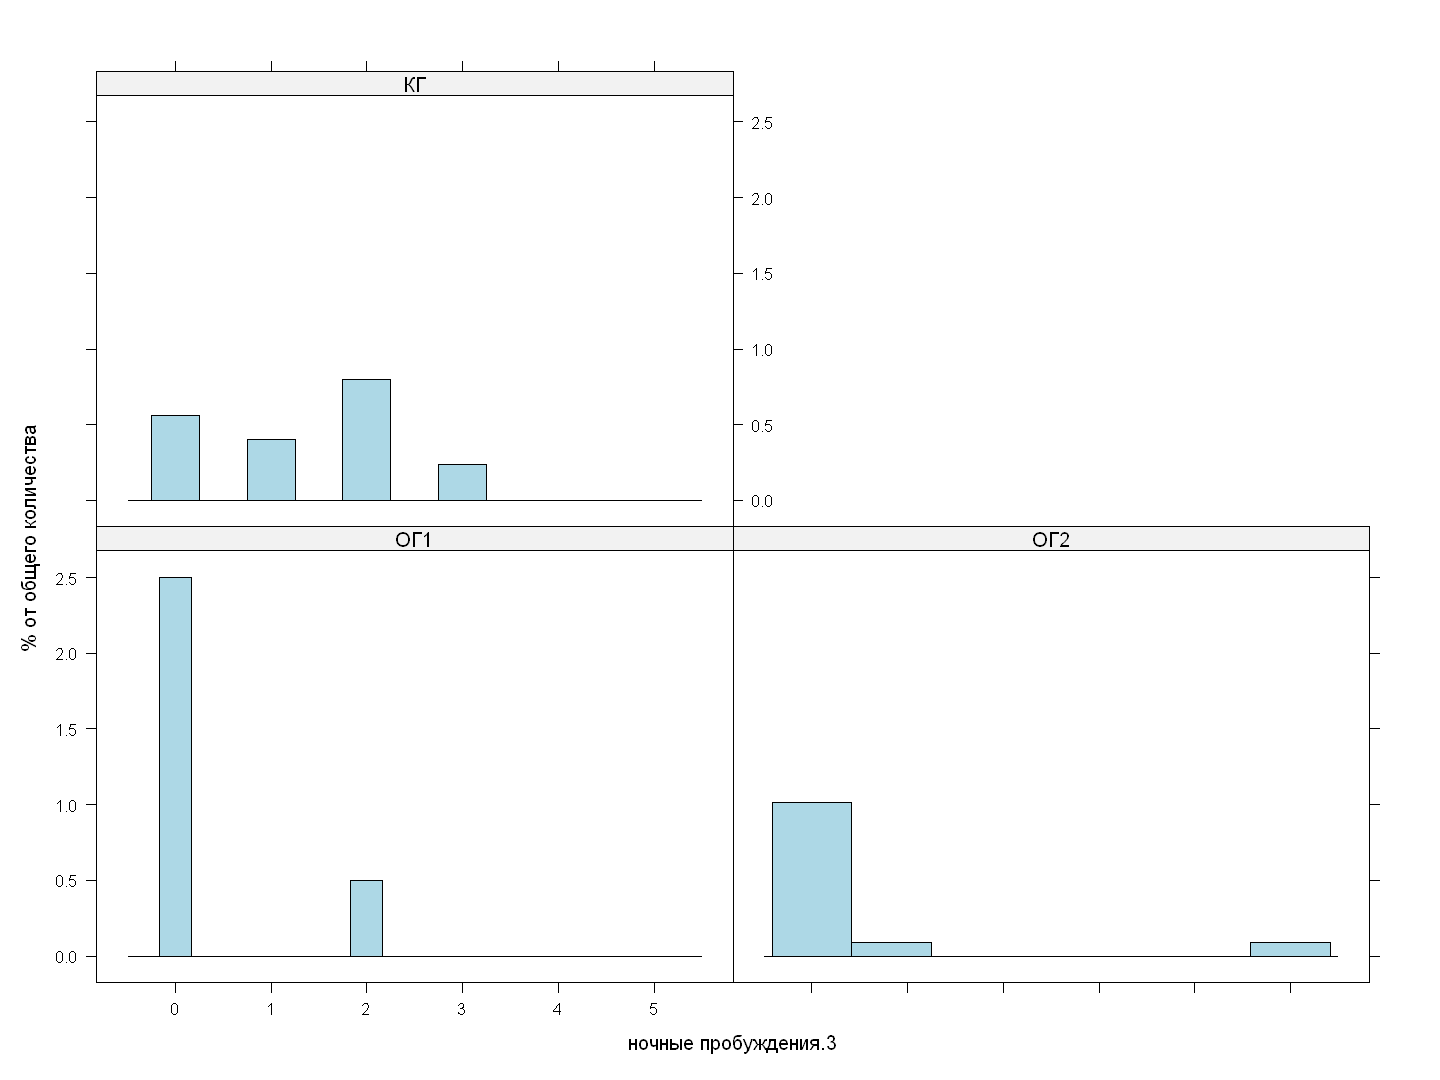

In [254]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [255]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 0.3333333 0.7784989   0  0   0   0   0    2     12
ОГ2 0.4615385 1.3913653   0  0   0   0   0    5     13
КГ  1.3600000 1.0360180   2  0   0   2   2    3     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,0,0,0,2,0.3333333,0.7784989,12,0
ОГ2,0,0,0,0,5,0.4615385,1.3913653,13,0
КГ,0,0,2,2,3,1.3600000,1.0360180,25,0


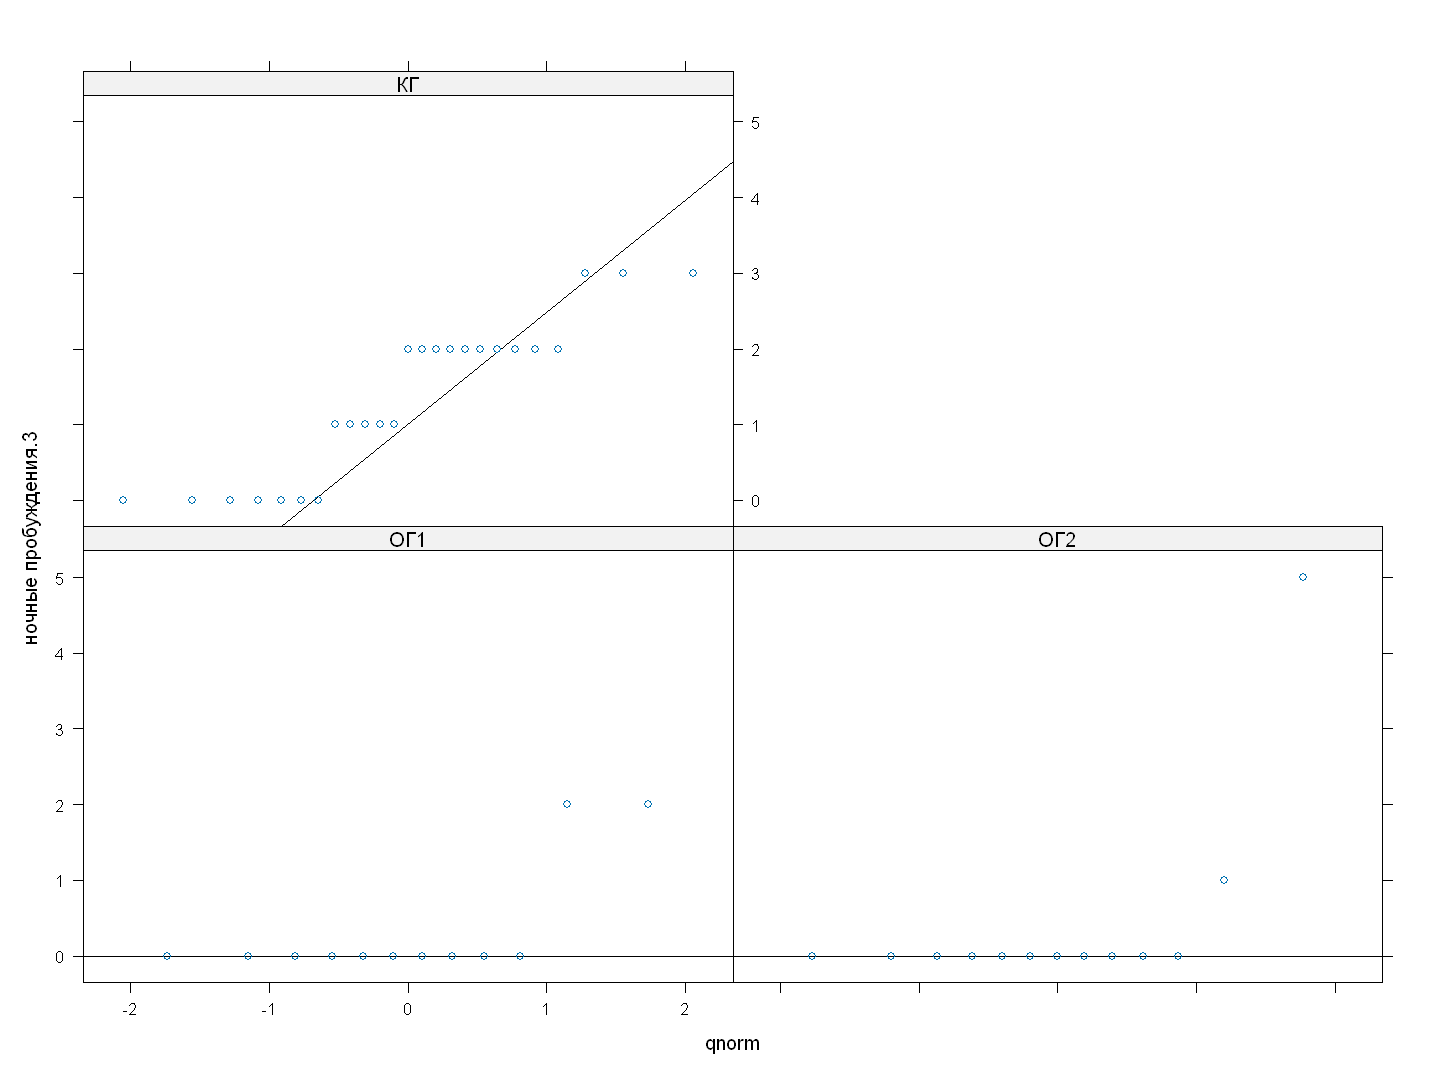

In [256]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

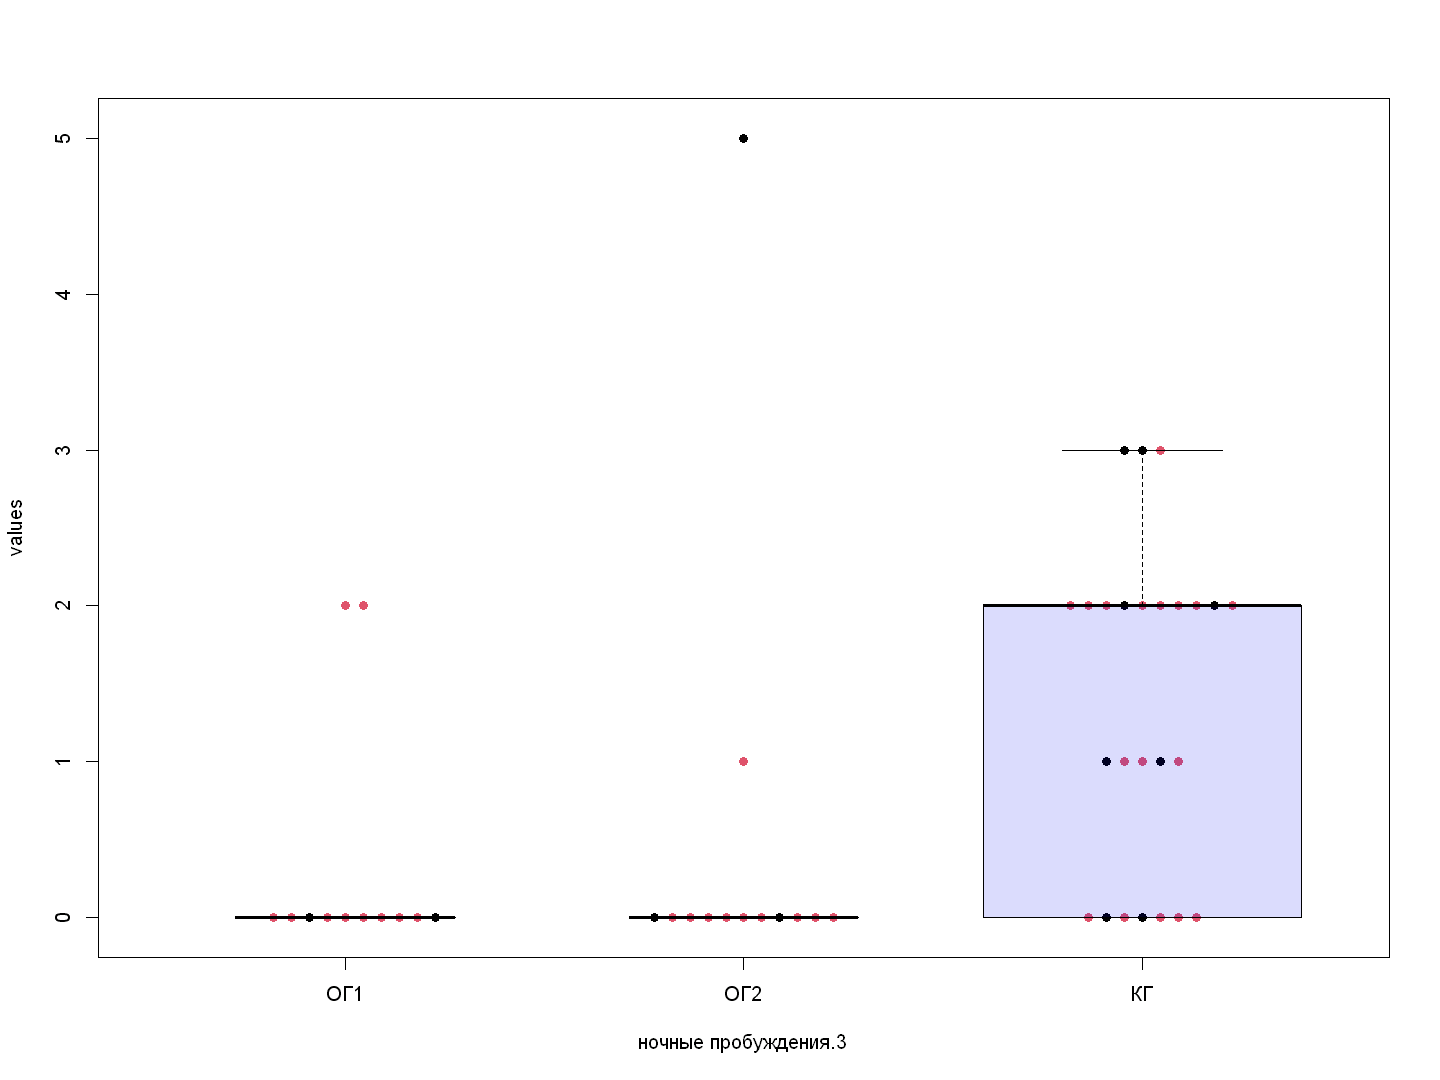

In [257]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [258]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

Группа — ОГ1
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.46465, p-value = 9.811e-06

Группа — ОГ2
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.39044, p-value = 1.66e-06

Группа — КГ
	Shapiro-Wilk normality test

data:  ss[[parname]]
W = 0.85421, p-value = 0.002119



In [259]:
bartlett.test(values ~ parameter)


	Bartlett test of homogeneity of variances

data:  values by parameter
Bartlett's K-squared = 3.7091, df = 2, p-value = 0.1565


### Сравнение, нормальные распределения

In [260]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

Call:
   aov(formula = values ~ parameter)

Terms:
                parameter Residuals
Sum of Squares   11.62256  55.65744
Deg. of Freedom         2        47

Residual standard error: 1.08821
Estimated effects may be unbalanced
            Df Sum Sq Mean Sq F value Pr(>F)  
parameter    2  11.62   5.811   4.907 0.0116 *
Residuals   47  55.66   1.184                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Tukey post hoc test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = values ~ parameter)

$parameter
             diff         lwr      upr     p adj
ОГ2-ОГ1 0.1282051 -0.92607875 1.182489 0.9534262
КГ-ОГ1  1.0266667  0.10177664 1.951557 0.0264261
КГ-ОГ2  0.8984615 -0.00207218 1.798995 0.0506452


HSD Test 
NULL

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Welch Two Sample t-test

data:  lor[parameter == levels(parameter)[i], parname] and lor[parameter == levels(parameter)[j], parname]
t = -0.28709, df = 19.121

### Сравнение, распределение не нормальное

In [261]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 13.532, df = 2, p-value = 0.001152

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
           obs.dif critical.dif stat.signif
ОГ1-ОГ2  0.2948718     13.97036       FALSE
ОГ1-КГ  13.4866667     12.25576        TRUE
ОГ2-КГ  13.7815385     11.93301        TRUE

Pairwise comparison 

Группы —  ОГ1 ,  ОГ2
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 79, p-value = 0.966
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ1, ОГ2)
Z = 0.085228, p-value = 0.8643
alternative hypothesis: two.sided


Группы —  ОГ1 ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 69, p-value = 0.00502
alternative hypothesis: true location shift is not equal to 0


	Exact General Independ

## плохой сон ночью.0

### Общее

In [262]:
parname <- "плохой сон ночью.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

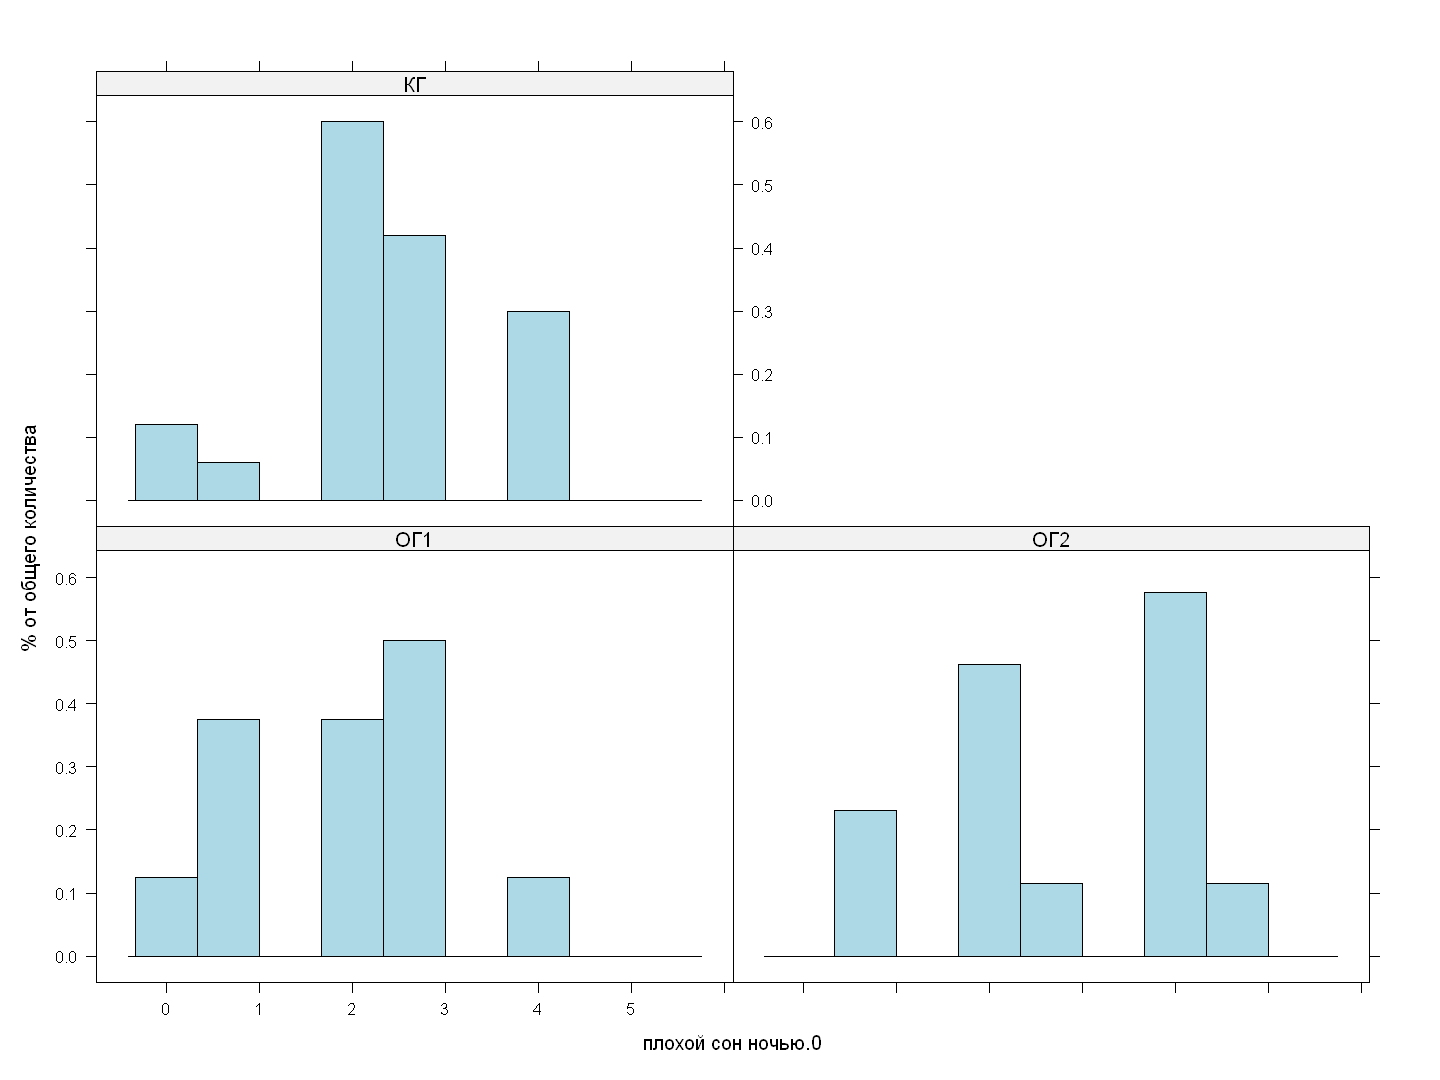

In [263]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [264]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

        mean       sd IQR 0% 25% 50% 75% 100% data:n
ОГ1 2.083333 1.164500   2  0   1   2   3    4     12
ОГ2 2.923077 1.320451   2  1   2   3   4    5     13
КГ  2.480000 1.122497   1  0   2   2   3    4     25

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ1,0,1,2,3,4,2.083333,1.164500,12,0
ОГ2,1,2,3,4,5,2.923077,1.320451,13,0
КГ,0,2,2,3,4,2.480000,1.122497,25,0


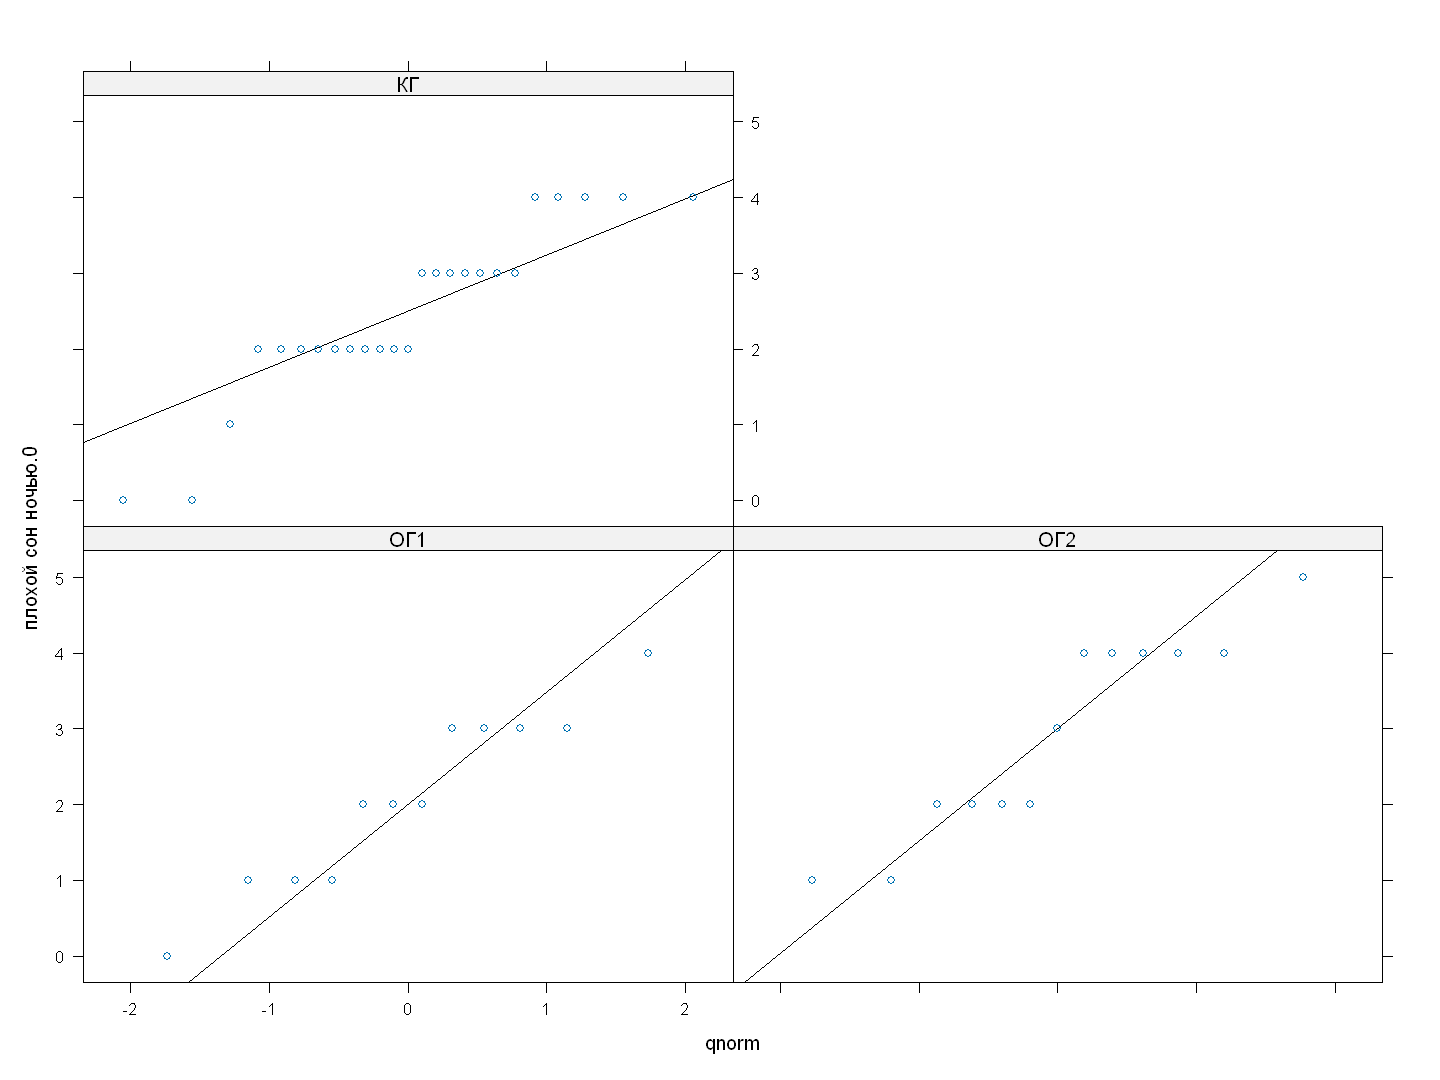

In [265]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## плохой сон ночью.3

### Общее

In [ ]:
parname <- "плохой сон ночью.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## просыпаюсь уставшим.0

### Общее

In [ ]:
parname <- "просыпаюсь уставшим.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## просыпаюсь уставшим.3

### Общее

In [ ]:
parname <- "просыпаюсь уставшим.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## хроническа усталость.0

### Общее

In [ ]:
parname <- "хроническа усталость.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## хроническа усталость.3

### Общее

In [ ]:
parname <- "хроническа усталость.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## снижение активности.0

### Общее

In [ ]:
parname <- "снижение активности.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## снижение активности.3

### Общее

In [ ]:
parname <- "снижение активности.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## снижение концентарации внимания.0

### Общее

In [ ]:
parname <- "снижение концентарации внимания.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## снижение концентарации внимания.3

### Общее

In [ ]:
parname <- "снижение концентарации внимания.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## подавленность.0

### Общее

In [ ]:
parname <- "подавленность.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## подавленность.3

### Общее

In [ ]:
parname <- "подавленность.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## уныние.0

### Общее

In [ ]:
parname <- "уныние.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## уныние.3

### Общее

In [ ]:
parname <- "уныние.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      try(print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      )))
    }
  }
}

## рассеянность.0

### Общее

In [ ]:
parname <- "рассеянность.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## рассеянность.3

### Общее

In [ ]:
parname <- "рассеянность.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## ринологические симптомы.0

### Общее

In [ ]:
parname <- "ринологические симптомы.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## ринологические симптомы.3

### Общее

In [ ]:
parname <- "ринологические симптомы.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## ухо или лицо.0

### Общее

In [ ]:
parname <- "ухо или лицо.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## ухо или лицо.3

### Общее

In [ ]:
parname <- "ухо или лицо.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## качество сна.0

### Общее

In [ ]:
parname <- "качество сна.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## качество сна.3

### Общее

In [ ]:
parname <- "качество сна.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## психические функции.0

### Общее

In [ ]:
parname <- "психические функции.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## психические функции.3

### Общее

In [ ]:
parname <- "психические функции.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## SNOT22.0

### Общее

In [ ]:
parname <- "SNOT22.0"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}

## SNOT22.3

### Общее

In [ ]:
parname <- "SNOT22.3"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [ ]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [ ]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

In [ ]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

In [ ]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, pwcol = пол, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")
par("xpd" = TRUE)
legend(2, -1, levels(пол), col = 1:nlevels(пол), pch = 16, lty = 1, bty = "n", horiz = FALSE, xjust = 0.5, ncol = 3)
par("xpd" = FALSE)

### Тест на нормальность

In [ ]:
for (i in 1:nlevels(parameter)) {
  cat("Группа —", levels(parameter)[i])
  ss <- subset(lor, lor[[groupping_variable]] == levels(parameter)[i])
  try(print(shapiro.test(ss[[parname]])))
}

In [ ]:
bartlett.test(values ~ parameter)

### Сравнение, нормальные распределения

In [ ]:
if (nlevels(parameter) < 3) {
  t.test(values ~ parameter)
} else {
  agg1.aov <- aov(values ~ parameter)
  print(agg1.aov)
  cat()
  print(summary(agg1.aov))
  cat("\n==========\nTukey post hoc test\n")
  print(TukeyHSD(agg1.aov))
  cat("\n==========\nHSD Test \n")
  print(HSD.test(agg1.aov, parname, group = FALSE, main = "Различия объемов\nв разных подгруппах"))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      print(t.test(lor[parameter == levels(parameter)[i], `parname`], lor[parameter == levels(parameter)[j], `parname`]))
    }
  }
}

### Сравнение, распределение не нормальное

In [ ]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  print(kruskal.test(values ~ parameter))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}